# AI Lab Project - Hypoxia Response in Single-cell RNA Sequencing
**Authors:** Mardegan Davide, Mazzi Giovanni, Schena Ascanio, Zecchina Arturo

<a id="abstract"></a>
## **ABSTRACT**

Our project studies hypoxia response in single-cell RNA-seq data from HCC1806 and MCF7 breast cancer cell lines, using both SmartSeq and DropSeq technologies. The analysis starts from exploratory quality control of raw, filtered, and normalized expression matrices, then compares the statistical structure of the datasets across sequencing protocols. Dimensionality reduction methods, including PCA, t-SNE, UMAP, deterministic and variational autoencoders, are used to inspect latent structure and to build compact representations.

The unsupervised part investigates whether cells and genes organize according to oxygen condition, cell cycle, sequencing technology, and pathway-level biology. Hierarchical clustering, K-Means, Gaussian mixture models, pathway enrichment, and cell-cycle scoring are used to interpret the main clusters. The downstream feature-engineering step combines compact latent representations with condition-aware gene-program features.

The supervised-learning section evaluates whether hypoxia and normoxia can be predicted from the engineered single-cell representations. Linear and non-linear classifiers are compared with stratified cross-validation, and the best candidates are refined with randomized hyperparameter search. The main result is that hypoxia produces a strong transcriptional signal across datasets, with SmartSeq datasets being easier to classify and DropSeq datasets benefiting more from non-linear models.

- [ABSTRACT](#abstract)
- [EXPLORATORY DATA ANALYSIS](#exploratory-data-analysis)
    - [Raw / Unfiltered HCC1806 SmartSeq Data](#raw-unfiltered-hcc1806-smartseq-data)
    - [Filtering Effects: Raw vs Filtered HCC1806 SmartSeq](#filtering-effects-raw-vs-filtered-hcc1806-smartseq)
        - [Filtered Data](#filtered-data)
        - [Cells Removed](#cells-removed)
        - [Genes Removed](#genes-removed)
    - [Normalization Effects: Filtered vs Filtered-Normalized HCC1806 SmartSeq](#normalization-effects-filtered-vs-filtered-normalized-hcc1806-smartseq)
    - [Filtered-Normalized HCC1806 SmartSeq EDA](#filtered-normalized-hcc1806-smartseq-eda)
        - [Filtered and Normalized Data](#filtered-and-normalized-data)
    - [Transformation of Gene Expressivity](#transformation-of-gene-expressivity)
- [CROSS-DATASET EDA EXTENSION](#cross-dataset-eda-extension)
    - [QC Distributions Across Datasets](#qc-distributions-across-datasets)
    - [Expression Distributions and log1p Effect](#expression-distributions-and-log1p-effect)
    - [Cell-Cell Correlation Summary Across Datasets](#cell-cell-correlation-summary-across-datasets)
    - [Gene-Condition Associations Across Datasets](#gene-condition-associations-across-datasets)
    - [Gene-Gene Redundancy Comparison](#gene-gene-redundancy-comparison)
    - [Final Cross-Dataset EDA Notes](#final-cross-dataset-eda-notes)
- [DIMENSIONALITY REDUCTION](#dimensionality-reduction)
    - [SmartSeq HCC](#smartseq-hcc)
        - [PCA](#pca)
        - [t-SNE](#t-sne)
        - [Umap](#umap)
        - [Autoencoder](#autoencoder)
        - [Conclusion](#conclusion)
    - [DropSeq HCC](#dropseq-hcc)
        - [PCA](#pca-2)
        - [t-SNE](#t-sne-2)
        - [Umap](#umap-2)
        - [Autoencoder](#autoencoder-2)
        - [Conclusion](#conclusion-2)
- [CLUSTERING](#clustering)
    - [Cell Clustering](#cell-clustering)
        - [Hierarchical Clustering](#hierarchical-clustering)
        - [Gaussian Mixture Models](#gaussian-mixture-models)
    - [Genes Clustering](#genes-clustering)
        - [K-Means](#k-means)
        - [Gene-cluster visual checks](#gene-cluster-visual-checks)
    - [Variational Autoencoder (DropSeq datasets)](#variational-autoencoder-dropseq-datasets)
    - [Expected cell-cycle trajectory in the scVI latent space](#expected-cell-cycle-trajectory-in-the-scvi-latent-space)
- [DOWNSTREAM ANALYSIS](#downstream-analysis)
    - [Dimensionality Reduction](#dimensionality-reduction-2)
    - [Clustering](#clustering-2)
    - [Condition-Aware Gene Features](#condition-aware-gene-features)
    - [Data Leakage Caveat](#data-leakage-caveat)
    - [Final Datasets](#final-datasets)
- [SUPERVISED LEARNING](#supervised-learning)
    - [Linear Models](#linear-models)
    - [Summary Table](#summary-table)
    - [Non-Linear Models](#non-linear-models)
    - [Summary Table](#summary-table-2)
    - [Hyperparameter Tuning](#hyperparameter-tuning)
        - [Methodology](#methodology)
        - [HCC DropSeq](#hcc-dropseq-supervised)
        - [HCC SmartSeq](#hcc-smartseq-supervised)
        - [MCF7 DropSeq](#mcf7-dropseq-supervised)
        - [MCF7 SmartSeq](#mcf7-smartseq-supervised)
    - [Hyperparameter Tuning Results](#hyperparameter-tuning-results)
        - [Observations](#observations)
    - [Conclusion](#supervised-learning-conclusion)
    - [Test Predictions](#test-predictions)


<a id="exploratory-data-analysis"></a>
## **EXPLORATORY DATA ANALYSIS**


The exploratory data analysis section provides the foundation for the rest of the project. Before applying dimensionality reduction, clustering, or supervised learning, we first need to understand how the data are structured and whether there are technical issues that could affect the following analyses.

In this section, we mainly use the HCC1806 SmartSeq dataset as the reference workflow. The reason is that this dataset is available in different preprocessing stages: raw/unfiltered, filtered, and filtered-normalized. This allows us to inspect not only the final matrix, but also what filtering and normalization actually changed. The same logic is then applied to the other datasets, but without repeating every single plot and table in full, for the sake of brevity.

It is important to remember that the datasets differ in two ways. First, they come from different sequencing technologies. SmartSeq is a plate-based sequencing protocol: it contains fewer cells, but usually gives richer expression information for each cell. DropSeq is a droplet-based protocol: it can profile many more cells, but the resulting matrices are usually much sparser. Therefore, differences between SmartSeq and DropSeq may not only be biological, but also technical.

Second, the datasets come from two different tumour cell lines: HCC1806 and MCF7. Both are breast cancer cell lines, but they represent different biological contexts. HCC1806 is generally considered a more aggressive triple-negative breast cancer model, while MCF7 is an estrogen-receptor-positive breast cancer model. For this reason, the response to hypoxia may not be exactly the same in the two cell lines. Some patterns may reflect a general response to low oxygen, while others may be specific to the tumour type.

The EDA follows a step-by-step structure. We first define helper functions to load the data, clean the names, standardize the condition labels, and parse the hypoxia/normoxia labels from DropSeq cell names. Then we inspect the raw HCC1806 SmartSeq matrix, the filtered matrix, and finally the filtered-normalized matrix. Between these steps, we try to understand what filtering and normalization did to the data. The final part compares the main QC signals across all datasets.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D

from scipy import stats
from scipy.stats import hypergeom, zscore, loguniform, randint

from sklearn.decomposition import PCA, SparsePCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    make_scorer,
    balanced_accuracy_score,
    f1_score,
    silhouette_score
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    Perceptron
)

from sklearn.svm import LinearSVC

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset

import gseapy as gp

try:
    import scanpy as sc
except ImportError:
    sc = None

try:
    import umap.umap_ as umap
except ImportError:
    try:
        import umap
    except ImportError:
        umap = None

The following cell defines the paths to the SmartSeq and DropSeq files used in the exploratory data analysis. Relative paths are used when possible, with a fallback to the local project directory.


In [2]:
smartseq_root = Path("SmartSeq")
if not smartseq_root.exists():
    smartseq_root = Path("/Users/dado/Documents/università/year 2/second semester/AI Lab/SmartSeq")

dropseq_root = Path("DropSeq")
if not dropseq_root.exists():
    dropseq_root = Path("/Users/dado/Documents/università/year 2/second semester/AI Lab/DropSeq")

hcc_smartseq_dir = smartseq_root / "HCC1806"
if not hcc_smartseq_dir.exists():
    hcc_smartseq_dir = smartseq_root

mcf_smartseq_dir = smartseq_root / "MCF7"
if not mcf_smartseq_dir.exists():
    mcf_smartseq_dir = smartseq_root

hcc_smart_metadata_path = hcc_smartseq_dir / "HCC1806_SmartS_MetaData.tsv"
hcc_smart_unfiltered_path = hcc_smartseq_dir / "HCC1806_SmartS_Unfiltered_Data.txt"
hcc_smart_filtered_path = hcc_smartseq_dir / "HCC1806_SmartS_Filtered_Data.txt"
hcc_smart_normalized_path = hcc_smartseq_dir / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt"

mcf_smart_metadata_path = mcf_smartseq_dir / "MCF7_SmartS_MetaData.tsv"
mcf_smart_unfiltered_path = mcf_smartseq_dir / "MCF7_SmartS_Unfiltered_Data.txt"
mcf_smart_filtered_path = mcf_smartseq_dir / "MCF7_SmartS_Filtered_Data.txt"
mcf_smart_normalized_path = mcf_smartseq_dir / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt"

hcc_dropseq_path = dropseq_root / "HCC1806_Filtered_Normalised_3000_Data_train.txt"
mcf_dropseq_path = dropseq_root / "MCF7_Filtered_Normalised_3000_Data_train.txt"

In this cell, we define a set of helper functions to avoid repeating the same code for every combination of cell line and sequencing technology. These functions are used to make the EDA workflow more consistent and less error-prone.

In particular, the helper functions allow us to load expression matrices, clean gene and cell names, standardize condition labels, parse hypoxia and normoxia information from DropSeq cell names, compute cell-level and gene-level QC summaries, and create display-friendly merged tables for inspection.

This is useful because the datasets do not all have exactly the same structure. SmartSeq has a separate metadata file, while DropSeq has the condition encoded directly in the cell names. By defining these functions once, we can handle these differences in a controlled way instead of rewriting similar code many times.


In [ ]:
def read_counts_matrix(path):
    df = pd.read_csv(path, sep=r"\s+", engine="python", index_col=0)
    df.index = df.index.astype(str).str.strip().str.strip('"')
    df.columns = df.columns.astype(str).str.strip().str.strip('"')
    df.index.name = "Gene"
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


def standardize_condition(series):
    return series.astype(str).str.strip().replace({
        "Hypo": "Hypoxia",
        "hypo": "Hypoxia",
        "Hypoxia": "Hypoxia",
        "hypoxia": "Hypoxia",

        "Norm": "Normoxia",
        "norm": "Normoxia",
        "Normo": "Normoxia",
        "normo": "Normoxia",
        "Normoxia": "Normoxia",
        "normoxia": "Normoxia",

        "nan": np.nan,
        "None": np.nan,
        "none": np.nan,
        "": np.nan
    })


def parse_dropseq_metadata_from_filenames(filenames, cell_line):
    meta = pd.DataFrame({"Filename": pd.Index(filenames).astype(str).str.strip().str.strip('"')})
    meta["Condition"] = meta["Filename"].str.extract(r"_(Hypoxia|Normoxia|Hypo|Normo)$", expand=False)
    meta["Condition"] = standardize_condition(meta["Condition"])
    meta["Cell barcode"] = meta["Filename"].str.replace(r"_(Hypoxia|Normoxia|Hypo|Normo)$", "", regex=True)
    meta["Cell Line"] = cell_line
    meta["Technology"] = "DropSeq"
    meta["Cell name"] = meta["Cell barcode"]
    meta["PreprocessingTag"] = "Filtered_Normalised_3000_train"
    meta["ProcessingComments"] = "Condition parsed from DropSeq cell-name suffix; no unfiltered/filtered DropSeq files were available."
    return meta


def compute_qc_tables(expression, metadata):
    """
    Create cell-level and gene-level QC tables from a cells x genes matrix.

    expression: cells x genes
    metadata: one row per cell, containing Filename
    """

    expression = expression.apply(pd.to_numeric, errors="coerce").copy()
    expression.index = expression.index.astype(str)
    expression.index.name = "Filename"

    metadata = metadata.copy()

    if "Filename" in metadata.columns:
        metadata["Filename"] = metadata["Filename"].astype(str).str.strip().str.strip('"')
        cell_qc = metadata.set_index("Filename").reindex(expression.index)
    else:
        cell_qc = pd.DataFrame(index=expression.index)

    if "Condition" in cell_qc.columns:
        cell_qc["Condition"] = standardize_condition(cell_qc["Condition"])

    cell_qc["detected_genes"] = (expression > 0).sum(axis=1)
    cell_qc["zero_fraction"] = (expression == 0).mean(axis=1)
    cell_qc["total_expression"] = expression.sum(axis=1)
    cell_qc["mean_expression"] = expression.mean(axis=1)
    mito_genes = [
        gene for gene in expression.columns
        if str(gene).upper().startswith("MT-")
    ]

    if len(mito_genes) > 0:
        mito_expression = expression[mito_genes].sum(axis=1)
        total_expression = expression.sum(axis=1).replace(0, np.nan)
        cell_qc["mitochondrial_fraction"] = mito_expression / total_expression
    else:
        cell_qc["mitochondrial_fraction"] = np.nan
    cell_qc = cell_qc.reset_index()
    gene_qc = pd.DataFrame(index=expression.columns)
    gene_qc.index.name = "gene"
    gene_qc["detected_cells"] = (expression > 0).sum(axis=0)
    gene_qc["zero_fraction"] = (expression == 0).mean(axis=0)
    gene_qc["mean_expression"] = expression.mean(axis=0)
    gene_qc["variance"] = expression.var(axis=0)

    return cell_qc, gene_qc, mito_genes


def load_smartseq_dataset(dataset_name, cell_line, metadata_path, normalized_path):
    if not metadata_path.exists() or not normalized_path.exists():
        print(f"Skipping {dataset_name}: missing metadata or normalized file.")
        print("  metadata:", metadata_path, metadata_path.exists())
        print("  normalized:", normalized_path, normalized_path.exists())
        return None

    metadata = pd.read_csv(metadata_path, sep="\t")
    metadata["Filename"] = metadata["Filename"].astype(str).str.strip().str.strip('"')
    if "Condition" in metadata.columns:
        metadata["Condition"] = standardize_condition(metadata["Condition"])
    metadata["Cell Line"] = cell_line
    metadata["Technology"] = "SmartSeq"

    counts = read_counts_matrix(normalized_path)
    expression = counts.T.copy()
    expression.index.name = "Filename"

    common_cells = pd.Index(expression.index).intersection(pd.Index(metadata["Filename"]))
    expression = expression.loc[common_cells]
    metadata = metadata.set_index("Filename").loc[common_cells].reset_index()

    cell_qc, gene_qc, mito_genes = compute_qc_tables(expression, metadata)

    return {
        "dataset": dataset_name,
        "cell_line": cell_line,
        "technology": "SmartSeq",
        "preprocessing_available": "unfiltered + filtered + normalized",
        "counts": counts,
        "expression": expression,
        "metadata": metadata,
        "cell_qc": cell_qc,
        "gene_qc": gene_qc,
        "mitochondrial_genes": mito_genes,
        "normalized_path": normalized_path,
        "metadata_path": metadata_path
    }


def load_dropseq_dataset(dataset_name, cell_line, normalized_path):
    if not normalized_path.exists():
        print(f"Skipping {dataset_name}: missing normalized file.")
        print("  normalized:", normalized_path, normalized_path.exists())
        return None

    counts = read_counts_matrix(normalized_path)
    expression = counts.T.copy()
    expression.index.name = "Filename"

    metadata = parse_dropseq_metadata_from_filenames(expression.index, cell_line=cell_line)
    cell_qc, gene_qc, mito_genes = compute_qc_tables(expression, metadata)

    return {
        "dataset": dataset_name,
        "cell_line": cell_line,
        "technology": "DropSeq",
        "preprocessing_available": "normalized only",
        "counts": counts,
        "expression": expression,
        "metadata": metadata,
        "cell_qc": cell_qc,
        "gene_qc": gene_qc,
        "mitochondrial_genes": mito_genes,
        "normalized_path": normalized_path,
        "metadata_path": None
    }


def sample_by_condition(expression, cell_qc, max_cells, random_state=67):
    if len(expression) <= max_cells:
        return expression.copy()

    meta = cell_qc.set_index("Filename").reindex(expression.index)
    sampled = []
    conditions = meta["Condition"].dropna().unique()

    if len(conditions) > 0:
        per_group = max(1, max_cells // len(conditions))
        for condition in conditions:
            idx = meta.index[meta["Condition"] == condition]
            n = min(per_group, len(idx))
            if n > 0:
                sampled.extend(pd.Series(idx).sample(n=n, random_state=random_state).tolist())

    if len(sampled) < max_cells:
        remaining = pd.Index(expression.index).difference(pd.Index(sampled))
        n_extra = min(max_cells - len(sampled), len(remaining))
        if n_extra > 0:
            sampled.extend(pd.Series(remaining).sample(n=n_extra, random_state=random_state).tolist())

    return expression.loc[sampled].copy()


def sample_values_from_matrix(expression, max_values=10000, random_state= 42):
    values = expression.to_numpy().ravel()
    values = values[np.isfinite(values)]
    if len(values) > max_values:
        rng = np.random.default_rng(random_state)
        values = rng.choice(values, size=max_values, replace=False)
    return pd.Series(values)

def make_display_merged_table(expression, metadata, max_genes=10):
    """
    Create a display-friendly table with metadata plus the first few gene-expression columns.
    This is only for inspection/display, not for numeric calculations.
    """
    metadata_aligned = metadata.copy()

    if "Filename" in metadata_aligned.columns:
        metadata_aligned = metadata_aligned.set_index("Filename").reindex(expression.index)
    else:
        metadata_aligned.index = expression.index

    genes_to_show = expression.columns[:max_genes]

    display_table = metadata_aligned.join(expression[genes_to_show], how="left")
    display_table = display_table.reset_index()

    return display_table

def check_redundant_cells(
    expression,
    metadata,
    cell_similarity_threshold=0.98,
    n_variable_genes_for_similarity=3000
):
    redundant_annotation_tables = []

    for column in ["Filename", "Cell name"]:
        if column in metadata.columns:
            duplicated = metadata[metadata[column].duplicated(keep=False)].copy()

            if len(duplicated) > 0:
                duplicated["redundancy_reason"] = f"duplicate_{column}"
                redundant_annotation_tables.append(duplicated)

    if {"PCR Plate", "Pos"}.issubset(metadata.columns):
        duplicated_position = metadata[
            metadata.duplicated(["PCR Plate", "Pos"], keep=False)
        ].copy()

        if len(duplicated_position) > 0:
            duplicated_position["redundancy_reason"] = "duplicate_plate_position"
            redundant_annotation_tables.append(duplicated_position)

    if len(redundant_annotation_tables) > 0:
        redundant_annotation_cells = (
            pd.concat(redundant_annotation_tables, ignore_index=True)
            .drop_duplicates()
        )
    else:
        redundant_annotation_cells = pd.DataFrame()

    n_variable_genes = min(n_variable_genes_for_similarity, expression.shape[1])

    variable_genes = (
        expression
        .var(axis=0)
        .sort_values(ascending=False)
        .head(n_variable_genes)
        .index
    )

    similarity_matrix = np.log1p(expression[variable_genes]).T.corr()

    upper_triangle_mask = np.triu(
        np.ones(similarity_matrix.shape),
        k=1
    ).astype(bool)

    cell_similarity_pairs = (
        similarity_matrix
        .rename_axis(index="cell_1", columns="cell_2")
        .where(upper_triangle_mask)
        .stack()
        .rename("correlation")
        .reset_index()
    )

    highly_similar_cells = (
        cell_similarity_pairs[
            cell_similarity_pairs["correlation"] >= cell_similarity_threshold
        ]
        .sort_values("correlation", ascending=False)
    )

    return redundant_annotation_cells, cell_similarity_pairs, highly_similar_cells

<a id="raw-unfiltered-hcc1806-smartseq-data"></a>
### **Raw / Unfiltered HCC1806 SmartSeq Data**

We start from the raw/unfiltered HCC1806 SmartSeq dataset. This is the best place to begin because it shows the data before any filtering or normalization has been applied.

At this stage, the matrix still contains all available cells and genes. This means that it may include low-quality cells, genes that are almost never expressed, and strong differences in library size. These are not necessarily problems yet: the goal of this first step is to describe them clearly before moving to the filtered data.


In [4]:
# HCC SmartSeq unfiltered data

df_HCC_metadata = pd.read_csv(hcc_smart_metadata_path, sep="\t")
df_HCC_metadata["Filename"] = df_HCC_metadata["Filename"].astype(str).str.strip().str.strip('"')

if "Condition" in df_HCC_metadata.columns:
    df_HCC_metadata["Condition"] = standardize_condition(df_HCC_metadata["Condition"])

df_HCC_metadata["Cell Line"] = "HCC1806"
df_HCC_metadata["Technology"] = "SmartSeq"

df_HSU_counts = read_counts_matrix(hcc_smart_unfiltered_path)

df_HSU_expression = df_HSU_counts.T.copy()
df_HSU_expression.index.name = "Filename"
df_HSU_expression.columns.name = "Gene"

common_cells = pd.Index(df_HSU_expression.index).intersection(
    pd.Index(df_HCC_metadata["Filename"])
)

df_HSU_expression = df_HSU_expression.loc[common_cells]

df_HCC_metadata_HSU = (
    df_HCC_metadata
    .set_index("Filename")
    .loc[common_cells]
    .reset_index()
)

df_HSU_merged = make_display_merged_table(
    expression=df_HSU_expression,
    metadata=df_HCC_metadata_HSU,
    max_genes=df_HSU_expression.shape[1]
)

metadata_filenames = set(df_HCC_metadata["Filename"])
expression_filenames = set(df_HSU_expression.index)

print(f"Metadata samples: {len(df_HCC_metadata):,}")
print(f"Expression samples: {len(df_HSU_expression):,}")
print(f"Merged samples: {len(df_HSU_merged):,}")
print(f"Genes: {df_HSU_counts.shape[0]:,}")

df_HSU_merged.head()

Metadata samples: 243
Expression samples: 243
Merged samples: 243
Genes: 23,396


,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments,Technology,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,MT-TP,MAFIP
0,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned...,HCC1806,1,A10,Normoxia,24,S123,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,17,5,15,3852,900,22,4208,26,66,0
1,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned....,HCC1806,1,A12,Normoxia,24,S26,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,49,29,36,7457,1439,43,6491,62,71,4
2,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.so...,HCC1806,1,A1,Hypoxia,24,S97,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,0,0,0,93,12,0,25,0,1,0
3,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.s...,HCC1806,1,A2,Hypoxia,24,S104,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,43,17,8,1479,234,0,4819,11,3,7
4,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sor...,HCC1806,1,A3,Hypoxia,24,S4,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,0,0,3,303,33,0,310,4,9,0


In [5]:
df_metadata_raw = df_HCC_metadata_HSU.copy()
df_expression_by_cell = df_HSU_expression.copy()

df_expression_by_cell = df_expression_by_cell.apply(pd.to_numeric, errors="coerce")
df_expression_by_cell.index.name = "Cell"
df_expression_by_cell.columns.name = "Gene"

print("Expression matrix shape, cells x genes:", df_expression_by_cell.shape)
display(df_expression_by_cell.iloc[:5, :5])

Expression matrix shape, cells x genes: (243, 23396)


Gene,WASH7P,CICP27,DDX11L17,WASH9P,OR4F29
Cell,,,,,
output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,0,0,0,0,2
output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,0,0,0,0,0
output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam,0,0,0,0,0
output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,0,0,0,0,0
output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,0,0,0,0,0


The merge confirms that the raw expression matrix and the metadata refer to the same set of cells. This is an important sanity check because all later condition-based analyses depend on the correct alignment between expression values and cell annotations.

At this stage, the number of genes is intentionally large, since no filtering has been applied yet. Many of these genes may be absent or nearly absent across cells, but keeping them here allows us to understand what the raw matrix looks like before preprocessing.


In [6]:
metadata_missing_summary = pd.DataFrame({
    "missing_count": df_metadata_raw.isna().sum(),
    "missing_fraction": df_metadata_raw.isna().mean(),
}).sort_values("missing_count", ascending=False)

print("Missing values in metadata:", metadata_missing_summary)
print("Total missing metadata values:", int(df_metadata_raw.isna().sum().sum()))
display(metadata_missing_summary)

Missing values in metadata:                     missing_count  missing_fraction
Filename                        0               0.0
Cell Line                       0               0.0
PCR Plate                       0               0.0
Pos                             0               0.0
Condition                       0               0.0
Hours                           0               0.0
Cell name                       0               0.0
PreprocessingTag                0               0.0
ProcessingComments              0               0.0
Technology                      0               0.0
Total missing metadata values: 0


,missing_count,missing_fraction
Filename,0,0.0
Cell Line,0,0.0
PCR Plate,0,0.0
Pos,0,0.0
Condition,0,0.0
Hours,0,0.0
Cell name,0,0.0
PreprocessingTag,0,0.0
ProcessingComments,0,0.0
Technology,0,0.0


The metadata missing-value table checks whether important experimental annotations are incomplete. If fields such as condition, plate, position, or cell name were missing, later comparisons could be harder to interpret.

In this case, the metadata are complete, so the main quality-control issues are not related to annotation completeness. The focus can therefore move to the expression matrix itself, where we expect to find sparsity, uneven library sizes, and possibly low-quality cells.


Cell-level expression QC summary:


,library_size,detected_genes,zero_fraction,mean_nonzero_expression,median_nonzero_expression
count,2.430000e+02,243.000000,243.000000,243.000000,243.000000
mean,2.012306e+06,10330.358025,0.558456,189.983877,62.032922
std,1.171858e+06,2260.259356,0.096609,113.004001,37.168381
min,1.140000e+02,35.000000,0.402206,1.341176,1.000000
25%,9.910625e+05,10117.000000,0.512353,94.620729,31.500000
50%,2.067645e+06,10831.000000,0.537058,180.917103,58.000000
75%,2.925182e+06,11409.000000,0.567576,268.458963,84.500000
max,5.758132e+06,13986.000000,0.998504,514.762382,193.000000


Cells with fewest detected genes:


,library_size,detected_genes,zero_fraction,mean_nonzero_expression,median_nonzero_expression
Cell,,,,,
output.STAR.PCRPlate3D11_Normoxia_S92_Aligned.sortedByCoord.out.bam,164,35,0.998504,4.685714,1.0
output.STAR.PCRPlate2E12_Normoxia_S61_Aligned.sortedByCoord.out.bam,277,67,0.997136,4.134328,1.0
output.STAR.PCRPlate3D10_Normoxia_S188_Aligned.sortedByCoord.out.bam,677,71,0.996965,9.535211,1.0
output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.sortedByCoord.out.bam,510,81,0.996538,6.296296,1.0
output.STAR.PCRPlate2F12_Normoxia_S62_Aligned.sortedByCoord.out.bam,114,85,0.996367,1.341176,1.0
output.STAR.PCRPlate3D3_Hypoxia_S72_Aligned.sortedByCoord.out.bam,342,96,0.995897,3.562500,1.0
output.STAR.PCRPlate1B1_Hypoxia_S98_Aligned.sortedByCoord.out.bam,447,117,0.994999,3.820513,1.0
output.STAR.PCRPlate3D5_Hypoxia_S78_Aligned.sortedByCoord.out.bam,649,185,0.992093,3.508108,1.0
output.STAR.PCRPlate2G10_Normoxia_S157_Aligned.sortedByCoord.out.bam,479324,1583,0.932339,302.794694,77.0


Cells with highest zero fraction:


...

,total_expression,detected_cells,detected_cell_fraction,zero_fraction,mean_nonzero_expression,median_nonzero_expression
count,2.339600e+04,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000
mean,2.090060e+04,107.295136,0.441544,0.558456,99.960676,74.500556
std,1.024334e+05,90.639392,0.373002,0.373002,432.865800,350.819699
min,2.000000e+00,2.000000,0.008230,0.012346,1.000000,1.000000
25%,6.800000e+01,12.000000,0.049383,0.152263,5.199479,3.000000
50%,1.746500e+03,93.000000,0.382716,0.617284,26.167457,16.500000
75%,1.459825e+04,206.000000,0.847737,0.950617,78.170106,52.000000
max,6.582141e+06,240.000000,0.987654,0.991770,27425.587500,26247.000000


Genes detected in fewest cells:


,total_expression,detected_cells,detected_cell_fraction,zero_fraction,mean_nonzero_expression,median_nonzero_expression
Gene,,,,,,
PCDH20,77,2,0.00823,0.99177,38.5,38.5
TAS2R10,5,2,0.00823,0.99177,2.5,2.5
CWH43,41,2,0.00823,0.99177,20.5,20.5
CTSL3P,2,2,0.00823,0.99177,1.0,1.0
PRH2,11,2,0.00823,0.99177,5.5,5.5
ZAR1,33,2,0.00823,0.99177,16.5,16.5
GAS1,4,2,0.00823,0.99177,2.0,2.0
RN7SL792P,2,2,0.00823,0.99177,1.0,1.0
CASQ2,7,2,0.00823,0.99177,3.5,3.5


Genes detected in most cells:


,total_expression,detected_cells,detected_cell_fraction,zero_fraction,mean_nonzero_expression,median_nonzero_expression
Gene,,,,,,
ACTB,6582141,240,0.987654,0.012346,27425.587500,26247.0
CD44,2221083,239,0.983539,0.016461,9293.234310,7220.0
LDHA,3803983,239,0.983539,0.016461,15916.246862,11074.0
SP100,40469,238,0.979424,0.020576,170.037815,122.0
H3-3B,737480,238,0.979424,0.020576,3098.655462,2642.0
CCT5,718760,238,0.979424,0.020576,3020.000000,2700.5
HSPA5,2401217,238,0.979424,0.020576,10089.147059,7161.5
FTL,5663309,238,0.979424,0.020576,23795.415966,17648.0
KRT8,929741,238,0.979424,0.020576,3906.474790,2863.0


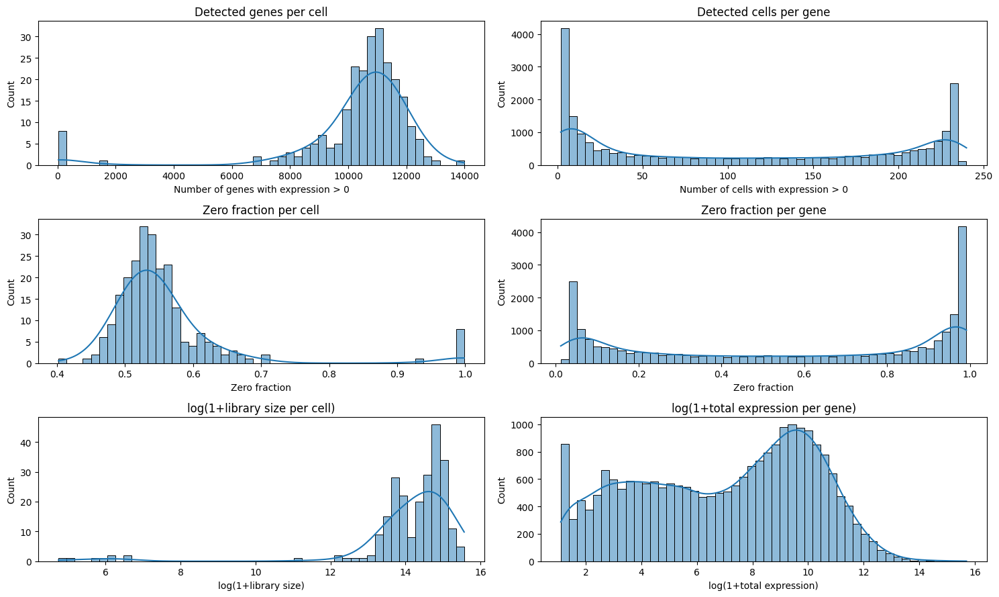

In [7]:
library_size_per_cell = df_expression_by_cell.sum(axis=1)
total_expression_per_gene = df_expression_by_cell.sum(axis=0)

detected_genes_per_cell = df_expression_by_cell.gt(0).sum(axis=1)
detected_cells_per_gene = df_expression_by_cell.gt(0).sum(axis=0)

zero_fraction_per_cell = df_expression_by_cell.eq(0).mean(axis=1)
zero_fraction_per_gene = df_expression_by_cell.eq(0).mean(axis=0)

mean_nonzero_expression_per_cell = df_expression_by_cell.where(df_expression_by_cell > 0).mean(axis=1)
median_nonzero_expression_per_cell = df_expression_by_cell.where(df_expression_by_cell > 0).median(axis=1)
mean_nonzero_expression_per_gene = df_expression_by_cell.where(df_expression_by_cell > 0).mean(axis=0)
median_nonzero_expression_per_gene = df_expression_by_cell.where(df_expression_by_cell > 0).median(axis=0)

cell_expression_qc = pd.DataFrame({
    "library_size": library_size_per_cell,
    "detected_genes": detected_genes_per_cell,
    "zero_fraction": zero_fraction_per_cell,
    "mean_nonzero_expression": mean_nonzero_expression_per_cell,
    "median_nonzero_expression": median_nonzero_expression_per_cell,
})

gene_expression_qc = pd.DataFrame({
    "total_expression": total_expression_per_gene,
    "detected_cells": detected_cells_per_gene,
    "detected_cell_fraction": detected_cells_per_gene / len(df_expression_by_cell),
    "zero_fraction": zero_fraction_per_gene,
    "mean_nonzero_expression": mean_nonzero_expression_per_gene,
    "median_nonzero_expression": median_nonzero_expression_per_gene,
})

print("Cell-level expression QC summary:")
display(cell_expression_qc.describe())
print("Cells with fewest detected genes:")
display(cell_expression_qc.sort_values("detected_genes").head(10))
print("Cells with highest zero fraction:")
display(cell_expression_qc.sort_values("zero_fraction", ascending=False).head(10))

print("Gene-level expression QC summary:")
display(gene_expression_qc.describe())
print("Genes detected in fewest cells:")
display(gene_expression_qc.sort_values("detected_cells").head(10))
print("Genes detected in most cells:")
display(gene_expression_qc.sort_values("detected_cells", ascending=False).head(10))



fig, axes = plt.subplots(3,2, figsize=(15, 9))
sns.histplot(detected_genes_per_cell, bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Detected genes per cell")
axes[0, 0].set_xlabel("Number of genes with expression > 0")
sns.histplot(detected_cells_per_gene, bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Detected cells per gene")
axes[0, 1].set_xlabel("Number of cells with expression > 0")
sns.histplot(zero_fraction_per_cell, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Zero fraction per cell")
axes[1, 0].set_xlabel("Zero fraction")
sns.histplot(zero_fraction_per_gene, bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Zero fraction per gene")
axes[1, 1].set_xlabel("Zero fraction")
sns.histplot(np.log1p(library_size_per_cell), bins=50, kde=True, ax=axes[2, 0])
axes[2, 0].set_title("log(1+library size per cell)")
axes[2, 0].set_xlabel("log(1+library size)")
sns.histplot(np.log1p(total_expression_per_gene), bins=50, kde=True, ax=axes[2, 1])
axes[2, 1].set_title("log(1+total expression per gene)")
axes[2, 1].set_xlabel("log(1+total expression)")
plt.tight_layout()
plt.show()




The cell-level and gene-level summaries quantify sparsity more directly than total expression alone. Detected genes per cell tells us how many genes are actually observed in each cell, while detected cells per gene tells us whether a gene is broadly expressed or only appears in a small subset of cells.

Most cells express a large number of genes, but there is also a small group of cells with very few detected genes and very high zero fraction. These cells are likely weakly captured or low-quality observations. At the gene level, the situation is even more heterogeneous: some genes are detected in many cells, while many others are zero in most cells. This is expected in single-cell RNA-seq data, where expression is naturally sparse and many genes are expressed only in specific cell states.

The library-size plots also show that expression coverage is not uniform across cells or genes. Overall, these plots confirm that the raw matrix contains substantial sparsity and uneven sequencing depth, which justifies the later filtering and normalization steps.


In [8]:
# 3. Metadata sanity checks for cells

metadata_sanity_table = df_metadata_raw.copy()

sanity_flags = pd.DataFrame(index=df_metadata_raw.index)

if "Hours" in df_metadata_raw.columns:
    hours = pd.to_numeric(df_metadata_raw["Hours"], errors="coerce")
    
    sanity_flags["hours_not_24"] = hours.notna() & (hours != 24)

if "Condition" in df_metadata_raw.columns:
    condition = df_metadata_raw["Condition"].astype(str).str.strip().str.lower()
    
    expected_conditions = ["hypo", "hypoxia", "normo", "normoxia"]
    
    sanity_flags["unexpected_condition"] = (
        ~condition.isin(expected_conditions)
        & ~condition.isin(["", "nan", "none"])
    )

if "Cell Line" in df_metadata_raw.columns:
    cell_line = df_metadata_raw["Cell Line"].astype(str).str.strip()
    
    sanity_flags["unexpected_cell_line"] = (
        cell_line.notna()
        & (cell_line != "HCC1806")
        & (cell_line.str.lower() != "nan")
    )

if "PCR Plate" in df_metadata_raw.columns:
    pcr_plate = pd.to_numeric(df_metadata_raw["PCR Plate"], errors="coerce")
    
    sanity_flags["invalid_pcr_plate"] = pcr_plate.notna() & (pcr_plate <= 0)

if "Pos" in df_metadata_raw.columns:
    pos = df_metadata_raw["Pos"].astype(str).str.strip()
    
    valid_position = pos.str.match(r"^[A-H](?:[1-9]|1[0-2])$")
    
    sanity_flags["unexpected_plate_position"] = (
        ~valid_position
        & ~pos.str.lower().isin(["", "nan", "none"])
    )

if sanity_flags.shape[1] > 0:
    metadata_sanity_table["has_metadata_problem"] = sanity_flags.any(axis=1)

    metadata_sanity_table["metadata_problem"] = sanity_flags.apply(
        lambda row: ", ".join(row.index[row]) if row.any() else "ok",
        axis=1
    )
else:
    metadata_sanity_table["has_metadata_problem"] = False
    metadata_sanity_table["metadata_problem"] = "ok"

if "Filename" in df_metadata_raw.columns:
    metadata_sanity_table["cell_id"] = df_metadata_raw["Filename"].astype(str)
else:
    metadata_sanity_table["cell_id"] = df_metadata_raw.index.astype(str)

problematic_metadata_cells = metadata_sanity_table[
    metadata_sanity_table["has_metadata_problem"]
].copy()

print("Metadata sanity check counts:")
display(metadata_sanity_table["metadata_problem"].value_counts().to_frame("n_cells"))

print("Number of problematic metadata cells:", len(problematic_metadata_cells))

if len(problematic_metadata_cells) > 0:
    display(problematic_metadata_cells)



Metadata sanity check counts:


,n_cells
metadata_problem,
ok,243


Number of problematic metadata cells: 0


The metadata sanity checks look for values that would contradict the experimental design, such as unexpected conditions, invalid plate positions, or inconsistent cell-line annotations. This is important because a mislabeled cell can look biologically interesting while actually being a technical or bookkeeping issue.

Since the annotations are consistent, we can trust the metadata enough to use it for later comparisons between hypoxia and normoxia.


Mitochondrial genes found: 36
Fixed high mitochondrial threshold: 0.2
Top 5% mitochondrial threshold: 0.03696058965809396
Problematic cells with high mitochondrial expression:
Number of high mitochondrial cells: 13


,library_size,detected_genes,zero_fraction,mean_nonzero_expression,median_nonzero_expression,mitochondrial_expression,mitochondrial_fraction,above_20pct_mito,top_5pct_mito,high_mitochondrial_flag,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments,Technology
Cell,,,,,,,,,,,,,,,,,,,,
output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.sortedByCoord.out.bam,510,81,0.996538,6.296296,1.0,251,0.492157,True,True,True,output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.s...,HCC1806,3,D2,Hypoxia,24,S168,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate1G6_Hypoxia_S15_Aligned.sortedByCoord.out.bam,74004,6962,0.702428,10.629704,2.0,5754,0.077753,False,True,True,output.STAR.PCRPlate1G6_Hypoxia_S15_Aligned.so...,HCC1806,1,G6,Hypoxia,24,S15,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate4B1_Hypoxia_S221_Aligned.sortedByCoord.out.bam,218240,6919,0.704266,31.542130,6.0,14835,0.067976,False,True,True,output.STAR.PCRPlate4B1_Hypoxia_S221_Aligned.s...,HCC1806,4,B1,Hypoxia,24,S221,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate2G10_Normoxia_S157_Aligned.sortedByCoord.out.bam,479324,1583,0.932339,302.794694,77.0,24186,0.050459,False,True,True,output.STAR.PCRPlate2G10_Normoxia_S157_Aligned...,HCC1806,2,G10,Normoxia,24,S157,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate2C1_Hypoxia_S131_Aligned.sortedByCoord.out.bam,1035257,8360,0.642674,123.834569,38.0,50394,0.048678,False,True,True,output.STAR.PCRPlate2C1_Hypoxia_S131_Aligned.s...,HCC1806,2,C1,Hypoxia,24,S131,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate1H6_Hypoxia_S16_Aligned.sortedByCoord.out.bam,3621779,9779,0.582023,370.362921,154.0,162526,0.044875,False,True,True,output.STAR.PCRPlate1H6_Hypoxia_S16_Aligned.so...,HCC1806,1,H6,Hypoxia,24,S16,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate3G6_Hypoxia_S181_Aligned.sortedByCoord.out.bam,2464014,11459,0.510215,215.028711,68.0,103965,0.042193,False,True,True,output.STAR.PCRPlate3G6_Hypoxia_S181_Aligned.s...,HCC1806,3,G6,Hypoxia,24,S181,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate2G7_Normoxia_S150_Aligned.sortedByCoord.out.bam,2900163,9747,0.583390,297.544167,85.0,113708,0.039207,False,True,True,output.STAR.PCRPlate2G7_Normoxia_S150_Aligned....,HCC1806,2,G7,Normoxia,24,S150,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate2F1_Hypoxia_S133_Aligned.sortedByCoord.out.bam,3774972,8924,0.618567,423.013447,121.0,148004,0.039207,False,True,True,output.STAR.PCRPlate2F1_Hypoxia_S133_Aligned.s...,HCC1806,2,F1,Hypoxia,24,S133,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq


Top 20 cells by mitochondrial fraction, for inspection:


,library_size,detected_genes,zero_fraction,mean_nonzero_expression,median_nonzero_expression,mitochondrial_expression,mitochondrial_fraction,above_20pct_mito,top_5pct_mito,high_mitochondrial_flag,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments,Technology
Cell,,,,,,,,,,,,,,,,,,,,
output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.sortedByCoord.out.bam,510,81,0.996538,6.296296,1.0,251,0.492157,True,True,True,output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.s...,HCC1806,3,D2,Hypoxia,24,S168,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate1G6_Hypoxia_S15_Aligned.sortedByCoord.out.bam,74004,6962,0.702428,10.629704,2.0,5754,0.077753,False,True,True,output.STAR.PCRPlate1G6_Hypoxia_S15_Aligned.so...,HCC1806,1,G6,Hypoxia,24,S15,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate4B1_Hypoxia_S221_Aligned.sortedByCoord.out.bam,218240,6919,0.704266,31.542130,6.0,14835,0.067976,False,True,True,output.STAR.PCRPlate4B1_Hypoxia_S221_Aligned.s...,HCC1806,4,B1,Hypoxia,24,S221,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate2G10_Normoxia_S157_Aligned.sortedByCoord.out.bam,479324,1583,0.932339,302.794694,77.0,24186,0.050459,False,True,True,output.STAR.PCRPlate2G10_Normoxia_S157_Aligned...,HCC1806,2,G10,Normoxia,24,S157,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate2C1_Hypoxia_S131_Aligned.sortedByCoord.out.bam,1035257,8360,0.642674,123.834569,38.0,50394,0.048678,False,True,True,output.STAR.PCRPlate2C1_Hypoxia_S131_Aligned.s...,HCC1806,2,C1,Hypoxia,24,S131,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate1H6_Hypoxia_S16_Aligned.sortedByCoord.out.bam,3621779,9779,0.582023,370.362921,154.0,162526,0.044875,False,True,True,output.STAR.PCRPlate1H6_Hypoxia_S16_Aligned.so...,HCC1806,1,H6,Hypoxia,24,S16,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate3G6_Hypoxia_S181_Aligned.sortedByCoord.out.bam,2464014,11459,0.510215,215.028711,68.0,103965,0.042193,False,True,True,output.STAR.PCRPlate3G6_Hypoxia_S181_Aligned.s...,HCC1806,3,G6,Hypoxia,24,S181,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate2G7_Normoxia_S150_Aligned.sortedByCoord.out.bam,2900163,9747,0.583390,297.544167,85.0,113708,0.039207,False,True,True,output.STAR.PCRPlate2G7_Normoxia_S150_Aligned....,HCC1806,2,G7,Normoxia,24,S150,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq
output.STAR.PCRPlate2F1_Hypoxia_S133_Aligned.sortedByCoord.out.bam,3774972,8924,0.618567,423.013447,121.0,148004,0.039207,False,True,True,output.STAR.PCRPlate2F1_Hypoxia_S133_Aligned.s...,HCC1806,2,F1,Hypoxia,24,S133,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq


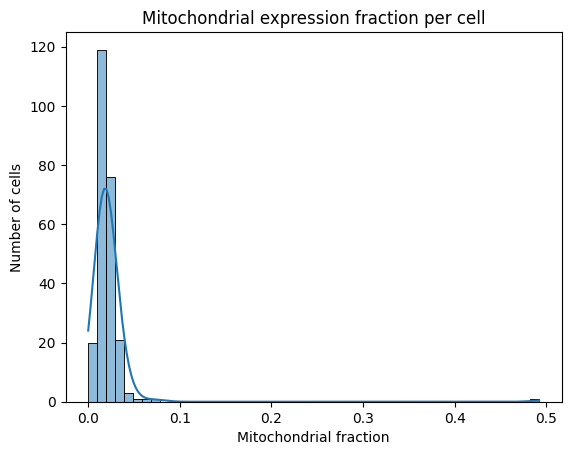

In [9]:
mitochondrial_fraction_fixed_threshold = 0.20
mitochondrial_fraction_top_quantile = 0.95
mitochondrial_genes = [gene for gene in df_expression_by_cell.columns if str(gene).upper().startswith("MT-")]

mitochondrial_expression_per_cell = df_expression_by_cell[mitochondrial_genes].sum(axis=1)
mitochondrial_fraction_per_cell = mitochondrial_expression_per_cell / library_size_per_cell.replace(0, np.nan)

mitochondrial_qc = cell_expression_qc.copy()
mitochondrial_qc["mitochondrial_expression"] = mitochondrial_expression_per_cell
mitochondrial_qc["mitochondrial_fraction"] = mitochondrial_fraction_per_cell
mitochondrial_fraction_quantile_threshold = mitochondrial_fraction_per_cell.quantile(mitochondrial_fraction_top_quantile)
mitochondrial_qc["above_20pct_mito"] = mitochondrial_qc["mitochondrial_fraction"] >= mitochondrial_fraction_fixed_threshold
mitochondrial_qc["top_5pct_mito"] = mitochondrial_qc["mitochondrial_fraction"] >= mitochondrial_fraction_quantile_threshold
mitochondrial_qc["high_mitochondrial_flag"] = mitochondrial_qc["above_20pct_mito"] | mitochondrial_qc["top_5pct_mito"]

metadata_for_qc = df_metadata_raw.copy()
if "Filename" in metadata_for_qc.columns:
    metadata_for_qc.index = metadata_for_qc["Filename"].astype(str)

mitochondrial_qc_with_metadata = mitochondrial_qc.join(metadata_for_qc, how="left")
high_mitochondrial_cells = mitochondrial_qc_with_metadata[mitochondrial_qc_with_metadata["high_mitochondrial_flag"]]
high_mitochondrial_cells = high_mitochondrial_cells.sort_values("mitochondrial_fraction", ascending=False)
top_mitochondrial_cells = mitochondrial_qc_with_metadata.sort_values("mitochondrial_fraction", ascending=False).head(20)

print("Mitochondrial genes found:", len(mitochondrial_genes))
print("Fixed high mitochondrial threshold:", mitochondrial_fraction_fixed_threshold)
print("Top 5% mitochondrial threshold:", mitochondrial_fraction_quantile_threshold)
print("Problematic cells with high mitochondrial expression:")
print("Number of high mitochondrial cells:", len(high_mitochondrial_cells))
display(high_mitochondrial_cells)
print("Top 20 cells by mitochondrial fraction, for inspection:")
display(top_mitochondrial_cells.head(10))

sns.histplot(mitochondrial_fraction_per_cell, bins=50, kde=True)
plt.title("Mitochondrial expression fraction per cell")
plt.xlabel("Mitochondrial fraction")
plt.ylabel("Number of cells")
plt.show()


Mitochondrial expression is used as a stress and cell-quality indicator. Cells with a very high mitochondrial fraction can reflect damaged, stressed, or dying cells, so they are listed explicitly rather than silently removed. This keeps the raw analysis transparent before interpreting the filtering step.

This check is also biologically relevant for this project. Since the experiment compares hypoxia and normoxia, we want to understand whether cells showing signs of stress or reduced viability are more common under low-oxygen conditions. In other words, high mitochondrial expression may be both a technical quality-control signal and a possible indication of hypoxia-related cellular stress.


Redundant cell annotations:
No duplicate filenames, cell names, or plate positions found.
Highly similar cell pairs based on log1p expression correlation:
Similarity threshold: 0.98
No cell pairs above the similarity threshold.
Top 20 most similar cell pairs:


,cell_1,cell_2,correlation
16207,output.STAR.PCRPlate2C12_Normoxia_S59_Aligned....,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,0.978046
15954,output.STAR.PCRPlate2C10_Normoxia_S154_Aligned...,output.STAR.PCRPlate3D9_Normoxia_S86_Aligned.s...,0.835410
10128,output.STAR.PCRPlate1F8_Normoxia_S18_Aligned.s...,output.STAR.PCRPlate2C10_Normoxia_S154_Aligned...,0.828657
10210,output.STAR.PCRPlate1F8_Normoxia_S18_Aligned.s...,output.STAR.PCRPlate3D9_Normoxia_S86_Aligned.s...,0.827604
17327,output.STAR.PCRPlate2C8_Normoxia_S49_Aligned.s...,output.STAR.PCRPlate2E8_Normoxia_S50_Aligned.s...,0.818519
27928,output.STAR.PCRPlate3H10_Normoxia_S192_Aligned...,output.STAR.PCRPlate4A8_Normoxia_S206_Aligned....,0.818173
15492,output.STAR.PCRPlate2B4_Hypoxia_S139_Aligned.s...,output.STAR.PCRPlate3H6_Hypoxia_S182_Aligned.s...,0.815097
8164,output.STAR.PCRPlate1E12_Normoxia_S30_Aligned....,output.STAR.PCRPlate2G9_Normoxia_S56_Aligned.s...,0.814057
28495,output.STAR.PCRPlate4A8_Normoxia_S206_Aligned....,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned...,0.813955
26008,output.STAR.PCRPlate3D9_Normoxia_S86_Aligned.s...,output.STAR.PCRPlate3F10_Normoxia_S190_Aligned...,0.813429


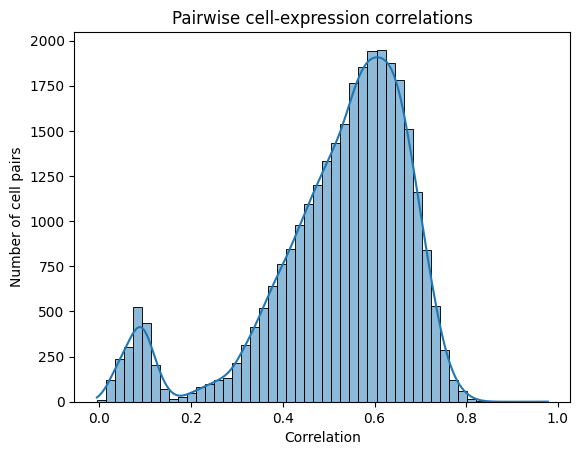

In [10]:
redundant_annotation_cells, cell_similarity_pairs, highly_similar_cells = check_redundant_cells(
    expression=df_expression_by_cell,
    metadata=df_metadata_raw,
    cell_similarity_threshold=0.98,
    n_variable_genes_for_similarity=3000
)

print("Redundant cell annotations:")
if len(redundant_annotation_cells) == 0:
    print("No duplicate filenames, cell names, or plate positions found.")
else:
    display(redundant_annotation_cells)

print("Highly similar cell pairs based on log1p expression correlation:")
print("Similarity threshold:", 0.98)

if len(highly_similar_cells) == 0:
    print("No cell pairs above the similarity threshold.")
    print("Top 20 most similar cell pairs:")
    display(cell_similarity_pairs.sort_values("correlation", ascending=False).head(20))
else:
    display(highly_similar_cells)

sns.histplot(cell_similarity_pairs["correlation"], bins=50, kde=True)
plt.title("Pairwise cell-expression correlations")
plt.xlabel("Correlation")
plt.ylabel("Number of cell pairs")
plt.show()


The redundancy and similarity checks ask whether some cells may be duplicated or almost identical. Exact duplicate filenames, duplicate cell names, or duplicate plate positions would suggest annotation problems. Very high expression correlation between two cells would not necessarily prove duplication, but it would be a warning that two profiles are unusually similar.

In this case, the checks do not indicate obvious redundant cells. This suggests that the raw dataset does not contain clear duplicated observations, although some low-quality cells are still present.


Gene expression skewness:


,skewness
count,23396.000000
mean,5.511046
std,3.960326
min,0.421378
25%,2.339370
50%,4.030633
75%,8.084277
max,15.588227


Top 20 most right-skewed genes:


,skewness
Gene,
SYNPO2L,15.588227
TMPRSS11F,15.588194
PASD1,15.588028
GBP5,15.587944
DHH,15.587682
NXF3,15.587189
MARK2P9,15.586291
ATP1A2,15.586161
C19orf38,15.586115


Top 20 most left-skewed genes:


,skewness
Gene,
ST13,0.711231
RPL15,0.702309
VPS35,0.696887
NUTF2,0.696468
HMGN1,0.660054
UBE2I,0.653194
SRSF9,0.631314
TMEM183A,0.625365
YWHAE,0.617604


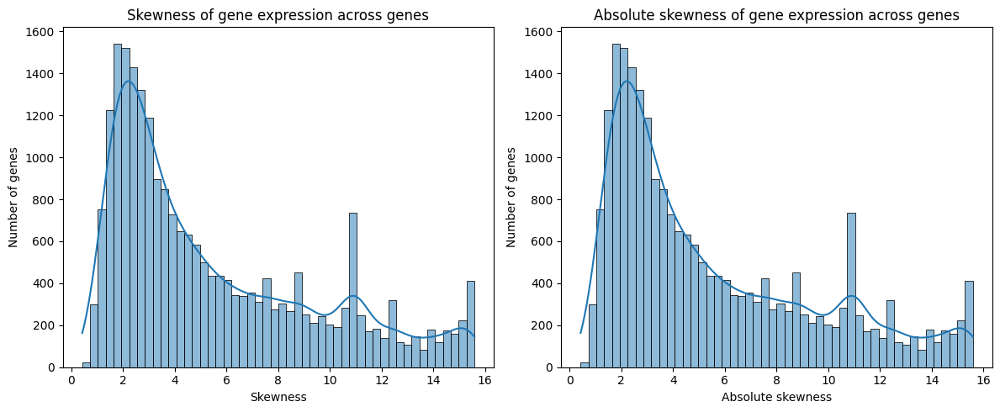

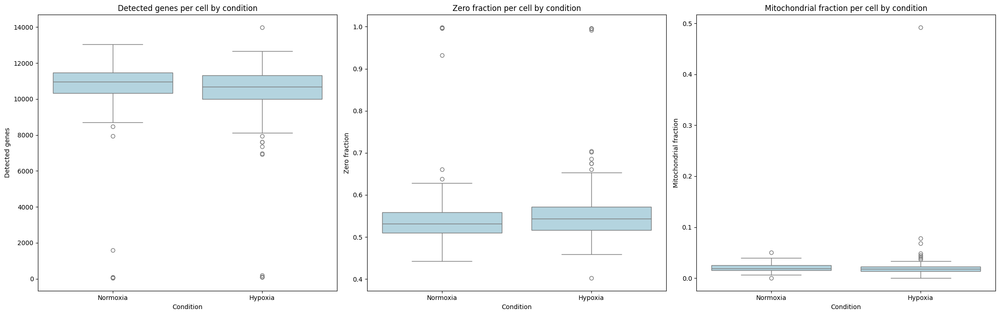

In [11]:
gene_expression_skewness = df_expression_by_cell.skew(axis=0).sort_values(ascending=False)
gene_skewness_summary = gene_expression_skewness.to_frame("skewness")

print("Gene expression skewness:")
display(gene_skewness_summary.describe())
print("Top 20 most right-skewed genes:")
display(gene_skewness_summary.head(20))
print("Top 20 most left-skewed genes:")
display(gene_skewness_summary.tail(20))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(gene_expression_skewness, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Skewness of gene expression across genes")
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Number of genes")
sns.histplot(gene_expression_skewness.abs(), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Absolute skewness of gene expression across genes")
axes[1].set_xlabel("Absolute skewness")
axes[1].set_ylabel("Number of genes")
plt.tight_layout()
plt.show()



if "Condition" in df_metadata_raw.columns:
    condition_plot_data = pd.DataFrame({
        "Condition": df_metadata_raw["Condition"].values,
        "Detected genes": detected_genes_per_cell.values,
        "Zero fraction": zero_fraction_per_cell.values,
        "Mitochondrial fraction": mitochondrial_fraction_per_cell.values,
    })
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    sns.boxplot(data=condition_plot_data, x="Condition", y="Detected genes", color = 'lightblue', ax=axes[0])
    axes[0].set_title("Detected genes per cell by condition")
    axes[0].set_xlabel("Condition")
    axes[0].set_ylabel("Detected genes")
    sns.boxplot(data=condition_plot_data, x="Condition", y="Zero fraction", color = 'lightblue', ax=axes[1])
    axes[1].set_title("Zero fraction per cell by condition")
    axes[1].set_xlabel("Condition")
    axes[1].set_ylabel("Zero fraction")
    sns.boxplot(data=condition_plot_data, x="Condition", y="Mitochondrial fraction", color = 'lightblue', ax=axes[2])
    axes[2].set_title("Mitochondrial fraction per cell by condition")
    axes[2].set_xlabel("Condition") 
    axes[2].set_ylabel("Mitochondrial fraction")
    plt.tight_layout()
    plt.show()

    

Gene skewness describes how unevenly each gene is expressed across cells. A strongly right-skewed gene is silent or lowly expressed in most cells but highly expressed in a small subset of them. This behaviour is very common in single-cell data.

This is important because many downstream methods, such as PCA or clustering, are sensitive to extreme values and skewed distributions. The skewness analysis therefore motivates the use of transformations such as log1p before dimensionality reduction.


Overall, the raw HCC1806 SmartSeq matrix contains all 243 cells and more than twenty thousand genes. The metadata are complete and consistent, so the main issues are found in the expression matrix rather than in the annotations.

The raw data show clear sparsity and strong heterogeneity. Most cells express many genes, but a small number of cells have very few detected genes and almost all-zero profiles. These cells are likely to be low-quality or weakly captured observations. Mitochondrial expression also highlights possible stressed or damaged cells, with a few clear outliers.

No obvious duplicate annotations or highly redundant cell profiles are detected. Therefore, the raw data contain useful biological signal, but they also contain the typical technical issues of single-cell RNA-seq data: low-quality cells, rare genes, sparsity, uneven library sizes, and skewed expression values. These observations motivate the filtering and transformation steps that follow.


<a id="filtering-effects-raw-vs-filtered-hcc1806-smartseq"></a>
### **Filtering Effects: Raw vs Filtered HCC1806 SmartSeq**

This section studies what changes when moving from the raw HCC1806 SmartSeq matrix to the filtered one. The goal is not only to see that filtering removed cells and genes, but also to understand why those elements were likely removed.

Filtering is a crucial preprocessing step in single-cell RNA-seq analysis. It removes cells with poor expression quality and genes that are not informative enough for downstream analysis. If this step is too aggressive, it may remove useful biological signal; if it is too weak, it may leave too much technical noise in the dataset. For this reason, we inspect the filtering effect explicitly.


<a id="filtered-data"></a>
#### *Filtered Data*

In this section, we load the filtered HCC1806 SmartSeq matrix and compare it with the raw matrix. The filtered data contain fewer cells and fewer genes, which means that some low-quality cells and low-information genes have been removed.

The filtered matrix should therefore be cleaner than the raw one, but still close enough to the original data to preserve meaningful biological differences between hypoxia and normoxia.


In [12]:
df_HSF_counts = read_counts_matrix(hcc_smart_filtered_path)

df_HSF_expression = df_HSF_counts.T.copy()
df_HSF_expression.index.name = "Filename"
df_HSF_expression.columns.name = "Gene"

common_cells = pd.Index(df_HSF_expression.index).intersection(
    pd.Index(df_HCC_metadata["Filename"])
)

df_HSF_expression = df_HSF_expression.loc[common_cells]

df_HCC_metadata_HSF = (
    df_HCC_metadata
    .set_index("Filename")
    .loc[common_cells]
    .reset_index()
)

df_HSF_merged = make_display_merged_table(
    expression=df_HSF_expression,
    metadata=df_HCC_metadata_HSF,
    max_genes=df_HSF_expression.shape[1]
)

df_HSF_counts_by_cell = df_HSF_expression.reset_index()

print(f"Metadata samples: {len(df_HCC_metadata):,}")
print(f"Expression samples: {len(df_HSF_expression):,}")
print(f"Merged samples: {len(df_HSF_merged):,}")
print(f"Genes: {df_HSF_counts.shape[0]:,}")

df_HSF_merged.head()

Metadata samples: 243
Expression samples: 227
Merged samples: 227
Genes: 19,503


,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments,Technology,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,MT-TP,MAFIP
0,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned...,HCC1806,1,A10,Normoxia,24,S123,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,17,5,15,3852,900,22,4208,26,66,0
1,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned....,HCC1806,1,A12,Normoxia,24,S26,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,49,29,36,7457,1439,43,6491,62,71,4
2,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.s...,HCC1806,1,A2,Hypoxia,24,S104,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,43,17,8,1479,234,0,4819,11,3,7
3,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sor...,HCC1806,1,A3,Hypoxia,24,S4,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,0,0,3,303,33,0,310,4,9,0
4,output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sor...,HCC1806,1,A4,Hypoxia,24,S8,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",SmartSeq,...,1,0,0,650,79,3,695,0,14,9


The filtered matrix is transposed so that cells are represented as rows and genes as columns. This orientation is easier to use for cell-level quality control, because each row now corresponds to one cell profile.

The metadata are then aligned to the filtered expression matrix using the cell filename. This keeps the expression values and the cell annotations in the same order, which is essential for all condition-based comparisons.


<a id="cells-removed"></a>
#### *Cells Removed*

This section identifies which cells are present in the raw matrix but missing from the filtered matrix. These cells are important because they tell us what kind of observations filtering removed.

Most of the removed cells have very low numbers of detected genes and very high sparsity. This supports the idea that filtering mainly removed low-quality cells rather than randomly excluding good observations.


In [13]:
missing_cells = set(df_HSU_expression.index) - set(df_HSF_expression.index)

print(f"Cells in unfiltered but missing in filtered data: {len(missing_cells)}")

missing_cells_df = (
    pd.DataFrame(sorted(missing_cells), columns=["Filename"])
    .merge(df_HCC_metadata[["Filename", "Condition", "PCR Plate", "Pos", "Cell name"]],
           on="Filename",
           how="left")
)

display(missing_cells_df.head(16))

Cells in unfiltered but missing in filtered data: 16


,Filename,Condition,PCR Plate,Pos,Cell name
0,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.so...,Hypoxia,1,A1,S97
1,output.STAR.PCRPlate1B1_Hypoxia_S98_Aligned.so...,Hypoxia,1,B1,S98
2,output.STAR.PCRPlate1B4_Hypoxia_S105_Aligned.s...,Hypoxia,1,B4,S105
3,output.STAR.PCRPlate1D3_Hypoxia_S6_Aligned.sor...,Hypoxia,1,D3,S6
4,output.STAR.PCRPlate1F8_Normoxia_S18_Aligned.s...,Normoxia,1,F8,S18
5,output.STAR.PCRPlate1G6_Hypoxia_S15_Aligned.so...,Hypoxia,1,G6,S15
6,output.STAR.PCRPlate2E12_Normoxia_S61_Aligned....,Normoxia,2,E12,S61
7,output.STAR.PCRPlate2F12_Normoxia_S62_Aligned....,Normoxia,2,F12,S62
8,output.STAR.PCRPlate2G10_Normoxia_S157_Aligned...,Normoxia,2,G10,S157
9,output.STAR.PCRPlate2H2_Hypoxia_S35_Aligned.so...,Hypoxia,2,H2,S35


To understand why cells were removed, we count how many genes are expressed in each removed cell. The hypothesis is simple: if filtering is working as expected, many removed cells should have unusually low numbers of detected genes.


In [14]:
genes_expressed = (df_HSU_expression.reindex(sorted(missing_cells)).gt(0).sum(axis=1))
genes_expressed_sorted = (
    pd.DataFrame({
        "Filename": genes_expressed.index,
        "Genes expressed": genes_expressed.values
    }).sort_values("Genes expressed").reset_index(drop=True))

display(genes_expressed_sorted.head(15))

,Filename,Genes expressed
0,output.STAR.PCRPlate3D11_Normoxia_S92_Aligned....,35
1,output.STAR.PCRPlate2E12_Normoxia_S61_Aligned....,67
2,output.STAR.PCRPlate3D10_Normoxia_S188_Aligned...,71
3,output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.s...,81
4,output.STAR.PCRPlate2F12_Normoxia_S62_Aligned....,85
5,output.STAR.PCRPlate3D3_Hypoxia_S72_Aligned.so...,96
6,output.STAR.PCRPlate1B1_Hypoxia_S98_Aligned.so...,117
7,output.STAR.PCRPlate3D5_Hypoxia_S78_Aligned.so...,185
8,output.STAR.PCRPlate2G10_Normoxia_S157_Aligned...,1583
9,output.STAR.PCRPlate4B1_Hypoxia_S221_Aligned.s...,6919


We then compare the removed cells with the full distribution of detected genes in the raw matrix. This allows us to check whether the removed cells are outliers with respect to the rest of the dataset.


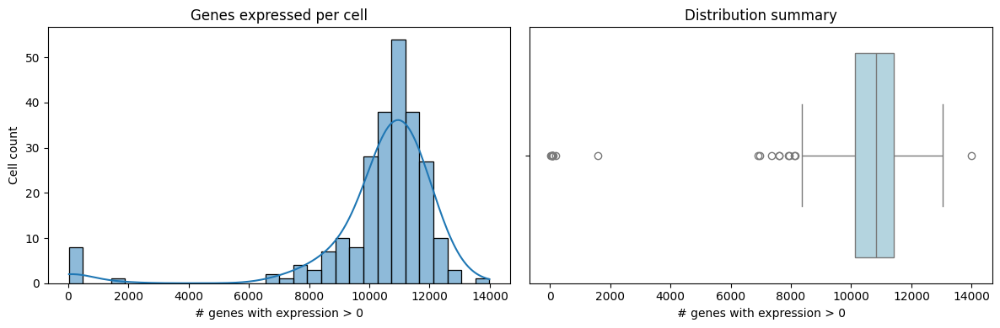

In [15]:
genes_expressed_all = (df_HSU_expression).gt(0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(genes_expressed_all, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Genes expressed per cell")
axes[0].set_xlabel("# genes with expression > 0")
axes[0].set_ylabel("Cell count")

sns.boxplot(x=genes_expressed_all, ax=axes[1], color = 'lightblue')
axes[1].set_title("Distribution summary")
axes[1].set_xlabel("# genes with expression > 0")

plt.tight_layout()

The distribution shows that most cells express thousands of genes, while a small group has extremely low gene detection. These low-detection cells are exactly the kind of observations that can distort downstream analysis if they are kept.


In [16]:
lowest_16 = genes_expressed_all.nsmallest(16).reset_index()
lowest_16.columns = ["Filename", "genes_expressed"]
display(lowest_16)

,Filename,genes_expressed
0,output.STAR.PCRPlate3D11_Normoxia_S92_Aligned....,35
1,output.STAR.PCRPlate2E12_Normoxia_S61_Aligned....,67
2,output.STAR.PCRPlate3D10_Normoxia_S188_Aligned...,71
3,output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.s...,81
4,output.STAR.PCRPlate2F12_Normoxia_S62_Aligned....,85
5,output.STAR.PCRPlate3D3_Hypoxia_S72_Aligned.so...,96
6,output.STAR.PCRPlate1B1_Hypoxia_S98_Aligned.so...,117
7,output.STAR.PCRPlate3D5_Hypoxia_S78_Aligned.so...,185
8,output.STAR.PCRPlate2G10_Normoxia_S157_Aligned...,1583
9,output.STAR.PCRPlate4B1_Hypoxia_S221_Aligned.s...,6919


By comparing the removed cells with the cells that have the lowest detected-gene counts, we see that many of them overlap. This confirms that filtering removed several cells with very weak expression profiles.


In [17]:
highest_16 = genes_expressed_all.nlargest(5).reset_index()
highest_16.columns = ["Filename", "genes_expressed"]
display(highest_16)

,Filename,genes_expressed
0,output.STAR.PCRPlate1D3_Hypoxia_S6_Aligned.sor...,13986
1,output.STAR.PCRPlate1F8_Normoxia_S18_Aligned.s...,13029
2,output.STAR.PCRPlate3A9_Normoxia_S83_Aligned.s...,12698
3,output.STAR.PCRPlate3G1_Hypoxia_S164_Aligned.s...,12660
4,output.STAR.PCRPlate3D9_Normoxia_S86_Aligned.s...,12491


Filtering can also remove cells at the opposite extreme. Some cells may have too many detected genes, which can indicate outlier behaviour or possible technical artifacts. For this reason, both very low and very high detection levels need to be checked.


The sparsity plots provide another view of the same problem. Cell sparsity measures the fraction of genes with zero expression in each cell, while gene sparsity measures the fraction of cells in which each gene is zero.

A cell with a very high zero fraction contains little information and is likely to be low quality. A gene with a very high zero fraction is expressed in very few cells and may not be useful for global downstream analysis.


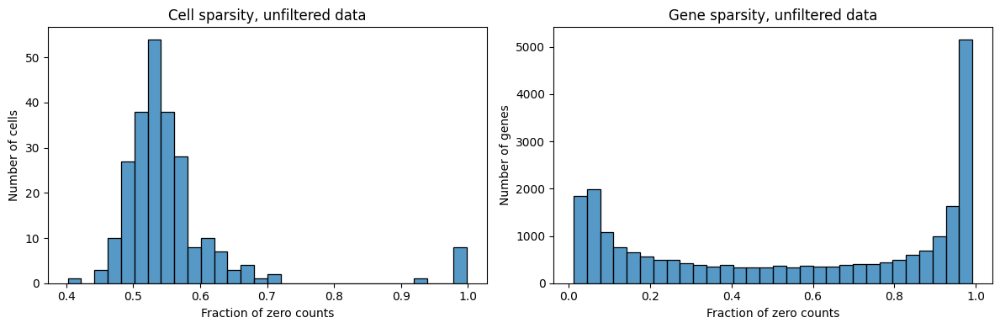

In [18]:
# Sparsity in HCC SmartSeq unfiltered data: fraction of zeros

unfiltered_by_cell = df_HSU_expression.copy()

cell_sparsity = (unfiltered_by_cell == 0).mean(axis=1)
gene_sparsity = (unfiltered_by_cell == 0).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(cell_sparsity, bins=30, ax=axes[0])
axes[0].set_title("Cell sparsity, unfiltered data")
axes[0].set_xlabel("Fraction of zero counts")
axes[0].set_ylabel("Number of cells")

sns.histplot(gene_sparsity, bins=30, ax=axes[1])
axes[1].set_title("Gene sparsity, unfiltered data")
axes[1].set_xlabel("Fraction of zero counts")
axes[1].set_ylabel("Number of genes")

plt.tight_layout()
plt.show()

The cells with the highest zero fraction are inspected directly. This helps confirm whether the cells removed during filtering correspond to profiles that are almost entirely zero.


In [19]:
# Top 5 cells with highest fraction of zeros
cell_zero_frac = (unfiltered_by_cell == 0).mean(axis=1)
top5_zero_frac = cell_zero_frac.nlargest(5).reset_index()
top5_zero_frac.columns = ["Filename", "zero_fraction"]
top5_zero_frac

,Filename,zero_fraction
0,output.STAR.PCRPlate3D11_Normoxia_S92_Aligned....,0.998504
1,output.STAR.PCRPlate2E12_Normoxia_S61_Aligned....,0.997136
2,output.STAR.PCRPlate3D10_Normoxia_S188_Aligned...,0.996965
3,output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.s...,0.996538
4,output.STAR.PCRPlate2F12_Normoxia_S62_Aligned....,0.996367


In [20]:
remaining_cells = ['output.STAR.PCRPlate2H2_Hypoxia_S35_Aligned.sortedByCoord.out.bam', 'output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam', 'output.STAR.PCRPlate1B4_Hypoxia_S105_Aligned.sortedByCoord.out.bam']
for cell in remaining_cells:
    print(f"{cell_zero_frac.loc[cell]:.2%} zeros in {cell}")

52.19% zeros in output.STAR.PCRPlate2H2_Hypoxia_S35_Aligned.sortedByCoord.out.bam
57.74% zeros in output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam
61.46% zeros in output.STAR.PCRPlate1B4_Hypoxia_S105_Aligned.sortedByCoord.out.bam


For the remaining removed cells, we also inspect total expression. This is useful because a cell may have a reasonable number of detected genes but still be an outlier in total count depth.


In [21]:
all_counts = unfiltered_by_cell.sum(axis=1).sort_values() #
print(all_counts.loc[remaining_cells])

Filename
output.STAR.PCRPlate2H2_Hypoxia_S35_Aligned.sortedByCoord.out.bam     5758132
output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam      226818
output.STAR.PCRPlate1B4_Hypoxia_S105_Aligned.sortedByCoord.out.bam     208564
dtype: int64


Filename
output.STAR.PCRPlate2H2_Hypoxia_S35_Aligned.sortedByCoord.out.bam     5758132
output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam      226818
output.STAR.PCRPlate1B4_Hypoxia_S105_Aligned.sortedByCoord.out.bam     208564
dtype: int64

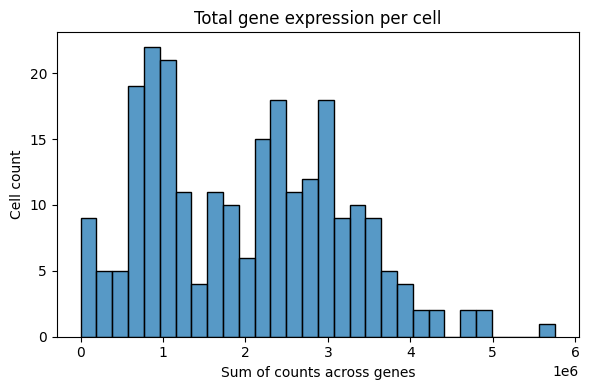

In [22]:
# Gene expression counts per cell (sum across all genes)
cell_gene_counts = unfiltered_by_cell.sum(axis=1)

plt.figure(figsize=(6, 4))
sns.histplot(cell_gene_counts, bins=30)
plt.title("Total gene expression per cell")
plt.xlabel("Sum of counts across genes")
plt.ylabel("Cell count")
plt.tight_layout()

# Show counts for remaining_cells only
remaining_counts = cell_gene_counts.loc[remaining_cells]
remaining_counts

After removing the most obvious low-detection cells, the remaining removed cells are checked again against the distribution of total counts. This helps separate cells removed for low gene detection from cells removed for unusually low or high library size.


In [23]:
cell_gene_counts = unfiltered_by_cell.sum(axis=1)
eligible = genes_expressed_all >= 7000
lowest_5_counts = cell_gene_counts[eligible].nsmallest(5).reset_index()
lowest_5_counts.columns = ["Filename", "total_counts"]
display(lowest_5_counts)

,Filename,total_counts
0,output.STAR.PCRPlate1B4_Hypoxia_S105_Aligned.s...,208564
1,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.so...,226818
2,output.STAR.PCRPlate3D1_Hypoxia_S161_Aligned.s...,342162
3,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,357524
4,output.STAR.PCRPlate4C11_Normoxia_S212_Aligned...,499611


In [24]:
eligible = genes_expressed_all <= 13000
highest_5_counts = cell_gene_counts[eligible].nlargest(5).reset_index()
highest_5_counts.columns = ["Filename", "total_counts"]
display(highest_5_counts)

,Filename,total_counts
0,output.STAR.PCRPlate2H2_Hypoxia_S35_Aligned.so...,5758132
1,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned....,4858841
2,output.STAR.PCRPlate1B12_Normoxia_S27_Aligned....,4844324
3,output.STAR.PCRPlate3H4_Hypoxia_S74_Aligned.so...,4775797
4,output.STAR.PCRPlate2C3_Hypoxia_S38_Aligned.so...,4723635


Overall, the removed cells are mostly explained by quality-control criteria. Several have very low gene detection or very high sparsity, while a smaller number are outliers in the opposite direction. This suggests that filtering mainly removes technically problematic cells.


<a id="genes-removed"></a>
#### *Genes Removed*

This section looks at the genes removed by filtering. In single-cell RNA-seq, many genes are detected in only a few cells or have almost all-zero expression. These genes usually carry little useful information for global structure and can add noise to the analysis.

By comparing raw and filtered gene sets, we can check whether filtering mainly removed rarely detected genes. This helps confirm that the filtered matrix is more suitable for downstream analysis.


In [25]:
removed_genes = set(df_HSU_expression.columns) - set(df_HSF_counts_by_cell.columns)
print(len(removed_genes))

# Check their expression in the unfiltered data
removed_gene_counts = df_HSU_expression[list(removed_genes)].sum(axis=0)
display(removed_gene_counts.describe())
print(f"Genes with zero total counts: {(removed_gene_counts == 0).sum()}")

3893


count    3893.000000
mean       29.470331
std        65.294868
min         2.000000
25%         4.000000
50%        10.000000
75%        31.000000
max      2142.000000
dtype: float64

Genes with zero total counts: 0


In [26]:
all_gene_counts = df_HSU_expression.apply(pd.to_numeric, errors='coerce').sum(axis=0)
display(all_gene_counts.describe())
print(f"Genes with zero total counts: {(all_gene_counts == 0).sum()}")

count    2.339600e+04
mean     2.090060e+04
std      1.024334e+05
min      2.000000e+00
25%      6.800000e+01
50%      1.746500e+03
75%      1.459825e+04
max      6.582141e+06
dtype: float64

Genes with zero total counts: 0


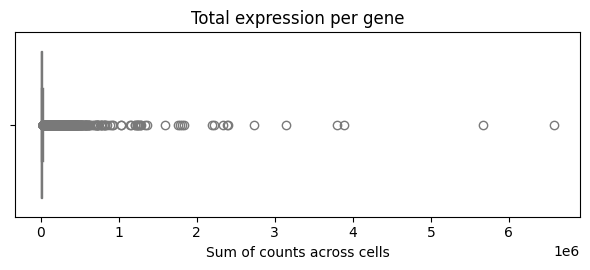

In [27]:
# Boxplot of total expression per gene (sum across cells)
unfiltered_by_cell = (
    df_HSU_expression.set_index("Filename") if "Filename" in df_HSU_expression.columns else df_HSU_expression
  )
gene_total_counts = unfiltered_by_cell.sum(axis=0)

plt.figure(figsize=(6, 2.8))
sns.boxplot(x=gene_total_counts, color = 'lightblue')
plt.title("Total expression per gene")
plt.xlabel("Sum of counts across cells")
plt.tight_layout()

The removed-gene summaries show that filtering mainly affects genes with low total expression and low detection across cells. This is expected: genes that are zero in almost all cells are unlikely to help separate hypoxia from normoxia or identify meaningful cell structure.

At the same time, removing genes reduces the dimensionality of the matrix, which makes later methods more stable and computationally manageable. This is especially important for clustering and dimensionality reduction.


Filtering removes 16 cells and reduces the gene set from 23,396 to 19,503 genes. The removed cells mostly match the quality-control problems visible in the raw data, while the removed genes are mostly weakly expressed or rarely detected.

This confirms that filtering is doing what we expect: it reduces technical noise while keeping the main biological structure of the dataset.


<a id="normalization-effects-filtered-vs-filtered-normalized-hcc1806-smartseq"></a>
### **Normalization Effects: Filtered vs Filtered-Normalized HCC1806 SmartSeq**

After filtering, the next preprocessing step is normalization. Filtering mainly decides which cells and genes are kept, while normalization changes the expression scale so that cells become more comparable.

This step is needed because different cells can have different library sizes, meaning that some cells have much larger total expression simply because they were sequenced more deeply. Without normalization, downstream methods may capture sequencing depth rather than real biological differences.

Here we compare the filtered matrix with the filtered-normalized matrix. The normalized matrix contains the selected 3000 genes used for downstream analysis, so this section also helps us understand how much information was retained after feature selection.


In [28]:
df_HSN_counts = read_counts_matrix(hcc_smart_normalized_path)

df_HSN_expression = df_HSN_counts.T.copy()
df_HSN_expression.index.name = "Filename"
df_HSN_expression.columns.name = "Gene"

common_cells = pd.Index(df_HSN_expression.index).intersection(
    pd.Index(df_HCC_metadata["Filename"])
)

df_HSN_expression = df_HSN_expression.loc[common_cells]

df_HCC_metadata_HSN = (
    df_HCC_metadata
    .set_index("Filename")
    .loc[common_cells]
    .reset_index()
)

df_HCC_metadata_HSN_display = df_HCC_metadata_HSN.drop(columns=["Technology"], errors="ignore")

df_HSN_merged = make_display_merged_table(
    expression=df_HSN_expression,
    metadata=df_HCC_metadata_HSN_display,
    max_genes=df_HSN_expression.shape[1]
)

df_HSN_counts_by_cell = df_HSN_expression.reset_index()

normalised_genes_in_filtered = df_HSN_counts.index[
    df_HSN_counts.index.isin(df_HSF_counts.index)
]

normalised_cells_in_filtered = df_HSN_counts.columns[
    df_HSN_counts.columns.isin(df_HSF_counts.columns)
]

raw_common = df_HSF_counts.loc[
    normalised_genes_in_filtered,
    normalised_cells_in_filtered
]

normalised_common = df_HSN_counts.loc[
    normalised_genes_in_filtered,
    normalised_cells_in_filtered
]

filtered_library_size = df_HSF_counts.sum(axis=0)
filtered_library_size_train_cells = filtered_library_size.loc[normalised_cells_in_filtered]

target_library_size = filtered_library_size.median()
expected_scale_factor = target_library_size / filtered_library_size_train_cells

ratio_normalised_to_raw = normalised_common / raw_common.where(raw_common > 0)

observed_scale_factor = (
    ratio_normalised_to_raw
    .replace([np.inf, -np.inf], np.nan)
    .median(axis=0)
)

expected_normalised_common = raw_common.mul(expected_scale_factor, axis=1)
normalisation_error = normalised_common - expected_normalised_common

raw_3000_gene_sum = raw_common.sum(axis=0)
normalised_3000_gene_sum = normalised_common.sum(axis=0)

normalisation_summary = pd.DataFrame([
    {
        "filtered_genes": df_HSF_counts.shape[0],
        "filtered_cells": df_HSF_counts.shape[1],
        "normalised_train_genes": df_HSN_counts.shape[0],
        "normalised_train_cells": df_HSN_counts.shape[1],
        "normalised_genes_found_in_filtered": len(normalised_genes_in_filtered),
        "normalised_cells_found_in_filtered": len(normalised_cells_in_filtered),
        "target_library_size_median_filtered": target_library_size,
        "median_raw_library_size_train_cells": filtered_library_size_train_cells.median(),
        "median_raw_3000_gene_sum": raw_3000_gene_sum.median(),
        "median_normalised_3000_gene_sum": normalised_3000_gene_sum.median(),
    }
])

normalisation_cell_summary = pd.DataFrame({
    "raw_full_library_size": filtered_library_size_train_cells,
    "raw_3000_gene_sum": raw_3000_gene_sum,
    "normalised_3000_gene_sum": normalised_3000_gene_sum,
    "expected_scale_factor": expected_scale_factor,
    "observed_scale_factor": observed_scale_factor,
})

normalisation_cell_summary["scale_factor_difference"] = (
    normalisation_cell_summary["observed_scale_factor"]
    - normalisation_cell_summary["expected_scale_factor"]
)

normalisation_cell_summary["normalised_vs_raw_3000_sum_ratio"] = (
    normalisation_cell_summary["normalised_3000_gene_sum"]
    / normalisation_cell_summary["raw_3000_gene_sum"].replace(0, np.nan)
)

normalisation_error_summary = pd.DataFrame([
    {
        "mean_absolute_difference": normalisation_error.abs().stack().mean(),
        "median_absolute_difference": normalisation_error.abs().stack().median(),
        "max_absolute_difference": normalisation_error.abs().stack().max(),
        "mean_signed_difference": normalisation_error.stack().mean(),
    }
])

print("The normalised train file is a subset plus scaling:")
display(normalisation_summary)

print("Per-cell scaling check. Observed and expected scale factors should be close if this is simple library-size normalisation:")
display(normalisation_cell_summary.head(20))

print("Cells scaled up the most:")
display(normalisation_cell_summary.sort_values("expected_scale_factor", ascending=False).head(10))

print("Cells scaled down the most:")
display(normalisation_cell_summary.sort_values("expected_scale_factor", ascending=True).head(10))

print("Difference between actual normalised values and expected library-size scaled values:")
display(normalisation_error_summary)

genes_kept_by_normalisation = pd.Index(df_HSN_counts.index)
genes_removed_by_3000_selection = pd.Index(df_HSF_counts.index).difference(
    genes_kept_by_normalisation
)

print("Genes kept in normalised train file:", len(genes_kept_by_normalisation))
print("Genes from filtered file not in normalised train file:", len(genes_removed_by_3000_selection))
print("Example removed genes:")
display(pd.Series(genes_removed_by_3000_selection[:20], name="removed_gene"))

The normalised train file is a subset plus scaling:


,filtered_genes,filtered_cells,normalised_train_genes,normalised_train_cells,normalised_genes_found_in_filtered,normalised_cells_found_in_filtered,target_library_size_median_filtered,median_raw_library_size_train_cells,median_raw_3000_gene_sum,median_normalised_3000_gene_sum
0,19503,227,3000,182,3000,182,2157007.0,1974784.5,431072.5,497586.5


Per-cell scaling check. Observed and expected scale factors should be close if this is simple library-size normalisation:


,raw_full_library_size,raw_3000_gene_sum,normalised_3000_gene_sum,expected_scale_factor,observed_scale_factor,scale_factor_difference,normalised_vs_raw_3000_sum_ratio
output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,3159401,656745,448059,0.682727,0.685185,0.002459,0.682242
output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,2794234,707891,546909,0.771949,0.774368,0.002419,0.772589
output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam,1553124,386913,536837,1.388818,1.384437,-0.004382,1.387488
output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sortedByCoord.out.bam,595731,140104,504550,3.620773,3.557549,-0.063224,3.601253
output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam,3861652,992151,553200,0.558571,0.561605,0.003034,0.557576
output.STAR.PCRPlate1G7_Normoxia_S118_Aligned.sortedByCoord.out.bam,3593371,846676,506616,0.600274,0.602980,0.002706,0.598359
output.STAR.PCRPlate1G8_Normoxia_S19_Aligned.sortedByCoord.out.bam,4040303,1259043,670513,0.533873,0.536776,0.002904,0.532558
output.STAR.PCRPlate1G9_Normoxia_S121_Aligned.sortedByCoord.out.bam,3002307,654696,470036,0.718450,0.720930,0.002480,0.717945
output.STAR.PCRPlate1H1_Hypoxia_S103_Aligned.sortedByCoord.out.bam,2697960,669206,535180,0.799496,0.801538,0.002043,0.799724
output.STAR.PCRPlate1H2_Hypoxia_S3_Aligned.sortedByCoord.out.bam,3404295,867587,550637,0.633613,0.636364,0.002750,0.634676


Cells scaled up the most:


...

,raw_full_library_size,raw_3000_gene_sum,normalised_3000_gene_sum,expected_scale_factor,observed_scale_factor,scale_factor_difference,normalised_vs_raw_3000_sum_ratio
output.STAR.PCRPlate3H4_Hypoxia_S74_Aligned.sortedByCoord.out.bam,4774799,1498822,677477,0.451748,0.454936,0.003187,0.452006
output.STAR.PCRPlate2C3_Hypoxia_S38_Aligned.sortedByCoord.out.bam,4721434,1192129,544084,0.456854,0.460000,0.003146,0.456397
output.STAR.PCRPlate2H5_Hypoxia_S43_Aligned.sortedByCoord.out.bam,4363878,1099082,543546,0.494287,0.498169,0.003883,0.494545
output.STAR.PCRPlate2G2_Hypoxia_S34_Aligned.sortedByCoord.out.bam,4300380,1150098,577947,0.501585,0.504938,0.003353,0.502520
output.STAR.PCRPlate2H6_Hypoxia_S146_Aligned.sortedByCoord.out.bam,4213110,1131550,579358,0.511975,0.515296,0.003321,0.512004
output.STAR.PCRPlate1G8_Normoxia_S19_Aligned.sortedByCoord.out.bam,4040303,1259043,670513,0.533873,0.536776,0.002904,0.532558
output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam,3861652,992151,553200,0.558571,0.561605,0.003034,0.557576
output.STAR.PCRPlate2F1_Hypoxia_S133_Aligned.sortedByCoord.out.bam,3771369,1172713,667669,0.571943,0.574359,0.002416,0.569337
output.STAR.PCRPlate2H1_Hypoxia_S134_Aligned.sortedByCoord.out.bam,3705550,964989,560714,0.582102,0.585305,0.003203,0.581057
output.STAR.PCRPlate3C5_Hypoxia_S77_Aligned.sortedByCoord.out.bam,3645370,929944,549699,0.591711,0.594326,0.002614,0.591110


Difference between actual normalised values and expected library-size scaled values:


,mean_absolute_difference,median_absolute_difference,max_absolute_difference,mean_signed_difference
0,1.384401,0.0,2736.218216,-0.110334


Genes kept in normalised train file: 3000
Genes from filtered file not in normalised train file: 16503
Example removed genes:


0            A1BG
1        A1BG-AS1
2         A2M-AS1
3       A2ML1-AS1
4          A4GALT
5            AAAS
6            AACS
7     AADACL2-AS1
8         AADACP1
9           AADAT
10          AAGAB
11           AAK1
12          AAMDC
13           AAMP
14           AAR2
15          AARS2
16         AARSD1
17          AASDH
18       AASDHPPT
19           AASS
Name: removed_gene, dtype: object

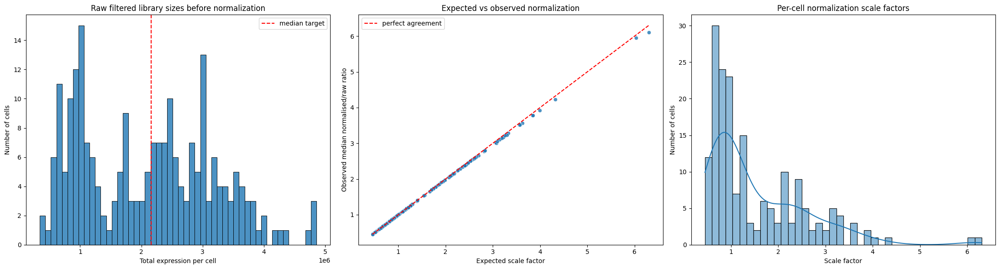

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.histplot(filtered_library_size.dropna(), bins=50, alpha=0.8, ax=axes[0])
axes[0].axvline(target_library_size, color="red", linestyle="--", label="median target")
axes[0].set_title("Raw filtered library sizes before normalization")
axes[0].set_xlabel("Total expression per cell")
axes[0].set_ylabel("Number of cells")
axes[0].legend()

sns.scatterplot(data=normalisation_cell_summary, x="expected_scale_factor", y="observed_scale_factor", alpha=0.8, ax=axes[1])

min_factor = normalisation_cell_summary[["expected_scale_factor", "observed_scale_factor"]].min().min()
max_factor = normalisation_cell_summary[["expected_scale_factor", "observed_scale_factor"]].max().max()

axes[1].plot([min_factor, max_factor], [min_factor, max_factor], color="red", linestyle="--", label="perfect agreement")
axes[1].set_title("Expected vs observed normalization")
axes[1].set_xlabel("Expected scale factor")
axes[1].set_ylabel("Observed median normalised/raw ratio")
axes[1].legend()

sns.histplot(data=normalisation_cell_summary, x="expected_scale_factor", bins=40, kde=True, ax=axes[2])
axes[2].set_title("Per-cell normalization scale factors")
axes[2].set_xlabel("Scale factor")
axes[2].set_ylabel("Number of cells")

plt.tight_layout()
plt.show()

The normalized training file is both scaled and reduced in feature dimension. It keeps a subset of cells and 3,000 selected genes from the filtered dataset, so normalization is not only a rescaling operation but also part of the construction of the analysis-ready matrix.

The scaling checks compare the expected library-size scaling with the observed normalized values. This verifies whether the normalized matrix behaves as expected and whether the expression scale is more comparable across cells.


<a id="filtered-normalized-hcc1806-smartseq-eda"></a>
### **Filtered-Normalized HCC1806 SmartSeq EDA**

We now inspect the filtered-normalized HCC1806 SmartSeq matrix. This is the version of the dataset that will be used in most downstream analyses.

At this stage, the matrix contains fewer cells and a selected set of 3,000 genes. It should be cleaner than the raw matrix, less sparse than before filtering, and more comparable across cells because of normalization.


<a id="filtered-and-normalized-data"></a>
#### *Filtered and Normalized Data*

The filtered-normalized matrix is the main HCC1806 SmartSeq dataset for the next parts of the project. In this section, we repeat the main quality-control checks on this final matrix.

We inspect detected genes per cell, zero fraction, total expression, mitochondrial fraction, gene detection, cell-cell correlation, and gene-condition associations. The goal is to make sure that the final dataset is coherent before using it for more advanced methods.


In [30]:
df_HSN_merged.head()

,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments,DDIT4,...,MST1R,ZYG11A,NRG1,RBMS3,VCPIP1,LINC02693,OR8B9P,NEAT1,ZDHHC23,ODAD2
0,output.STAR.PCRPlate1G12_Normoxia_S32_Aligned....,HCC1806,1,G12,Normoxia,24,S32,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",0,...,78,10,136,0,0,29,0,29,0,0
1,output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.s...,HCC1806,1,G1,Hypoxia,24,S102,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",8739,...,279,0,264,0,134,68,0,213,0,0
2,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sor...,HCC1806,1,G2,Hypoxia,24,S2,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",13098,...,311,0,38,0,0,0,0,92,0,0
3,output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sor...,HCC1806,1,G3,Hypoxia,24,S7,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",2880,...,125,0,16,0,4,1,0,1,0,0
4,output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.s...,HCC1806,1,G4,Hypoxia,24,S107,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",7777,...,268,1,25,0,0,0,0,128,0,0


In [31]:
df_HSN_counts_by_cell.describe()

Gene,DDIT4,ANGPTL4,CALML5,KRT14,CCNB1,IGFBP3,AKR1C2,KRT6A,NDRG1,KRT4,...,MST1R,ZYG11A,NRG1,RBMS3,VCPIP1,LINC02693,OR8B9P,NEAT1,ZDHHC23,ODAD2
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.00000,182.000000,182.000000,182.000000,182.000000,...,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,4038.736264,1227.164835,398.175824,921.307692,867.087912,1271.28022,1407.873626,1729.543956,457.895604,396.637363,...,123.302198,4.291209,138.868132,7.192308,56.675824,57.098901,0.153846,102.076923,12.236264,2.175824
std,4165.241080,1949.430648,886.985647,2387.091444,1268.359981,2810.10746,2582.400094,3709.250440,627.115448,1541.330938,...,119.297816,11.790896,147.116950,21.864761,123.906663,86.519829,1.060835,140.866555,28.353222,8.754596
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,295.000000,4.250000,0.000000,13.750000,61.250000,83.00000,140.250000,313.500000,4.000000,0.000000,...,27.500000,0.000000,36.250000,0.000000,0.000000,0.250000,0.000000,25.000000,0.000000,0.000000
50%,2729.500000,290.000000,0.000000,320.500000,299.500000,270.50000,484.000000,737.000000,143.500000,0.000000,...,98.500000,0.000000,97.000000,0.000000,36.000000,34.000000,0.000000,57.000000,0.000000,0.000000
75%,6933.500000,1857.750000,465.750000,1029.000000,988.500000,1163.50000,1472.000000,1774.000000,688.750000,0.000000,...,185.750000,0.000000,191.000000,6.000000,74.250000,68.000000,0.000000,117.500000,11.500000,0.000000
max,16700.000000,14032.000000,5482.000000,28680.000000,6914.000000,21554.00000,20195.000000,41946.000000,3356.000000,9902.000000,...,751.000000,68.000000,852.000000,246.000000,1545.000000,615.000000,11.000000,966.000000,222.000000,67.000000


In [32]:
df_HSN_cell_qc, df_HSN_gene_qc, df_HSN_mito_genes = compute_qc_tables(
    expression=df_HSN_expression,
    metadata=df_HCC_metadata_HSN
)

print("Expression shape:", df_HSN_expression.shape)
print("Cell QC shape:", df_HSN_cell_qc.shape)

print("\nCells with fewest detected genes:")
display(
    df_HSN_cell_qc.sort_values("detected_genes")
    [["Filename", "Condition", "detected_genes", "zero_fraction", "total_expression"]]
    .head(10)
)

print("\nCells with highest zero fraction:")
display(
    df_HSN_cell_qc.sort_values("zero_fraction", ascending=False)
    [["Filename", "Condition", "zero_fraction", "detected_genes", "total_expression"]]
    .head(10)
)

Expression shape: (182, 3000)
Cell QC shape: (182, 15)

Cells with fewest detected genes:


,Filename,Condition,detected_genes,zero_fraction,total_expression
94,output.STAR.PCRPlate3C5_Hypoxia_S77_Aligned.so...,Hypoxia,540,0.820000,549699
87,output.STAR.PCRPlate3B8_Normoxia_S82_Aligned.s...,Normoxia,632,0.789333,486104
171,output.STAR.PCRPlate4G10_Normoxia_S209_Aligned...,Normoxia,641,0.786333,412724
151,output.STAR.PCRPlate4C1_Hypoxia_S222_Aligned.s...,Hypoxia,646,0.784667,554505
4,output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.s...,Hypoxia,646,0.784667,553200
110,output.STAR.PCRPlate3F12_Normoxia_S218_Aligned...,Normoxia,647,0.784333,516238
25,output.STAR.PCRPlate2B6_Hypoxia_S45_Aligned.so...,Hypoxia,664,0.778667,545150
29,output.STAR.PCRPlate2C12_Normoxia_S59_Aligned....,Normoxia,664,0.778667,439840
163,output.STAR.PCRPlate4F10_Normoxia_S240_Aligned...,Normoxia,669,0.777000,429781
2,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sor...,Hypoxia,673,0.775667,536837



Cells with highest zero fraction:


,Filename,Condition,zero_fraction,detected_genes,total_expression
94,output.STAR.PCRPlate3C5_Hypoxia_S77_Aligned.so...,Hypoxia,0.820000,540,549699
87,output.STAR.PCRPlate3B8_Normoxia_S82_Aligned.s...,Normoxia,0.789333,632,486104
171,output.STAR.PCRPlate4G10_Normoxia_S209_Aligned...,Normoxia,0.786333,641,412724
4,output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.s...,Hypoxia,0.784667,646,553200
151,output.STAR.PCRPlate4C1_Hypoxia_S222_Aligned.s...,Hypoxia,0.784667,646,554505
110,output.STAR.PCRPlate3F12_Normoxia_S218_Aligned...,Normoxia,0.784333,647,516238
29,output.STAR.PCRPlate2C12_Normoxia_S59_Aligned....,Normoxia,0.778667,664,439840
25,output.STAR.PCRPlate2B6_Hypoxia_S45_Aligned.so...,Hypoxia,0.778667,664,545150
163,output.STAR.PCRPlate4F10_Normoxia_S240_Aligned...,Normoxia,0.777000,669,429781
2,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sor...,Hypoxia,0.775667,673,536837


The cell-level QC summaries show how many genes are detected in each cell after filtering and normalization. Compared to the raw matrix, the data are more compact and cleaner, but there is still variability between cells.

This variability is expected. Even after preprocessing, single-cell data remain heterogeneous because cells can differ in state, stress level, cell cycle phase, and response to hypoxia.


Detected genes per cell summary:


count     182.000000
mean      880.395604
std       116.582494
min       540.000000
25%       798.000000
50%       881.500000
75%       961.500000
max      1180.000000
Name: detected_genes, dtype: float64


Detected cells per gene summary:


count    3000.000000
mean       53.410667
std        61.404404
min         2.000000
25%         9.000000
50%        22.000000
75%        75.250000
max       182.000000
Name: detected_cells, dtype: float64

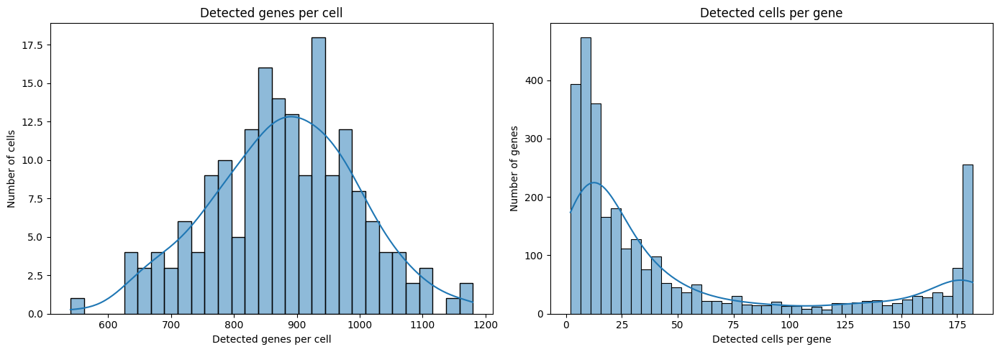


Genes detected in most cells:


,detected_cells,zero_fraction,mean_expression,variance
gene,,,,
TFRC,182,0.0,1297.873626,6.547544e+05
GPX3,182,0.0,1767.719780,1.459569e+06
FXYD3,182,0.0,734.945055,6.381976e+05
IDI1,182,0.0,773.197802,4.369673e+05
MRNIP,182,0.0,578.148352,1.814890e+05
CYP51A1,182,0.0,301.879121,7.683402e+04
B2M,182,0.0,5289.653846,5.585923e+06
SLC3A2,182,0.0,1952.043956,2.967193e+06
S100A16,182,0.0,1406.527473,8.507013e+05



Genes detected in fewest cells:


,detected_cells,zero_fraction,mean_expression,variance
gene,,,,
LIFR-AS1,2,0.989011,0.131868,2.910692
FAAHP1,3,0.983516,0.296703,7.171149
GABRD,3,0.983516,0.318681,9.212798
TRIM31-AS1,3,0.983516,0.214286,5.440016
CACNA2D3,3,0.983516,0.527473,16.792059
ADH5P5,3,0.983516,0.120879,1.278125
FAM218A,3,0.983516,0.423077,11.118360
PIK3R5,3,0.983516,0.247253,8.076650
FLG-AS1,3,0.983516,0.236264,4.247738


In [33]:
print("Detected genes per cell summary:")
display(df_HSN_cell_qc["detected_genes"].describe())

print("\nDetected cells per gene summary:")
display(df_HSN_gene_qc["detected_cells"].describe())

fig, axes =plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_HSN_cell_qc["detected_genes"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Detected genes per cell")
axes[0].set_xlabel("Detected genes per cell")
axes[0].set_ylabel("Number of cells")
sns.histplot(df_HSN_gene_qc["detected_cells"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Detected cells per gene")
axes[1].set_xlabel("Detected cells per gene")
axes[1].set_ylabel("Number of genes")
plt.tight_layout()
plt.show()

print("\nGenes detected in most cells:")
display(df_HSN_gene_qc.sort_values("detected_cells", ascending=False).head(10))

print("\nGenes detected in fewest cells:")
display(df_HSN_gene_qc.sort_values("detected_cells", ascending=True).head(10))

The gene-level QC summaries show how broadly each gene is detected across the retained cells. Some genes are expressed in most cells, while others remain more specific to subsets of cells.

This is useful because broadly detected genes may represent general cellular programs, while genes detected in fewer cells may reflect more specific states or condition-associated responses.


In [34]:
df_HSN_cell_qc, df_HSN_gene_qc, df_HSN_mito_genes = compute_qc_tables(
    expression=df_HSN_expression,
    metadata=df_HCC_metadata_HSN
)

Number of mitochondrial genes found: 8
Example mitochondrial genes: ['MT-RNR2', 'MT-CO3', 'MT-ND4', 'MT-CYB', 'MT-CO2', 'MT-RNR1', 'MT-ND5', 'MT-ND4L']


count    182.000000
mean       0.057808
std        0.025861
min        0.001133
25%        0.039475
50%        0.051570
75%        0.070673
max        0.153912
Name: mitochondrial_fraction, dtype: float64

,mitochondrial_fraction,detected_genes,zero_fraction,total_expression,Condition
30,0.153912,684,0.772000,480971,Hypoxia
11,0.145112,734,0.755333,436739,Hypoxia
29,0.135888,664,0.778667,439840,Normoxia
171,0.133450,641,0.786333,412724,Normoxia
63,0.130392,708,0.764000,427518,Normoxia
37,0.124158,818,0.727333,442308,Normoxia
150,0.124014,903,0.699000,438887,Normoxia
125,0.118261,880,0.706667,497635,Hypoxia
163,0.115947,669,0.777000,429781,Normoxia
117,0.106512,866,0.711333,437510,Normoxia


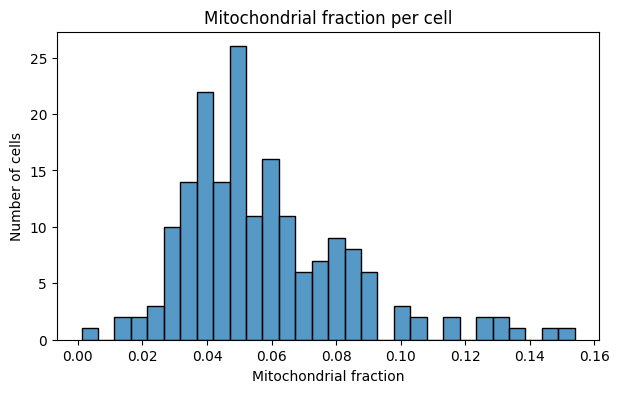

In [35]:
print("Number of mitochondrial genes found:", len(df_HSN_mito_genes))
print("Example mitochondrial genes:", df_HSN_mito_genes[:20])

display(df_HSN_cell_qc["mitochondrial_fraction"].describe())

display(
    df_HSN_cell_qc
    .sort_values("mitochondrial_fraction", ascending=False)
    [["mitochondrial_fraction", "detected_genes", "zero_fraction", "total_expression", "Condition"]]
    .head(10)
)

plt.figure(figsize=(7, 4))
sns.histplot(df_HSN_cell_qc["mitochondrial_fraction"].dropna(), bins=30)
plt.xlabel("Mitochondrial fraction")
plt.ylabel("Number of cells")
plt.title("Mitochondrial fraction per cell")
plt.show()

Mitochondrial fraction is checked again at this stage because it remains an important stress-related signal. However, since the normalized matrix contains only the selected 3,000 genes, mitochondrial genes may not always be fully represented. For this reason, mitochondrial QC must be interpreted carefully in the normalized matrix.

When mitochondrial genes are present, the distribution helps us check whether some cells still show signs of stress after filtering. This can later be compared with condition labels to see whether stressed cells are more common in hypoxia or normoxia.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


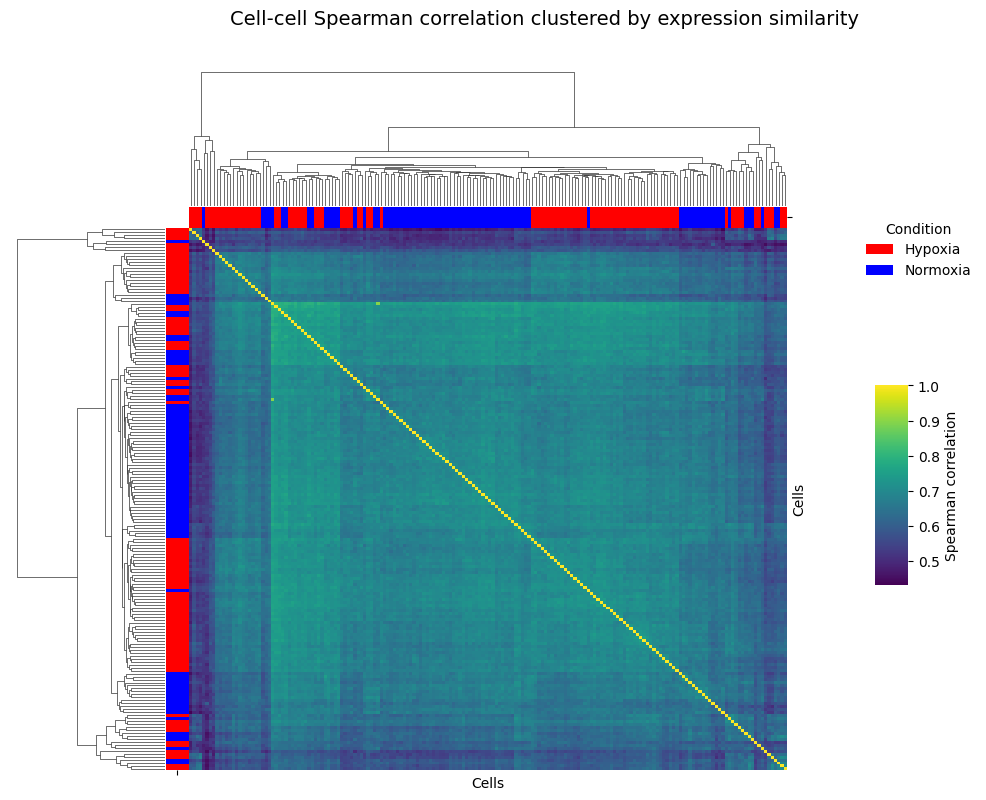

In [36]:
df_corr_expression = df_HSN_expression.copy()

cell_corr = df_corr_expression.T.corr(method="spearman")
cell_corr.index.name = None
cell_corr.columns.name = None

metadata_for_corr = (
    df_HSN_cell_qc
    .set_index("Filename")
    .reindex(cell_corr.index)
)

metadata_for_corr["Condition"] = standardize_condition(metadata_for_corr["Condition"])

condition_colors = metadata_for_corr["Condition"].map({
    "Hypoxia": "red",
    "Normoxia": "blue"
})

condition_colors.name = None

g = sns.clustermap(
    cell_corr,
    cmap="viridis",
    figsize=(11, 8),
    xticklabels=False,
    yticklabels=False,
    row_colors=condition_colors,
    col_colors=condition_colors,
    cbar_kws={"label": "Spearman correlation"}
)

g.figure.subplots_adjust(right=0.72, top=0.90)
g.cax.set_position([0.80, 0.25, 0.03, 0.25])

g.ax_heatmap.set_xlabel("Cells")
g.ax_heatmap.set_ylabel("Cells")
g.ax_row_colors.set_ylabel("")
g.ax_col_colors.set_ylabel("")

g.figure.suptitle(
    "Cell-cell Spearman correlation clustered by expression similarity",
    fontsize=14,
    y=0.97
)

legend_handles = [
    Patch(facecolor="red", label="Hypoxia"),
    Patch(facecolor="blue", label="Normoxia")
]

g.figure.legend(
    handles=legend_handles,
    title="Condition",
    loc="upper left",
    bbox_to_anchor=(0.78, 0.72),
    frameon=False
)

plt.show()

The cell-cell correlation analysis checks whether some cells have very similar global expression profiles. This can reveal possible redundancy, but it can also show whether cells organize according to biological condition.

If hypoxia and normoxia cells cluster separately, this suggests that oxygen condition strongly affects the expression profiles. If clusters are mixed, then condition may be weaker than other sources of variation, such as cell cycle or technical effects.


In [37]:
X_gene_corr = df_HSN_expression.copy()
X_gene_corr = X_gene_corr.apply(pd.to_numeric, errors="coerce")

print("Expression matrix shape:", X_gene_corr.shape)

constant_genes = X_gene_corr.columns[X_gene_corr.nunique(dropna=True) <= 1]
print("Number of constant genes:", len(constant_genes))

gene_corr = X_gene_corr.corr(method="spearman")
upper_triangle = np.triu(np.ones(gene_corr.shape), k=1).astype(bool)

# Avoid duplicate axis names called "Gene" when resetting the stacked correlation table.
gene_corr_for_pairs = gene_corr.copy()
gene_corr_for_pairs.index.name = "gene_1"
gene_corr_for_pairs.columns.name = "gene_2"

gene_pairs = (
    gene_corr_for_pairs
    .where(upper_triangle)
    .stack()
    .rename("spearman_correlation")
    .reset_index()
)

gene_pairs["absolute_correlation"] = gene_pairs["spearman_correlation"].abs()
gene_pairs = gene_pairs.sort_values("absolute_correlation", ascending=False).reset_index(drop=True)

report_gene_pairs = gene_pairs.head(20).copy()
display(report_gene_pairs.head(10))

Expression matrix shape: (182, 3000)
Number of constant genes: 0


,gene_1,gene_2,spearman_correlation,absolute_correlation
0,MIR374B,MIR374C,1.000000,1.000000
1,SERPINB3,SERPINB11,0.999937,0.999937
2,MIF-AS1,MIF,0.999932,0.999932
3,FTH1,BEST1,0.999677,0.999677
4,ADIRF,ADIRF-AS1,0.996295,0.996295
5,SERPINB2,SERPINB10,0.992370,0.992370
6,GAS6,GAS6-AS1,0.992334,0.992334
7,PLAU,C10orf55,0.990904,0.990904
8,SQSTM1,MRNIP,0.988855,0.988855
9,ALDH1A3,ALDH1A3-AS1,0.983761,0.983761


We notice how there is only one pair of cells with perfect correlation, we will take this into consideration again in the dimensionality reduction section.


Detected genes per cell by condition:


,mean,median,std,min,max
Condition,,,,,
Hypoxia,879.835052,878.0,120.452591,540,1180
Normoxia,881.035294,886.0,112.712492,632,1155


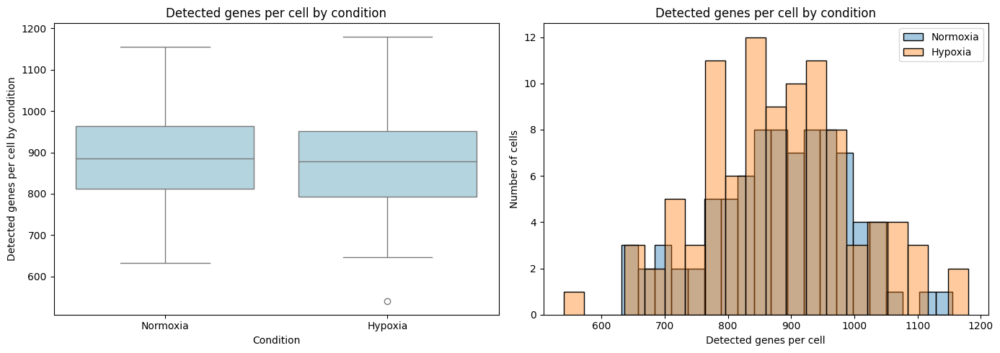

In [38]:
qc_by_condition = df_HSN_cell_qc.copy()
qc_by_condition["Condition"] = standardize_condition(qc_by_condition["Condition"])

print("\nDetected genes per cell by condition:")
summary = qc_by_condition.groupby("Condition")["detected_genes"].agg(
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
)

display(summary)

conditions = qc_by_condition["Condition"].dropna().unique()

groups = [
    qc_by_condition.loc[qc_by_condition["Condition"] == cond, "detected_genes"]
    for cond in conditions
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=qc_by_condition, x="Condition", y="detected_genes", color = "lightblue", ax=axes[0])
axes[0].set_title("Detected genes per cell by condition")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Detected genes per cell by condition")
for cond in conditions:
    vals = qc_by_condition.loc[qc_by_condition["Condition"] == cond, "detected_genes"]
    sns.histplot(vals, bins=20, alpha=0.4, label=cond, ax=axes[1])
axes[1].set_title("Detected genes per cell by condition")
axes[1].set_xlabel("Detected genes per cell")
axes[1].set_ylabel("Number of cells")
axes[1].legend()
plt.tight_layout()
plt.show()

Detected-gene counts are very similar between hypoxia and normoxia in the normalized HCC1806 SmartSeq matrix. This is reassuring because it suggests that the two conditions are not separated simply by one group having many more detected genes than the other.

In other words, later hypoxia/normoxia differences are less likely to be explained only by basic cell quality.


Pearson correlation between mitochondrial fraction and Hypoxia condition:
r = -0.27445803667842866
p-value = 0.0001772661903672066

Mitochondrial fraction by condition:


,count,mean,median,std,min,max
Condition,,,,,,
Hypoxia,97,0.051182,0.047355,0.023645,0.001133,0.153912
Normoxia,85,0.065369,0.061602,0.026335,0.015279,0.135888


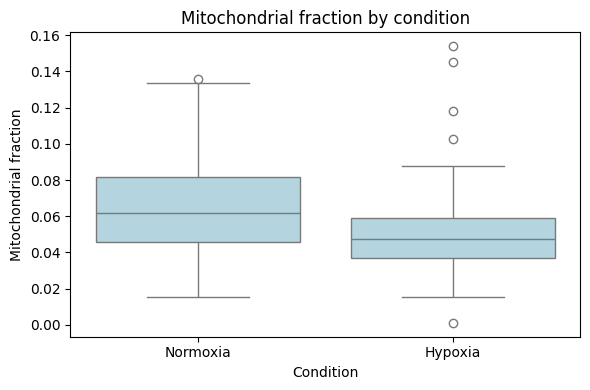

In [39]:
qc_by_condition = df_HSN_cell_qc.copy()
qc_by_condition["Condition"] = standardize_condition(qc_by_condition["Condition"])

condition_binary = qc_by_condition["Condition"].map({
    "Normoxia": 0,
    "Hypoxia": 1
})

valid = qc_by_condition["mitochondrial_fraction"].notna() & condition_binary.notna()

r, p = stats.pearsonr(
    qc_by_condition.loc[valid, "mitochondrial_fraction"],
    condition_binary.loc[valid]
)

print("Pearson correlation between mitochondrial fraction and Hypoxia condition:")
print("r =", r)
print("p-value =", p)

print("\nMitochondrial fraction by condition:")

mito_summary = (
    qc_by_condition
    .dropna(subset=["Condition", "mitochondrial_fraction"])
    .groupby("Condition")["mitochondrial_fraction"]
    .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
)

display(mito_summary)

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=qc_by_condition.dropna(subset=["Condition", "mitochondrial_fraction"]),
    x="Condition",
    y="mitochondrial_fraction",
    color="lightblue"
)

plt.xlabel("Condition")
plt.ylabel("Mitochondrial fraction")
plt.title("Mitochondrial fraction by condition")
plt.tight_layout()
plt.show()

Mitochondrial fraction is compared across conditions to check whether one condition contains more stressed or damaged cells. A difference here would not automatically invalidate the dataset, but it would be important to consider as a possible confounder.

This is especially relevant because hypoxia itself can induce cellular stress, so mitochondrial fraction may reflect both quality control and biology.



Number of usable genes: 3000


,gene,spearman_corr_with_hypoxia,association
1112,EIF5,-0.661141,Higher in normoxia
2670,SRM,-0.530863,Higher in normoxia
695,KYNU,-0.525114,Higher in normoxia
2732,LDHB,-0.514197,Higher in normoxia
329,SLC7A11,-0.479734,Higher in normoxia
1978,ZNF473,-0.469770,Higher in normoxia
971,SRXN1,-0.468081,Higher in normoxia
92,KPNA2,-0.450370,Higher in normoxia
2671,ERVMER34-1,-0.414526,Higher in normoxia
2941,NOLC1,-0.412533,Higher in normoxia


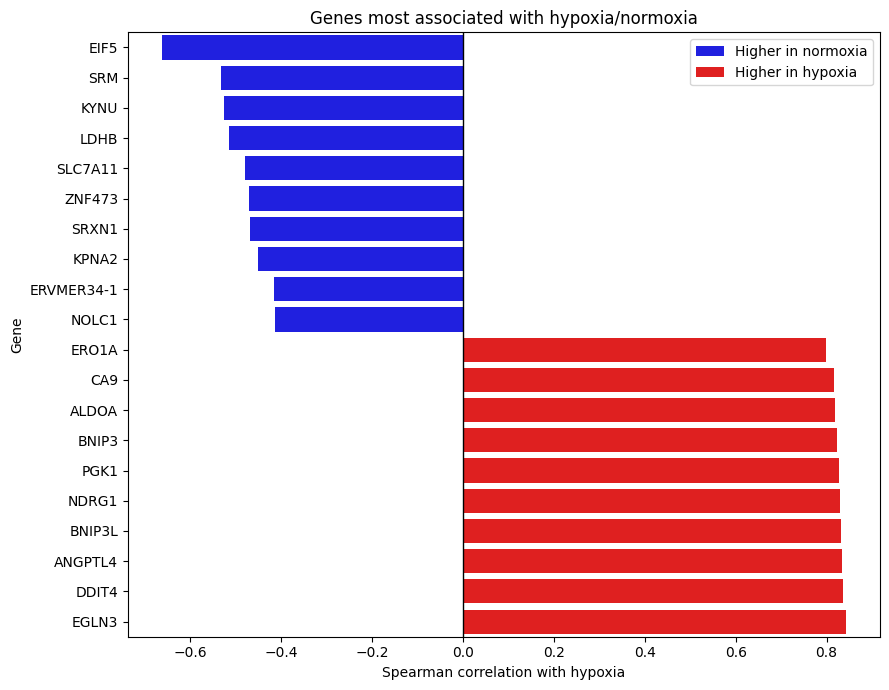

In [40]:
X_gene_condition = df_HSN_expression.copy()
X_gene_condition = X_gene_condition.apply(pd.to_numeric, errors="coerce")

meta_gene_condition = df_HSN_cell_qc.copy()
meta_gene_condition["Condition"] = standardize_condition(meta_gene_condition["Condition"])

# Important: align metadata to expression rows using Filename
meta_gene_condition = (
    meta_gene_condition
    .set_index("Filename")
    .reindex(X_gene_condition.index)
)

condition_binary = meta_gene_condition["Condition"].map({
    "Normoxia": 0,
    "Hypoxia": 1
})

gene_condition_rows = []

for gene in X_gene_condition.columns:
    x_gene = X_gene_condition[gene]

    valid = x_gene.notna() & condition_binary.notna()

    if valid.sum() < 3:
        continue

    if x_gene.loc[valid].nunique() <= 1:
        continue

    corr, p_value = stats.spearmanr(
        x_gene.loc[valid],
        condition_binary.loc[valid]
    )

    hypo_mask = meta_gene_condition["Condition"] == "Hypoxia"
    normo_mask = meta_gene_condition["Condition"] == "Normoxia"

    hypo_mean = x_gene.loc[hypo_mask].mean()
    normo_mean = x_gene.loc[normo_mask].mean()

    gene_condition_rows.append({
        "gene": gene,
        "spearman_corr_with_hypoxia": corr,
        "p_value": p_value,
        "mean_hypoxia": hypo_mean,
        "mean_normoxia": normo_mean,
        "difference_hypoxia_minus_normoxia": hypo_mean - normo_mean,
        "detected_cells": (x_gene > 0).sum(),
        "zero_fraction": (x_gene == 0).mean()
    })

gene_condition = pd.DataFrame(gene_condition_rows)

print("\nNumber of usable genes:", len(gene_condition))

top_n = 10

top_hypoxia_genes = (
    gene_condition
    .sort_values("spearman_corr_with_hypoxia", ascending=False)
    .head(top_n)
    .copy()
)

top_normoxia_genes = (
    gene_condition
    .sort_values("spearman_corr_with_hypoxia", ascending=True)
    .head(top_n)
    .copy()
)

top_hypoxia_genes["association"] = "Higher in hypoxia"
top_normoxia_genes["association"] = "Higher in normoxia"

top_for_plot = pd.concat([top_normoxia_genes, top_hypoxia_genes])
top_for_plot = top_for_plot.sort_values("spearman_corr_with_hypoxia")

display(top_for_plot[["gene", "spearman_corr_with_hypoxia", "association"]])

plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_for_plot,
    x="spearman_corr_with_hypoxia",
    y="gene",
    hue="association",
    dodge=False,
    palette={
        "Higher in hypoxia": "red",
        "Higher in normoxia": "blue"
    }
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Spearman correlation with hypoxia")
plt.ylabel("Gene")
plt.title("Genes most associated with hypoxia/normoxia")
plt.legend(title="")
plt.tight_layout()
plt.show()

The gene-condition association analysis identifies genes whose expression is most correlated with hypoxia or normoxia. This is not meant to be a full differential expression analysis, but it provides a useful first look at which genes are most related to the experimental condition.

Positive correlations indicate genes that tend to be higher in hypoxia, while negative correlations indicate genes that tend to be higher in normoxia. Several of the strongest hypoxia-associated genes are coherent with known hypoxia and stress-response biology, which supports the reliability of the signal.


<a id="transformation-of-gene-expressivity"></a>
### **Transformation of Gene Expressivity**

Single-cell RNA-seq data are usually sparse and skewed. A few expression values can be very large, while many values are zero or close to zero. This can make raw expression values difficult to use directly in methods such as PCA, clustering, or neural networks.

For this reason, we compare the original normalized values with log1p-transformed values. The log1p transformation reduces the impact of extreme values while keeping zeros well-defined. This usually makes the expression distribution more balanced and easier for downstream methods to handle.


The log1p transformation is evaluated because raw normalized expression values still have long right tails. If a few very large expression values dominate the variance, PCA and clustering can become driven by magnitude outliers rather than by broader expression patterns.


In [ ]:
df_HSN_expression_numeric = df_HSN_expression.apply(pd.to_numeric, errors="coerce")

df_HSN_log1p_expression = np.log1p(df_HSN_expression_numeric)

raw_values_for_log1p_plot = df_HSN_expression_numeric.to_numpy().ravel()
log1p_values_for_plot = df_HSN_log1p_expression.to_numpy().ravel()

gene_skewness_before_log1p = df_HSN_expression_numeric.skew(axis=0)
gene_skewness_after_log1p = df_HSN_log1p_expression.skew(axis=0)

cell_skewness_before_log1p = df_HSN_expression_numeric.skew(axis=1)
cell_skewness_after_log1p = df_HSN_log1p_expression.skew(axis=1)

print("Expression matrix shape:", df_HSN_expression_numeric.shape)

print("\nGene skewness before log1p:")
display(gene_skewness_before_log1p.describe())

print("\nGene skewness after log1p:")
display(gene_skewness_after_log1p.describe())

print("\nCell skewness before log1p:")
display(cell_skewness_before_log1p.describe())

print("\nCell skewness after log1p:")
display(cell_skewness_after_log1p.describe())

Expression matrix shape: (182, 3000)

Gene skewness before log1p:


count    3000.000000
mean        5.415334
std         2.713296
min        -0.577076
25%         3.336398
50%         5.239700
75%         7.272742
max        13.466757
dtype: float64


Gene skewness after log1p:


count    3000.000000
mean        2.697343
std         2.730668
min        -7.638802
25%         0.666196
50%         2.781106
75%         4.841025
max        12.701283
dtype: float64


Cell skewness before log1p:


count    182.000000
mean      16.156526
std        5.053158
min        8.258500
25%       13.058711
50%       15.167084
75%       17.494187
max       36.004140
dtype: float64


Cell skewness after log1p:


count    182.000000
mean       1.454275
std        0.192125
min        1.061967
25%        1.316468
50%        1.417043
75%        1.545826
max        2.198383
dtype: float64

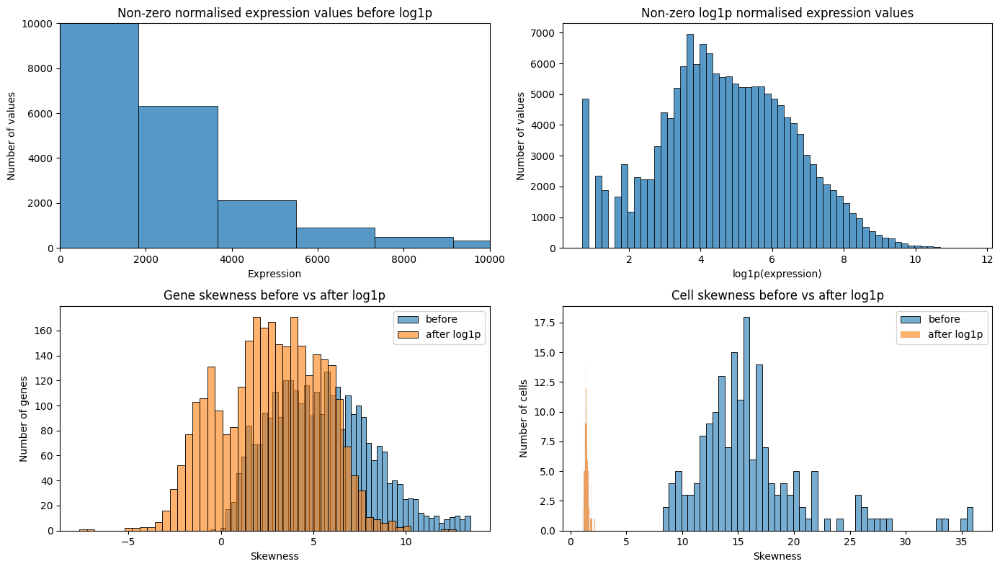

In [42]:
def clean_nonzero(values):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values != 0]
    return values

raw_nonzero = clean_nonzero(raw_values_for_log1p_plot)
log1p_nonzero = clean_nonzero(log1p_values_for_plot)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(raw_nonzero, bins=60, ax=axes[0, 0])
axes[0, 0].set_title("Non-zero normalised expression values before log1p")
axes[0, 0].set_xlabel("Expression")
axes[0, 0].set_ylabel("Number of values")
axes[0, 0].set_xlim(0, 10000)
axes[0, 0].set_ylim(0, 10000)

sns.histplot(log1p_nonzero, bins=60, ax=axes[0, 1])
axes[0, 1].set_title("Non-zero log1p normalised expression values")
axes[0, 1].set_xlabel("log1p(expression)")
axes[0, 1].set_ylabel("Number of values")

sns.histplot(gene_skewness_before_log1p, bins=50, alpha=0.6, label="before", ax=axes[1, 0])
sns.histplot(gene_skewness_after_log1p, bins=50, alpha=0.6, label="after log1p", ax=axes[1, 0])
axes[1, 0].set_title("Gene skewness before vs after log1p")
axes[1, 0].set_xlabel("Skewness")
axes[1, 0].set_ylabel("Number of genes")
axes[1, 0].legend()

sns.histplot(cell_skewness_before_log1p, bins=50, alpha=0.6, label="before", ax=axes[1, 1])
sns.histplot(cell_skewness_after_log1p, bins=50, alpha=0.6, label="after log1p", ax=axes[1, 1])
axes[1, 1].set_title("Cell skewness before vs after log1p")
axes[1, 1].set_xlabel("Skewness")
axes[1, 1].set_ylabel("Number of cells")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

After log1p, both the global expression distribution and the skewness distributions become more compact. This does not make the data perfectly normal, but it reduces the influence of extreme values and makes downstream distance-based methods more stable.

The goal is not to remove biological variation, but to make the numerical scale more suitable for models that are sensitive to large differences in magnitude.


<a id="cross-dataset-eda-extension"></a>
## **CROSS-DATASET EDA EXTENSION**

After completing the detailed workflow on HCC1806 SmartSeq, we extend the main checks to the other datasets. The goal is to compare the four combinations of cell line and sequencing technology:

- HCC1806 SmartSeq
- HCC1806 DropSeq
- MCF7 SmartSeq
- MCF7 DropSeq

This section is important because the datasets are not directly identical. SmartSeq and DropSeq have different technical properties, and HCC1806 and MCF7 represent different breast cancer models. Therefore, downstream results should be interpreted with these differences in mind.


In [43]:
datasets = {}

for dataset in [
    load_smartseq_dataset("HCC1806 SmartSeq", "HCC1806", hcc_smart_metadata_path, hcc_smart_normalized_path),
    load_smartseq_dataset("MCF7 SmartSeq", "MCF7", mcf_smart_metadata_path, mcf_smart_normalized_path),
    load_dropseq_dataset("HCC1806 DropSeq", "HCC1806", hcc_dropseq_path),
    load_dropseq_dataset("MCF7 DropSeq", "MCF7", mcf_dropseq_path)
]:
    if dataset is not None:
        datasets[dataset["dataset"]] = dataset

,dataset,cell_line,technology,available_preprocessing_levels,cells,genes,hypoxia_cells,normoxia_cells,missing_expression_values,mitochondrial_genes_found,median_detected_genes_per_cell,median_zero_fraction_per_cell,median_total_expression_per_cell,median_mitochondrial_fraction
0,HCC1806 SmartSeq,HCC1806,SmartSeq,unfiltered + filtered + normalized,182,3000,97,85,0,8,881.5,0.706167,497586.5,0.051570
1,MCF7 SmartSeq,MCF7,SmartSeq,unfiltered + filtered + normalized,250,3000,124,126,0,10,1097.0,0.634333,330296.0,0.063512
2,HCC1806 DropSeq,HCC1806,DropSeq,normalized only,14682,3000,8899,5783,0,32,67.0,0.977667,102.0,0.012987
3,MCF7 DropSeq,MCF7,DropSeq,normalized only,21626,3000,8921,12705,0,31,69.0,0.977000,100.0,0.011628


,dataset,Condition,n_cells
0,HCC1806 SmartSeq,Hypoxia,97
1,HCC1806 SmartSeq,Normoxia,85
2,MCF7 SmartSeq,Normoxia,126
3,MCF7 SmartSeq,Hypoxia,124
4,HCC1806 DropSeq,Hypoxia,8899
5,HCC1806 DropSeq,Normoxia,5783
6,MCF7 DropSeq,Normoxia,12705
7,MCF7 DropSeq,Hypoxia,8921


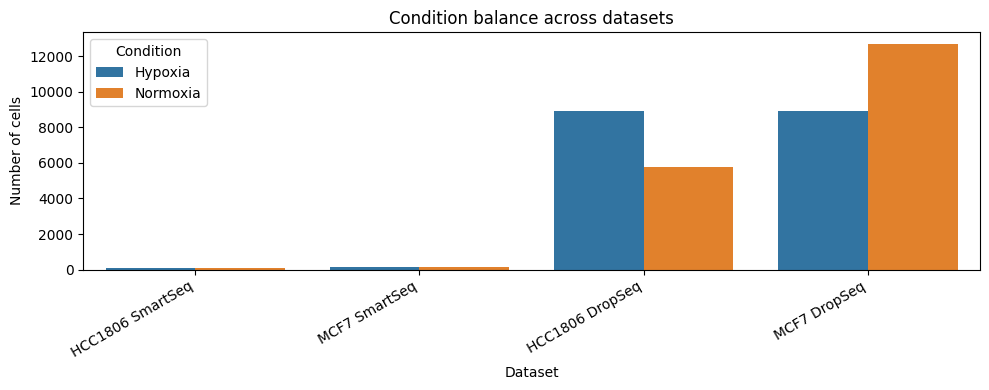

In [44]:
overview_rows = []

for name, ds in datasets.items():
    cell_qc = ds["cell_qc"]
    gene_qc = ds["gene_qc"]

    overview_rows.append({
        "dataset": name,
        "cell_line": ds["cell_line"],
        "technology": ds["technology"],
        "available_preprocessing_levels": ds["preprocessing_available"],
        "cells": ds["expression"].shape[0],
        "genes": ds["expression"].shape[1],
        "hypoxia_cells": int((cell_qc["Condition"] == "Hypoxia").sum()) if "Condition" in cell_qc.columns else np.nan,
        "normoxia_cells": int((cell_qc["Condition"] == "Normoxia").sum()) if "Condition" in cell_qc.columns else np.nan,
        "missing_expression_values": int(ds["expression"].isna().sum().sum()),
        "mitochondrial_genes_found": len(ds["mitochondrial_genes"]),
        "median_detected_genes_per_cell": cell_qc["detected_genes"].median(),
        "median_zero_fraction_per_cell": cell_qc["zero_fraction"].median(),
        "median_total_expression_per_cell": cell_qc["total_expression"].median(),
        "median_mitochondrial_fraction": cell_qc["mitochondrial_fraction"].median(),
    })

cross_dataset_overview = pd.DataFrame(overview_rows)
display(cross_dataset_overview)

condition_count_rows = []
for name, ds in datasets.items():
    counts = ds["cell_qc"]["Condition"].value_counts(dropna=False)
    for condition, n in counts.items():
        condition_count_rows.append({"dataset": name, "Condition": condition, "n_cells": n})

condition_counts_all = pd.DataFrame(condition_count_rows)

display(condition_counts_all)

plt.figure(figsize=(10, 4))
sns.barplot(data=condition_counts_all, x="dataset", y="n_cells", hue="Condition")
plt.title("Condition balance across datasets")
plt.xlabel("Dataset")
plt.ylabel("Number of cells")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The first important point is that none of the datasets contains missing expression values. This means that the matrices are complete and can be analysed without imputation. Therefore, the main differences between datasets should be interpreted in terms of sequencing technology, sparsity, expression coverage, and biological condition rather than missing data.

<a id="qc-distributions-across-datasets"></a>
### **QC Distributions Across Datasets**

This section compares the main quality-control metrics across datasets. We focus on detected genes per cell, zero fraction, total expression, and mitochondrial fraction when available.

These plots help us understand whether the datasets have similar levels of sparsity and expression coverage. In general, SmartSeq tends to contain fewer cells but richer expression profiles, while DropSeq contains many more cells with sparser measurements. This difference is expected and should not be interpreted as a biological effect by itself.


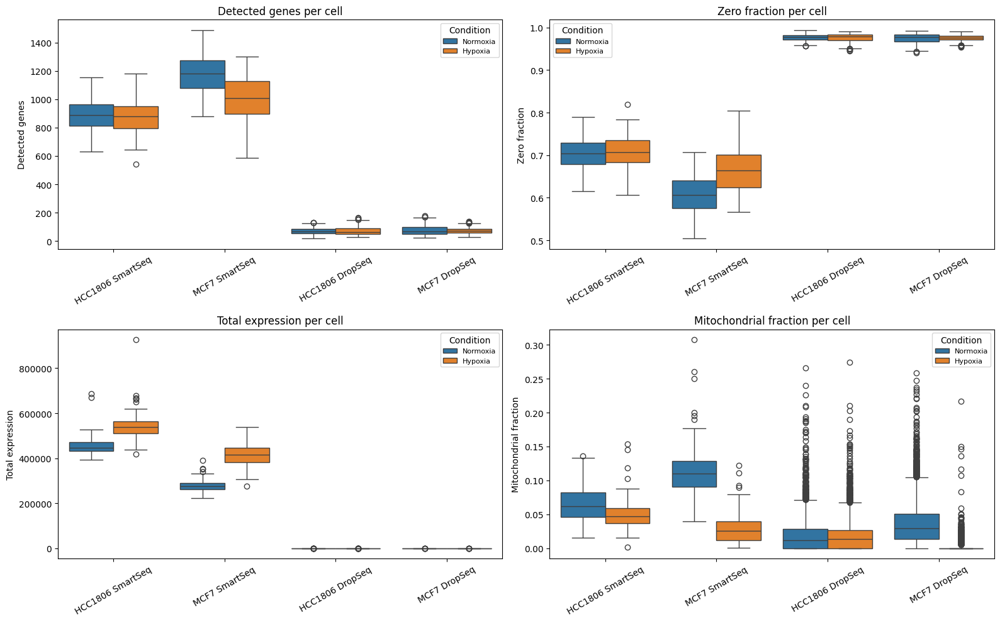

In [ ]:
qc_plot_tables = []

for name, ds in datasets.items():
    cell_qc = ds["cell_qc"].copy()
    if len(cell_qc) > 10000:
        sampled_parts = []
        for condition, group in cell_qc.groupby("Condition", dropna=False):
            n = min(len(group), max(1, 100000 // max(1, cell_qc["Condition"].nunique(dropna=True))))
            sampled_parts.append(group.sample(n=n, random_state= 42))
        cell_qc = pd.concat(sampled_parts, axis=0)
        if len(cell_qc) > 10000:
            cell_qc = cell_qc.sample(n=10000, random_state= 42)

    cell_qc["dataset"] = name
    cell_qc["technology"] = ds["technology"]
    cell_qc["cell_line"] = ds["cell_line"]
    qc_plot_tables.append(cell_qc)

qc_plot_data = pd.concat(qc_plot_tables, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=qc_plot_data, x="dataset", y="detected_genes", hue="Condition", ax=axes[0, 0])
axes[0, 0].set_title("Detected genes per cell")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Detected genes")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.boxplot(data=qc_plot_data, x="dataset", y="zero_fraction", hue="Condition", ax=axes[0, 1])
axes[0, 1].set_title("Zero fraction per cell")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Zero fraction")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.boxplot(data=qc_plot_data, x="dataset", y="total_expression", hue="Condition", ax=axes[1, 0])
axes[1, 0].set_title("Total expression per cell")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Total expression")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.boxplot(data=qc_plot_data, x="dataset", y="mitochondrial_fraction", hue="Condition", ax=axes[1, 1])
axes[1, 1].set_title("Mitochondrial fraction per cell")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Mitochondrial fraction")
axes[1, 1].tick_params(axis="x", rotation=30)

for ax in axes.ravel():
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(title="Condition", fontsize=8)

plt.tight_layout()
plt.show()

<a id="expression-distributions-and-log1p-effect"></a>
### **Expression Distributions and log1p Effect**

Here we compare expression-value distributions across datasets before and after log1p transformation. This is useful because the scale and sparsity of the expression values can differ strongly between SmartSeq and DropSeq.

The log1p transformation makes the distributions easier to compare and reduces the effect of extreme expression values. This is especially important when the same downstream methods are applied to datasets with different sequencing technologies.


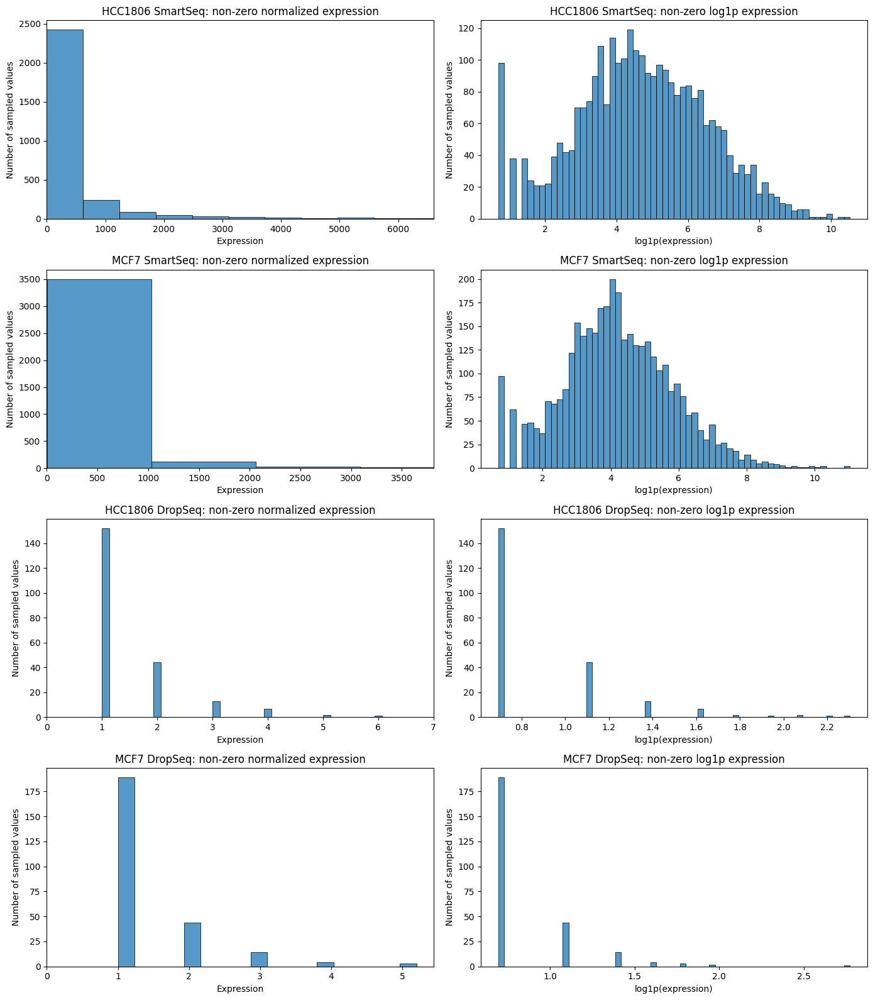

,dataset,median_abs_gene_skewness_before_log1p,median_abs_gene_skewness_after_log1p,median_abs_cell_skewness_before_log1p,median_abs_cell_skewness_after_log1p
0,HCC1806 SmartSeq,5.239700,2.855450,15.167084,1.417043
1,MCF7 SmartSeq,5.161711,1.948704,19.674305,1.080526
2,HCC1806 DropSeq,23.331641,18.878235,11.660843,7.971930
3,MCF7 DropSeq,17.862356,15.610377,11.847926,7.829761


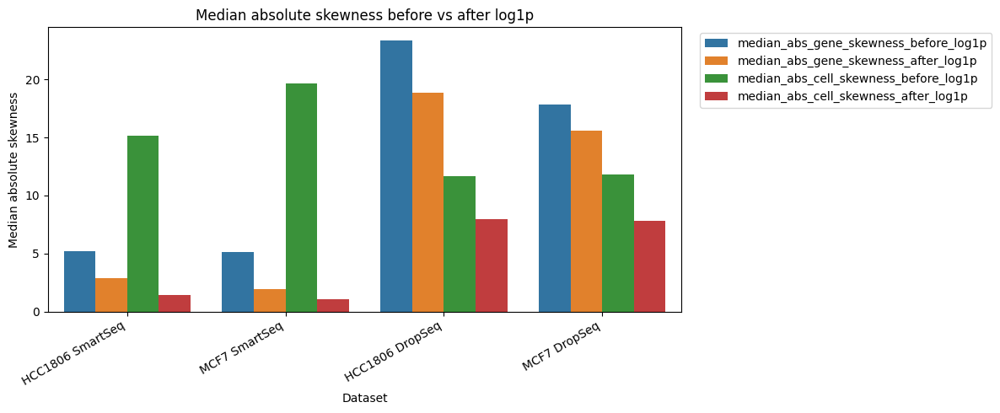

In [46]:
expression_distribution_rows = []
skewness_rows = []

fig, axes = plt.subplots(len(datasets), 2, figsize=(14, 4 * len(datasets)))
if len(datasets) == 1:
    axes = np.array([axes])

for row_idx, (name, ds) in enumerate(datasets.items()):
    expression = ds["expression"]
    values_raw = sample_values_from_matrix(expression)
    values_log = np.log1p(values_raw)

    values_raw_nonzero = values_raw.replace([np.inf, -np.inf], np.nan).dropna()
    values_raw_nonzero = values_raw_nonzero[values_raw_nonzero != 0]
    values_log_nonzero = pd.Series(values_log).replace([np.inf, -np.inf], np.nan).dropna()
    values_log_nonzero = values_log_nonzero[values_log_nonzero != 0]

    sns.histplot(values_raw_nonzero, bins=60, ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f"{name}: non-zero normalized expression")
    axes[row_idx, 0].set_xlabel("Expression")
    axes[row_idx, 0].set_ylabel("Number of sampled values")
    if len(values_raw_nonzero) > 0:
        axes[row_idx, 0].set_xlim(0, values_raw_nonzero.quantile(0.99))

    sns.histplot(values_log_nonzero, bins=60, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f"{name}: non-zero log1p expression")
    axes[row_idx, 1].set_xlabel("log1p(expression)")
    axes[row_idx, 1].set_ylabel("Number of sampled values")

    gene_skew_before = expression.skew(axis=0)
    gene_skew_after = np.log1p(expression).skew(axis=0)
    cell_skew_before = expression.skew(axis=1)
    cell_skew_after = np.log1p(expression).skew(axis=1)

    skewness_rows.append({
        "dataset": name,
        "median_abs_gene_skewness_before_log1p": gene_skew_before.abs().median(),
        "median_abs_gene_skewness_after_log1p": gene_skew_after.abs().median(),
        "median_abs_cell_skewness_before_log1p": cell_skew_before.abs().median(),
        "median_abs_cell_skewness_after_log1p": cell_skew_after.abs().median(),
    })

plt.tight_layout()
plt.show()

skewness_comparison = pd.DataFrame(skewness_rows)
display(skewness_comparison)

skewness_long = skewness_comparison.melt(
    id_vars="dataset",
    var_name="metric",
    value_name="median_absolute_skewness"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=skewness_long, x="dataset", y="median_absolute_skewness", hue="metric")
plt.title("Median absolute skewness before vs after log1p")
plt.xlabel("Dataset")
plt.ylabel("Median absolute skewness")
plt.xticks(rotation=30, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

<a id="cell-cell-correlation-summary-across-datasets"></a>
### **Cell-Cell Correlation Summary Across Datasets**

The cell-cell correlation summary compares how similar cells are to each other within each dataset. We also compare correlations between cells of the same condition and cells of different conditions.

If same-condition correlations are higher than different-condition correlations, this suggests that hypoxia and normoxia affect the global expression structure. If the difference is small, then other factors may be more important, such as cell line, sequencing technology, or technical noise.


,dataset,sampled_cells,mean_correlation_all_pairs,median_correlation_all_pairs,mean_correlation_same_condition,mean_correlation_different_condition,pairs_correlation_ge_0_95,pairs_correlation_ge_0_98
0,HCC1806 SmartSeq,182,0.659578,0.673068,0.665852,0.653319,0,0
1,MCF7 SmartSeq,250,0.605904,0.603654,0.655324,0.556873,1,1
2,HCC1806 DropSeq,800,0.234053,0.230549,0.241827,0.226300,0,0
3,MCF7 DropSeq,800,0.219337,0.201994,0.243725,0.195010,0,0


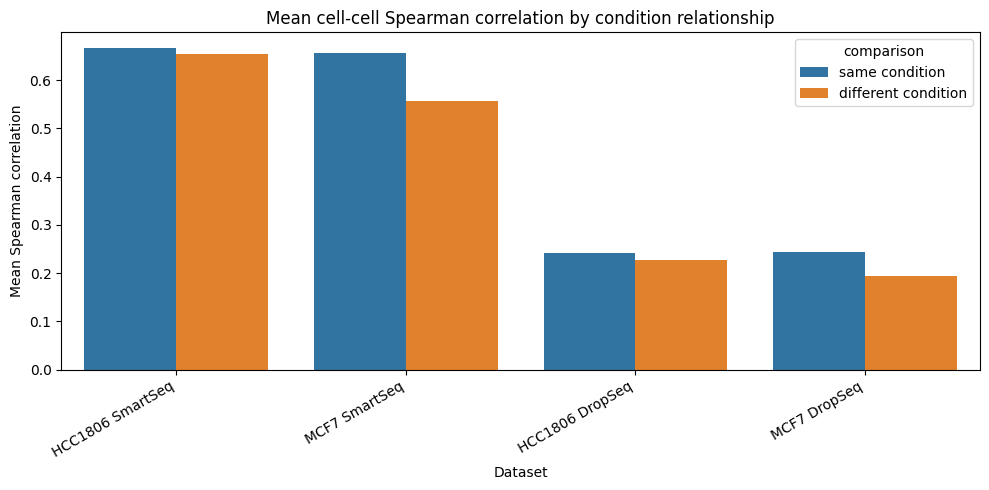

Top cell-cell correlation examples from each dataset:


,cell_1,cell_2,spearman_correlation,condition_1,condition_2,same_condition,dataset
0,output.STAR.PCRPlate2C12_Normoxia_S59_Aligned....,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,0.897035,Normoxia,Normoxia,True,HCC1806 SmartSeq
1,output.STAR.PCRPlate2A1_Hypoxia_S129_Aligned.s...,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,0.810975,Hypoxia,Normoxia,False,HCC1806 SmartSeq
2,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,output.STAR.PCRPlate3D1_Hypoxia_S161_Aligned.s...,0.799879,Normoxia,Hypoxia,False,HCC1806 SmartSeq
3,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned....,0.798810,Normoxia,Normoxia,True,HCC1806 SmartSeq
4,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,output.STAR.PCRPlate4E2_Hypoxia_S196_Aligned.s...,0.793642,Normoxia,Hypoxia,False,HCC1806 SmartSeq
5,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.s...,0.793461,Normoxia,Hypoxia,False,HCC1806 SmartSeq
6,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,output.STAR.PCRPlate4E8_Normoxia_S233_Aligned....,0.793022,Normoxia,Normoxia,True,HCC1806 SmartSeq
7,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,output.STAR.PCRPlate2F6_Hypoxia_S145_Aligned.s...,0.792560,Normoxia,Hypoxia,False,HCC1806 SmartSeq
8,output.STAR.PCRPlate2A1_Hypoxia_S129_Aligned.s...,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.s...,0.791903,Hypoxia,Hypoxia,True,HCC1806 SmartSeq
9,output.STAR.PCRPlate2D12_Normoxia_S60_Aligned....,output.STAR.PCRPlate4F7_Normoxia_S203_Aligned....,0.791625,Normoxia,Normoxia,True,HCC1806 SmartSeq


In [47]:
cell_corr_summary_rows = []
high_corr_pair_examples = []

for name, ds in datasets.items():
    expression_sample = sample_by_condition(
        ds["expression"],
        ds["cell_qc"],
        max_cells=800,
        random_state=67
    )

    corr = expression_sample.T.corr(method="spearman")
    corr.index.name = "cell_1"
    corr.columns.name = "cell_2"

    upper_triangle = np.triu(np.ones(corr.shape), k=1).astype(bool)
    pairs = (
        corr
        .where(upper_triangle)
        .stack()
        .rename("spearman_correlation")
        .reset_index()
    )

    meta = ds["cell_qc"].set_index("Filename")
    pairs["condition_1"] = pairs["cell_1"].map(meta["Condition"])
    pairs["condition_2"] = pairs["cell_2"].map(meta["Condition"])
    pairs["same_condition"] = pairs["condition_1"] == pairs["condition_2"]
    pairs["dataset"] = name

    cell_corr_summary_rows.append({
        "dataset": name,
        "sampled_cells": expression_sample.shape[0],
        "mean_correlation_all_pairs": pairs["spearman_correlation"].mean(),
        "median_correlation_all_pairs": pairs["spearman_correlation"].median(),
        "mean_correlation_same_condition": pairs.loc[pairs["same_condition"], "spearman_correlation"].mean(),
        "mean_correlation_different_condition": pairs.loc[~pairs["same_condition"], "spearman_correlation"].mean(),
        "pairs_correlation_ge_0_95": int((pairs["spearman_correlation"] >= 0.95).sum()),
        "pairs_correlation_ge_0_98": int((pairs["spearman_correlation"] >= 0.98).sum()),
    })

    high_pairs = pairs.sort_values("spearman_correlation", ascending=False).head(10).copy()
    high_corr_pair_examples.append(high_pairs)

cell_corr_summary = pd.DataFrame(cell_corr_summary_rows)
display(cell_corr_summary)

cell_corr_plot = cell_corr_summary.melt(
    id_vars="dataset",
    value_vars=["mean_correlation_same_condition", "mean_correlation_different_condition"],
    var_name="comparison",
    value_name="mean_spearman_correlation"
)

cell_corr_plot["comparison"] = cell_corr_plot["comparison"].replace({
    "mean_correlation_same_condition": "same condition",
    "mean_correlation_different_condition": "different condition"
})

plt.figure(figsize=(10, 5))
sns.barplot(data=cell_corr_plot, x="dataset", y="mean_spearman_correlation", hue="comparison")
plt.title("Mean cell-cell Spearman correlation by condition relationship")
plt.xlabel("Dataset")
plt.ylabel("Mean Spearman correlation")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

all_high_corr_pair_examples = pd.concat(high_corr_pair_examples, ignore_index=True)
print("Top cell-cell correlation examples from each dataset:")
display(all_high_corr_pair_examples.head(10))

<a id="gene-condition-associations-across-datasets"></a>
### **Gene-Condition Associations Across Datasets**

This section compares genes associated with hypoxia and normoxia across datasets. The aim is to see whether the same genes appear as condition-associated in different cell lines and technologies.

A gene that is consistently associated with hypoxia across datasets is more likely to represent a general hypoxia response. A gene that appears only in one dataset may still be biologically meaningful, but it may also depend on the specific cell line or sequencing technology.


In [48]:
def compute_gene_condition_associations(expression, cell_qc):
    meta = cell_qc.set_index("Filename").reindex(expression.index)
    condition_binary = meta["Condition"].map({
        "Normoxia": 0,
        "Normo": 0,
        "Hypoxia": 1,
        "Hypo": 1
    })

    rows = []
    hypoxia_mask = meta["Condition"].isin(["Hypoxia", "Hypo"])
    normoxia_mask = meta["Condition"].isin(["Normoxia", "Normo"])

    for gene in expression.columns:
        x_gene = expression[gene]
        valid = x_gene.notna() & condition_binary.notna()

        if valid.sum() < 3:
            continue

        if x_gene.loc[valid].nunique() <= 1:
            continue

        corr, p_value = stats.spearmanr(x_gene.loc[valid], condition_binary.loc[valid])

        rows.append({
            "gene": gene,
            "spearman_corr_with_hypoxia": corr,
            "p_value": p_value,
            "mean_hypoxia": x_gene.loc[hypoxia_mask].mean(),
            "mean_normoxia": x_gene.loc[normoxia_mask].mean(),
            "difference_hypoxia_minus_normoxia": x_gene.loc[hypoxia_mask].mean() - x_gene.loc[normoxia_mask].mean(),
            "detected_cells": (x_gene > 0).sum(),
            "zero_fraction": (x_gene == 0).mean()
        })

    return pd.DataFrame(rows)


gene_condition_results = {}
top_gene_tables = []

for name, ds in datasets.items():
    result = compute_gene_condition_associations(ds["expression"], ds["cell_qc"])
    result["dataset"] = name
    gene_condition_results[name] = result

    top_hypoxia = result.sort_values("spearman_corr_with_hypoxia", ascending=False).head(10).copy()
    top_normoxia = result.sort_values("spearman_corr_with_hypoxia", ascending=True).head(10).copy()
    top_hypoxia["association"] = "Higher in hypoxia"
    top_normoxia["association"] = "Higher in normoxia"
    top_gene_tables.append(pd.concat([top_hypoxia, top_normoxia], axis=0))

all_top_condition_genes = pd.concat(top_gene_tables, ignore_index=True)

print("Top condition-associated genes per dataset:")
display(all_top_condition_genes[["dataset", "gene", "spearman_corr_with_hypoxia", "association", "mean_hypoxia", "mean_normoxia", "zero_fraction"]])

Top condition-associated genes per dataset:


,dataset,gene,spearman_corr_with_hypoxia,association,mean_hypoxia,mean_normoxia,zero_fraction
0,HCC1806 SmartSeq,EGLN3,0.842321,Higher in hypoxia,398.701031,5.705882,0.346154
1,HCC1806 SmartSeq,DDIT4,0.836919,Higher in hypoxia,7114.268041,529.011765,0.032967
2,HCC1806 SmartSeq,ANGPTL4,0.833508,Higher in hypoxia,2261.577320,46.717647,0.137363
3,HCC1806 SmartSeq,BNIP3L,0.831261,Higher in hypoxia,427.742268,82.411765,0.021978
4,HCC1806 SmartSeq,NDRG1,0.830061,Higher in hypoxia,830.752577,32.400000,0.175824
...,...,...,...,...,...,...,...
75,MCF7 DropSeq,MT-CO3,-0.223546,Higher in normoxia,0.010201,0.171743,0.917091
76,MCF7 DropSeq,MT-ND3,-0.222891,Higher in normoxia,0.005717,0.152932,0.924258
77,MCF7 DropSeq,TOB1,-0.219828,Higher in normoxia,0.163322,0.473750,0.752428
78,MCF7 DropSeq,SET,-0.216522,Higher in normoxia,0.546575,1.054467,0.508416


/var/folders/32/2ltbk_x507lgxsywl8w2zd4m0000gn/T/ipykernel_48875/2316949522.py:8: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  top_gene_union = sorted(pd.unique(top_gene_union))


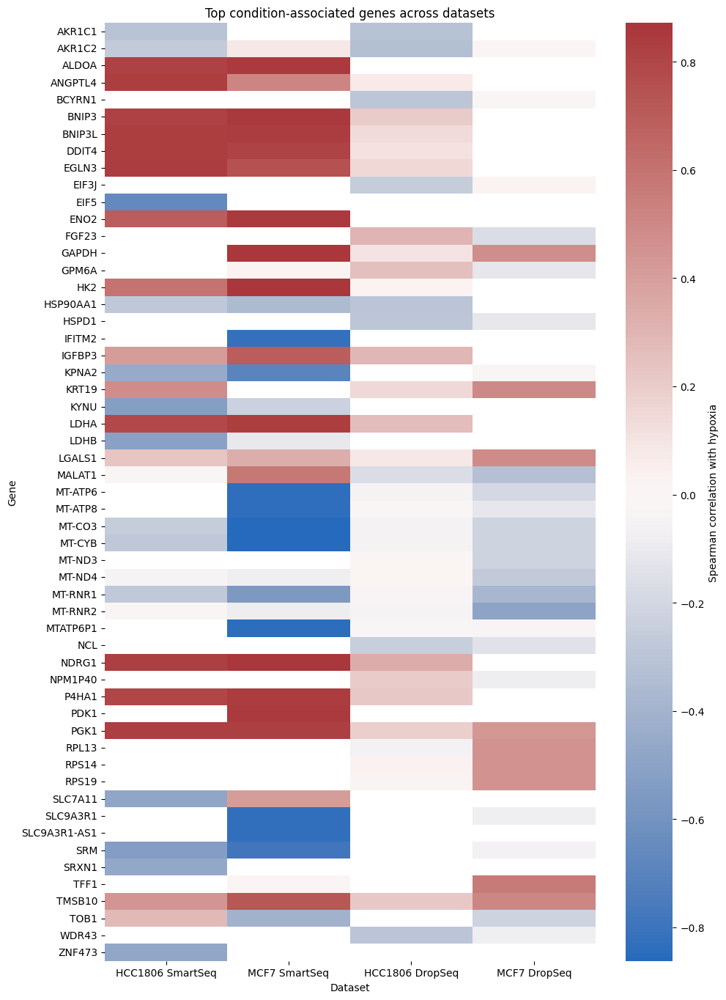

Known hypoxia-related genes, if present in the 3000-gene matrices:


,HCC1806 SmartSeq,MCF7 SmartSeq,HCC1806 DropSeq,MCF7 DropSeq
EGLN3,0.842321,0.750691,0.152896,NaN
DDIT4,0.836919,0.816370,0.109230,NaN
ANGPTL4,0.833508,0.517605,0.075259,NaN
BNIP3L,0.831261,0.843125,0.139623,NaN
NDRG1,0.830061,0.871819,0.337215,NaN
PGK1,0.827997,0.827649,0.190915,0.436479
BNIP3,0.822343,0.853715,0.205917,NaN
ALDOA,0.818457,0.850928,NaN,NaN
CA9,0.815672,0.610060,0.037676,NaN
ERO1A,0.799594,0.836869,0.096088,NaN


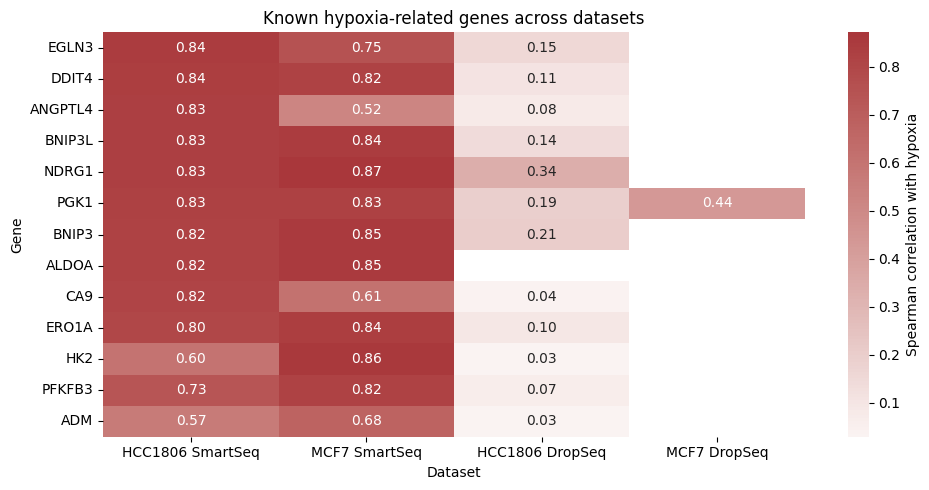

In [49]:
# Heatmap of recurrent top condition-associated genes across datasets

top_gene_union = []
for name, result in gene_condition_results.items():
    top_gene_union.extend(result.sort_values("spearman_corr_with_hypoxia", ascending=False).head(8)["gene"].tolist())
    top_gene_union.extend(result.sort_values("spearman_corr_with_hypoxia", ascending=True).head(8)["gene"].tolist())

top_gene_union = sorted(pd.unique(top_gene_union))

corr_heatmap = pd.DataFrame(index=top_gene_union)
for name, result in gene_condition_results.items():
    corr_heatmap[name] = result.set_index("gene")["spearman_corr_with_hypoxia"].reindex(top_gene_union)

plt.figure(figsize=(10, max(6, 0.25 * len(corr_heatmap))))
sns.heatmap(corr_heatmap, cmap="vlag", center=0, annot=False, cbar_kws={"label": "Spearman correlation with hypoxia"})
plt.title("Top condition-associated genes across datasets")
plt.xlabel("Dataset")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

known_hypoxia_genes = ["EGLN3", "DDIT4", "ANGPTL4", "BNIP3L", "NDRG1", "PGK1", "BNIP3", "ALDOA", "CA9", "ERO1A", "HK2", "PFKFB3", "ADM"]
known_hypoxia_table = pd.DataFrame(index=known_hypoxia_genes)
for name, result in gene_condition_results.items():
    known_hypoxia_table[name] = result.set_index("gene")["spearman_corr_with_hypoxia"].reindex(known_hypoxia_genes)

print("Known hypoxia-related genes, if present in the 3000-gene matrices:")
display(known_hypoxia_table)

plt.figure(figsize=(10, 5))
sns.heatmap(known_hypoxia_table, cmap="vlag", center=0, annot=True, fmt=".2f", cbar_kws={"label": "Spearman correlation with hypoxia"})
plt.title("Known hypoxia-related genes across datasets")
plt.xlabel("Dataset")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

<a id="gene-gene-redundancy-comparison"></a>
### **Gene-Gene Redundancy Comparison**

The gene-gene redundancy comparison looks for pairs of genes with very high expression correlation. Strongly correlated genes may represent shared biological programs, related gene families, or redundant information in the feature space.

This is useful for understanding whether some datasets contain many near-duplicate gene signals. It also helps explain why dimensionality reduction can be effective: if many genes move together, a smaller number of latent components may capture much of the structure.


,sampled_cells,constant_genes,pairs_abs_corr_ge_0_999,pairs_abs_corr_ge_0_99,pairs_abs_corr_ge_0_95,dataset
0,182,0,4,8,15,HCC1806 SmartSeq
1,250,0,25,30,47,MCF7 SmartSeq
2,800,631,214,214,214,HCC1806 DropSeq
3,800,548,223,223,223,MCF7 DropSeq


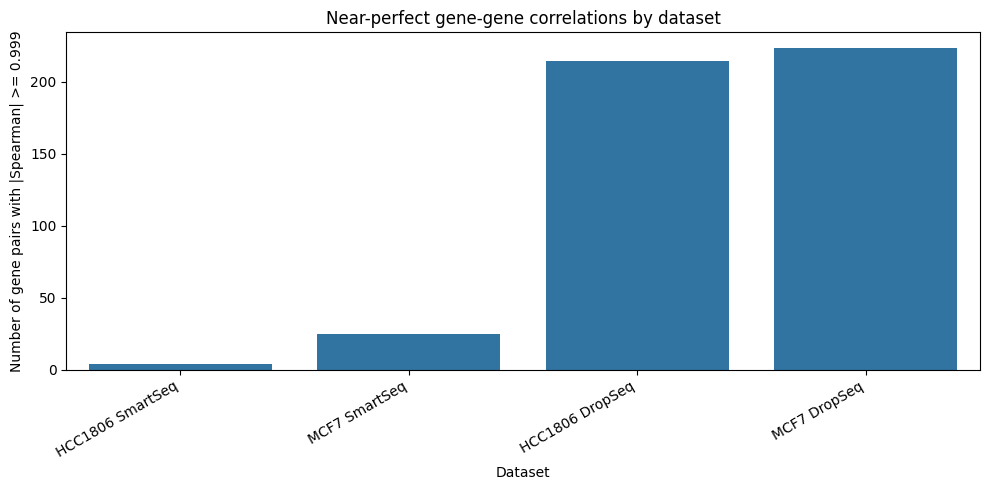

Top gene-gene correlated pairs from each dataset:


,gene_1,gene_2,spearman_correlation,absolute_correlation,dataset
0,MIR374B,MIR374C,1.000000,1.000000,HCC1806 SmartSeq
1,SERPINB3,SERPINB11,0.999937,0.999937,HCC1806 SmartSeq
2,MIF-AS1,MIF,0.999932,0.999932,HCC1806 SmartSeq
3,FTH1,BEST1,0.999677,0.999677,HCC1806 SmartSeq
4,ADIRF,ADIRF-AS1,0.996295,0.996295,HCC1806 SmartSeq
5,SERPINB2,SERPINB10,0.992370,0.992370,HCC1806 SmartSeq
6,GAS6,GAS6-AS1,0.992334,0.992334,HCC1806 SmartSeq
7,PLAU,C10orf55,0.990904,0.990904,HCC1806 SmartSeq
8,SQSTM1,MRNIP,0.988855,0.988855,HCC1806 SmartSeq
9,ALDH1A3,ALDH1A3-AS1,0.983761,0.983761,HCC1806 SmartSeq


In [50]:
def compute_gene_gene_redundancy(expression, cell_qc, max_cells=800):
    if len(expression) > max_cells:
        X_gene_corr = sample_by_condition(expression, cell_qc, max_cells=max_cells, random_state=67)
    else:
        X_gene_corr = expression.copy()

    constant_genes = X_gene_corr.columns[X_gene_corr.nunique(dropna=True) <= 1]
    gene_corr = X_gene_corr.corr(method="spearman")
    upper_triangle = np.triu(np.ones(gene_corr.shape), k=1).astype(bool)

    gene_corr_for_pairs = gene_corr.copy()
    gene_corr_for_pairs.index.name = "gene_1"
    gene_corr_for_pairs.columns.name = "gene_2"

    gene_pairs = (
        gene_corr_for_pairs
        .where(upper_triangle)
        .stack()
        .rename("spearman_correlation")
        .reset_index()
    )

    gene_pairs["absolute_correlation"] = gene_pairs["spearman_correlation"].abs()
    gene_pairs = gene_pairs.sort_values("absolute_correlation", ascending=False).reset_index(drop=True)

    summary = {
        "sampled_cells": X_gene_corr.shape[0],
        "constant_genes": len(constant_genes),
        "pairs_abs_corr_ge_0_999": int((gene_pairs["absolute_correlation"] >= 0.999).sum()),
        "pairs_abs_corr_ge_0_99": int((gene_pairs["absolute_correlation"] >= 0.99).sum()),
        "pairs_abs_corr_ge_0_95": int((gene_pairs["absolute_correlation"] >= 0.95).sum()),
    }

    return summary, gene_pairs


gene_gene_summary_rows = []
gene_gene_top_pairs = []

for name, ds in datasets.items():
    summary, pairs = compute_gene_gene_redundancy(ds["expression"], ds["cell_qc"])
    summary["dataset"] = name
    gene_gene_summary_rows.append(summary)
    top_pairs = pairs.head(10).copy()
    top_pairs["dataset"] = name
    gene_gene_top_pairs.append(top_pairs)

gene_gene_redundancy_summary = pd.DataFrame(gene_gene_summary_rows)
display(gene_gene_redundancy_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=gene_gene_redundancy_summary, x="dataset", y="pairs_abs_corr_ge_0_999")
plt.title("Near-perfect gene-gene correlations by dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of gene pairs with |Spearman| >= 0.999")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Top gene-gene correlated pairs from each dataset:")
display(pd.concat(gene_gene_top_pairs, ignore_index=True))

<a id="final-cross-dataset-eda-notes"></a>
### **Final Cross-Dataset EDA Notes**

The EDA shows that the datasets differ substantially in both biological and technical structure. SmartSeq and DropSeq have different sparsity and coverage profiles, while HCC1806 and MCF7 may respond differently to hypoxia because they represent different breast cancer contexts.

The detailed HCC1806 SmartSeq workflow shows why filtering and normalization are necessary: the raw matrix contains low-quality cells, rare genes, strong sparsity, and uneven expression coverage. The cross-dataset comparison then confirms that these issues do not appear in the same way across all datasets.

For the rest of the project, this means that downstream analyses should not treat all differences as purely biological. Some structure may come from hypoxia, but some may come from sequencing technology, cell line identity, preprocessing, or cell quality. The purpose of the following sections is therefore to separate, as much as possible, meaningful biological signal from technical structure.


<a id="dimensionality-reduction"></a>
## **DIMENSIONALITY REDUCTION**


Single-cell gene-expression matrices are high-dimensional: each cell is represented by thousands of gene-expression values, many of which are sparse, noisy, or redundant. Dimensionality reduction is used here to compress this information into lower-dimensional representations that are easier to visualize and later cluster, while trying to preserve the biological structure that separates cells or genes.

This section compares linear and nonlinear approaches. PCA is used as the main linear baseline because it finds orthogonal directions of maximal variance and gives an interpretable explained-variance curve. t-SNE and UMAP are used for visualization because they can reveal local neighborhood structure that may not be visible in the first two principal components. Autoencoders are then considered as neural nonlinear compression methods, especially useful when the geometry of the data is not well captured by linear projections.

The dimensionality-reduction results should be read as exploratory maps rather than direct biological proof. A visible separation may reflect hypoxia, normoxia, cell line, sequencing technology, sparsity, cell-cycle state, or a mixture of these factors. For this reason, every projection is interpreted together with the EDA results and is later tested more formally through clustering and downstream feature engineering.


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import gseapy as gp
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)

<a id="smartseq-hcc"></a>
### **SmartSeq HCC**


In [62]:
normalized_df = pd.read_csv('/Users/asca/Desktop/SmartSeq/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt',  sep=r"\s+")

In [3]:
normalized_df.shape

(3000, 182)

In [63]:
normalized_df = normalized_df.T
normalized_df.index.name = 'Filename'
normalized_df = normalized_df.reset_index()

print("Normalized DataFrame shape:", normalized_df.shape)

Normalized DataFrame shape: (182, 3001)


From the correlation matrix done before, I know the data is not correlated, so I just need to check sparsity, to see whether dimensionality reduction can be useful.

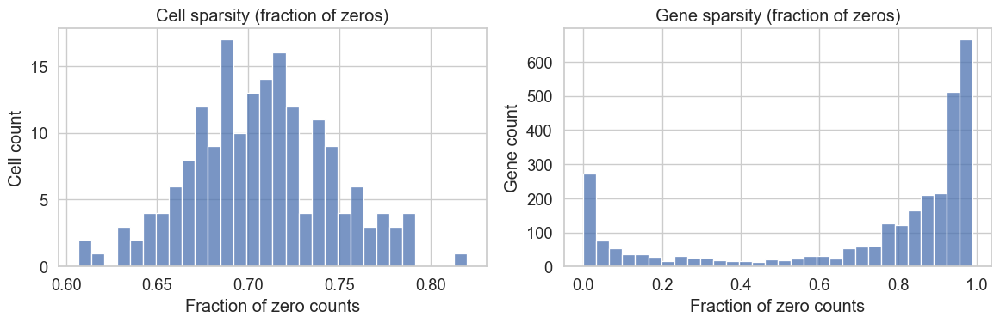

In [5]:
normalized_by_cell = normalized_df.set_index("Filename")

cell_sparsity = (normalized_by_cell == 0).mean(axis=1)
gene_sparsity = (normalized_by_cell == 0).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(cell_sparsity, bins=30, ax=axes[0])
axes[0].set_title("Cell sparsity (fraction of zeros)")
axes[0].set_xlabel("Fraction of zero counts")
axes[0].set_ylabel("Cell count")

sns.histplot(gene_sparsity, bins=30, ax=axes[1])
axes[1].set_title("Gene sparsity (fraction of zeros)")
axes[1].set_xlabel("Fraction of zero counts")
axes[1].set_ylabel("Gene count")

plt.tight_layout()

I see that on average cells have approximately 70% of zeros in the dataset. Such high sparsity means most of the 3000 gene-columns carry little information for any given cell, and many are near-constant or redundant. Dimensionality reduction should therefore be very useful: it can compress this largely empty, redundant space into a few informative dimensions.

<a id="pca"></a>
#### *PCA*


**How PCA works.** Principal Component Analysis is a *linear* dimensionality-reduction method. It looks for a new set of orthogonal axes (the *principal components*) along which the data varies the most, then keeps only the first few.

Given the data matrix $X \in \mathbb{R}^{n \times p}$ (here $n$ cells, $p$ genes):

1. Center the data: $\tilde{X} = X - \bar{X}$ (subtract each gene's mean).
2. Compute the covariance matrix $\;C = \dfrac{1}{n-1}\,\tilde{X}^{\top}\tilde{X}$.
3. Diagonalise it: $\;C v_k = \lambda_k v_k$, giving eigenvectors $v_k$ (the principal directions / *loadings*) and eigenvalues $\lambda_k$ (the variance captured along each direction).
4. Order components by decreasing $\lambda_k$ and project the data onto the top $d$ of them to obtain the scores:

$$Z = \tilde{X}\,V_d , \qquad V_d = [\,v_1, \dots, v_d\,].$$

The **fraction of variance explained** by component $k$ is

$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^{p}\lambda_j},$$

and we choose $d$ so that the cumulative ratio reaches a threshold (here 95%).

<a id="pca-on-log-transformed"></a>
##### *PCA on log-transformed*


At first I try PCA with the log-transformed data

In [64]:
normalized_log = np.log1p(normalized_df.drop(columns=["Filename"]))

In [7]:
pca = PCA(n_components=0.95)
pca.fit_transform(normalized_log)
pca.n_components_, pca.explained_variance_ratio_.sum()

(np.int64(157), np.float64(0.9509698289742512))

Thus I see that the best number of components is 157, with log-transformed data.

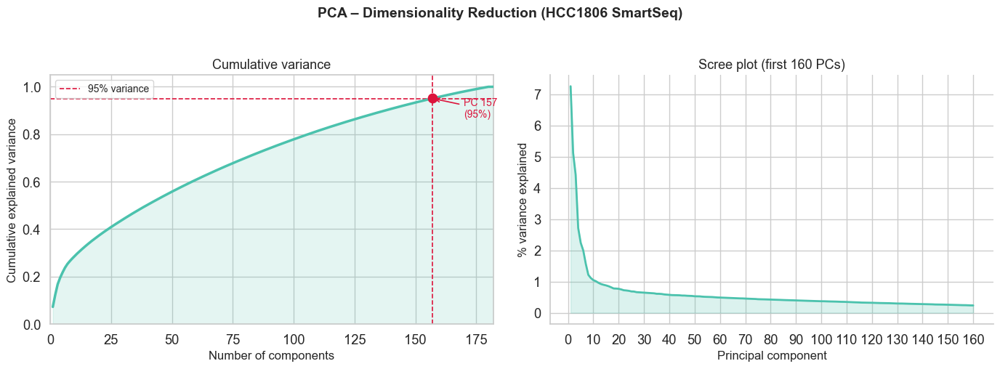

In [8]:
# ── style ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)
palette = sns.color_palette("mako", 3)

# ── fit full PCA to get complete curve ─────────────────────
X = normalized_log
pca_full = PCA()
pca_full.fit(X)

cumsum    = np.cumsum(pca_full.explained_variance_ratio_)
n_total   = len(cumsum)
dims      = np.arange(1, n_total + 1)

# 95% cutoff
d = np.searchsorted(cumsum, 0.95) + 1

# real elbow via second derivative
second_deriv = np.diff(np.diff(cumsum))
elbow_idx    = int(np.argmax(second_deriv)) + 2   # +2 for double diff offset

# ── figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA – Dimensionality Reduction (HCC1806 SmartSeq)",
             fontsize=14, fontweight="bold", y=1.02)

# ── LEFT: cumulative variance ───────────────────────────────
ax = axes[0]
ax.plot(dims, cumsum, color=palette[2], linewidth=2.5, zorder=3)
ax.fill_between(dims, cumsum, alpha=0.15, color=palette[2])

# 95% threshold lines
ax.axhline(0.95, color="crimson", linestyle="--", linewidth=1.2, label="95% variance")
ax.axvline(d,    color="crimson", linestyle="--", linewidth=1.2)
ax.scatter([d], [cumsum[d-1]], color="crimson", s=80, zorder=5)
ax.annotate(f"PC {d}\n(95%)",
            xy=(d, cumsum[d-1]),
            xytext=(d + n_total * 0.07, cumsum[d-1] - 0.08),
            fontsize=10, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))

ax.set_xlim(0, n_total)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Number of components", fontsize=12)
ax.set_ylabel("Cumulative explained variance", fontsize=12)
ax.set_title("Cumulative variance", fontsize=13)
ax.legend(fontsize=10)

# ── RIGHT: per-component variance (scree) ──────────────────
ax2 = axes[1]
top_n = 160
ratios = pca_full.explained_variance_ratio_[:top_n] * 100

ax2.plot(np.arange(1, top_n + 1), ratios, 
         color=palette[2], linewidth=2)
ax2.fill_between(np.arange(1, top_n + 1), ratios, 
                 alpha=0.2, color=palette[2])


ax2.set_xlabel("Principal component", fontsize=12)
ax2.set_ylabel("% variance explained", fontsize=12)
ax2.set_title(f"Scree plot (first {top_n} PCs)", fontsize=13)
ax2.set_xticks(np.arange(0, top_n + 1, 10))

sns.despine(ax=ax2, left=False)

plt.tight_layout()
plt.show()

<a id="pca-on-raw-normalized-data"></a>
##### *PCA on raw normalized data*


In [9]:
pca = PCA(n_components=0.95)
pca.fit_transform(normalized_df.drop(columns=["Filename"]))
pca.n_components_, pca.explained_variance_ratio_.sum()

(np.int64(34), np.float64(0.9508404630941673))

I see that the number of components needed drops a lot (34 versus 157). This is intuitive: in the raw data a handful of very highly expressed genes dominate the total variance, so PCA can capture 95% of it with only a few components. The log transformation compresses these large values, spreading the variance more evenly across many genes, so more components are then needed to reach the same 95%.

In [10]:
pca = PCA()
pca.fit_transform(normalized_df.drop(columns=["Filename"]))

array([[ 1.24841740e+04,  1.48266649e+04, -7.36023699e+03, ...,
         4.28598501e-01,  7.77272928e+00,  8.37495591e-12],
       [-1.26069763e+04, -1.26107426e+04,  3.85815235e+03, ...,
        -3.17055002e+01,  2.05300883e+01,  8.37495591e-12],
       [-7.01294847e+03, -1.89903767e+03,  4.99495512e+03, ...,
         5.57928667e+01,  2.81567326e+01,  8.37495591e-12],
       ...,
       [-6.48980787e+02,  9.23704546e+03,  1.31709906e+04, ...,
        -9.42648472e+00, -3.37656078e+00,  8.37495591e-12],
       [-1.20297480e+04,  9.48304499e+03, -5.14982657e+03, ...,
        -1.32373184e+02,  1.13611210e+01,  8.37495591e-12],
       [-5.43289801e+03,  6.68637993e+03, -1.25023927e+04, ...,
        -3.01977845e+02, -1.68725181e+01,  8.37495591e-12]],
      shape=(182, 182))

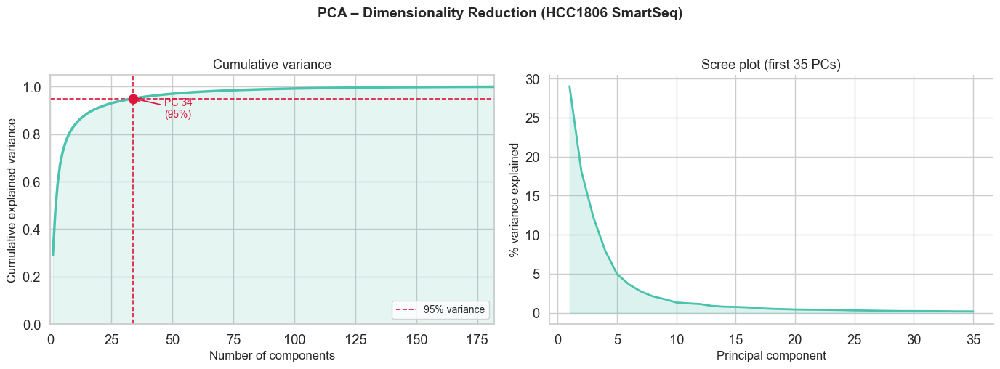

In [11]:
# ── style ──────────────────────────────────────────────────
palette = sns.color_palette("mako", 3)

# ── fit full PCA to get complete curve ─────────────────────
X = normalized_df.drop(columns=["Filename"])
pca_full = PCA()
pca_full.fit(X)

cumsum    = np.cumsum(pca_full.explained_variance_ratio_)
n_total   = len(cumsum)
dims      = np.arange(1, n_total + 1)

# 95% cutoff
d = np.searchsorted(cumsum, 0.95) + 1

# real elbow via second derivative
second_deriv = np.diff(np.diff(cumsum))
elbow_idx    = int(np.argmax(second_deriv)) + 2   # +2 for double diff offset

# ── figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA – Dimensionality Reduction (HCC1806 SmartSeq)",
             fontsize=14, fontweight="bold", y=1.02)

# ── LEFT: cumulative variance ───────────────────────────────
ax = axes[0]
ax.plot(dims, cumsum, color=palette[2], linewidth=2.5, zorder=3)
ax.fill_between(dims, cumsum, alpha=0.15, color=palette[2])

# 95% threshold lines
ax.axhline(0.95, color="crimson", linestyle="--", linewidth=1.2, label="95% variance")
ax.axvline(d,    color="crimson", linestyle="--", linewidth=1.2)
ax.scatter([d], [cumsum[d-1]], color="crimson", s=80, zorder=5)
ax.annotate(f"PC {d}\n(95%)",
            xy=(d, cumsum[d-1]),
            xytext=(d + n_total * 0.07, cumsum[d-1] - 0.08),
            fontsize=10, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))

ax.set_xlim(0, n_total)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Number of components", fontsize=12)
ax.set_ylabel("Cumulative explained variance", fontsize=12)
ax.set_title("Cumulative variance", fontsize=13)
ax.legend(fontsize=10)

# ── RIGHT: per-component variance (scree) ──────────────────
ax2 = axes[1]
top_n = 35
ratios = pca_full.explained_variance_ratio_[:top_n] * 100

ax2.plot(np.arange(1, top_n + 1), ratios, 
         color=palette[2], linewidth=2)
ax2.fill_between(np.arange(1, top_n + 1), ratios, 
                 alpha=0.2, color=palette[2])


ax2.set_xlabel("Principal component", fontsize=12)
ax2.set_ylabel("% variance explained", fontsize=12)
ax2.set_title(f"Scree plot (first {top_n} PCs)", fontsize=13)
ax2.set_xticks(np.arange(0, top_n + 1, 5))

sns.despine(ax=ax2, left=False)

plt.tight_layout()
plt.show()

<a id="pca-on-log-vs-pca-on-raw"></a>
##### *PCA on log vs PCA on raw*


But which PCA is better? The one with log-transformed data or the other? Let's check!

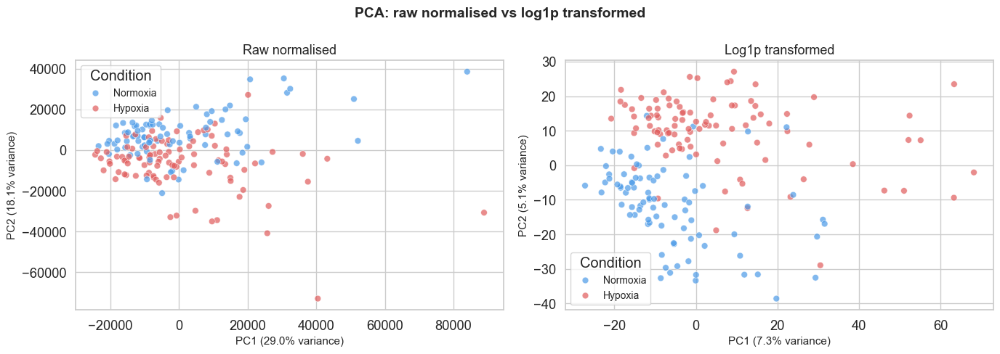

In [12]:
# ── prepare both versions ───────────────────────────────────
X = normalized_df.drop(columns=["Filename"])
labels = normalized_df["Filename"].str.contains("Hypoxia").map({True: "Hypoxia", False: "Normoxia"})

# raw normalised
pca_raw = PCA(n_components=2)
coords_raw = pca_raw.fit_transform(X)

# log1p transformed
pca_log = PCA(n_components=2)
coords_log = pca_log.fit_transform(normalized_log)

# ── build dataframes ────────────────────────────────────────
df_raw = pd.DataFrame(coords_raw, columns=["PC1", "PC2"])
df_raw["Condition"] = labels.values

df_log = pd.DataFrame(coords_log, columns=["PC1", "PC2"])
df_log["Condition"] = labels.values

# ── plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA: raw normalised vs log1p transformed", fontsize=14, fontweight="bold")

palette = {"Hypoxia": "#e05c5c", "Normoxia": "#4c9be8"}

for ax, df, pca_obj, title in zip(
    axes,
    [df_raw, df_log],
    [pca_raw, pca_log],
    ["Raw normalised", "Log1p transformed"]
):
    sns.scatterplot(
        data=df, x="PC1", y="PC2",
        hue="Condition", palette=palette,
        alpha=0.7, s=40, ax=ax
    )
    var1 = pca_obj.explained_variance_ratio_[0] * 100
    var2 = pca_obj.explained_variance_ratio_[1] * 100
    ax.set_xlabel(f"PC1 ({var1:.1f}% variance)", fontsize=11)
    ax.set_ylabel(f"PC2 ({var2:.1f}% variance)", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(title="Condition", fontsize=10)

plt.tight_layout()
plt.show()

<a id="t-sne"></a>
#### *t-SNE*


**How t-SNE works.** *t-distributed Stochastic Neighbour Embedding* is a **non-linear** technique used only for visualisation: it places points in 2-D so that local neighbourhoods are preserved.

1. In the original space it turns distances into probabilities. For each pair it defines a conditional similarity with a Gaussian kernel,

$$p_{j\mid i}=\frac{\exp\!\left(-\lVert x_i-x_j\rVert^{2}/2\sigma_i^{2}\right)}{\sum_{k\neq i}\exp\!\left(-\lVert x_i-x_k\rVert^{2}/2\sigma_i^{2}\right)},\qquad p_{ij}=\frac{p_{j\mid i}+p_{i\mid j}}{2n}.$$

The bandwidth $\sigma_i$ is set so that the effective number of neighbours equals the chosen **perplexity**.

2. In the 2-D map it uses a Student-t kernel with one degree of freedom:

$$q_{ij}=\frac{\left(1+\lVert y_i-y_j\rVert^{2}\right)^{-1}}{\sum_{k\neq l}\left(1+\lVert y_k-y_l\rVert^{2}\right)^{-1}}.$$

3. The map $\{y_i\}$ is optimised by gradient descent to minimise the Kullback–Leibler divergence between the two distributions:

$$\mathrm{KL}(P\,\Vert\,Q)=\sum_{i\neq j} p_{ij}\,\log\frac{p_{ij}}{q_{ij}}.$$

The axes have **no meaning**: only the presence and separation of clusters can be interpreted, not distances between them or cluster sizes.

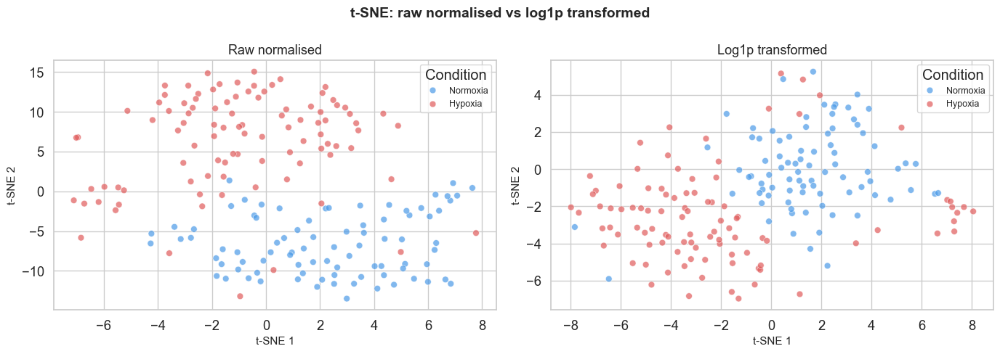

In [13]:
X = normalized_df.drop(columns=["Filename"])
labels = normalized_df["Filename"].str.contains("Hypoxia").map({True: "Hypoxia", False: "Normoxia"})

palette = {"Hypoxia": "#e05c5c", "Normoxia": "#4c9be8"}

# ── run t-SNE on both ───────────────────────────────────────

# reduce to PCs first, then t-SNE
pca_pre_raw = PCA(n_components=34)
pca_pre_log = PCA(n_components=157)

X_pca_raw = pca_pre_raw.fit_transform(X)
X_pca_log = pca_pre_log.fit_transform(normalized_log)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

coords_raw = tsne.fit_transform(X_pca_raw)
coords_log = tsne.fit_transform(X_pca_log)

df_raw = pd.DataFrame(coords_raw, columns=["tSNE1", "tSNE2"])
df_raw["Condition"] = labels.values

df_log = pd.DataFrame(coords_log, columns=["tSNE1", "tSNE2"])
df_log["Condition"] = labels.values

# ── plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("t-SNE: raw normalised vs log1p transformed",
             fontsize=14, fontweight="bold")

for ax, df, title in zip(
    axes,
    [df_raw, df_log],
    ["Raw normalised", "Log1p transformed"]
):
    sns.scatterplot(
        data=df, x="tSNE1", y="tSNE2",
        hue="Condition", palette=palette,
        alpha=0.7, s=40, ax=ax
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("t-SNE 1", fontsize=11)
    ax.set_ylabel("t-SNE 2", fontsize=11)
    ax.legend(title="Condition", fontsize=9)

plt.tight_layout()
plt.show()

We see that neither representation separates the conditions clearly. I will nevertheless proceed with the log-transformed data: log1p compresses the heavy right-skew of count data and stabilises the variance, so a few highly expressed genes no longer dominate distance- and gradient-based computations. This generally makes it a more reliable input for the ML methods that follow.

<a id="significance-of-components"></a>
##### *Significance of components*


Now I want to understand if the PCA components are really meaningful for us. I use two different approaches for PCA on raw data and on log data.

- For **log data**, since the first component explains only ~7% of the variance, the explained variance is spread fairly uniformly across all components. I therefore compute, across all components, a variance-weighted average of each gene's loading. I select the genes with the highest weights (i.e. those contributing most to the overall variance) and check whether they appear in the HALLMARK_HYPOXIA list from GSEA, which would indicate they are genuinely involved in the hypoxia response. That database contains genes the scientific community has acknowledged as hypoxia contributors.
- For **raw data**, the first component explains ~29% of the variance, meaning it dominates the others. I therefore check the 50 genes with the highest absolute loading on PC1 alone.

In [14]:
pca = PCA(n_components=34)
pca.fit(normalized_df.drop(columns=["Filename"]))
pca_log = PCA(n_components=157)
pca_log.fit(normalized_log)

gene_sets = gp.get_library(name="MSigDB_Hallmark_2020")
hypoxia_genes = set(gene_sets["Hypoxia"])

In [15]:
# weighted average of loadings across ALL components for log data
# weight each PC by how much variance it explains
variance_weights = pca_log.explained_variance_ratio_  
loadings_log = pd.DataFrame(
    pca_log.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca_log.n_components_)]
)
# weighted sum of absolute loadings across all PCs
weighted_loadings = loadings_log.abs().mul(variance_weights, axis=1).sum(axis=1)
weighted_loadings = weighted_loadings.sort_values(ascending=False)

# top 50 most important genes overall
top_genes_log_weighted = set(weighted_loadings.head(50).index)

overlap_log = top_genes_log_weighted & hypoxia_genes
print(f"Log1p weighted overlap: {len(overlap_log)} / {len(hypoxia_genes)}")
print(overlap_log)

Log1p weighted overlap: 5 / 200
{'TGM2', 'IGFBP3', 'LOX', 'ANGPTL4', 'ACKR3'}


I see that, selecting the 50 genes with the highest weights, 5 of them are present in the Hypoxia database. Is it good? Is it better than randomly choosing 50 genes among all the 3000 we have? I perform a statistical test to verify it.

**The statistical test (hypergeometric test).** I want to know whether finding $k$ hypoxia genes among my top-$N$ selected genes is more than I would expect by chance. This is an *over-representation* (enrichment) test, and the exact null distribution is the **hypergeometric** one.

Picture an urn with $M$ genes in total, of which $n$ are "hypoxia" genes (the HALLMARK_HYPOXIA set). I draw $N$ genes without replacement (my top-loading genes). The probability of drawing exactly $k$ hypoxia genes is

$$P(X=k)=\frac{\dbinom{n}{k}\dbinom{M-n}{N-k}}{\dbinom{M}{N}}.$$

The number expected purely by chance is

$$\mathbb{E}[X]=N\,\frac{n}{M}.$$

The **p-value** for enrichment is the probability of observing at least $k$ hits:

$$p = P(X\ge k)=\sum_{i=k}^{\min(n,N)}\frac{\dbinom{n}{i}\dbinom{M-n}{N-i}}{\dbinom{M}{N}}.$$

In code this is `hypergeom.sf(k-1, M, n, N)`. A small p-value ($<0.05$) means the overlap is significantly larger than random; a large one means the selected genes are no more enriched in hypoxia genes than a random pick.

In [16]:
# quick hypergeometric test (statistical significance)
from scipy.stats import hypergeom

M = len(X.columns)      # total genes in your dataset (~3000)
n = len(hypoxia_genes)  # hypoxia genes in dataset (up to 200)
N = 50                  # how many you picked (top 50 loadings)
k = len(overlap_log)        # observed overlap

# p-value: probability of getting >= 5 by chance
p_value = hypergeom.sf(k-1, M, n, N)
print(f"Expected by chance: {N * n / M:.2f}")
print(f"Observed: {k}")
print(f"p-value: {p_value:.4f}")

Expected by chance: 3.33
Observed: 5
p-value: 0.2380


Now it's the time of raw data

In [17]:
# ── raw PCA loadings — PC1 only ──────────────────────────────
loadings_raw = pd.DataFrame(
    pca_raw.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca_raw.n_components_)]
)

# top 50 genes by absolute loading on PC1 only
top_genes_raw = set(loadings_raw["PC1"].abs()
                    .sort_values(ascending=False)
                    .head(50).index)

overlap_raw = top_genes_raw & hypoxia_genes
print(f"Raw PC1 overlap: {len(overlap_raw)} / {len(hypoxia_genes)}")
print(overlap_raw)

M = len(X.columns)        # total genes
n = len(hypoxia_genes)    # hypoxia genes in dataset
N = 50                    # top genes selected
k = len(overlap_raw)      # observed overlap

p_value = hypergeom.sf(k-1, M, n, N)
print(f"\nExpected by chance: {N * n / M:.2f}")
print(f"Observed: {k}")
print(f"p-value: {p_value:.4f}")

Raw PC1 overlap: 5 / 200
{'ALDOA', 'HSPA5', 'IGFBP3', 'MIF', 'CAV1'}

Expected by chance: 3.33
Observed: 5
p-value: 0.2380


I see that the result obtained is not statistically significant, neither for raw data nor for log data, as the p-values are bigger than 0.05. Now I check what would happen if I selected more than 50 genes with raw data, just out of curiosity.

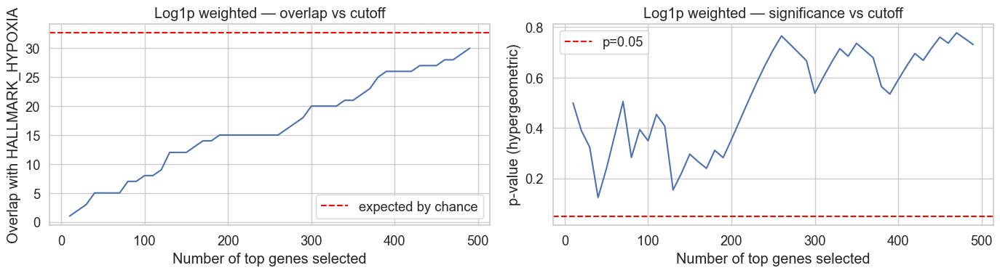

In [18]:
variance_weights_log = pca_log.explained_variance_ratio_

loadings_log = pd.DataFrame(
    pca_log.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca_log.n_components_)]
)

weighted_loadings_log = (loadings_log.abs()
                         .mul(variance_weights_log, axis=1)
                         .sum(axis=1)
                         .sort_values(ascending=False))

cutoffs  = range(10, 500, 10)
overlaps = []
p_values = []

for n_top in cutoffs:
    top = set(weighted_loadings_log.head(n_top).index)  # ← explicitly log
    ov  = top & hypoxia_genes
    p   = hypergeom.sf(len(ov)-1, M, n, n_top)
    overlaps.append(len(ov))
    p_values.append(p)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(x=list(cutoffs), y=overlaps, ax=axes[0])
axes[0].axhline(y=list(cutoffs)[-1] * len(hypoxia_genes) / M,
                color="red", linestyle="--", label="expected by chance")
axes[0].set_xlabel("Number of top genes selected")
axes[0].set_ylabel("Overlap with HALLMARK_HYPOXIA")
axes[0].set_title("Log1p weighted — overlap vs cutoff")
axes[0].legend()

sns.lineplot(x=list(cutoffs), y=p_values, ax=axes[1])
axes[1].axhline(y=0.05, color="red", linestyle="--", label="p=0.05")
axes[1].set_xlabel("Number of top genes selected")
axes[1].set_ylabel("p-value (hypergeometric)")
axes[1].set_title("Log1p weighted — significance vs cutoff")
axes[1].legend()

plt.tight_layout()
plt.show()

These findings suggest that PCA alone is insufficient to isolate the hypoxia response in this dataset, motivating the use of supervised classification approaches on the log1p PCA-reduced data in subsequent analyses.

<a id="umap"></a>
#### *Umap*


**How UMAP works.** *Uniform Manifold Approximation and Projection* is a **non-linear**, graph-based method. Like t-SNE it preserves local neighbourhoods, but it also retains more of the global structure and is much faster.

1. **Build a weighted neighbour graph.** For each point it connects its `n_neighbors` nearest neighbours, with a smooth (fuzzy) membership strength

$$w(x_i,x_j)=\exp\!\left(-\frac{\max\!\big(0,\; d(x_i,x_j)-\rho_i\big)}{\sigma_i}\right),$$

where $\rho_i$ is the distance to the nearest neighbour and $\sigma_i$ is chosen so the local connectivity matches `n_neighbors`. The directed graph is symmetrised into a fuzzy union, $W = A + A^{\top} - A\circ A^{\top}$.

2. **Low-dimensional similarities** use a smooth curve controlled by `min_dist` (parameters $a,b$):

$$q_{ij}=\left(1+a\,\lVert y_i-y_j\rVert^{2b}\right)^{-1}.$$

3. **Optimise the layout** by minimising the fuzzy-set cross-entropy between the high- and low-dimensional graphs (via stochastic gradient descent with negative sampling):

$$\mathcal{C}=\sum_{i\neq j}\Big[\,w_{ij}\log\frac{w_{ij}}{q_{ij}}+(1-w_{ij})\log\frac{1-w_{ij}}{1-q_{ij}}\Big].$$

As with t-SNE the axes are not interpretable; only the cluster structure is.

First, I check whether UMAP shows that the data separate into Hypoxia / Non-Hypoxia.

/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


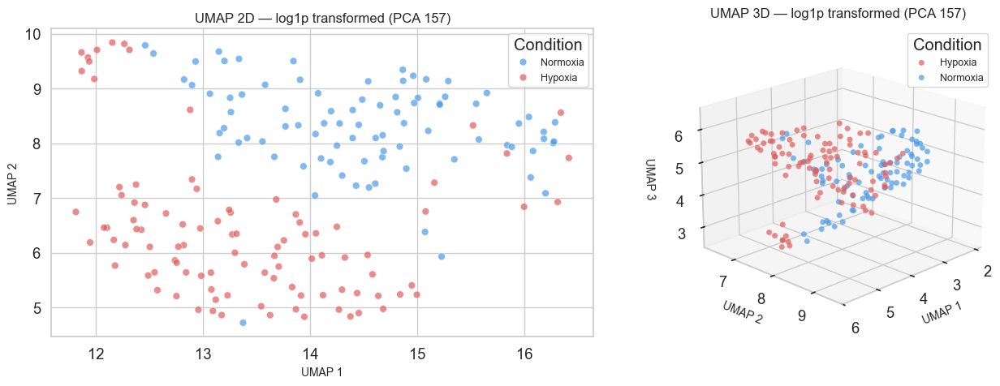

In [19]:
import umap
from mpl_toolkits.mplot3d import Axes3D

# ── PCA pre-reduction ────────────────────────────────────────
X_pca_log = PCA(n_components=157, random_state=42).fit_transform(normalized_log)

# ── UMAP 2D ─────────────────────────────────────────────────
coords_log = umap.UMAP(n_neighbors=15, min_dist=0.1,
                       n_components=2, random_state=42).fit_transform(X_pca_log)
df = pd.DataFrame(coords_log, columns=["UMAP1", "UMAP2"])
df["Condition"] = labels.values

# ── UMAP 3D ─────────────────────────────────────────────────
coords_3d = umap.UMAP(n_neighbors=15, min_dist=0.1,
                      n_components=3, random_state=42).fit_transform(X_pca_log)

# ── side-by-side plots ───────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
ax2d = fig.add_subplot(1, 2, 1)
ax3d = fig.add_subplot(1, 2, 2, projection="3d")

sns.scatterplot(data=df, x="UMAP1", y="UMAP2",
                hue="Condition", palette=palette,
                alpha=0.7, s=40, ax=ax2d)
ax2d.set_title("UMAP 2D — log1p transformed (PCA 157)", fontsize=12)
ax2d.set_xlabel("UMAP 1", fontsize=10)
ax2d.set_ylabel("UMAP 2", fontsize=10)
ax2d.legend(title="Condition", fontsize=9)

for condition, color in palette.items():
    mask = labels.values == condition
    ax3d.scatter(
        coords_3d[mask, 0],
        coords_3d[mask, 1],
        coords_3d[mask, 2],
        c=color, label=condition,
        alpha=0.7, s=25, edgecolors="none"
    )

ax3d.set_title("UMAP 3D — log1p transformed (PCA 157)", fontsize=12, pad=10)
ax3d.set_xlabel("UMAP 1", fontsize=10, labelpad=6)
ax3d.set_ylabel("UMAP 2", fontsize=10, labelpad=6)
ax3d.set_zlabel("UMAP 3", fontsize=10, labelpad=6)
ax3d.legend(title="Condition", fontsize=9)
ax3d.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

Thus, even Umap reveals a poor separation. I now try to modify the number of neighbors parameter, to see whether the separation improves

/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


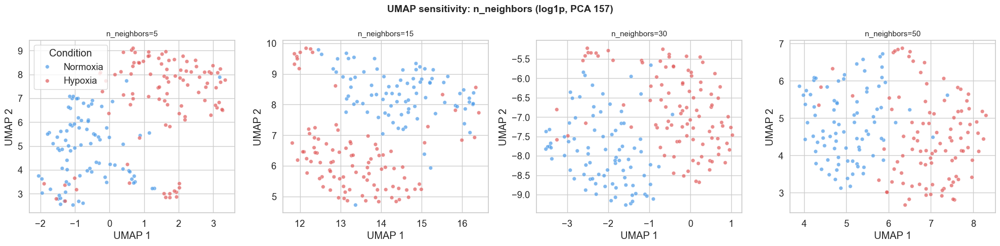

In [20]:
n_neighbors_list = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("UMAP sensitivity: n_neighbors (log1p, PCA 157)",
             fontsize=14, fontweight="bold")

for ax, n_neigh in zip(axes, n_neighbors_list):
    coords = umap.UMAP(n_neighbors=n_neigh, min_dist=0.1,
                       n_components=2, random_state=42).fit_transform(X_pca_log)
    df_s = pd.DataFrame(coords, columns=["UMAP1", "UMAP2"])
    df_s["Condition"] = labels.values
    sns.scatterplot(data=df_s, x="UMAP1", y="UMAP2",
                    hue="Condition", palette=palette,
                    alpha=0.7, s=30, ax=ax,
                    legend=(n_neigh == 5))
    ax.set_title(f"n_neighbors={n_neigh}", fontsize=11)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

Separation did not improve

Now I use UMAP to reduce dimensions but with respect to genes: I treat genes as data points, and the cells as their dimensions. I want to see whether UMAP reveals some structure.

/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


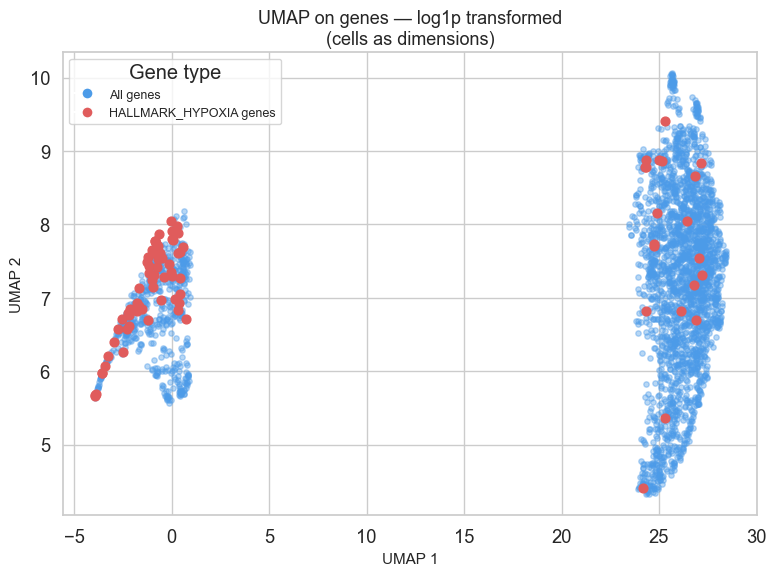

In [21]:
# ── transpose: genes as points, cells as dimensions ─────────
X_log_T = normalized_log.T  # shape: (3000 genes, n_cells)

# ── PCA pre-reduction on transposed data ────────────────────
# now n_components must be <= n_cells
X_pca_T = PCA(n_components=157, random_state=42).fit_transform(X_log_T)

# ── UMAP ────────────────────────────────────────────────────
coords_genes = umap.UMAP(n_neighbors=15, min_dist=0.1,
                         n_components=2, random_state=42).fit_transform(X_pca_T)

# ── plot ────────────────────────────────────────────────────
df_genes = pd.DataFrame(coords_genes, columns=["UMAP1", "UMAP2"])
df_genes["Gene"] = normalized_log.columns  # gene names as labels

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_genes["UMAP1"], df_genes["UMAP2"],
           alpha=0.4, s=15, color="#4c9be8")

# highlight hypoxia genes if they appear
for gene in df_genes["Gene"]:
    if gene in hypoxia_genes:
        row = df_genes[df_genes["Gene"] == gene]
        ax.scatter(row["UMAP1"], row["UMAP2"],
                   color="#e05c5c", s=40, zorder=5)

# add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4c9be8",
           markersize=8, label="All genes"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#e05c5c",
           markersize=8, label="HALLMARK_HYPOXIA genes")
]
ax.legend(handles=legend_elements, title="Gene type", fontsize=9)
ax.set_title("UMAP on genes — log1p transformed\n(cells as dimensions)",
             fontsize=13)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)

plt.tight_layout()
plt.show()

I see that UMAP reveals two distinct gene clusters. The smaller right one shows strong enrichment for HALLMARK Hypoxia genes, suggesting it represents a coherent hypoxia transcriptional programme. This finding contrasts with the weak cell-level separation observed in previous analyses.

<a id="autoencoder"></a>
#### *Autoencoder*


**How an autoencoder works.** An autoencoder is a neural network that learns a compressed representation of the data by trying to **reconstruct its own input**. It is a *non-linear* generalisation of PCA.

It has two parts:

- an **encoder** $f_\theta:\mathbb{R}^{D}\to\mathbb{R}^{d}$ that maps the input to a low-dimensional *bottleneck* ($d \ll D$): $\;z = f_\theta(x)$;
- a **decoder** $g_\phi:\mathbb{R}^{d}\to\mathbb{R}^{D}$ that maps the bottleneck back to the original space: $\;\hat{x} = g_\phi(z)$.

Each layer applies an affine map followed by a non-linear activation; here we use ReLU, $\sigma(t)=\max(0,t)$:

$$h^{(l)}=\sigma\!\big(W^{(l)}h^{(l-1)}+b^{(l)}\big).$$

The weights $\{\theta,\phi\}$ are trained by gradient descent (Adam) to minimise the **reconstruction loss** — the mean squared error between input and output:

$$\mathcal{L}(\theta,\phi)=\frac{1}{n}\sum_{i=1}^{n}\big\lVert x_i-g_\phi\big(f_\theta(x_i)\big)\big\rVert^{2}.$$

Once trained, the bottleneck $z$ is used as the reduced representation. Because the activations are non-linear, the autoencoder can capture curved structure that PCA (being linear) cannot — in fact, with linear activations and MSE loss the autoencoder recovers exactly the PCA subspace.

Now I use an autoencoder, hoping it will give interesting results.

First I want to know which is the best bottleneck for our data.

In [22]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

Training bottleneck=2...
  train loss: 0.6908 | val loss: 1.0519
Training bottleneck=4...
  train loss: 0.2021 | val loss: 1.1131
Training bottleneck=8...
  train loss: 0.0164 | val loss: 1.0437
Training bottleneck=16...
  train loss: 0.0121 | val loss: 1.0079
Training bottleneck=32...
  train loss: 0.0058 | val loss: 0.9997
Training bottleneck=64...
  train loss: 0.0361 | val loss: 0.9868
Training bottleneck=128...
  train loss: 0.0141 | val loss: 0.9824


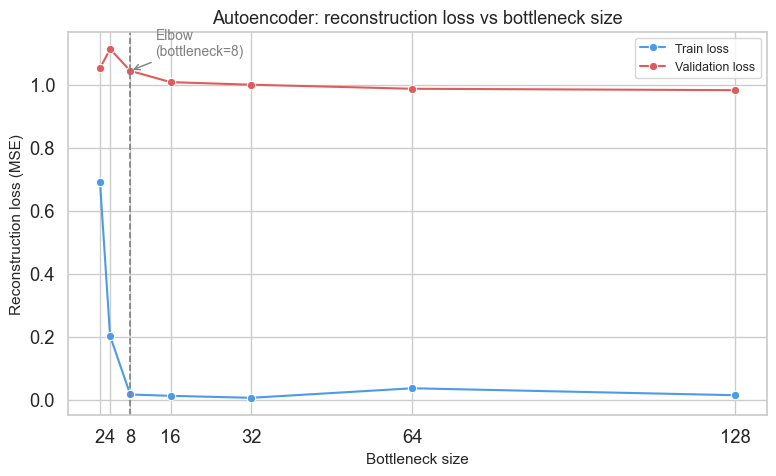


Bottleneck      Train loss      Val loss
---------------------------------------------
2               0.6908          1.0519
4               0.2021          1.1131
8               0.0164          1.0437
16              0.0121          1.0079
32              0.0058          0.9997
64              0.0361          0.9868
128             0.0141          0.9824

Suggested bottleneck (elbow): 8


In [23]:
# ── data prep ────────────────────────────────────────────────
# scale to 0 mean unit variance — important for neural networks
scaler = StandardScaler()
X_scaled = scaler.fit_transform(normalized_log)

# convert to torch tensor
X_tensor = torch.FloatTensor(X_scaled)
dataset   = TensorDataset(X_tensor)
loader    = DataLoader(dataset, batch_size=32, shuffle=True)

n_genes      = X_scaled.shape[1]   # 3000

# train/val split
val_size   = int(0.1 * len(X_tensor))
train_size = len(X_tensor) - val_size
train_data, val_data = torch.utils.data.random_split(
    TensorDataset(X_tensor), [train_size, val_size]
)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)

# ── autoencoder class ─────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 128),       nn.ReLU(),
            nn.Linear(128, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 128), nn.ReLU(),
            nn.Linear(128, 512),            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ── train function ────────────────────────────────────────────
def train_autoencoder(bottleneck, n_epochs=100):
    model     = Autoencoder(n_genes, bottleneck)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(n_epochs):
        # training
        model.train()
        for (batch,) in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()

    # final losses
    model.eval()
    with torch.no_grad():
        train_loss = sum(criterion(model(b[0]), b[0]).item()
                        for b in train_loader) / len(train_loader)
        val_loss   = sum(criterion(model(b[0]), b[0]).item()
                        for b in val_loader)   / len(val_loader)

    return train_loss, val_loss, model

# ── run for each bottleneck ───────────────────────────────────
bottlenecks  = [2, 4, 8, 16, 32, 64, 128]
train_losses = []
val_losses   = []
models       = {}

for bottleneck in bottlenecks:
    print(f"Training bottleneck={bottleneck}...")
    tl, vl, model = train_autoencoder(bottleneck)
    train_losses.append(tl)
    val_losses.append(vl)
    models[bottleneck] = model
    print(f"  train loss: {tl:.4f} | val loss: {vl:.4f}")

# ── plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(x=bottlenecks, y=train_losses,
             marker="o", label="Train loss",
             ax=ax, color="#4c9be8")
sns.lineplot(x=bottlenecks, y=val_losses,
             marker="o", label="Validation loss",
             ax=ax, color="#e05c5c")

# elbow detection
second_deriv = np.diff(np.diff(val_losses))
elbow_idx    = np.argmax(second_deriv) + 1
elbow_val    = bottlenecks[elbow_idx]

ax.axvline(elbow_val, color="gray", linestyle="--", linewidth=1.2)
ax.annotate(f"Elbow\n(bottleneck={elbow_val})",
            xy=(elbow_val, val_losses[elbow_idx]),
            xytext=(elbow_val + 5, val_losses[elbow_idx] + 0.05),
            fontsize=10, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Bottleneck size", fontsize=11)
ax.set_ylabel("Reconstruction loss (MSE)", fontsize=11)
ax.set_title("Autoencoder: reconstruction loss vs bottleneck size",
             fontsize=13)
ax.set_xticks(bottlenecks)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── summary ───────────────────────────────────────────────────
print(f"\n{'Bottleneck':<15} {'Train loss':<15} {'Val loss'}")
print("-" * 45)
for b, tl, vl in zip(bottlenecks, train_losses, val_losses):
    print(f"{b:<15} {tl:<15.4f} {vl:.4f}")
print(f"\nSuggested bottleneck (elbow): {elbow_val}")

Now I try to see if Umap reveals separation between hypoxia and non on the data reduced by the autoencoder.

Epoch 10/100 — loss: 0.7203
Epoch 20/100 — loss: 0.3673
Epoch 30/100 — loss: 0.1401
Epoch 40/100 — loss: 0.0513
Epoch 50/100 — loss: 0.0205
Epoch 60/100 — loss: 0.0110
Epoch 70/100 — loss: 0.0109
Epoch 80/100 — loss: 0.0143
Epoch 90/100 — loss: 0.0111
Epoch 100/100 — loss: 0.0078


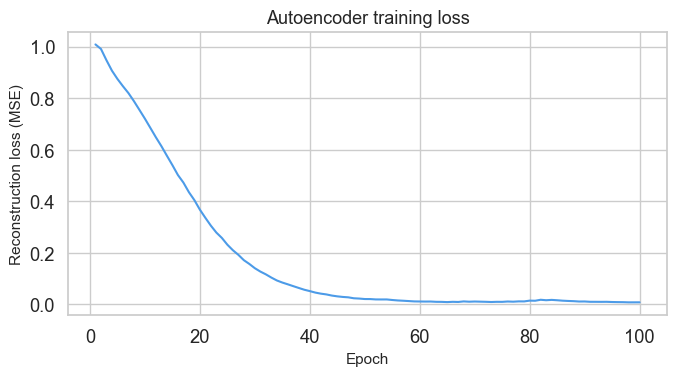

Bottleneck representation shape: (182, 64)


/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


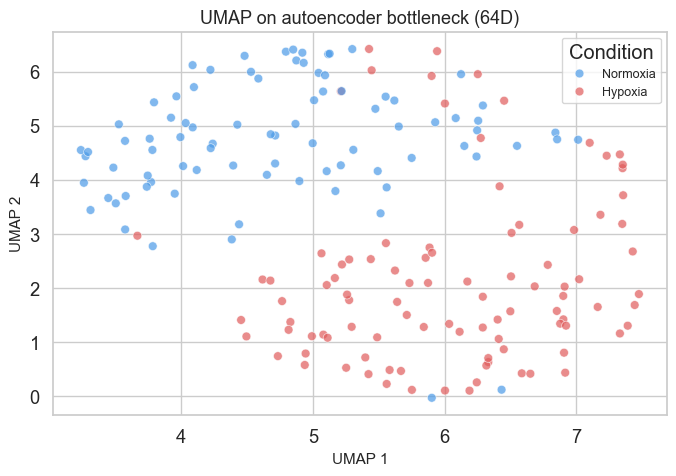

In [24]:
bottleneck = 64
model     = Autoencoder(n_genes, bottleneck)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ── training ─────────────────────────────────────────────────
n_epochs = 100
losses   = []

model.train()
for epoch in range(n_epochs):
    epoch_loss = 0
    for (batch,) in loader:
        optimizer.zero_grad()
        output = model(batch)
        loss   = criterion(output, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} — loss: {avg_loss:.4f}")

# ── plot training loss ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(x=range(1, n_epochs+1), y=losses, ax=ax, color="#4c9be8")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Reconstruction loss (MSE)", fontsize=11)
ax.set_title("Autoencoder training loss", fontsize=13)
plt.tight_layout()
plt.show()

# ── get bottleneck representation ────────────────────────────
model.eval()
with torch.no_grad():
    Z = model.encoder(X_tensor).numpy()  # shape: (n_cells, bottleneck)

print(f"Bottleneck representation shape: {Z.shape}")

# ── visualise with UMAP on bottleneck ────────────────────────
import umap

coords_ae = umap.UMAP(n_neighbors=15, min_dist=0.1,
                      n_components=2, random_state=42).fit_transform(Z)

df_ae = pd.DataFrame(coords_ae, columns=["UMAP1", "UMAP2"])
df_ae["Condition"] = labels.values

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_ae, x="UMAP1", y="UMAP2",
                hue="Condition", palette=palette,
                alpha=0.7, s=40, ax=ax)
ax.set_title(f"UMAP on autoencoder bottleneck ({bottleneck}D)", fontsize=13)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.legend(title="Condition", fontsize=9)
plt.tight_layout()
plt.show()

The separation in the autoencoder embedding does not fall along the first UMAP axis but is captured mainly by the second one: other sources of variation (e.g. cell cycle, technical effects) still dominate UMAP-1, while the Hypoxia/Normoxia signal emerges along UMAP-2. Overall, the 64-dimensional autoencoder bottleneck, visualised with UMAP, gives substantially clearer separation between Hypoxia and Normoxia than PCA or UMAP alone — hypoxic cells cluster predominantly in the upper region and normoxic cells in the lower region. This suggests the autoencoder learned a non-linear compression that preserves the hypoxia transcriptional signal, motivating the use of autoencoder-derived features as input to downstream supervised classifiers.

I save the compressed data to a CSV, so it can be used for supervised learning.

In [25]:
# ── save autoencoder-compressed SmartSeq data ────────────────
ae_df = pd.DataFrame(
    Z,
    index=normalized_df["Filename"].values,
    columns=[f"AE_{i+1}" for i in range(Z.shape[1])]
)

ae_df.to_csv("smartseq_autoencoder_embeddings.csv")
print(f"Saved: {ae_df.shape} → smartseq_autoencoder_embeddings.csv")
print(ae_df.head(3))

Saved: (182, 64) → smartseq_autoencoder_embeddings.csv
                                                        AE_1       AE_2  \
output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.s...  9.440177  11.908528   
output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.so... -4.973805   6.550324   
output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sort... -3.031197   9.688760   

                                                        AE_3       AE_4  \
output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.s... -1.435648   7.126331   
output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.so...  8.075567   4.708159   
output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sort...  4.947733  11.434556   

                                                         AE_5      AE_6  \
output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.s...   5.754166  1.435261   
output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.so...   2.092875  8.957577   
output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sort... -15.606347  7.639200   

                                          

Now I check if the autoencoder confirms the structure revealed by Umap on genes. 

Epoch 10/100 — loss: 0.1804
Epoch 20/100 — loss: 0.1428
Epoch 30/100 — loss: 0.1160
Epoch 40/100 — loss: 0.1007
Epoch 50/100 — loss: 0.0913
Epoch 60/100 — loss: 0.0851
Epoch 70/100 — loss: 0.0773
Epoch 80/100 — loss: 0.0748
Epoch 90/100 — loss: 0.0716
Epoch 100/100 — loss: 0.0776
Gene bottleneck shape: (3000, 32)


/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


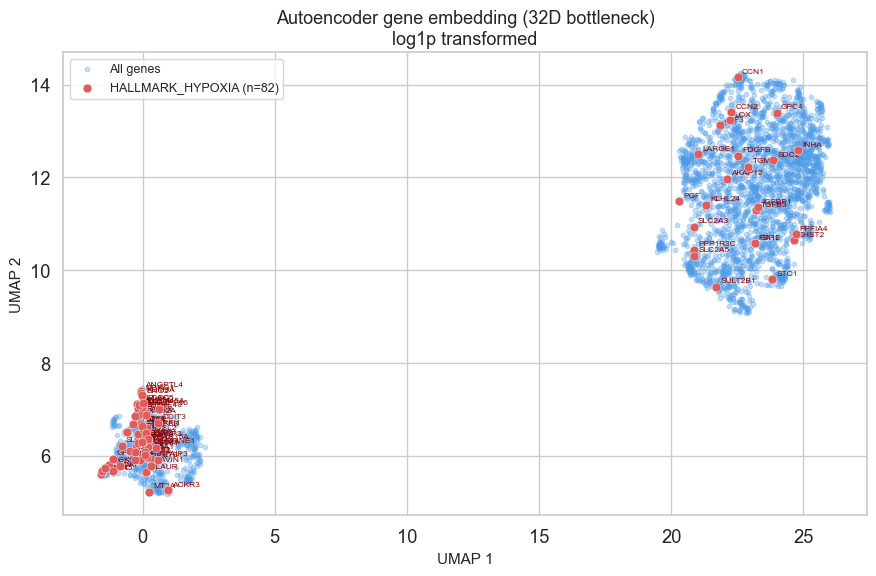

In [65]:
# ── transpose: genes as samples, cells as features ───────────
X_scaled_T = scaler.fit_transform(normalized_log.T)   # shape: (n_genes, n_cells)
X_tensor_T = torch.FloatTensor(X_scaled_T)

# new loader on transposed data
loader_T = DataLoader(TensorDataset(X_tensor_T),
                      batch_size=32, shuffle=True)

n_cells    = X_scaled_T.shape[1]   # input dim is now n_cells
bottleneck_genes = 32      # reuse same elbow or pick new one

# ── train on genes ────────────────────────────────────────────
model_genes = Autoencoder(n_cells, bottleneck_genes)  # ← n_cells not n_genes
optimizer   = torch.optim.Adam(model_genes.parameters(), lr=1e-3)
criterion   = nn.MSELoss()

model_genes.train()
for epoch in range(n_epochs):
    epoch_loss = 0
    for (batch,) in loader_T:                          # ← loader_T
        optimizer.zero_grad()
        loss = criterion(model_genes(batch), batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} — loss: {epoch_loss/len(loader_T):.4f}")

# ── get gene bottleneck ───────────────────────────────────────
model_genes.eval()
with torch.no_grad():
    Z_genes = model_genes.encoder(X_tensor_T).numpy()  # shape: (n_genes, bottleneck)

print(f"Gene bottleneck shape: {Z_genes.shape}")

# ── UMAP on gene bottleneck ───────────────────────────────────
coords_genes_ae = umap.UMAP(n_neighbors=15, min_dist=0.1,
                             n_components=2, random_state=42).fit_transform(Z_genes)

gene_names   = np.array(normalized_log.columns)
hypoxia_mask = np.array([gene in hypoxia_genes for gene in gene_names])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(coords_genes_ae[~hypoxia_mask, 0],
           coords_genes_ae[~hypoxia_mask, 1],
           alpha=0.3, s=10, color="#4c9be8", label="All genes")
ax.scatter(coords_genes_ae[hypoxia_mask, 0],
           coords_genes_ae[hypoxia_mask, 1],
           color="#e05c5c", s=40, zorder=5,
           edgecolors="white", linewidths=0.3,
           label=f"HALLMARK_HYPOXIA (n={hypoxia_mask.sum()})")

# label hypoxia genes
for i, gene in enumerate(gene_names):
    if gene in hypoxia_genes:
        ax.annotate(gene,
                    xy=(coords_genes_ae[i, 0], coords_genes_ae[i, 1]),
                    fontsize=6, color="darkred",
                    xytext=(3, 3), textcoords="offset points")

ax.set_title(f"Autoencoder gene embedding ({bottleneck_genes}D bottleneck)\nlog1p transformed",
             fontsize=13)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

I see that the autoencoder confirms the two gene clusters, with the smaller one containing the most of the Hallmark genes.

Now I train the autoencoder also for MCF7 data and then save compressed data in the csv

In [27]:
mcf7_df = pd.read_csv('/Users/asca/Desktop/SmartSeq/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt',  sep=r"\s+")

In [28]:
mcf7_df.shape

(3000, 250)

In [29]:
mcf7_df = mcf7_df.T
mcf7_df.index.name = 'Filename'
mcf7_df = mcf7_df.reset_index()

print("Normalized DataFrame shape:", mcf7_df.shape)

Normalized DataFrame shape: (250, 3001)


In [30]:
mcf7_log = np.log1p(mcf7_df.drop(columns=["Filename"]))

In [31]:
print(mcf7_df["Filename"].head(10).tolist())

['output.STAR.2_B3_Norm_S57_Aligned.sortedByCoord.out.bam', 'output.STAR.2_B4_Norm_S58_Aligned.sortedByCoord.out.bam', 'output.STAR.2_B5_Norm_S59_Aligned.sortedByCoord.out.bam', 'output.STAR.2_B6_Norm_S60_Aligned.sortedByCoord.out.bam', 'output.STAR.2_B7_Hypo_S79_Aligned.sortedByCoord.out.bam', 'output.STAR.2_B9_Hypo_S81_Aligned.sortedByCoord.out.bam', 'output.STAR.2_C10_Hypo_S130_Aligned.sortedByCoord.out.bam', 'output.STAR.2_C11_Hypo_S131_Aligned.sortedByCoord.out.bam', 'output.STAR.2_C1_Norm_S103_Aligned.sortedByCoord.out.bam', 'output.STAR.2_C2_Norm_S104_Aligned.sortedByCoord.out.bam']


Training bottleneck=2...
  train loss: 0.7056 | val loss: 0.8628
Training bottleneck=4...
  train loss: 0.4128 | val loss: 0.9195
Training bottleneck=8...
  train loss: 0.1575 | val loss: 0.9354
Training bottleneck=16...
  train loss: 0.1227 | val loss: 0.9130
Training bottleneck=32...
  train loss: 0.1019 | val loss: 0.9056
Training bottleneck=64...
  train loss: 0.0867 | val loss: 0.8830
Training bottleneck=128...
  train loss: 0.0984 | val loss: 0.8837


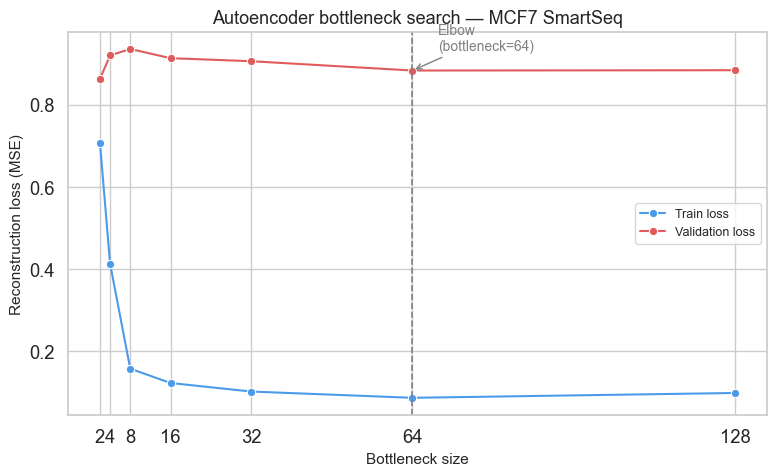

Suggested bottleneck: 64
Epoch 10/100 — loss: 0.7138
Epoch 20/100 — loss: 0.4619
Epoch 30/100 — loss: 0.2559
Epoch 40/100 — loss: 0.1427
Epoch 50/100 — loss: 0.0779
Epoch 60/100 — loss: 0.0362
Epoch 70/100 — loss: 0.0231
Epoch 80/100 — loss: 0.0185
Epoch 90/100 — loss: 0.0126
Epoch 100/100 — loss: 0.0150


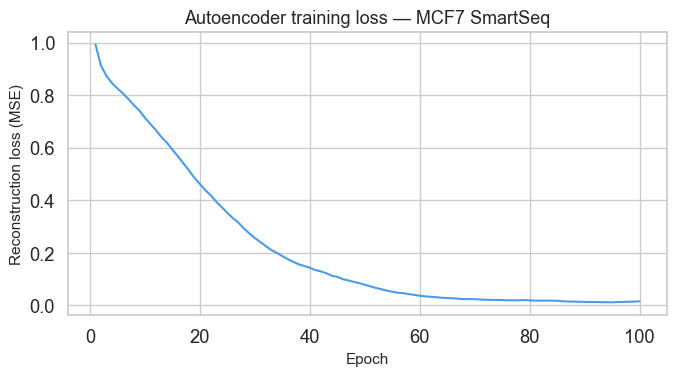

Bottleneck shape: (250, 64)


/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


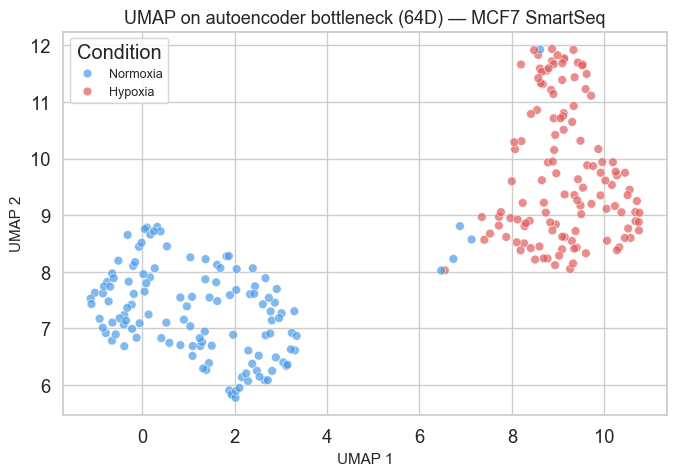

Saved: (250, 65) → mcf7_smartseq_autoencoder_embeddings.csv


In [59]:
scaler_mcf7   = StandardScaler()
X_scaled_mcf7 = scaler_mcf7.fit_transform(mcf7_log)
n_genes_mcf7  = X_scaled_mcf7.shape[1]

X_tensor_mcf7 = torch.FloatTensor(X_scaled_mcf7)

val_size_mcf7   = int(0.1 * len(X_tensor_mcf7))
train_size_mcf7 = len(X_tensor_mcf7) - val_size_mcf7
train_data_mcf7, val_data_mcf7 = torch.utils.data.random_split(
    TensorDataset(X_tensor_mcf7), [train_size_mcf7, val_size_mcf7],
    generator=torch.Generator().manual_seed(42)
)
train_loader_mcf7 = DataLoader(train_data_mcf7, batch_size=32, shuffle=True)
val_loader_mcf7   = DataLoader(val_data_mcf7,   batch_size=32, shuffle=False)

# ── bottleneck search ─────────────────────────────────────────
def train_autoencoder_mcf7(bottleneck, n_epochs=100):
    model     = Autoencoder(n_genes_mcf7, bottleneck)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(n_epochs):
        for (batch,) in train_loader_mcf7:
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        train_loss = sum(criterion(model(b[0]), b[0]).item()
                        for b in train_loader_mcf7) / len(train_loader_mcf7)
        val_loss   = sum(criterion(model(b[0]), b[0]).item()
                        for b in val_loader_mcf7)   / len(val_loader_mcf7)

    return train_loss, val_loss, model

bottlenecks_mcf7  = [2, 4, 8, 16, 32, 64, 128]
train_losses_mcf7 = []
val_losses_mcf7   = []
models_mcf7       = {}

for bottleneck in bottlenecks_mcf7:
    print(f"Training bottleneck={bottleneck}...")
    tl, vl, model = train_autoencoder_mcf7(bottleneck)
    train_losses_mcf7.append(tl)
    val_losses_mcf7.append(vl)
    models_mcf7[bottleneck] = model
    print(f"  train loss: {tl:.4f} | val loss: {vl:.4f}")

# ── elbow detection ───────────────────────────────────────────
second_deriv_mcf7  = np.diff(np.diff(val_losses_mcf7))
elbow_idx_mcf7     = np.argmax(second_deriv_mcf7) + 1
elbow_val_mcf7     = bottlenecks_mcf7[elbow_idx_mcf7]

# ── plot bottleneck losses ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(x=bottlenecks_mcf7, y=train_losses_mcf7,
             marker="o", label="Train loss", ax=ax, color="#4c9be8")
sns.lineplot(x=bottlenecks_mcf7, y=val_losses_mcf7,
             marker="o", label="Validation loss", ax=ax, color="#e05c5c")
ax.axvline(elbow_val_mcf7, color="gray", linestyle="--", linewidth=1.2)
ax.annotate(f"Elbow\n(bottleneck={elbow_val_mcf7})",
            xy=(elbow_val_mcf7, val_losses_mcf7[elbow_idx_mcf7]),
            xytext=(elbow_val_mcf7 + 5, val_losses_mcf7[elbow_idx_mcf7] + 0.05),
            fontsize=10, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("Bottleneck size", fontsize=11)
ax.set_ylabel("Reconstruction loss (MSE)", fontsize=11)
ax.set_title("Autoencoder bottleneck search — MCF7 SmartSeq", fontsize=13)
ax.set_xticks(bottlenecks_mcf7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"Suggested bottleneck: {elbow_val_mcf7}")

# ── retrain best model on full data ──────────────────────────
bottleneck_mcf7 = 64 # or elbow_val_mcf7 

loader_mcf7_full = DataLoader(TensorDataset(X_tensor_mcf7),
                               batch_size=32, shuffle=True)

best_model_mcf7     = Autoencoder(n_genes_mcf7, bottleneck_mcf7)
optimizer_mcf7      = torch.optim.Adam(best_model_mcf7.parameters(), lr=1e-3)
criterion_mcf7      = nn.MSELoss()
losses_mcf7         = []

best_model_mcf7.train()
for epoch in range(100):
    epoch_loss = 0
    for (batch,) in loader_mcf7_full:
        optimizer_mcf7.zero_grad()
        loss = criterion_mcf7(best_model_mcf7(batch), batch)
        loss.backward()
        optimizer_mcf7.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(loader_mcf7_full)
    losses_mcf7.append(avg)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100 — loss: {avg:.4f}")

# ── plot training loss ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(x=range(1, 101), y=losses_mcf7, ax=ax, color="#4c9be8")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Reconstruction loss (MSE)", fontsize=11)
ax.set_title("Autoencoder training loss — MCF7 SmartSeq", fontsize=13)
plt.tight_layout()
plt.show()

# ── get bottleneck representation ────────────────────────────
best_model_mcf7.eval()
with torch.no_grad():
    Z_mcf7 = best_model_mcf7.encoder(X_tensor_mcf7).numpy()

print(f"Bottleneck shape: {Z_mcf7.shape}")

# ── UMAP 2D on bottleneck ─────────────────────────────────────
labels_mcf7 = mcf7_df["Filename"].str.contains("Hypo").map(
    {True: "Hypoxia", False: "Normoxia"})

coords_ae_mcf7 = umap.UMAP(n_neighbors=15, min_dist=0.1,
                            n_components=2, random_state=42).fit_transform(Z_mcf7)

df_ae_mcf7 = pd.DataFrame(coords_ae_mcf7, columns=["UMAP1", "UMAP2"])
df_ae_mcf7["Condition"] = labels_mcf7.values

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_ae_mcf7, x="UMAP1", y="UMAP2",
                hue="Condition", palette=palette,
                alpha=0.7, s=40, ax=ax)
ax.set_title(f"UMAP on autoencoder bottleneck ({bottleneck_mcf7}D) — MCF7 SmartSeq",
             fontsize=13)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.legend(title="Condition", fontsize=9)
plt.tight_layout()
plt.show()

# ── save to CSV ───────────────────────────────────────────────
ae_df_mcf7 = pd.DataFrame(
    Z_mcf7,
    index=mcf7_df["Filename"].values,
    columns=[f"AE_{i+1}" for i in range(Z_mcf7.shape[1])]
)
ae_df_mcf7.insert(0, "Condition", labels_mcf7.values)
ae_df_mcf7.to_csv("mcf7_smartseq_autoencoder_embeddings.csv")
print(f"Saved: {ae_df_mcf7.shape} → mcf7_smartseq_autoencoder_embeddings.csv")

<a id="conclusion"></a>
#### *Conclusion*


In this section, we systematically applied and compared multiple dimensionality reduction techniques to the HCC1806 SmartSeq gene expression data, with the dual aim of reducing the high-dimensional gene space (3000 genes) to a compact representation and assessing whether unsupervised methods alone could reveal the Hypoxia/Normoxia biological signal. We began with PCA, comparing the raw normalised and log1p transformed representations: the raw data concentrated variance in few dominant components (PC1 = 29%, 34 components needed for 95% variance), while log1p transformation distributed it more evenly across 157 components (PC1 = 7.3%), reflecting the suppression of highly expressed gene dominance after transformation.

Given this structural difference, we applied different gene loading analyses appropriate to each representation — PC1 loadings only for raw data (where one component dominates) and variance-weighted loadings across all 157 components for log1p data (where no single component dominates). In both cases the enrichment for HALLMARK_HYPOXIA genes in the top 50 weighted genes did not reach statistical significance, with an expected random overlap of 3.33 genes, indicating that neither PCA representation concentrates the hypoxia transcriptional signal strongly enough in its top-ranking genes to be detectable at this cutoff.

Cell-level visualisation confirmed this picture: PCA 2D scatter plots showed poor Hypoxia/Normoxia separation in both representations. t-SNE applied to both PCA(34) and PCA(157) pre-reduced data showed consistently poor condition separation, and UMAP similarly failed to reveal clear clusters across all tested n_neighbors values (5, 15, 30, 50), collectively confirming that the Hypoxia/Normoxia signal is too subtle and distributed to drive clear separation in low-dimensional cell-level embeddings through unsupervised methods alone.

A more informative perspective emerged when UMAP was applied to the transposed data matrix — treating genes as data points and cells as dimensions — which revealed two distinct gene clusters, with the smaller cluster showing strong visual enrichment for HALLMARK_HYPOXIA genes including known HIF1α targets, suggesting that while individual cells do not separate cleanly by condition, the hypoxia-responsive genes form a coherent co-expression module that is detectable at the gene level even when invisible at the cell level.

The most significant breakthrough came from the autoencoder analysis: a deep neural network with a 64-dimensional bottleneck (chosen after inspecting the reconstruction loss across bottleneck sizes from 2 to 128) learned a non-linear compression of the 3000-gene log1p expression space that, when visualised with UMAP, produced substantially clearer Hypoxia/Normoxia separation than any previously tested method, with hypoxic cells clustering predominantly in the upper region of the 2D embedding and normoxic cells in the lower region.

Taken together, these results demonstrate that the hypoxia transcriptional response in HCC1806 SmartSeq cells is a real but subtle and non-linear signal that is undetectable by linear methods (PCA) and visualisation-focused non-linear methods (t-SNE, UMAP) at the cell level, partially visible as a gene co-expression module in gene-space UMAP, and only fully separable through non-linear autoencoder compression.


<a id="dropseq-hcc"></a>
### **DropSeq HCC**


I now inspect the HCC cells sequenced with the DropSeq technique.

In [33]:
normalized_df = pd.read_csv('/Users/asca/Desktop/DropSeq/HCC1806_Filtered_Normalised_3000_Data_train.txt',  sep=r"\s+")

In [34]:
normalized_df.shape

(3000, 14682)

In [35]:
normalized_df = normalized_df.T
normalized_df.index.name = 'Filename'
normalized_df = normalized_df.reset_index()

print("Normalized DataFrame shape:", normalized_df.shape)

Normalized DataFrame shape: (14682, 3001)


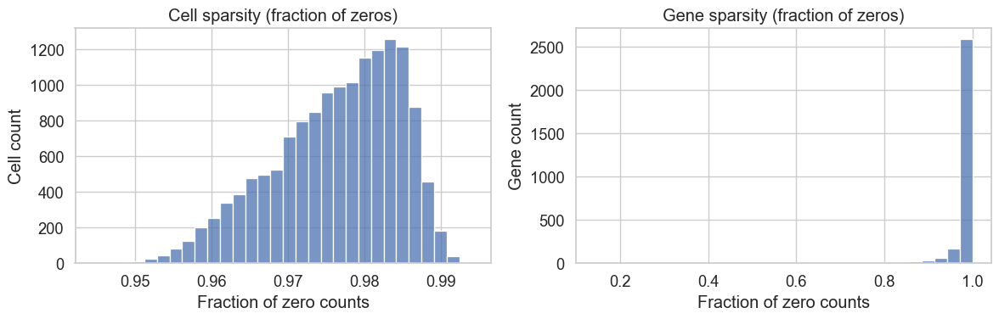

In [36]:
normalized_by_cell = normalized_df.set_index("Filename")

cell_sparsity = (normalized_by_cell == 0).mean(axis=1)
gene_sparsity = (normalized_by_cell == 0).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(cell_sparsity, bins=30, ax=axes[0])
axes[0].set_title("Cell sparsity (fraction of zeros)")
axes[0].set_xlabel("Fraction of zero counts")
axes[0].set_ylabel("Cell count")

sns.histplot(gene_sparsity, bins=30, ax=axes[1])
axes[1].set_title("Gene sparsity (fraction of zeros)")
axes[1].set_xlabel("Fraction of zero counts")
axes[1].set_ylabel("Gene count")

plt.tight_layout()

In [37]:
print(f"Sparsity: {(normalized_df == 0).mean().mean() * 100:.1f}%")

Sparsity: 97.6%


In [38]:
X_train = normalized_df.drop(columns=["Filename"])

I see that this database is very sparse, so dimensionality reduction will probably help a lot.

<a id="pca-2"></a>
#### *PCA*


This time I work directly with the **raw normalised data** rather than the log-transformed values. The DropSeq data is extremely sparse (98% zeros per cell), so here I want to see how dimensionality reduction behaves on the raw counts of this much sparser dataset. I therefore skip the raw-vs-log comparison done for SmartSeq and apply PCA directly to the raw data.

In [39]:
pca = PCA(n_components=0.95)
pca.fit_transform(X_train)
pca.n_components_, pca.explained_variance_ratio_.sum()


(np.int64(844), np.float64(0.9500448790527304))

Thus the best number of components is 844.

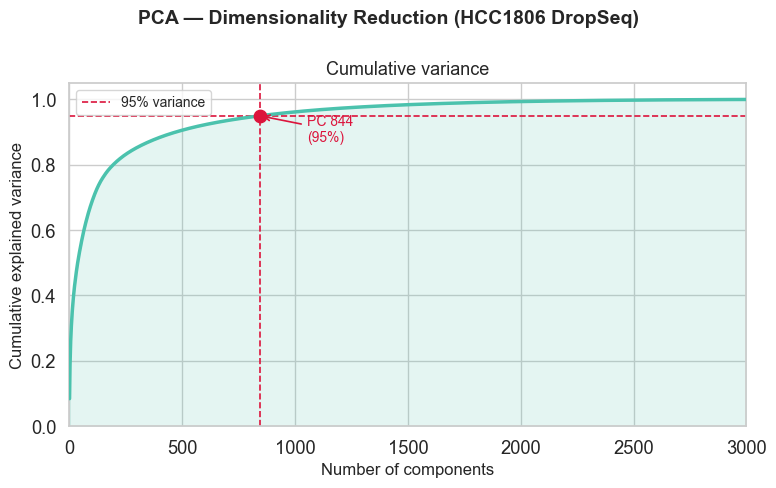

Components for 95% variance: 844


In [40]:
# ── style ────────────────────────────────────────────────────
palette = sns.color_palette("mako", 3)

# ── fit full PCA ─────────────────────────────────────────────
pca_full_drop = PCA()
pca_full_drop.fit(X_train)

cumsum  = np.cumsum(pca_full_drop.explained_variance_ratio_)
n_total = len(cumsum)
dims    = np.arange(1, n_total + 1)

# 95% cutoff
d = np.searchsorted(cumsum, 0.95) + 1

# ── plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("PCA — Dimensionality Reduction (HCC1806 DropSeq)",
             fontsize=14, fontweight="bold")

ax.plot(dims, cumsum, color=palette[2], linewidth=2.5, zorder=3)
ax.fill_between(dims, cumsum, alpha=0.15, color=palette[2])

# 95% threshold
ax.axhline(0.95, color="crimson", linestyle="--",
           linewidth=1.2, label="95% variance")
ax.axvline(d, color="crimson", linestyle="--", linewidth=1.2)
ax.scatter([d], [cumsum[d-1]], color="crimson", s=80, zorder=5)
ax.annotate(f"PC {d}\n(95%)",
            xy=(d, cumsum[d-1]),
            xytext=(d + n_total * 0.07, cumsum[d-1] - 0.08),
            fontsize=10, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))

ax.set_xlim(0, n_total)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Number of components", fontsize=12)
ax.set_ylabel("Cumulative explained variance", fontsize=12)
ax.set_title("Cumulative variance", fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Components for 95% variance: {d}")

Now let's check how PCA divides data in two dimensions

/var/folders/tb/ryhfr61d5wq7b6bbk5v71tww0000gn/T/ipykernel_68344/3224159455.py:15: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


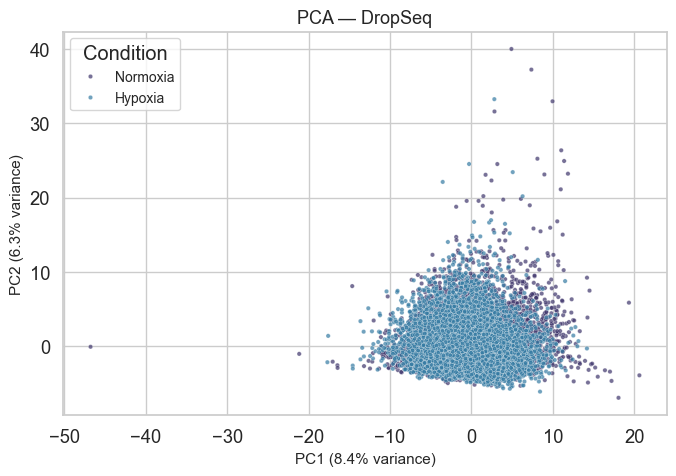

In [41]:
# ── prepare both versions ───────────────────────────────────
labels = normalized_df["Filename"].str.contains("Hypoxia").map({True: "Hypoxia", False: "Normoxia"})

# log1p transformed
pca = PCA(n_components=2)
coords = pca.fit_transform(X_train)

# ── build dataframes ────────────────────────────────────────
df = pd.DataFrame(coords, columns=["PC1", "PC2"])
df["Condition"] = labels.values

# ── plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=df, x="PC1", y="PC2",
    hue="Condition", palette=palette,
    alpha=0.7, s=10,   # smaller dots for 15000 cells
    ax=ax
)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

ax.set_xlabel(f"PC1 ({var1:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({var2:.1f}% variance)", fontsize=11)
ax.set_title("PCA — DropSeq", fontsize=13)
ax.legend(title="Condition", fontsize=10)

plt.tight_layout()
plt.show()

We see that PCA fails to separate the data in two dimensions.

In [42]:
var1 = pca.explained_variance_ratio_[0] * 100  # PC1 variance for DropSeq
var2 = pca.explained_variance_ratio_[1] * 100  # PC2 variance for DropSeq
print(f"PC1 explains {var1:.1f}% of variance")
print(f"PC2 explains {var2:.1f}% of variance")

PC1 explains 8.4% of variance
PC2 explains 6.3% of variance


Now I try to check whether the components are significant for us, as I did before.

In [43]:
pca = PCA(n_components=844)
pca.fit(X_train)

gene_sets = gp.get_library(name="MSigDB_Hallmark_2020")
hypoxia_genes = set(gene_sets["Hypoxia"])

In [44]:
# weighted average of loadings across ALL components (raw data)
# weight each PC by how much variance it explains
variance_weights = pca.explained_variance_ratio_  
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
# weighted sum of absolute loadings across all PCs
weighted_loadings = loadings.abs().mul(variance_weights, axis=1).sum(axis=1)
weighted_loadings = weighted_loadings.sort_values(ascending=False)

# top 50 most important genes overall
top_genes_weighted = set(weighted_loadings.head(50).index)

overlap = top_genes_weighted & hypoxia_genes
print(f"Weighted overlap: {len(overlap)} / {len(hypoxia_genes)}")
print(overlap)

Weighted overlap: 4 / 200
{'IGFBP3', 'HSPA5', 'ENO1', 'LDHA'}


In [45]:
# quick hypergeometric test (statistical significance)
from scipy.stats import hypergeom

M = len(X_train.columns)  # total genes (3000)
n = len(hypoxia_genes)  # hypoxia genes in dataset (up to 200)
N = 50                  # how many you picked (top 50 loadings)
k = len(overlap)        # observed overlap

# p-value: probability of getting >= 5 by chance
p_value = hypergeom.sf(k-1, M, n, N)
print(f"Expected by chance: {N * n / M:.2f}")
print(f"Observed: {k}")
print(f"p-value: {p_value:.4f}")

Expected by chance: 3.33
Observed: 4
p-value: 0.4300


I see that, of the 50 sampled genes, 4 are present in the HALLMARK database, which is not significantly better than random sampling. Thus I can conclude PCA is not a good tool for this database.

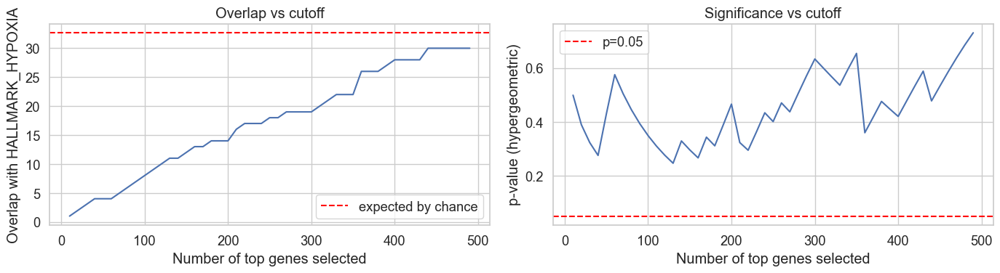

In [46]:
variance_weights = pca.explained_variance_ratio_

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

weighted_loadings = (loadings.abs()
                         .mul(variance_weights, axis=1)
                         .sum(axis=1)
                         .sort_values(ascending=False))

cutoffs  = range(10, 500, 10)
overlaps = []
p_values = []

for n_top in cutoffs:
    top = set(weighted_loadings.head(n_top).index) 
    ov  = top & hypoxia_genes
    p   = hypergeom.sf(len(ov)-1, M, n, n_top)
    overlaps.append(len(ov))
    p_values.append(p)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(x=list(cutoffs), y=overlaps, ax=axes[0])
axes[0].axhline(y=list(cutoffs)[-1] * len(hypoxia_genes) / M,
                color="red", linestyle="--", label="expected by chance")
axes[0].set_xlabel("Number of top genes selected")
axes[0].set_ylabel("Overlap with HALLMARK_HYPOXIA")
axes[0].set_title("Overlap vs cutoff")
axes[0].legend()

sns.lineplot(x=list(cutoffs), y=p_values, ax=axes[1])
axes[1].axhline(y=0.05, color="red", linestyle="--", label="p=0.05")
axes[1].set_xlabel("Number of top genes selected")
axes[1].set_ylabel("p-value (hypergeometric)")
axes[1].set_title("Significance vs cutoff")
axes[1].legend()

plt.tight_layout()
plt.show()

Now I try sparse PCA, cells are on average 98% sparse

**How Sparse PCA works.** Ordinary PCA produces *dense* components: every gene gets a non-zero loading, so each principal direction mixes all 3000 genes and is hard to interpret. **Sparse PCA** adds an L1 (lasso) penalty that forces most loadings to exactly zero, so each component is built from only a handful of genes — which is especially natural for very sparse count data like this.

Concretely, scikit-learn's `SparsePCA` solves a matrix-factorisation problem: it looks for sparse components $V$ and codes $U$ that reconstruct the (centered) data $X \in \mathbb{R}^{n \times p}$ while penalising the size of the loadings,

$$(U^{*},V^{*})=\underset{U,V}{\arg\min}\;\frac{1}{2}\,\lVert X-UV\rVert_{F}^{2}\;+\;\alpha\,\lVert V\rVert_{1},
\qquad \text{subject to } \lVert U_k\rVert_2 \le 1 ,$$

where:

- $\lVert\,\cdot\,\rVert_{F}$ is the Frobenius norm (the reconstruction error),
- $V$ are the **sparse components** (the gene loadings), $U$ are the scores returned by `transform`,
- $\lVert V\rVert_{1}=\sum_{i,j}\lvert V_{ij}\rvert$ is the L1 norm, which drives loadings to zero,
- $\alpha$ is the **sparsity parameter**: larger $\alpha$ → more zero loadings (fewer genes per component), $\alpha = 0$ recovers ordinary PCA.

The trade-off is that, unlike ordinary PCA, the sparse components are no longer guaranteed to be orthogonal and do not strictly maximise the explained variance; in exchange, each component depends on far fewer genes and is easier to interpret.

/var/folders/tb/ryhfr61d5wq7b6bbk5v71tww0000gn/T/ipykernel_68344/2679501307.py:17: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(data=df_sparse, x="PC1", y="PC2",


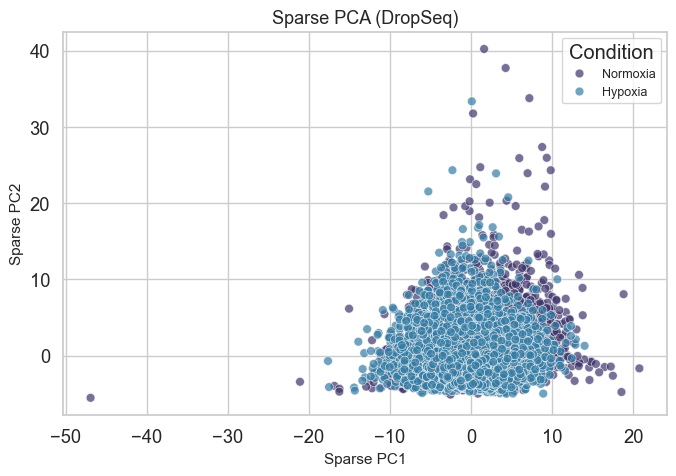

In [47]:
from sklearn.decomposition import SparsePCA

# ── Sparse PCA ───────────────────────────────────────────────
# warning: SparsePCA is slow — subsample if needed
sparse_pca = SparsePCA(n_components=2, 
                       alpha=1,        # sparsity control
                       random_state=42,
                       n_jobs=-1)      # use all cores

coords_sparse = sparse_pca.fit_transform(X_train)

# ── plot ─────────────────────────────────────────────────────
df_sparse = pd.DataFrame(coords_sparse, columns=["PC1", "PC2"])
df_sparse["Condition"] = labels.values

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_sparse, x="PC1", y="PC2",
                hue="Condition", palette=palette,
                alpha=0.7, s=40, ax=ax)
ax.set_title("Sparse PCA (DropSeq)", fontsize=13)
ax.set_xlabel("Sparse PC1", fontsize=11)
ax.set_ylabel("Sparse PC2", fontsize=11)
ax.legend(title="Condition", fontsize=9)

plt.tight_layout()
plt.show()

Sparse PCA still fails to separate data.

<a id="t-sne-2"></a>
#### *t-SNE*


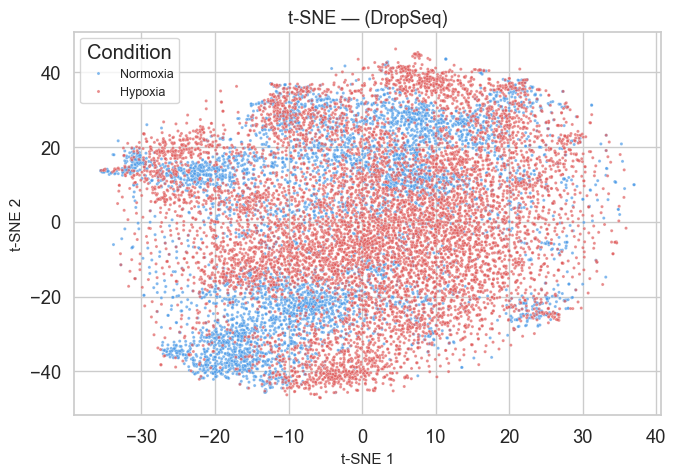

In [48]:
# ── t-SNE on DropSeq ───────────────────────────────────
pca_pre_drop = PCA(n_components=d, random_state=42)
X_pca_drop   = pca_pre_drop.fit_transform(X_train)
palette = {"Hypoxia": "#e05c5c", "Normoxia": "#4c9be8"}


tsne = TSNE(n_components=2, perplexity=30,
            method="barnes_hut",
            n_jobs=-1,
            random_state=42)

coords_drop = tsne.fit_transform(X_pca_drop)

df_drop = pd.DataFrame(coords_drop, columns=["tSNE1", "tSNE2"])
df_drop["Condition"] = labels.values

# ── plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=df_drop, x="tSNE1", y="tSNE2",
    hue="Condition", palette=palette,
    alpha=0.7, s=5,
    ax=ax
)
ax.set_title("t-SNE — (DropSeq)", fontsize=13)
ax.set_xlabel("t-SNE 1", fontsize=11)
ax.set_ylabel("t-SNE 2", fontsize=11)
ax.legend(title="Condition", fontsize=9)

plt.tight_layout()
plt.show()

So neither t-SNE is able to find a good separation. Let me try to change the perplexity parameter

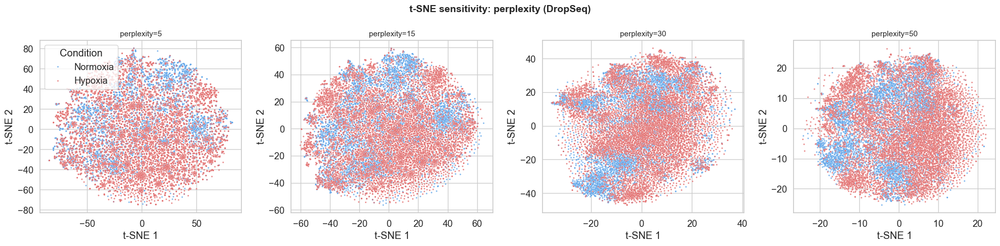

In [49]:
# ── t-SNE sensitivity: perplexity ────────────────────────────
perplexities = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("t-SNE sensitivity: perplexity (DropSeq)",
             fontsize=14, fontweight="bold")

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp,
                method="barnes_hut",
                n_jobs=-1,
                random_state=42)
    coords = tsne.fit_transform(X_pca_drop)
    df = pd.DataFrame(coords, columns=["tSNE1", "tSNE2"])
    df["Condition"] = labels.values

    sns.scatterplot(data=df, x="tSNE1", y="tSNE2",
                    hue="Condition", palette=palette,
                    alpha=0.7, s=5,
                    ax=ax,
                    legend=(perp == 5))
    ax.set_title(f"perplexity={perp}", fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

So, also with other perplexities, t-SNE fails with this dataset.

<a id="umap-2"></a>
#### *Umap*


/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


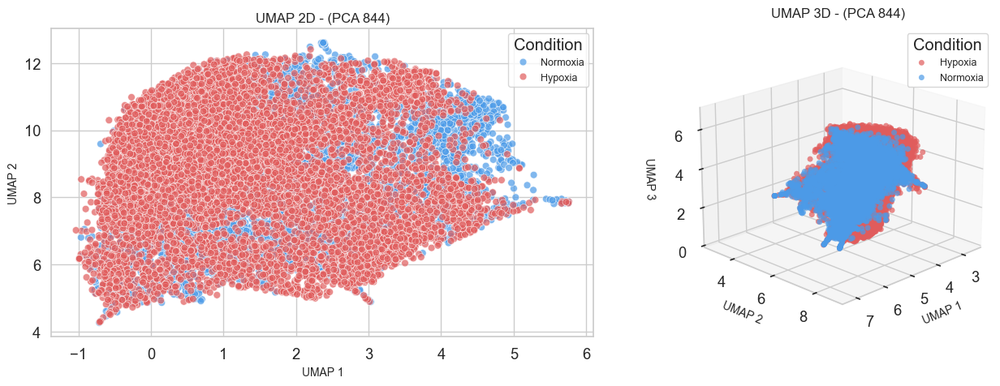

In [50]:
import umap
from mpl_toolkits.mplot3d import Axes3D

# ── PCA pre-reduction ────────────────────────────────────────
X_pca = PCA(n_components=d, random_state=42).fit_transform(X_train)

# ── UMAP 2D ─────────────────────────────────────────────────
coords = umap.UMAP(n_neighbors=15, min_dist=0.1,
                       n_components=2, random_state=42).fit_transform(X_pca)
df = pd.DataFrame(coords, columns=["UMAP1", "UMAP2"])
df["Condition"] = labels.values

# ── UMAP 3D ─────────────────────────────────────────────────
coords_3d = umap.UMAP(n_neighbors=15, min_dist=0.1,
                      n_components=3, random_state=42).fit_transform(X_pca)

# ── side-by-side plots ───────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
ax2d = fig.add_subplot(1, 2, 1)
ax3d = fig.add_subplot(1, 2, 2, projection="3d")

sns.scatterplot(data=df, x="UMAP1", y="UMAP2",
                hue="Condition", palette=palette,
                alpha=0.7, s=40, ax=ax2d)
ax2d.set_title("UMAP 2D - (PCA 844)", fontsize=12)
ax2d.set_xlabel("UMAP 1", fontsize=10)
ax2d.set_ylabel("UMAP 2", fontsize=10)
ax2d.legend(title="Condition", fontsize=9)

for condition, color in palette.items():
    mask = labels.values == condition
    ax3d.scatter(
        coords_3d[mask, 0],
        coords_3d[mask, 1],
        coords_3d[mask, 2],
        c=color, label=condition,
        alpha=0.7, s=25, edgecolors="none"
    )

ax3d.set_title("UMAP 3D - (PCA 844)", fontsize=12, pad=10)
ax3d.set_xlabel("UMAP 1", fontsize=10, labelpad=6)
ax3d.set_ylabel("UMAP 2", fontsize=10, labelpad=6)
ax3d.set_zlabel("UMAP 3", fontsize=10, labelpad=6)
ax3d.legend(title="Condition", fontsize=9)
ax3d.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

UMAP also fails to separate the data in two dimensions.

/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


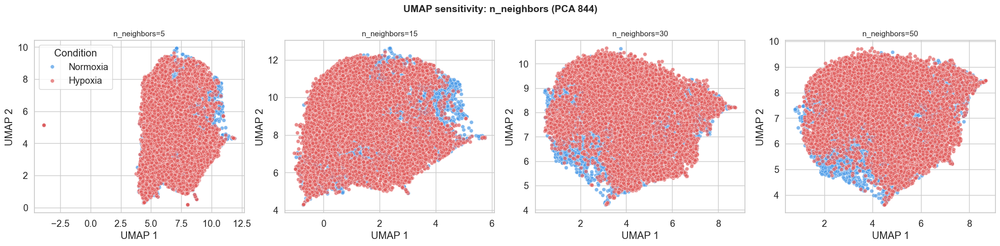

In [51]:
n_neighbors_list = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("UMAP sensitivity: n_neighbors (PCA 844)",
             fontsize=14, fontweight="bold")

for ax, n_neigh in zip(axes, n_neighbors_list):
    coords = umap.UMAP(n_neighbors=n_neigh, min_dist=0.1,
                       n_components=2, random_state=42).fit_transform(X_pca)
    df_s = pd.DataFrame(coords, columns=["UMAP1", "UMAP2"])
    df_s["Condition"] = labels.values
    sns.scatterplot(data=df_s, x="UMAP1", y="UMAP2",
                    hue="Condition", palette=palette,
                    alpha=0.7, s=30, ax=ax,
                    legend=(n_neigh == 5))
    ax.set_title(f"n_neighbors={n_neigh}", fontsize=11)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

I now continue doing what I did before: try to see whether Umap reveals clusters in genes.

/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


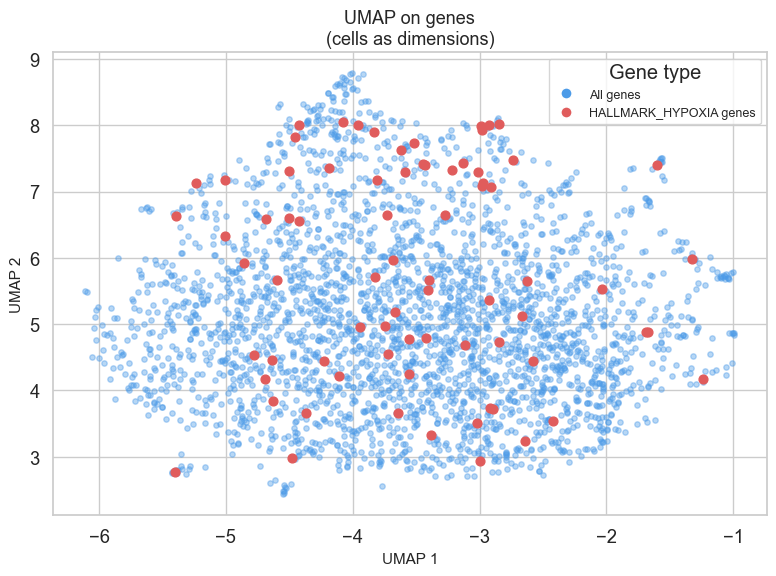

In [52]:
# ── transpose: genes as points, cells as dimensions ─────────
X_T = X_train.T  # shape: (3000 genes, n_cells)

# ── PCA pre-reduction on transposed data ────────────────────
# now n_components must be <= n_cells
X_pca_T = PCA(n_components=844, random_state=42).fit_transform(X_T)

# ── UMAP ────────────────────────────────────────────────────
coords_genes = umap.UMAP(n_neighbors=15, min_dist=0.1,
                         n_components=2, random_state=42).fit_transform(X_pca_T)

# ── plot ────────────────────────────────────────────────────
df_genes = pd.DataFrame(coords_genes, columns=["UMAP1", "UMAP2"])
df_genes["Gene"] = normalized_df.drop(columns=['Filename']).columns  # gene names as labels

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_genes["UMAP1"], df_genes["UMAP2"],
           alpha=0.4, s=15, color="#4c9be8")

# highlight hypoxia genes if they appear
for gene in df_genes["Gene"]:
    if gene in hypoxia_genes:
        row = df_genes[df_genes["Gene"] == gene]
        ax.scatter(row["UMAP1"], row["UMAP2"],
                   color="#e05c5c", s=40, zorder=5)

# add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4c9be8",
           markersize=8, label="All genes"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#e05c5c",
           markersize=8, label="HALLMARK_HYPOXIA genes")
]
ax.legend(handles=legend_elements, title="Gene type", fontsize=9)
ax.set_title("UMAP on genes\n(cells as dimensions)",
             fontsize=13)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)

plt.tight_layout()
plt.show()

Not informative

<a id="autoencoder-2"></a>
#### *Autoencoder*


Training bottleneck=8...
  train loss: 0.8929 | val loss: 1.0119
Training bottleneck=16...
  train loss: 0.8388 | val loss: 1.0110
Training bottleneck=32...
  train loss: 0.8171 | val loss: 1.0086
Training bottleneck=64...
  train loss: 0.8199 | val loss: 1.0071


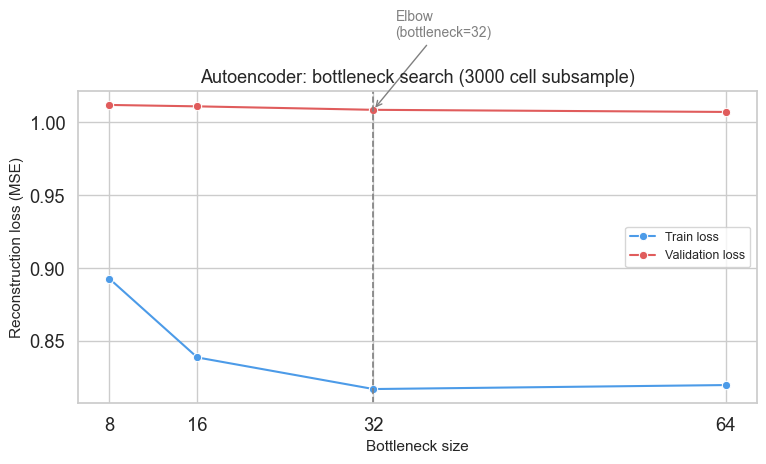


Retraining bottleneck=32 on full dataset...
Done!


In [53]:
# ── data prep ────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# subsample 3000 cells for bottleneck search
idx          = np.random.choice(len(X_train), 3000, replace=False)
X_sub        = X_scaled[idx]
X_tensor_sub = torch.FloatTensor(X_sub)

n_genes = X_scaled.shape[1]  # 3000

# train/val split on subsample
val_size   = int(0.1 * len(X_tensor_sub))
train_size = len(X_tensor_sub) - val_size
train_data, val_data = torch.utils.data.random_split(
    TensorDataset(X_tensor_sub), [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)

# ── autoencoder class ─────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 128),       nn.ReLU(),
            nn.Linear(128, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 128), nn.ReLU(),
            nn.Linear(128, 512),            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ── train function ────────────────────────────────────────────
def train_autoencoder(bottleneck, n_epochs=20):
    model     = Autoencoder(n_genes, bottleneck)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(n_epochs):
        for (batch,) in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        train_loss = sum(criterion(model(b[0]), b[0]).item()
                        for b in train_loader) / len(train_loader)
        val_loss   = sum(criterion(model(b[0]), b[0]).item()
                        for b in val_loader)   / len(val_loader)

    return train_loss, val_loss, model

# ── run for each bottleneck on subsample ─────────────────────
bottlenecks  = [8, 16, 32, 64]   # fewer values for speed
train_losses = []
val_losses   = []
models       = {}

for bottleneck in bottlenecks:
    print(f"Training bottleneck={bottleneck}...")
    tl, vl, model = train_autoencoder(bottleneck)
    train_losses.append(tl)
    val_losses.append(vl)
    models[bottleneck] = model
    print(f"  train loss: {tl:.4f} | val loss: {vl:.4f}")

# ── plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(x=bottlenecks, y=train_losses,
             marker="o", label="Train loss",
             ax=ax, color="#4c9be8")
sns.lineplot(x=bottlenecks, y=val_losses,
             marker="o", label="Validation loss",
             ax=ax, color="#e05c5c")

# elbow detection
second_deriv = np.diff(np.diff(val_losses))
elbow_idx    = np.argmax(second_deriv) + 1
elbow_val    = bottlenecks[elbow_idx]

ax.axvline(elbow_val, color="gray", linestyle="--", linewidth=1.2)
ax.annotate(f"Elbow\n(bottleneck={elbow_val})",
            xy=(elbow_val, val_losses[elbow_idx]),
            xytext=(elbow_val + 2, val_losses[elbow_idx] + 0.05),
            fontsize=10, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Bottleneck size", fontsize=11)
ax.set_ylabel("Reconstruction loss (MSE)", fontsize=11)
ax.set_title("Autoencoder: bottleneck search (3000 cell subsample)",
             fontsize=13)
ax.set_xticks(bottlenecks)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── retrain best model on FULL dataset ───────────────────────
print(f"\nRetraining bottleneck={elbow_val} on full dataset...")

X_tensor_full = torch.FloatTensor(X_scaled)
val_size_full   = int(0.1 * len(X_tensor_full))
train_size_full = len(X_tensor_full) - val_size_full
train_data_full, val_data_full = torch.utils.data.random_split(
    TensorDataset(X_tensor_full), [train_size_full, val_size_full],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_data_full, batch_size=64,  # larger batch for speed
                          shuffle=True)
val_loader   = DataLoader(val_data_full,   batch_size=64,
                          shuffle=False)

_, _, best_model = train_autoencoder(elbow_val, n_epochs=50)
print("Done!")

In [54]:
import umap

Bottleneck shape: (14682, 32)


/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


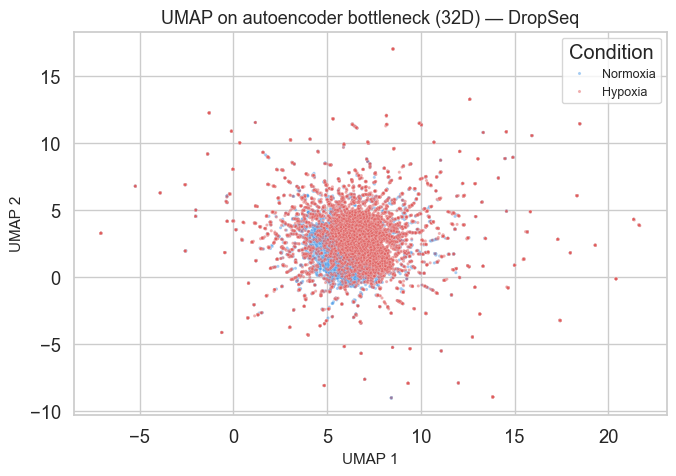

In [55]:
# ── get bottleneck representation from full dataset ───────────
best_model.eval()
with torch.no_grad():
    Z = best_model.encoder(X_tensor_full).numpy()

print(f"Bottleneck shape: {Z.shape}")

# ── UMAP on bottleneck ────────────────────────────────────────
coords_ae = umap.UMAP(n_neighbors=15, min_dist=0.1,
                      n_components=2, random_state=42).fit_transform(Z)

df_ae = pd.DataFrame(coords_ae, columns=["UMAP1", "UMAP2"])
df_ae["Condition"] = labels.values

# ── plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_ae, x="UMAP1", y="UMAP2",
                hue="Condition", palette=palette,
                alpha=0.5, s=5,   # small dots for 15000 cells
                ax=ax)
ax.set_title(f"UMAP on autoencoder bottleneck ({elbow_val}D) — DropSeq",
             fontsize=13)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.legend(title="Condition", fontsize=9)

plt.tight_layout()
plt.show()

The autoencoder, too, is unable to separate the data in two dimensions.

Epoch 10/50
Epoch 20/50
Epoch 30/50
Epoch 40/50
Epoch 50/50
Gene bottleneck shape: (3000, 32)


/Users/asca/myenv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


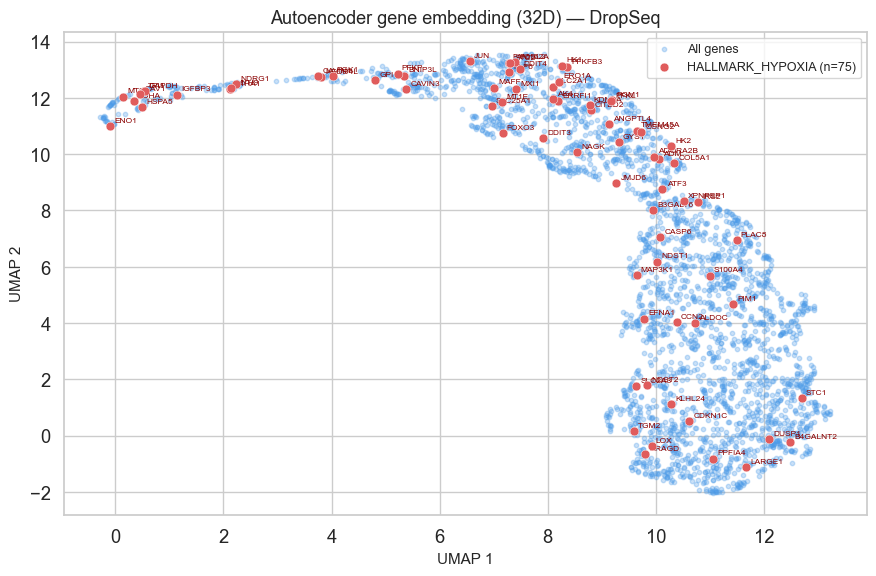

In [56]:
# ── transpose: genes as samples, cells as features ───────────
X_scaled_T = scaler.fit_transform(X_train.T)
X_tensor_T = torch.FloatTensor(X_scaled_T)

n_cells = X_scaled_T.shape[1]

# ── train autoencoder on genes (full dataset) ─────────────────
loader_T = DataLoader(TensorDataset(X_tensor_T),
                      batch_size=32, shuffle=True)

# reuse train/val split for genes
val_size_T   = int(0.1 * len(X_tensor_T))
train_size_T = len(X_tensor_T) - val_size_T
train_data_T, val_data_T = torch.utils.data.random_split(
    TensorDataset(X_tensor_T), [train_size_T, val_size_T],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_data_T, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data_T,   batch_size=32, shuffle=False)

model_genes = Autoencoder(n_cells, elbow_val)
optimizer   = torch.optim.Adam(model_genes.parameters(), lr=1e-3)
criterion   = nn.MSELoss()

model_genes.train()
for epoch in range(50):
    for (batch,) in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_genes(batch), batch)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50")

# ── get gene bottleneck ───────────────────────────────────────
model_genes.eval()
with torch.no_grad():
    Z_genes = model_genes.encoder(X_tensor_T).numpy()

print(f"Gene bottleneck shape: {Z_genes.shape}")

# ── UMAP on gene bottleneck ───────────────────────────────────
coords_genes_ae = umap.UMAP(n_neighbors=15, min_dist=0.1,
                             n_components=2, random_state=42).fit_transform(Z_genes)

gene_names   = np.array(X_train.columns)
hypoxia_mask = np.array([gene in hypoxia_genes for gene in gene_names])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(coords_genes_ae[~hypoxia_mask, 0],
           coords_genes_ae[~hypoxia_mask, 1],
           alpha=0.3, s=10, color="#4c9be8", label="All genes")
ax.scatter(coords_genes_ae[hypoxia_mask, 0],
           coords_genes_ae[hypoxia_mask, 1],
           color="#e05c5c", s=40, zorder=5,
           edgecolors="white", linewidths=0.3,
           label=f"HALLMARK_HYPOXIA (n={hypoxia_mask.sum()})")

for i, gene in enumerate(gene_names):
    if gene in hypoxia_genes:
        ax.annotate(gene,
                    xy=(coords_genes_ae[i, 0], coords_genes_ae[i, 1]),
                    fontsize=6, color="darkred",
                    xytext=(3, 3), textcoords="offset points")

ax.set_title(f"Autoencoder gene embedding ({elbow_val}D) — DropSeq",
             fontsize=13)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Not informative

<a id="conclusion-2"></a>
#### *Conclusion*


Following the same pipeline as for SmartSeq, but working directly with the raw normalised counts given the extreme sparsity of the DropSeq data, the dimensionality reduction analysis was repeated on the larger DropSeq dataset (over 14,000 cells, 3,000 genes). PCA revealed that the DropSeq data requires substantially more components than SmartSeq to capture 95% of variance, with PC1 explaining only 5.2% and PC2 2.6% — an even flatter variance distribution than SmartSeq (PC1 = 7.3%), consistent with the higher cell count and greater biological heterogeneity expected in a larger DropSeq dataset.

Cell-level visualisation via both t-SNE and UMAP showed poor Hypoxia/Normoxia separation, mirroring the SmartSeq results — with cells from both conditions forming largely overlapping clouds across all tested parameter configurations, confirming that the hypoxia transcriptional signal is too subtle and distributed to drive clear unsupervised separation in either technology.

The gene-level UMAP analysis on the transposed DropSeq matrix revealed a two-cluster gene structure qualitatively similar to SmartSeq, with HALLMARK_HYPOXIA genes (n=75) distributed across both clusters rather than concentrated in one — a notable difference from SmartSeq where hypoxia genes were more clearly enriched in the smaller distinct cluster, suggesting that the much larger cell count in DropSeq dilutes the gene co-expression signal and makes the hypoxia module less visually distinct.

The autoencoder analysis with a 32-dimensional bottleneck — selected via elbow detection on a 3,000-cell subsample for computational efficiency — produced a UMAP embedding that again showed poor cell-level separation, in stark contrast to the SmartSeq autoencoder result where a clear vertical separation between Hypoxia and Normoxia was visible. This represents the most significant difference between the two technologies: the SmartSeq autoencoder successfully captured a non-linear hypoxia representation that drove clear cell separation, while the DropSeq autoencoder failed to do so despite the much larger cell count. The greater per-cell depth of SmartSeq therefore preserves the subtle non-linear hypoxia signal better than the sparse DropSeq profiles, even when the latter has 50 times more cells.

Taken together, these results suggest that for the specific task of identifying hypoxia-responsive transcriptional programmes in HCC1806 cells, SmartSeq data with autoencoder dimensionality reduction provides a substantially more informative feature representation than DropSeq, and motivates the use of SmartSeq autoencoder embeddings as the primary input for downstream supervised classification.


<a id="clustering"></a>
## **CLUSTERING**

We divide this section into **cell clustering**, **gene clustering**, and VAE latent space clustering for the DropSeq datasets.

The purpose is exploratory: we want to check whether unsupervised structure aligns with oxygen condition, QC metrics, cell-cycle state, or gene-level expression programs. Cluster labels are treated as arbitrary identifiers until we compare them with metadata and biological summaries, so that we can figure out their interpretation.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

from IPython.display import display

from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.stats import zscore

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score, silhouette_score
from sklearn.mixture import GaussianMixture

try:
    import umap.umap_ as umap
except ImportError:
    try:
        import umap
    except ImportError:
        umap = None

try:
    import scanpy as sc
except ImportError:
    sc = None

try:
    import gseapy as gp
except ImportError:
    gp = None

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

workspace_dir = Path.cwd()
data_root_candidates = [
    workspace_dir,
    workspace_dir.parent / "University Projects" / "AI Lab",
    Path("/Users/arturozecchina/Desktop/PROGRAMMING/University Projects/AI Lab"),
]

data_root = next(
    candidate for candidate in data_root_candidates
    if (candidate / "SmartSeq").exists() and (candidate / "DropSeq").exists()
)

smartseq_dir = data_root / "SmartSeq"
dropseq_dir = data_root / "DropSeq"


/Users/arturozecchina/Desktop/PROGRAMMING/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Below are some useful helper functions we define to make the code easier.

In [2]:
def normalize_condition(value):
    value = str(value).lower()

    if "hyp" in value:
        return "Hypoxia"
    if "norm" in value:
        return "Normoxia"

    return np.nan


def load_expression_cells_by_genes(path):
    """Load a genes x cells or cells x genes text matrix as cells x genes."""
    expr = pd.read_csv(path, sep=r"\s+", index_col=0)

    expr.index = expr.index.astype(str).str.strip('"')
    expr.columns = expr.columns.astype(str).str.strip('"')
    expr = expr.apply(pd.to_numeric, errors="coerce").fillna(0)

    index_condition_hits = pd.Series(expr.index).str.lower().str.contains("hyp|norm").sum()
    column_condition_hits = pd.Series(expr.columns).str.lower().str.contains("hyp|norm").sum()

    if column_condition_hits > index_condition_hits:
        expr = expr.T

    expr.index.name = "Cell"
    expr.columns.name = "Gene"

    if expr.columns.duplicated().sum() > 0:
        expr = expr.T.groupby(level=0).sum().T

    return expr


def load_smartseq_conditions(cells, metadata_path):
    metadata = pd.read_csv(metadata_path, sep="\t")
    metadata["Filename"] = metadata["Filename"].astype(str).str.strip('"')
    metadata = metadata.drop_duplicates("Filename").set_index("Filename")

    conditions = metadata.reindex(cells)["Condition"].map(normalize_condition)
    conditions.name = "Condition"

    return conditions


def infer_conditions_from_cells(cells):
    return pd.Series(
        [normalize_condition(cell) for cell in cells],
        index=cells,
        name="Condition",
    )


def load_dataset(dataset_name):
    paths = {
        "HCC1806 SmartSeq": (
            smartseq_dir / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt",
            smartseq_dir / "HCC1806_SmartS_MetaData.tsv",
            "SmartSeq",
        ),
        "MCF7 SmartSeq": (
            smartseq_dir / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt",
            smartseq_dir / "MCF7_SmartS_MetaData.tsv",
            "SmartSeq",
        ),
        "HCC1806 DropSeq": (
            dropseq_dir / "HCC1806_Filtered_Normalised_3000_Data_train.txt",
            None,
            "DropSeq",
        ),
        "MCF7 DropSeq": (
            dropseq_dir / "MCF7_Filtered_Normalised_3000_Data_train.txt",
            None,
            "DropSeq",
        ),
    }

    expression_path, metadata_path, technology = paths[dataset_name]
    expr = load_expression_cells_by_genes(expression_path)

    if metadata_path is not None:
        conditions = load_smartseq_conditions(expr.index, metadata_path)
    else:
        conditions = infer_conditions_from_cells(expr.index)

    valid_cells = conditions.isin(["Hypoxia", "Normoxia"])
    expr = expr.loc[valid_cells].copy()
    conditions = conditions.loc[valid_cells].copy()

    return expr, conditions, technology


def transform_for_clustering(expr, technology):
    if technology == "SmartSeq":
        return np.log1p(expr)
    return expr.copy()


def prepare_cell_pca(dataset_name, variance=0.75):
    expr, conditions, technology = load_dataset(dataset_name)
    X = transform_for_clustering(expr, technology)

    pca_model = PCA(n_components=variance, random_state=RANDOM_STATE)
    pca_values = pca_model.fit_transform(X)

    pca_df = pd.DataFrame(
        pca_values,
        index=X.index,
        columns=[f"PC{i+1}" for i in range(pca_values.shape[1])],
    )

    return {
        "dataset": dataset_name,
        "expr": expr,
        "X": X,
        "conditions": conditions,
        "technology": technology,
        "pca_model": pca_model,
        "pca": pca_df,
    }


def cell_qc_table(expr):
    total_expression = expr.sum(axis=1)
    detected_genes = (expr > 0).sum(axis=1)
    zero_fraction = (expr == 0).mean(axis=1)
    mito_genes = [gene for gene in expr.columns if str(gene).upper().startswith("MT-")]

    qc = pd.DataFrame({
        "total_expression": total_expression,
        "detected_genes": detected_genes,
        "zero_fraction": zero_fraction,
    }, index=expr.index)

    if len(mito_genes) > 0:
        qc["mito_fraction"] = expr[mito_genes].sum(axis=1) / total_expression.replace(0, np.nan)
    else:
        qc["mito_fraction"] = np.nan

    return qc


s_genes = [
    "MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1", "UNG", "GINS2",
    "MCM6", "CDCA7", "DTL", "PRIM1", "UHRF1", "HELLS", "RFC2", "RPA2",
    "NASP", "RAD51AP1", "GMNN", "WDR76", "SLBP", "CCNE2", "UBR7", "POLD3",
    "MSH2", "ATAD2", "RAD51", "RRM2", "CDC45", "CDC6", "EXO1", "TIPIN",
    "DSCC1", "BLM", "CASP8AP2", "USP1", "CLSPN", "POLA1", "CHAF1B",
    "BRIP1", "E2F8",
]

g2m_genes = [
    "HMGB2", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2", "TOP2A", "NDC80",
    "CKS2", "NUF2", "CKS1B", "MKI67", "TMPO", "CENPF", "TACC3", "FAM64A",
    "SMC4", "CCNB2", "CKAP2L", "CKAP2", "AURKB", "BUB1", "KIF11", "ANP32E",
    "TUBB4B", "GTSE1", "KIF20B", "HJURP", "CDCA3", "HN1", "CDC20", "TTK",
    "CDC25C", "KIF2C", "RANGAP1", "NCAPD2", "DLGAP5", "CDCA2", "CDCA8",
    "ECT2", "KIF23", "HMMR", "AURKA", "PSRC1", "ANLN", "LBR", "CKAP5",
    "CENPE", "CTCF", "NEK2", "G2E3", "GAS2L3", "CBX5", "CENPA",
]


def score_cell_cycle(expr, technology):
    X_cycle = transform_for_clustering(expr, technology)
    X_cycle.columns = X_cycle.columns.astype(str).str.upper()
    X_cycle = X_cycle.T.groupby(level=0).mean().T

    s_present = [gene for gene in s_genes if gene in X_cycle.columns]
    g2m_present = [gene for gene in g2m_genes if gene in X_cycle.columns]

    if len(s_present) == 0 or len(g2m_present) == 0:
        return pd.DataFrame({
            "S_score": np.nan,
            "G2M_score": np.nan,
            "predicted_phase": "Unknown",
        }, index=X_cycle.index)

    if sc is not None:
        adata = sc.AnnData(X_cycle)
        sc.tl.score_genes_cell_cycle(adata, s_genes=s_present, g2m_genes=g2m_present)
        return adata.obs[["S_score", "G2M_score", "phase"]].rename(
            columns={"phase": "predicted_phase"}
        )

    X_cycle_z = pd.DataFrame(
        zscore(X_cycle, axis=0, nan_policy="omit"),
        index=X_cycle.index,
        columns=X_cycle.columns,
    ).fillna(0)

    cycle_scores = pd.DataFrame(index=X_cycle.index)
    cycle_scores["S_score"] = X_cycle_z[s_present].mean(axis=1)
    cycle_scores["G2M_score"] = X_cycle_z[g2m_present].mean(axis=1)
    cycle_scores["predicted_phase"] = np.where(
        (cycle_scores["S_score"] > cycle_scores["G2M_score"]) & (cycle_scores["S_score"] > 0),
        "S",
        np.where(
            (cycle_scores["G2M_score"] > cycle_scores["S_score"]) & (cycle_scores["G2M_score"] > 0),
            "G2M",
            "G1",
        ),
    )

    return cycle_scores


def dendrogram_threshold(linkage_matrix, n_clusters):
    if n_clusters <= 1:
        return linkage_matrix[-1, 2] + 1

    lower = linkage_matrix[-n_clusters, 2]
    upper = linkage_matrix[-(n_clusters - 1), 2]
    return (lower + upper) / 2


def summarize_cell_clusters(labels, conditions, expr, cycle_scores):
    labels = pd.Series(labels, index=conditions.index, name="cluster")
    qc = cell_qc_table(expr)

    summary = (
        pd.concat([labels, conditions, qc, cycle_scores], axis=1)
        .groupby("cluster")
        .agg(
            n_cells=("cluster", "size"),
            hypoxia_fraction=("Condition", lambda x: (x == "Hypoxia").mean()),
            mean_total_expression=("total_expression", "mean"),
            median_total_expression=("total_expression", "median"),
            mean_detected_genes=("detected_genes", "mean"),
            median_detected_genes=("detected_genes", "median"),
            mean_zero_fraction=("zero_fraction", "mean"),
            mean_mito_fraction=("mito_fraction", "mean"),
            mean_S_score=("S_score", "mean"),
            mean_G2M_score=("G2M_score", "mean"),
        )
    )

    return summary


<a id="cell-clustering"></a>
### **Cell Clustering**

<a id="hierarchical-clustering"></a>
#### *Hierarchical Clustering*

First, we cluster cells using agglomerative hierarchical clustering. At each step, Ward linkage merges the two clusters that create the smallest increase in within-cluster squared error.

For two clusters $A$ and $B$, the Ward merge cost can be written as:

$$
\Delta(A,B)
=
\frac{|A||B|}{|A|+|B|}
\left\|\bar{x}_A-\bar{x}_B\right\|_2^2,
$$

where $|A|$ and $|B|$ are cluster sizes, and $\bar{x}_A$ and $\bar{x}_B$ are their centroids. This makes Ward clustering close in spirit to K-Means, because it prefers compact clusters in Euclidean space.

We exploratively start verifying if it directly separates hypoxia cell lines with k=2. Then we move to the clustering structure that emerges from the dendrogram. We first show results for the HCC1806_SmartSeq dataset, on which PCA (keeping 75% of explained variance) is applied to reduce the dimensionality of the dataset.


,dataset,n_cells,n_genes,n_pca75_components,explained_variance
0,HCC1806 SmartSeq,182,3000,93,0.752


Condition,Hypoxia,Normoxia
hierarchical_cluster_k2,,
1,12,5
2,85,80


Condition,Hypoxia,Normoxia
hierarchical_cluster_k2,,
1,0.706,0.294
2,0.515,0.485


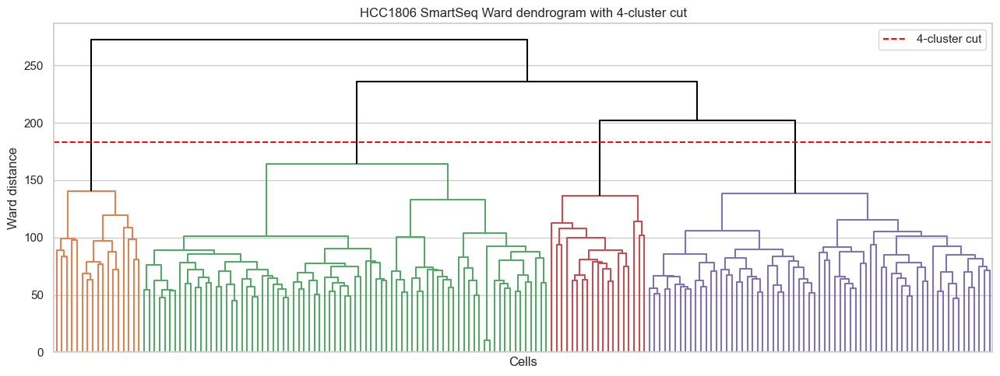

Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,12,5
2,6,73
3,15,4
4,64,3


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,0.706,0.294
2,0.076,0.924
3,0.789,0.211
4,0.955,0.045


,n_cells,hypoxia_fraction,mean_total_expression,median_total_expression,mean_detected_genes,median_detected_genes,mean_zero_fraction,mean_mito_fraction,mean_S_score,mean_G2M_score
cluster,,,,,,,,,,
1,17,0.706,577130.235,579358.0,909.176,914.0,0.697,0.068,0.518,-1.974
2,79,0.076,453045.759,444819.0,875.772,881.0,0.708,0.067,1.027,0.324
3,19,0.789,557978.474,554505.0,795.684,789.0,0.735,0.052,-1.047,-2.947
4,67,0.955,526361.970,527487.0,902.567,897.0,0.699,0.046,0.339,-0.267


In [3]:
hcc_cell_space = prepare_cell_pca("HCC1806 SmartSeq", variance=0.75)
hcc_expr = hcc_cell_space["expr"]
hcc_log1p = hcc_cell_space["X"]
hcc_conditions = hcc_cell_space["conditions"]
hcc_cell_pca75 = hcc_cell_space["pca"]
cell_pca75 = hcc_cell_space["pca_model"]

hcc_linkage = linkage(hcc_cell_pca75, method="ward", metric="euclidean")

hcc_hierarchical_k2 = pd.Series(
    fcluster(hcc_linkage, t=2, criterion="maxclust"),
    index=hcc_cell_pca75.index,
    name="hierarchical_cluster_k2",
)

hcc_hierarchical_k4 = pd.Series(
    fcluster(hcc_linkage, t=4, criterion="maxclust"),
    index=hcc_cell_pca75.index,
    name="hierarchical_cluster_k4",
)

hcc_cell_cycle = score_cell_cycle(hcc_expr, hcc_cell_space["technology"])

hcc_hierarchical_input_summary = pd.DataFrame({
    "dataset": ["HCC1806 SmartSeq"],
    "n_cells": [hcc_expr.shape[0]],
    "n_genes": [hcc_expr.shape[1]],
    "n_pca75_components": [hcc_cell_pca75.shape[1]],
    "explained_variance": [cell_pca75.explained_variance_ratio_.sum()],
})

display(hcc_hierarchical_input_summary.round(3))

hcc_hierarchical_k2_counts = pd.crosstab(hcc_hierarchical_k2, hcc_conditions)
hcc_hierarchical_k2_props = pd.crosstab(hcc_hierarchical_k2, hcc_conditions, normalize="index")

display(hcc_hierarchical_k2_counts)
display(hcc_hierarchical_k2_props.round(3))

hcc_k4_threshold = dendrogram_threshold(hcc_linkage, 4)

plt.figure(figsize=(13, 5))
dendrogram(
    hcc_linkage,
    no_labels=True,
    color_threshold=hcc_k4_threshold,
    above_threshold_color="black",
)
plt.axhline(hcc_k4_threshold, color="red", linestyle="--", linewidth=1.4, label="4-cluster cut")
plt.title("HCC1806 SmartSeq Ward dendrogram with 4-cluster cut")
plt.xlabel("Cells")
plt.ylabel("Ward distance")
plt.legend()
plt.tight_layout()
plt.show()

hcc_hierarchical_k4_counts = pd.crosstab(hcc_hierarchical_k4, hcc_conditions)
hcc_hierarchical_k4_props = pd.crosstab(hcc_hierarchical_k4, hcc_conditions, normalize="index")
hcc_hierarchical_k4_summary = summarize_cell_clusters(
    hcc_hierarchical_k4,
    hcc_conditions,
    hcc_expr,
    hcc_cell_cycle,
)

display(hcc_hierarchical_k4_counts)
display(hcc_hierarchical_k4_props.round(3))
display(hcc_hierarchical_k4_summary.round(3))


The first 2-cluster Ward solution is only a weak condition split: one cluster is 70.6% hypoxia, while the larger cluster is almost mixed between hypoxia and normoxia. This suggests that a single binary Ward split is not enough to describe the HCC1806 SmartSeq structure, and that it picks up signal from other properties of the cells.

From the dendrogram, it clearly appears that the 4-cluster solution should be more informative. Cluster 2 is mostly normoxic (92.4% normoxia), while cluster 4 is strongly hypoxic (95.5% hypoxia), and they contain the majority of the cell lines. The other two clusters are a minority that's hypoxia-enriched.

From the QC analysis, wee se that it might be separating normoxia from the rest just by mean expression, which is much lower compared to the other clusters. The interesting separation is the one between the "outlier" clusters 1 and 3. From the cell cycle analysis, it appears that cluster n1 is characterized by a low G2M score and an average S score (see graphs later) meaning it mostly contains cells in the G2M phase, i.e. cells going through / preparing for mitosis. Cluster n3, on the other hand, appears to have a very low score on both metrics, meaning it contains mostly cells in the G1-like phase, i.e. cells growing and preparing for DNA replication. These appear to be the stronger biological signals that separate the data.

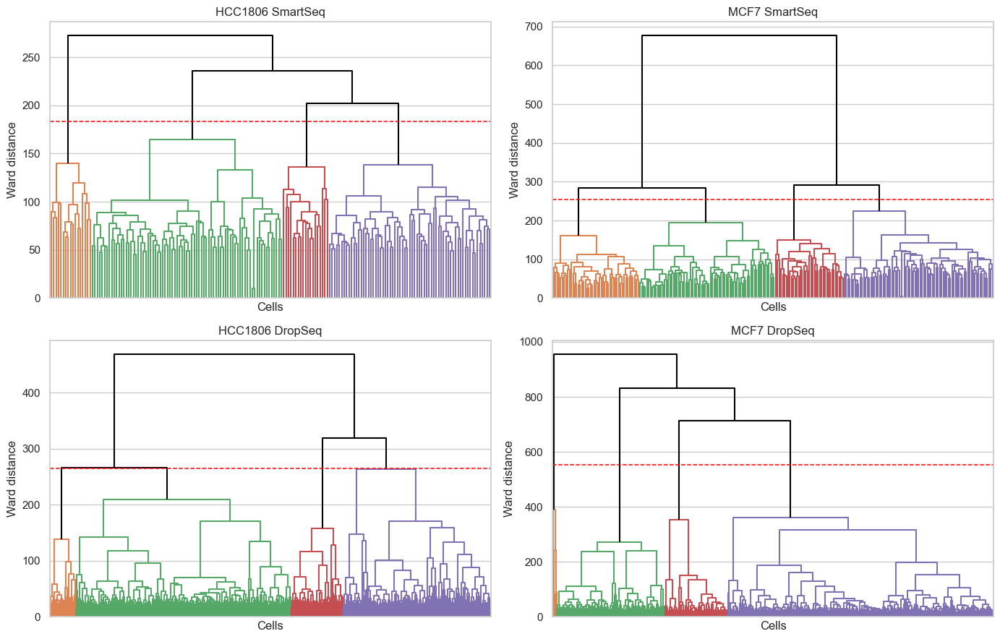

,dataset,cluster,n_cells,hypoxia_fraction,mean_total_expression,median_total_expression,mean_detected_genes,median_detected_genes,mean_zero_fraction,mean_mito_fraction,mean_S_score,mean_G2M_score
0,HCC1806 SmartSeq,1,17,0.706,577130.235,579358.0,909.176,914.0,0.697,0.068,0.518,-1.974
1,HCC1806 SmartSeq,2,79,0.076,453045.759,444819.0,875.772,881.0,0.708,0.067,1.027,0.324
2,HCC1806 SmartSeq,3,19,0.789,557978.474,554505.0,795.684,789.0,0.735,0.052,-1.047,-2.947
3,HCC1806 SmartSeq,4,67,0.955,526361.970,527487.0,902.567,897.0,0.699,0.046,0.339,-0.267
4,MCF7 SmartSeq,1,49,0.000,275569.980,274839.0,1113.694,1096.0,0.629,0.119,1.187,0.341
5,MCF7 SmartSeq,2,77,0.000,280270.623,276320.0,1219.195,1212.0,0.594,0.111,1.175,-0.035
6,MCF7 SmartSeq,3,39,1.000,449762.923,450147.0,880.513,897.0,0.706,0.017,-0.993,-1.778
7,MCF7 SmartSeq,4,85,1.000,403535.482,398547.0,1059.353,1088.0,0.647,0.035,-0.701,-1.086
8,HCC1806 DropSeq,1,878,0.522,141.273,142.0,90.350,91.0,0.970,0.018,-0.139,-0.070
9,HCC1806 DropSeq,2,7170,0.677,104.624,100.0,67.884,63.0,0.977,0.024,-0.104,0.024


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,12,5
2,6,73
3,15,4
4,64,3


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,0.706,0.294
2,0.076,0.924
3,0.789,0.211
4,0.955,0.045


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,0,49
2,0,77
3,39,0
4,85,0


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,0.0,1.0
2,0.0,1.0
3,1.0,0.0
4,1.0,0.0


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,458,420
2,4852,2318
3,890,843
4,2699,2202


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,0.522,0.478
2,0.677,0.323
3,0.514,0.486
4,0.551,0.449


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,82,113
2,5087,238
3,478,2595
4,3274,9759


Condition,Hypoxia,Normoxia
hierarchical_cluster_k4,,
1,0.421,0.579
2,0.955,0.045
3,0.156,0.844
4,0.251,0.749


In [4]:
hierarchical_dataset_names = [
    "HCC1806 SmartSeq",
    "MCF7 SmartSeq",
    "HCC1806 DropSeq",
    "MCF7 DropSeq",
]

hierarchical_spaces = {"HCC1806 SmartSeq": hcc_cell_space}
hierarchical_results = {}
hierarchical_summary_rows = []

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, dataset_name in zip(axes, hierarchical_dataset_names):
    if dataset_name in hierarchical_spaces:
        space = hierarchical_spaces[dataset_name]
    else:
        space = prepare_cell_pca(dataset_name, variance=0.75)
        hierarchical_spaces[dataset_name] = space

    link = linkage(space["pca"], method="ward", metric="euclidean")
    labels_k4 = pd.Series(
        fcluster(link, t=4, criterion="maxclust"),
        index=space["pca"].index,
        name="hierarchical_cluster_k4",
    )
    cycle_scores = score_cell_cycle(space["expr"], space["technology"])
    summary = summarize_cell_clusters(labels_k4, space["conditions"], space["expr"], cycle_scores)
    counts = pd.crosstab(labels_k4, space["conditions"])
    props = pd.crosstab(labels_k4, space["conditions"], normalize="index")

    hierarchical_results[dataset_name] = {
        "space": space,
        "linkage": link,
        "labels_k4": labels_k4,
        "cycle_scores": cycle_scores,
        "counts": counts,
        "proportions": props,
        "summary": summary,
    }

    summary_for_display = summary.copy()
    summary_for_display.insert(0, "dataset", dataset_name)
    summary_for_display.insert(1, "cluster", summary_for_display.index)
    hierarchical_summary_rows.append(summary_for_display.reset_index(drop=True))

    threshold = dendrogram_threshold(link, 4)
    dendrogram(
        link,
        no_labels=True,
        color_threshold=threshold,
        above_threshold_color="black",
        ax=ax,
    )
    ax.axhline(threshold, color="red", linestyle="--", linewidth=1.1)
    ax.set_title(dataset_name)
    ax.set_xlabel("Cells")
    ax.set_ylabel("Ward distance")

plt.tight_layout()
plt.show()

hierarchical_all_dataset_summary = pd.concat(hierarchical_summary_rows, ignore_index=True)

display(hierarchical_all_dataset_summary.round(3))

for dataset_name in hierarchical_dataset_names:
    display(hierarchical_results[dataset_name]["counts"])
    display(hierarchical_results[dataset_name]["proportions"].round(3))


Ward clustering behaves differently across datasets. It works great (even perfectly for MCF7) for SmartSeq datasets, but fails to cluster DropSeq datasets. We note that this is probably due to the dimensionality reduction method: being DropSeq dataset so sparse, it is much harder to handle; we'll use specific techniques (see later) to deal with this.

<a id="gaussian-mixture-models"></a>
#### *Gaussian Mixture Models*

A Gaussian mixture model represents the distribution of cells as a weighted sum of Gaussian components:

$$
p(x_i)
=
\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x_i\mid\mu_k,\Sigma_k),
\qquad
\sum_{k=1}^{K}\pi_k = 1.
$$

Here $K$ is the number of mixture components, $\pi_k$ is the weight of component $k$, $\mu_k$ is its mean, and $\Sigma_k$ is its covariance matrix. With **full covariance**, each component can have its own elliptical shape and orientation.

For a fitted model $M_K$, the maximized log-likelihood is:

$$
\ell(\hat{\theta}_K)
=
\sum_{i=1}^{n}\log p(x_i\mid \hat{\theta}_K, M_K).
$$

If we only maximized this quantity, larger $K$ would almost always look better because the model has more parameters. AIC and BIC keep the likelihood term, but add different penalties for the number of fitted parameters $p$.

AIC estimates expected out-of-sample prediction error. BIC approximates Bayesian model evidence. Lower AIC/BIC values are preferred. AIC is usually more permissive and prediction-oriented; BIC is usually more conservative because the complexity penalty grows with the number of cells. Therefore we use BIC as a metric to obtain more meaningful clusters (biologically speaking), whereas AIC is used later for feature engeneering.

Below we run the GMM analysis on both SmartSeq datasets. The labels are fitted in PCA space; UMAP and 3D UMAP are visualizations of those high-dimensional labels.


/Users/arturozecchina/Desktop/PROGRAMMING/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/arturozecchina/Desktop/PROGRAMMING/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/arturozecchina/Desktop/PROGRAMMING/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/arturozecchina/Desktop/PROGRAMMING/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,dataset,k,bic,aic
0,HCC1806 SmartSeq,2,107196.864,78588.289
1,HCC1806 SmartSeq,3,81736.262,38821.797
2,HCC1806 SmartSeq,4,66110.306,8889.951
3,HCC1806 SmartSeq,5,49574.536,-21951.709
4,HCC1806 SmartSeq,6,56685.967,-29146.168
5,HCC1806 SmartSeq,7,64167.087,-35970.938
6,HCC1806 SmartSeq,8,83957.118,-30486.797
7,HCC1806 SmartSeq,9,85963.597,-42786.208
8,HCC1806 SmartSeq,10,105414.709,-37640.986
9,HCC1806 SmartSeq,11,125168.727,-32192.857


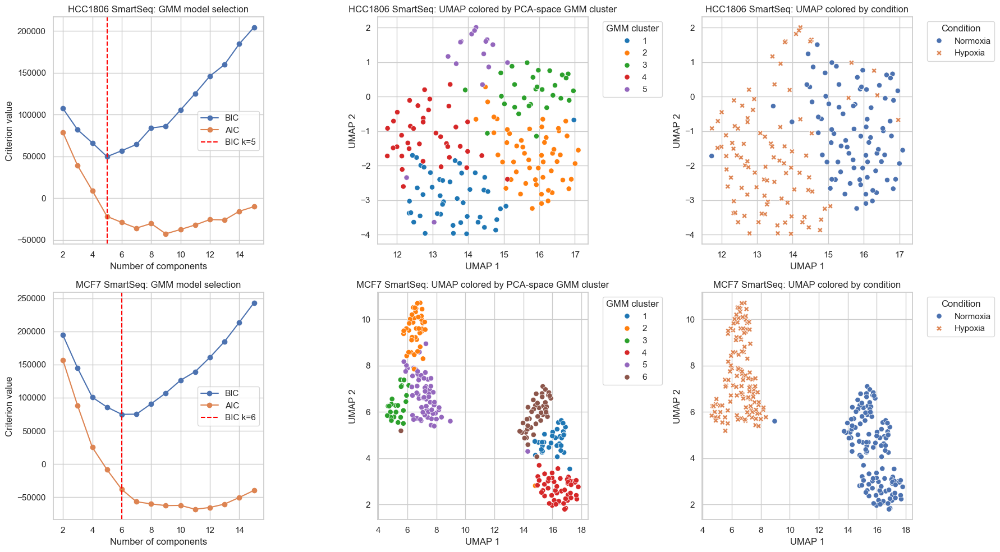

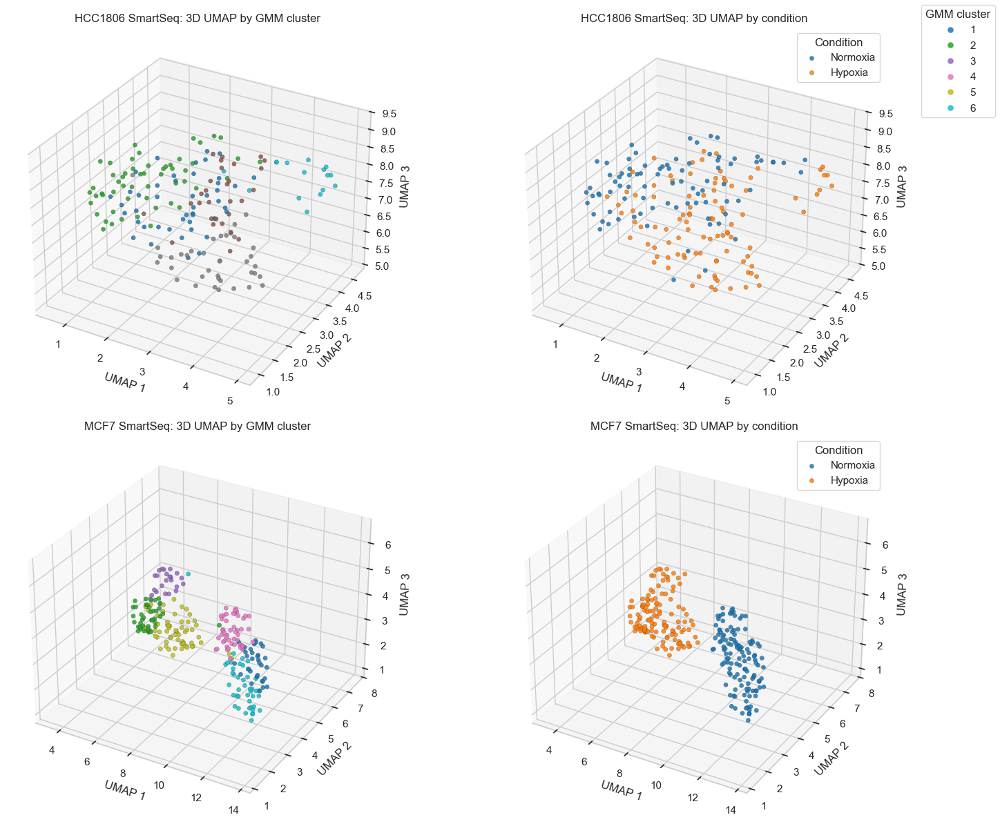

,dataset,cluster,n_cells,hypoxia_fraction,mean_cluster_probability,mean_total_expression,mean_detected_genes,mean_zero_fraction,mean_mito_fraction,mean_S_score,mean_G2M_score
0,HCC1806 SmartSeq,1,45,1.000,1.0,530191.222,929.933,0.690,0.046,0.439,0.141
1,HCC1806 SmartSeq,2,54,0.019,1.0,452296.019,928.019,0.691,0.057,0.953,0.353
2,HCC1806 SmartSeq,3,29,0.207,1.0,460374.759,756.793,0.748,0.089,0.963,0.161
3,HCC1806 SmartSeq,4,38,0.895,1.0,539990.211,821.026,0.726,0.049,-0.327,-2.080
4,HCC1806 SmartSeq,5,16,0.688,1.0,582286.625,945.375,0.685,0.060,0.377,-2.052
5,MCF7 SmartSeq,1,33,0.000,1.0,282156.182,1157.697,0.614,0.104,1.451,-0.027
6,MCF7 SmartSeq,2,40,0.975,1.0,446342.400,884.725,0.705,0.016,-1.001,-1.806
7,MCF7 SmartSeq,3,24,1.000,1.0,412343.958,1076.833,0.641,0.035,0.027,1.259
8,MCF7 SmartSeq,4,48,0.000,1.0,274630.979,1116.042,0.628,0.120,1.195,0.345
9,MCF7 SmartSeq,5,62,0.968,1.0,398692.081,1052.855,0.649,0.039,-1.033,-2.033


,dataset,cluster,n_cells,mean_S_score,median_S_score,mean_G2M_score,median_G2M_score
0,HCC1806 SmartSeq,1,45,0.439,0.744,0.141,0.173
1,HCC1806 SmartSeq,2,54,0.953,1.111,0.353,0.374
2,HCC1806 SmartSeq,3,29,0.963,1.224,0.161,0.424
3,HCC1806 SmartSeq,4,38,-0.327,-0.468,-2.080,-2.199
4,HCC1806 SmartSeq,5,16,0.377,1.080,-2.052,-2.361
5,MCF7 SmartSeq,1,33,1.451,1.516,-0.027,0.195
6,MCF7 SmartSeq,2,40,-1.001,-1.046,-1.806,-1.950
7,MCF7 SmartSeq,3,24,0.027,-0.118,1.259,1.066
8,MCF7 SmartSeq,4,48,1.195,1.124,0.345,0.428
9,MCF7 SmartSeq,5,62,-1.033,-1.063,-2.033,-2.076


,dataset,gmm_cluster,n_top_genes_tested,term_rank,Gene_set,Term,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,HCC1806 SmartSeq,1,200,1,MSigDB_Hallmark_2020,Hypoxia,1.222875e-37,29.548281,2623.256027,ERRFI1;KDM3A;PFKFB3;SERPINE1;PDGFB;SLC2A1;STC1...
1,HCC1806 SmartSeq,1,200,2,MSigDB_Hallmark_2020,G2-M Checkpoint,1.627729e-21,17.706205,902.275323,TOP2A;NUMA1;CCNF;TTK;KIF11;MKI67;AURKB;AURKA;C...
2,HCC1806 SmartSeq,1,200,3,MSigDB_Hallmark_2020,E2F Targets,7.635824e-17,14.406109,573.315224,TOP2A;TCF19;RRM2;CDCA3;LIG1;SPAG5;HMGB2;CDCA8;...
3,HCC1806 SmartSeq,2,200,1,MSigDB_Hallmark_2020,G2-M Checkpoint,3.574593e-36,28.434842,2428.432250,TOP2A;NUMA1;CCNF;TTK;KIF11;MKI67;CENPA;AURKB;A...
4,HCC1806 SmartSeq,2,200,2,MSigDB_Hallmark_2020,E2F Targets,3.539298e-32,25.242424,1906.051342,TOP2A;CDCA3;HMGB2;CDCA8;BUB1B;MKI67;AURKB;AURK...
5,HCC1806 SmartSeq,2,200,3,MSigDB_Hallmark_2020,Mitotic Spindle,4.491504e-18,15.292208,651.905615,TOP2A;NUMA1;PLK1;KIF23;TTK;KIF11;KIF22;NDC80;A...
6,HCC1806 SmartSeq,3,200,1,MSigDB_Hallmark_2020,G2-M Checkpoint,5.536394e-13,12.111111,387.355272,H2AZ1;GINS2;UBE2C;PLK1;KIF23;CENPA;NDC80;AURKB...
7,HCC1806 SmartSeq,3,200,2,KEGG_2021_Human,Cell cycle,8.298659e-06,10.139860,170.884110,CCNA2;CCNB1;CDC45;PTTG1;CCNE2;ORC1;CCNE1;GADD4...
8,HCC1806 SmartSeq,3,200,3,MSigDB_Hallmark_2020,E2F Targets,1.829214e-05,6.658669,93.068832,H2AZ1;PTTG1;CCNE1;UBE2S;UBE2T;PLK1;CKS2;CDK1;B...
9,HCC1806 SmartSeq,4,200,1,MSigDB_Hallmark_2020,Hypoxia,6.298079e-50,39.446751,4619.043865,ERO1A;CDKN1A;KDM3A;PFKFB3;SERPINE1;PDGFB;SLC2A...


,dataset,gmm_cluster,gene_set,term1,term2,term3
0,HCC1806 SmartSeq,1,MSigDB_Hallmark_2020,Hypoxia,G2-M Checkpoint,E2F Targets
1,HCC1806 SmartSeq,2,MSigDB_Hallmark_2020,G2-M Checkpoint,E2F Targets,Mitotic Spindle
2,HCC1806 SmartSeq,3,MSigDB_Hallmark_2020; KEGG_2021_Human,G2-M Checkpoint,Cell cycle,E2F Targets
3,HCC1806 SmartSeq,4,MSigDB_Hallmark_2020,Hypoxia,Epithelial Mesenchymal Transition,Glycolysis
4,HCC1806 SmartSeq,5,MSigDB_Hallmark_2020,Estrogen Response Early,Estrogen Response Late,KRAS Signaling Dn
5,MCF7 SmartSeq,1,MSigDB_Hallmark_2020,E2F Targets,Estrogen Response Late,G2-M Checkpoint
6,MCF7 SmartSeq,2,MSigDB_Hallmark_2020,Hypoxia,TNF-alpha Signaling via NF-kB,Glycolysis
7,MCF7 SmartSeq,3,MSigDB_Hallmark_2020,Hypoxia,E2F Targets,G2-M Checkpoint
8,MCF7 SmartSeq,4,MSigDB_Hallmark_2020,E2F Targets,Estrogen Response Late,G2-M Checkpoint
9,MCF7 SmartSeq,5,MSigDB_Hallmark_2020,Hypoxia,Glycolysis,mTORC1 Signaling


In [19]:
if umap is None:
    raise ImportError("umap-learn is required for the UMAP visualization cells.")

smartseq_gmm_datasets = ["HCC1806 SmartSeq", "MCF7 SmartSeq"]
smartseq_gmm_results = {}
smartseq_gmm_model_selection_rows = []
smartseq_gmm_cluster_summary_rows = []
smartseq_gmm_cycle_rows = []
smartseq_gmm_pathway_rows = []

local_gene_sets_to_check = [
    "MSigDB_Hallmark_2020",
    "GO_Biological_Process_2023",
    "KEGG_2021_Human",
]

for dataset_name in smartseq_gmm_datasets:
    space = hierarchical_spaces.get(dataset_name)
    if space is None:
        space = prepare_cell_pca(dataset_name, variance=0.75)

    X_pca = space["pca"]
    k_values = range(2, 16)
    model_rows = []
    models = {}

    for k in k_values:
        model = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=RANDOM_STATE,
            n_init=10,
            max_iter=500,
            reg_covar=1e-6,
        )
        model.fit(X_pca)
        models[k] = model
        model_rows.append({
            "dataset": dataset_name,
            "k": k,
            "bic": model.bic(X_pca),
            "aic": model.aic(X_pca),
        })

    model_selection = pd.DataFrame(model_rows)
    selected_k = int(model_selection.loc[model_selection["bic"].idxmin(), "k"])
    final_model = models[selected_k]

    labels = pd.Series(
        final_model.predict(X_pca) + 1,
        index=X_pca.index,
        name="gmm_cluster",
    )
    probabilities = pd.Series(
        final_model.predict_proba(X_pca).max(axis=1),
        index=X_pca.index,
        name="gmm_cluster_probability",
    )

    cycle_scores = score_cell_cycle(space["expr"], space["technology"])
    qc = cell_qc_table(space["expr"])

    gmm_table = pd.DataFrame({
        "Cell": X_pca.index,
        "gmm_cluster": labels.reindex(X_pca.index).values,
        "gmm_cluster_probability": probabilities.reindex(X_pca.index).values,
        "Condition": space["conditions"].reindex(X_pca.index).values,
        "predicted_phase": cycle_scores["predicted_phase"].reindex(X_pca.index).values,
        "S_score": cycle_scores["S_score"].reindex(X_pca.index).values,
        "G2M_score": cycle_scores["G2M_score"].reindex(X_pca.index).values,
    }).set_index("Cell")

    cluster_summary = (
        gmm_table.join(qc)
        .groupby("gmm_cluster")
        .agg(
            n_cells=("gmm_cluster", "size"),
            hypoxia_fraction=("Condition", lambda x: (x == "Hypoxia").mean()),
            mean_cluster_probability=("gmm_cluster_probability", "mean"),
            mean_total_expression=("total_expression", "mean"),
            mean_detected_genes=("detected_genes", "mean"),
            mean_zero_fraction=("zero_fraction", "mean"),
            mean_mito_fraction=("mito_fraction", "mean"),
            mean_S_score=("S_score", "mean"),
            mean_G2M_score=("G2M_score", "mean"),
        )
    )
    cluster_summary.insert(0, "dataset", dataset_name)
    cluster_summary.insert(1, "cluster", cluster_summary.index)
    smartseq_gmm_cluster_summary_rows.append(cluster_summary.reset_index(drop=True))

    cycle_summary = (
        gmm_table
        .groupby("gmm_cluster")
        .agg(
            n_cells=("gmm_cluster", "size"),
            mean_S_score=("S_score", "mean"),
            median_S_score=("S_score", "median"),
            mean_G2M_score=("G2M_score", "mean"),
            median_G2M_score=("G2M_score", "median"),
        )
    )
    cycle_summary.insert(0, "dataset", dataset_name)
    cycle_summary.insert(1, "cluster", cycle_summary.index)
    smartseq_gmm_cycle_rows.append(cycle_summary.reset_index(drop=True))

    umap_values = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.3,
        random_state=RANDOM_STATE,
    ).fit_transform(X_pca)
    umap_df = pd.DataFrame(umap_values, index=X_pca.index, columns=["UMAP_1", "UMAP_2"]).join(gmm_table)

    umap_3d_values = umap.UMAP(
        n_components=3,
        n_neighbors=15,
        min_dist=0.3,
        random_state=RANDOM_STATE,
    ).fit_transform(X_pca)
    umap_3d_df = pd.DataFrame(
        umap_3d_values,
        index=X_pca.index,
        columns=["UMAP_1", "UMAP_2", "UMAP_3"],
    ).join(gmm_table)

    smartseq_gmm_model_selection_rows.append(model_selection)
    smartseq_gmm_results[dataset_name] = {
        "space": space,
        "model_selection": model_selection,
        "selected_k": selected_k,
        "model": final_model,
        "table": gmm_table,
        "summary": cluster_summary,
        "umap": umap_df,
        "umap_3d": umap_3d_df,
    }

    if gp is not None:
        for cluster_id in sorted(labels.unique()):
            in_cluster = labels[labels == cluster_id].index
            out_cluster = labels[labels != cluster_id].index

            mean_in = space["X"].loc[in_cluster].mean(axis=0)
            mean_out = space["X"].loc[out_cluster].mean(axis=0)
            top_genes = (
                (mean_in - mean_out)
                .sort_values(ascending=False)
                .head(200)
                .index.astype(str)
                .str.upper()
                .tolist()
            )

            try:
                enr = gp.enrichr(
                    gene_list=top_genes,
                    gene_sets=local_gene_sets_to_check,
                    organism="human",
                    outdir=None,
                    cutoff=0.05,
                )
                top_terms = (
                enr.results[["Gene_set", "Term", "Adjusted P-value", "Odds Ratio", "Combined Score", "Genes"]]
                .sort_values(["Adjusted P-value", "Combined Score"], ascending=[True, False])
                .head(3)
                .copy()
                )

                top_terms.insert(0, "dataset", dataset_name)
                top_terms.insert(1, "gmm_cluster", cluster_id)
                top_terms.insert(2, "n_top_genes_tested", len(top_genes))
                top_terms.insert(3, "term_rank", range(1, len(top_terms) + 1))             
                smartseq_gmm_pathway_rows.append(top_terms)

            except Exception as exc:
                smartseq_gmm_pathway_rows.append(pd.DataFrame({
                    "dataset": [dataset_name],
                    "gmm_cluster": [cluster_id],
                    "n_top_genes_tested": [len(top_genes)],
                    "Term": [f"Enrichment failed: {exc}"],
                }))

smartseq_gmm_model_selection = pd.concat(smartseq_gmm_model_selection_rows, ignore_index=True)
smartseq_gmm_cluster_summary = pd.concat(smartseq_gmm_cluster_summary_rows, ignore_index=True)
smartseq_gmm_cell_cycle_summary = pd.concat(smartseq_gmm_cycle_rows, ignore_index=True)

if len(smartseq_gmm_pathway_rows) > 0:
    smartseq_gmm_pathway_summary = pd.concat(smartseq_gmm_pathway_rows, ignore_index=True)
else:
    smartseq_gmm_pathway_summary = pd.DataFrame({
        "status": ["GSEApy is not installed or no pathways were returned."],
    })

display(smartseq_gmm_model_selection.round(3))

fig, axes = plt.subplots(len(smartseq_gmm_datasets), 3, figsize=(18, 10))

for row_idx, dataset_name in enumerate(smartseq_gmm_datasets):
    result = smartseq_gmm_results[dataset_name]
    model_selection = result["model_selection"]
    selected_k = result["selected_k"]
    umap_df = result["umap"]

    ax = axes[row_idx, 0]
    ax.plot(model_selection["k"], model_selection["bic"], marker="o", label="BIC")
    ax.plot(model_selection["k"], model_selection["aic"], marker="o", label="AIC")
    ax.axvline(selected_k, color="red", linestyle="--", label=f"BIC k={selected_k}")
    ax.set_title(f"{dataset_name}: GMM model selection")
    ax.set_xlabel("Number of components")
    ax.set_ylabel("Criterion value")
    ax.legend()

    ax = axes[row_idx, 1]
    sns.scatterplot(
        data=umap_df,
        x="UMAP_1",
        y="UMAP_2",
        hue="gmm_cluster",
        palette="tab10",
        s=45,
        ax=ax,
    )
    ax.set_title(f"{dataset_name}: UMAP colored by PCA-space GMM cluster")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(title="GMM cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

    ax = axes[row_idx, 2]
    sns.scatterplot(
        data=umap_df,
        x="UMAP_1",
        y="UMAP_2",
        hue="Condition",
        style="Condition",
        s=45,
        ax=ax,
    )
    ax.set_title(f"{dataset_name}: UMAP colored by condition")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(16, 12))
condition_colors = {"Normoxia": "tab:blue", "Hypoxia": "tab:orange"}

for row_idx, dataset_name in enumerate(smartseq_gmm_datasets):
    data = smartseq_gmm_results[dataset_name]["umap_3d"]

    ax = fig.add_subplot(2, 2, 2 * row_idx + 1, projection="3d")
    scatter = ax.scatter(
        data["UMAP_1"],
        data["UMAP_2"],
        data["UMAP_3"],
        c=data["gmm_cluster"],
        cmap="tab10",
        s=20,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.15,
    )
    ax.set_title(f"{dataset_name}: 3D UMAP by GMM cluster")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_zlabel("UMAP 3")

    ax = fig.add_subplot(2, 2, 2 * row_idx + 2, projection="3d")
    for condition, color in condition_colors.items():
        condition_data = data[data["Condition"] == condition]
        ax.scatter(
            condition_data["UMAP_1"],
            condition_data["UMAP_2"],
            condition_data["UMAP_3"],
            c=color,
            label=condition,
            s=20,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.15,
        )
    ax.set_title(f"{dataset_name}: 3D UMAP by condition")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_zlabel("UMAP 3")
    ax.legend(title="Condition")

fig.legend(*scatter.legend_elements(), title="GMM cluster", loc="upper right")
plt.tight_layout()
plt.show()

display(smartseq_gmm_cluster_summary.round(3))
display(smartseq_gmm_cell_cycle_summary.round(3))
display(smartseq_gmm_pathway_summary)
# Compact table: one row per cluster, top 3 enriched terms across all gene sets

if "Term" in smartseq_gmm_pathway_summary.columns:
    valid_pathways = smartseq_gmm_pathway_summary[
        ~smartseq_gmm_pathway_summary["Term"].astype(str).str.startswith("Enrichment failed")
    ].copy()

    if len(valid_pathways) > 0:
        valid_pathways = valid_pathways.sort_values(
            ["dataset", "gmm_cluster", "Adjusted P-value", "Combined Score"],
            ascending=[True, True, True, False],
        )

        top3 = (
            valid_pathways
            .groupby(["dataset", "gmm_cluster"])
            .head(3)
            .copy()
        )

        top3["term_rank"] = (
            top3
            .groupby(["dataset", "gmm_cluster"])
            .cumcount() + 1
        )

        terms_wide = (
            top3
            .pivot(
                index=["dataset", "gmm_cluster"],
                columns="term_rank",
                values="Term",
            )
            .reset_index()
            .rename(columns={
                1: "term1",
                2: "term2",
                3: "term3",
            })
        )

        gene_sets = (
            top3
            .groupby(["dataset", "gmm_cluster"])["Gene_set"]
            .apply(lambda x: "; ".join(x.astype(str).unique()))
            .reset_index(name="gene_set")
        )

        smartseq_gmm_top3_terms = gene_sets.merge(
            terms_wide,
            on=["dataset", "gmm_cluster"],
            how="left",
        )

        display(smartseq_gmm_top3_terms)
    else:
        print("No valid enriched terms to summarize.")
else:
    print("No pathway terms were returned.")

The GMM clusters in the SmartSeq datasets separate cells by a combination of **oxygen condition**, **cell-cycle state**, and dataset-specific transcriptional programs. The pathway enrichment was computed from the genes most overexpressed in each cluster compared with the other clusters, so the enriched terms describe what makes each cluster transcriptionally distinct.

**HCC1806 SmartSeq.**

| Cluster | Condition pattern | Top 3 pathway terms | Cell-cycle pattern | Interpretation |
|---:|---|---|---|---|
| 1 | 100% hypoxia | Hypoxia; G2-M Checkpoint; E2F Targets | Mild S and mild G2M activity | A clean hypoxia-response cluster, but not fully cell-cycle suppressed. It may represent hypoxic cells that still retain some proliferative activity. |
| 2 | Mostly normoxia | G2-M Checkpoint; E2F Targets; Mitotic Sister Chromatid Segregation | High S and positive G2M | A mostly normoxic proliferative cluster. This cluster is likely separated mainly by mitotic/cell-cycle gene expression. |
| 3 | Mostly normoxia / mixed | G2-M Checkpoint; Cell cycle; E2F Targets | High S, mild G2M, higher zero fraction and mitochondrial fraction | Another cycling cluster, but with stronger QC/low-complexity signal than cluster 2. It may represent proliferative cells with poorer detection or higher stress. |
| 4 | Mostly hypoxia | Hypoxia; Epithelial Mesenchymal Transition; Glycolysis | Low S and very low G2M | A hypoxic, low-cycling/stressed cluster. Compared with cluster 1, this looks more like hypoxia less proliferation. |
| 5 | Hypoxia-enriched mixed | Epithelium Development; Intermediate Filament Organization; Estrogen Response Early | Mild S, very low G2M | A distinct outlier cluster, mostly of structural pathways. |

In HCC1806, the hypoxic clusters are different from each other. Cluster 1 is hypoxic but still partly proliferative, while cluster 4 is hypoxic and strongly low-cycling, with glycolysis and EMT-like enrichment. Cluster 5 is hypoxia-enriched but appears more epithelial/differentiation-related. Among normoxic clusters, clusters 2 and 3 are both cell-cycle enriched, but cluster 3 has stronger QC/stress-like features.

**MCF7 SmartSeq.**

| Cluster | Condition pattern | Top 3 pathway terms | Cell-cycle pattern | Interpretation |
|---:|---|---|---|---|
| 1 | Normoxia | E2F Targets; Estrogen Response Late; G2-M Checkpoint | Very high S, low/neutral G2M | A normoxic proliferative cluster, mainly driven by DNA replication and E2F-regulated genes. |
| 2 | Mostly hypoxia | Hypoxia; TNF-alpha Signaling via NF-kB; Glycolysis | Low S and low G2M | A hypoxic stress-response cluster with inflammatory/stress signaling and metabolic adaptation. |
| 3 | Hypoxia | Hypoxia; E2F Targets; G2-M Checkpoint | High G2M | A hypoxic but mitotically active cluster. This is different from the low-cycling hypoxic clusters because these cells still show strong cell-cycle activity. |
| 4 | Normoxia | E2F Targets; Estrogen Response Late; G2-M Checkpoint | High S and positive G2M | Another normoxic proliferative cluster, with stronger general cycling activity than cluster 1. |
| 5 | Mostly hypoxia | Hypoxia; Glycolysis; mTORC1 Signaling | Low S and very low G2M | A strong hypoxia/metabolic cluster with low proliferation. This looks like hypoxia-associated metabolic rewiring and growth suppression. |
| 6 | Mostly normoxia | Estrogen Response Late; E2F Targets; G2-M Checkpoint | High S, mild G2M | A normoxic estrogen-response/proliferative state. In MCF7 this is biologically plausible because MCF7 is hormone-responsive. |

In MCF7, the hypoxic clusters split into at least two biological states. Clusters 2 and 5 are hypoxic and low-cycling, with stress/metabolic programs, while cluster 3 is hypoxic but G2M-high. The normoxic clusters are also not identical: clusters 1 and 4 are mainly proliferative/E2F-driven, while cluster 6 combines estrogen-response signaling with cell-cycle activity.

**Meaning of the main enriched terms.**

- **Hypoxia**: genes activated under low oxygen, often linked to HIF signaling, glycolysis, stress adaptation, angiogenesis-related signals, and metabolic rewiring.
- **G2-M Checkpoint**: genes involved in preparation for mitosis, chromosome segregation, spindle organization, and cell-cycle control before division.
- **E2F Targets**: genes regulated by E2F transcription factors, strongly associated with DNA replication and the G1/S transition.
- **Estrogen Response Early / Late**: genes induced by estrogen-response programs. In MCF7 this is biologically meaningful because MCF7 is hormone-responsive. In HCC1806 it should be interpreted more cautiously as an overlapping epithelial or transcriptional program unless supported by additional evidence.

In general, SmartSeq GMM separates cells into oxygen-condition states, and then further splits those states by proliferation, mitotic activity, and dataset-specific transcriptional programs. MCF7 SmartSeq shows a cleaner oxygen-condition separation than HCC1806 SmartSeq. HCC1806 has hypoxic structure split across several components and includes mixed/QC-influenced groups, while MCF7 produces almost pure hypoxia and normoxia components. The common message is that oxygen condition is a major axis in SmartSeq, but the secondary structure differs between datasets.


<a id="genes-clustering"></a>
### **Genes Clustering**

<a id="k-means"></a>
#### *K-Means*

We next cluster genes by their expression profiles across cells. K-Means finds $K$ centroids and assigns each gene to the closest centroid by minimizing within-cluster squared distance:

$$
\min_{C_1,\ldots,C_K}\sum_{k=1}^{K}\sum_{i\in C_k}\left\|x_i-\mu_k\right\|_2^2,
$$

where $x_i$ is the expression profile of gene $i$ in the PCA-reduced gene space, and $\mu_k$ is the centroid of cluster $k$.

Before fixing the final number of gene clusters, we use the **gap statistic**. For each candidate $K$, it compares the observed within-cluster dispersion to the dispersion expected under a reference dataset with no cluster structure:

$$
Gap(K)
=
\mathbb{E}_{ref}[\log W_K^{ref}]-\log W_K.
$$

A larger gap means the observed clusters are more compact than expected by chance. The more conservative selection rule chooses the smallest $K$ such that:

$$
Gap(K) \geq Gap(K+1)-s_{K+1},
$$

where $s_{K+1}$ is the standard deviation of the reference gap estimate.

For the MCF7 SmartSeq gene analysis we use log-transformed expression, genes as observations, per-gene z-scoring across cells, PCA retaining 75% variance, gap-statistic model selection, and then the selected K-Means solution.


,dataset,n_cells,n_genes,n_pca75_components,explained_variance
0,MCF7 SmartSeq,250,3000,129,0.752


,k,gap,gap_std,observed_dispersion
0,2,1.589,0.002,510779.284
1,3,1.604,0.001,490216.115
2,4,1.603,0.001,481612.376
3,5,1.610,0.002,473159.295
4,6,1.613,0.002,467170.919
5,7,1.618,0.002,461955.180
6,8,1.621,0.002,458054.921
7,9,1.625,0.002,454349.206
8,10,1.627,0.002,451553.782
9,11,1.630,0.002,448419.561


,selection_rule,selected_k
0,Gap statistic first-SE rule,3


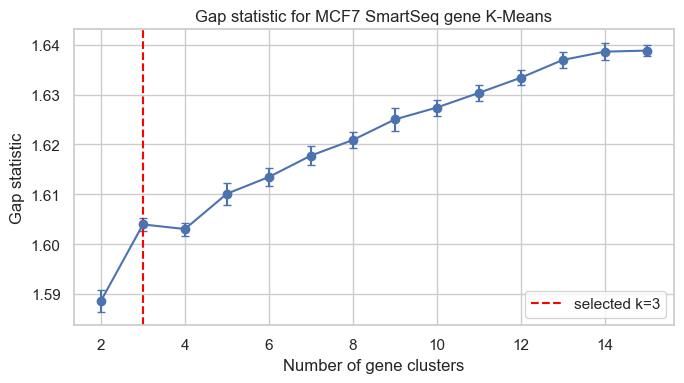

,n_genes
gene_cluster,
1,597
2,533
3,1870


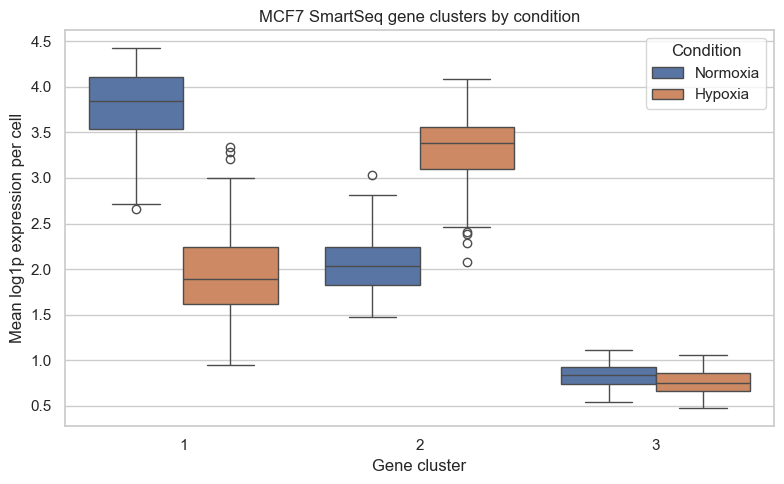

mean  median    std
gene_cluster Condition                      
1            Hypoxia    1.949   1.896  0.489
             Normoxia   3.782   3.844  0.419
2            Hypoxia    3.314   3.384  0.358
             Normoxia   2.054   2.033  0.293
3            Hypoxia    0.752   0.750  0.134
             Normoxia   0.838   0.844  0.120

Condition,Hypoxia,Normoxia,Hypoxia_minus_Normoxia
gene_cluster,,,
1,1.949,3.782,-1.833
2,3.314,2.054,1.261
3,0.752,0.838,-0.086


In [6]:
mcf7_expr, mcf7_conditions, _ = load_dataset("MCF7 SmartSeq")
mcf7_log1p = np.log1p(mcf7_expr)

# Genes are the observations; cells are the features.
mcf7_gene_profiles = mcf7_log1p.T

# Z-score each gene across cells so clustering uses expression pattern, not only expression magnitude.
mcf7_gene_profiles_z = pd.DataFrame(
    zscore(mcf7_gene_profiles, axis=1, nan_policy="omit"),
    index=mcf7_gene_profiles.index,
    columns=mcf7_gene_profiles.columns,
).fillna(0)

mcf7_gene_pca75_model = PCA(n_components=0.75, random_state=RANDOM_STATE)
mcf7_gene_pca75_values = mcf7_gene_pca75_model.fit_transform(mcf7_gene_profiles_z)

mcf7_gene_pca75 = pd.DataFrame(
    mcf7_gene_pca75_values,
    index=mcf7_gene_profiles_z.index,
    columns=[f"PC{i+1}" for i in range(mcf7_gene_pca75_values.shape[1])],
)

mcf7_gene_input_summary = pd.DataFrame({
    "dataset": ["MCF7 SmartSeq"],
    "n_cells": [mcf7_log1p.shape[0]],
    "n_genes": [mcf7_log1p.shape[1]],
    "n_pca75_components": [mcf7_gene_pca75.shape[1]],
    "explained_variance": [mcf7_gene_pca75_model.explained_variance_ratio_.sum()],
})

display(mcf7_gene_input_summary.round(3))


def within_cluster_dispersion(X, labels, cluster_centers):
    dispersion = 0.0

    for cluster_id in np.unique(labels):
        cluster_points = X[labels == cluster_id]
        cluster_center = cluster_centers[cluster_id]
        dispersion += np.sum((cluster_points - cluster_center) ** 2)

    return dispersion


def gap_statistic(X, k_values, n_reference=10, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)

    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    rows = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = kmeans.fit_predict(X)
        observed_dispersion = within_cluster_dispersion(X, labels, kmeans.cluster_centers_)

        reference_log_dispersions = []

        for i in range(n_reference):
            reference_data = rng.uniform(low=mins, high=maxs, size=X.shape)
            reference_kmeans = KMeans(n_clusters=k, random_state=random_state + i, n_init=20)
            reference_labels = reference_kmeans.fit_predict(reference_data)
            reference_dispersion = within_cluster_dispersion(
                reference_data,
                reference_labels,
                reference_kmeans.cluster_centers_,
            )
            reference_log_dispersions.append(np.log(reference_dispersion))

        rows.append({
            "k": k,
            "gap": np.mean(reference_log_dispersions) - np.log(observed_dispersion),
            "gap_std": np.std(reference_log_dispersions) * np.sqrt(1 + 1 / n_reference),
            "observed_dispersion": observed_dispersion,
        })

    return pd.DataFrame(rows)


k_values = range(2, 16)

mcf7_gene_gap_results = gap_statistic(
    mcf7_gene_pca75,
    k_values=k_values,
    n_reference=10,
    random_state=RANDOM_STATE,
)

selected_gene_k = int(mcf7_gene_gap_results.loc[mcf7_gene_gap_results["gap"].idxmax(), "k"])

for i in range(len(mcf7_gene_gap_results) - 1):
    gap_k = mcf7_gene_gap_results.loc[i, "gap"]
    gap_next = mcf7_gene_gap_results.loc[i + 1, "gap"]
    std_next = mcf7_gene_gap_results.loc[i + 1, "gap_std"]

    if gap_k >= gap_next - std_next:
        selected_gene_k = int(mcf7_gene_gap_results.loc[i, "k"])
        break

mcf7_gene_gap_selection_summary = pd.DataFrame({
    "selection_rule": ["Gap statistic first-SE rule"],
    "selected_k": [selected_gene_k],
})

display(mcf7_gene_gap_results.round(3))
display(mcf7_gene_gap_selection_summary)

plt.figure(figsize=(7, 4))
plt.errorbar(
    mcf7_gene_gap_results["k"],
    mcf7_gene_gap_results["gap"],
    yerr=mcf7_gene_gap_results["gap_std"],
    marker="o",
    capsize=3,
)
plt.axvline(selected_gene_k, color="red", linestyle="--", label=f"selected k={selected_gene_k}")
plt.title("Gap statistic for MCF7 SmartSeq gene K-Means")
plt.xlabel("Number of gene clusters")
plt.ylabel("Gap statistic")
plt.legend()
plt.tight_layout()
plt.show()

mcf7_gene_kmeans = KMeans(n_clusters=selected_gene_k, random_state=RANDOM_STATE, n_init=50)
mcf7_gene_clusters = pd.Series(
    mcf7_gene_kmeans.fit_predict(mcf7_gene_pca75) + 1,
    index=mcf7_gene_pca75.index,
    name="gene_cluster",
)

mcf7_gene_cluster_table = mcf7_gene_clusters.to_frame()

display(mcf7_gene_clusters.value_counts().sort_index().to_frame("n_genes"))

plot_rows = []
for cluster_id in sorted(mcf7_gene_clusters.unique()):
    genes = mcf7_gene_clusters[mcf7_gene_clusters == cluster_id].index
    mean_expression = mcf7_log1p[genes].mean(axis=1)
    plot_rows.append(pd.DataFrame({
        "gene_cluster": cluster_id,
        "mean_cluster_expression": mean_expression.values,
        "Condition": mcf7_conditions.reindex(mean_expression.index).values,
    }))

mcf7_gene_cluster_expression = pd.concat(plot_rows, ignore_index=True)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=mcf7_gene_cluster_expression,
    x="gene_cluster",
    y="mean_cluster_expression",
    hue="Condition",
    order=sorted(mcf7_gene_clusters.unique()),
    hue_order=["Normoxia", "Hypoxia"],
)
plt.title("MCF7 SmartSeq gene clusters by condition")
plt.xlabel("Gene cluster")
plt.ylabel("Mean log1p expression per cell")
plt.tight_layout()
plt.show()

mcf7_gene_cluster_condition_summary = (
    mcf7_gene_cluster_expression
    .groupby(["gene_cluster", "Condition"])["mean_cluster_expression"]
    .agg(["mean", "median", "std"])
)

display(mcf7_gene_cluster_condition_summary.round(3))

mcf7_gene_cluster_condition_difference = (
    mcf7_gene_cluster_expression
    .groupby(["gene_cluster", "Condition"])["mean_cluster_expression"]
    .mean()
    .unstack()
)

mcf7_gene_cluster_condition_difference["Hypoxia_minus_Normoxia"] = (
    mcf7_gene_cluster_condition_difference.get("Hypoxia", np.nan)
    - mcf7_gene_cluster_condition_difference.get("Normoxia", np.nan)
)

display(mcf7_gene_cluster_condition_difference.round(3))


The gap statistic selects the number of K-Means gene clusters before we interpret the cluster-expression boxplot. The condition table then checks whether the selected clusters correspond to genes preferentially expressed in hypoxia, normoxia, or neither condition. The next cell uses enrichment analysis to check whether genes grouped together by K-Means are also enriched for coherent biological terms.


In [7]:
gene_sets_to_check = [
    "MSigDB_Hallmark_2020",
    "GO_Biological_Process_2023",
    "KEGG_2021_Human",
]

mcf7_gene_enrichment_results = {}
mcf7_gene_enrichment_failures = []

if gp is None:
    mcf7_gene_enrichment_top_terms = pd.DataFrame({
        "status": ["GSEApy is not installed; enrichment was skipped."],
    })
else:
    for cluster_id in sorted(mcf7_gene_clusters.unique()):
        cluster_genes = (
            mcf7_gene_clusters[mcf7_gene_clusters == cluster_id]
            .index.astype(str)
            .str.upper()
            .tolist()
        )

        if len(cluster_genes) < 5:
            mcf7_gene_enrichment_failures.append({
                "gene_cluster": cluster_id,
                "reason": "too few genes",
            })
            continue

        try:
            enr = gp.enrichr(
                gene_list=cluster_genes,
                gene_sets=gene_sets_to_check,
                organism="human",
                outdir=None,
                cutoff=0.05,
            )
            top_terms = (
                enr.results[["Gene_set", "Term", "Adjusted P-value", "Odds Ratio", "Combined Score", "Genes"]]
                .sort_values("Adjusted P-value")
                .head(10)
                .copy()
            )
            top_terms.insert(0, "gene_cluster", cluster_id)
            top_terms.insert(1, "n_genes_in_cluster", len(cluster_genes))
            mcf7_gene_enrichment_results[cluster_id] = top_terms
        except Exception as exc:
            mcf7_gene_enrichment_failures.append({
                "gene_cluster": cluster_id,
                "reason": str(exc),
            })

    if len(mcf7_gene_enrichment_results) > 0:
        mcf7_gene_enrichment_top_terms = pd.concat(
            mcf7_gene_enrichment_results.values(),
            ignore_index=True,
        )
    else:
        mcf7_gene_enrichment_top_terms = pd.DataFrame()

if len(mcf7_gene_enrichment_top_terms) > 0:
    display(mcf7_gene_enrichment_top_terms)

if len(mcf7_gene_enrichment_failures) > 0:
    display(pd.DataFrame(mcf7_gene_enrichment_failures))

,gene_cluster,n_genes_in_cluster,Gene_set,Term,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,1,597,MSigDB_Hallmark_2020,E2F Targets,8.173293e-53,19.225191,2378.546910,TOP2A;H2AX;MCM7;SUV39H1;HMGB2;BUB1B;MKI67;CDC2...
1,1,597,MSigDB_Hallmark_2020,G2-M Checkpoint,1.287429e-39,14.595861,1352.149074,TOP2A;H2AX;SUV39H1;CCNF;MKI67;CDC20;PTTG1;EXO1...
2,1,597,MSigDB_Hallmark_2020,Estrogen Response Late,4.219287e-34,12.762205,1015.026706,RET;TOP2A;KCNK5;CLIC3;HSPB8;CELSR2;CDC20;CA2;M...
3,1,597,MSigDB_Hallmark_2020,Estrogen Response Early,9.259731e-27,10.435030,650.540799,RET;KCNK5;SLC26A2;CLIC3;SLC24A3;HSPB8;RHOBTB3;...
4,1,597,KEGG_2021_Human,Cell cycle,1.036639e-14,9.896675,374.615853,PCNA;MCM7;BUB1B;PKMYT1;CDC20;CCNB2;CCND3;CCNB1...
5,1,597,MSigDB_Hallmark_2020,mTORC1 Signaling,2.710008e-12,5.985994,172.449443,INSIG1;CCNF;PIK3R3;IFI30;CORO1A;UNG;TM7SF2;AUR...
6,1,597,GO_Biological_Process_2023,Mitotic Sister Chromatid Segregation (GO:0000070),4.984241e-11,9.299392,293.874244,SPAG5;CDCA5;PLK1;NCAPG2;KIF14;CDCA8;KIF23;KIF2...
7,1,597,KEGG_2021_Human,DNA replication,1.132396e-10,21.154998,589.396363,FEN1;PCNA;RNASEH2A;MCM7;LIG1;RFC2;POLA2;POLD1;...
8,1,597,GO_Biological_Process_2023,DNA Metabolic Process (GO:0006259),4.977397e-10,4.876751,139.509637,TOP2A;RTEL1;FEN1;RNASEH2A;MCM7;HMGB2;MCM10;SAM...
9,1,597,GO_Biological_Process_2023,Microtubule Cytoskeleton Organization Involved...,7.220069e-10,13.511371,376.016939,GPSM2;PLK1;CDCA8;WDR62;TUBG1;CKAP5;AURKB;NDC80...


K-means was applied to genes, so these clusters describe **gene programs**, not groups of cells. The boxplots compare how strongly each gene program is expressed in hypoxia versus normoxia cells.

| Gene cluster | Expression pattern | Top 3 pathway terms | Interpretation |
|---:|---|---|---|
| 1 | Higher in normoxia | E2F Targets; G2-M Checkpoint; Estrogen Response Late | A proliferative/cell-cycle gene program. These genes are more expressed in normoxia, suggesting that normoxic cells retain stronger DNA replication and mitotic activity. |
| 2 | Higher in hypoxia | Hypoxia; TNF-alpha Signaling via NF-kB; Glycolysis | A hypoxia-response gene program. These genes capture low-oxygen adaptation, inflammatory/stress signaling, and metabolic rewiring toward glycolysis. |
| 3 | Weak condition difference / broadly expressed | ECM-receptor interaction; Epithelial Mesenchymal Transition; Axon Guidance | This cluster is less directly hypoxia-vs-normoxia and may reflect cell-state and other features. |

The K-means gene clustering therefore finds one mainly **normoxia-associated program**, one mainly **hypoxia-associated program**, and one broader **structural program**. This is useful for feature engineering because each cell can be summarized by how much of its expression comes from these biologically interpretable gene programs.


<a id="gene-cluster-visual-checks"></a>
#### *Gene-cluster visual checks*

The next plots are visual checks for the gene clusters already fitted in PCA space. The correlation clustermap shows whether highly variable genes have block-like co-expression structure.


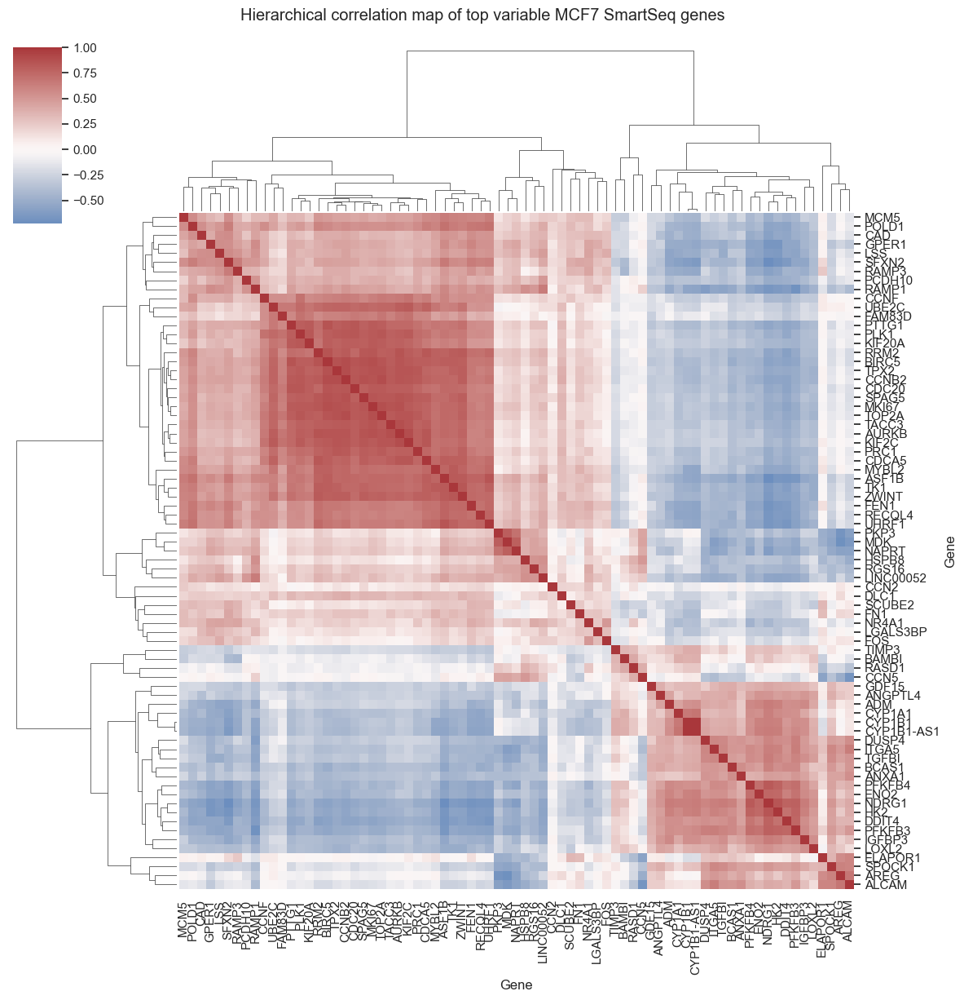

/Users/arturozecchina/Desktop/PROGRAMMING/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


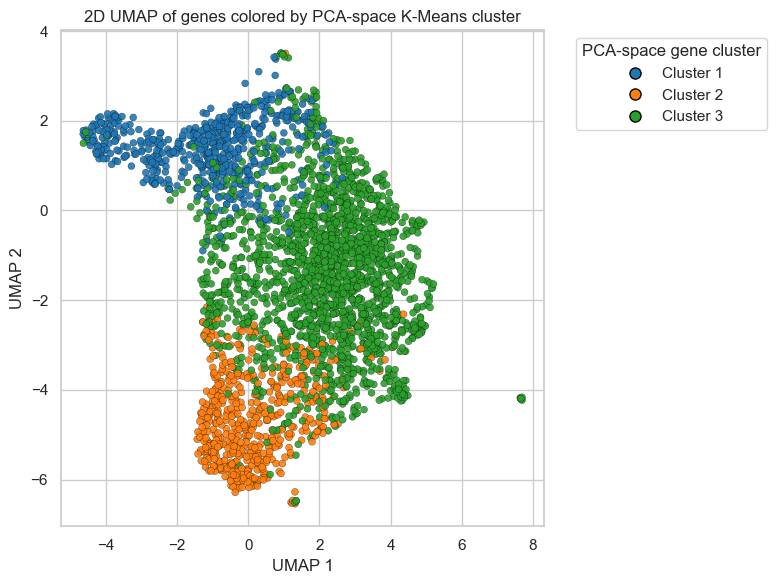

/Users/arturozecchina/Desktop/PROGRAMMING/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


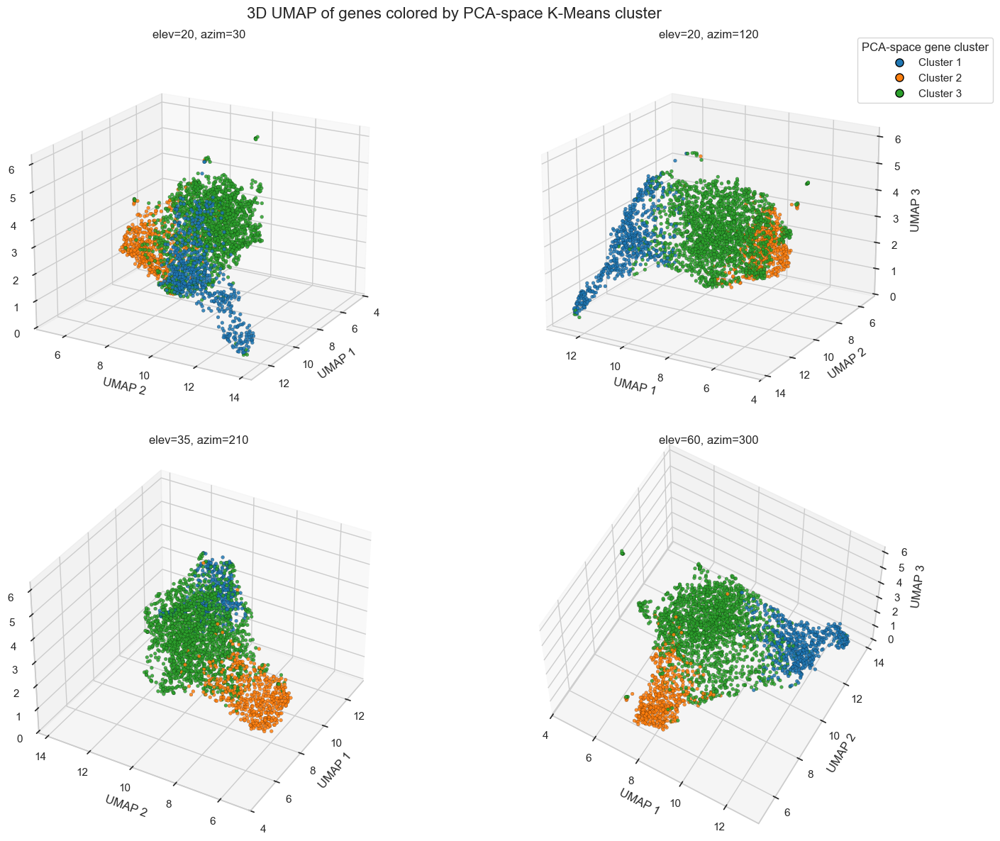

In [8]:
# Correlation clustermap for the top variable MCF7 SmartSeq genes.
n_top_genes = 75

mcf7_top_variable_genes = (
    mcf7_log1p
    .var(axis=0)
    .sort_values(ascending=False)
    .head(n_top_genes)
    .index
)

mcf7_gene_corr_matrix = mcf7_log1p[mcf7_top_variable_genes].corr(method="pearson")

sns.clustermap(
    mcf7_gene_corr_matrix,
    cmap="vlag",
    center=0,
    figsize=(12, 12),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
)
plt.suptitle("Hierarchical correlation map of top variable MCF7 SmartSeq genes", y=1.02)
plt.show()


# Fixed colors for the original PCA-space K-Means labels.
cluster_order = sorted(mcf7_gene_clusters.unique())
cluster_palette = dict(zip(cluster_order, sns.color_palette("tab10", n_colors=len(cluster_order))))
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=f"Cluster {cluster_id}",
        markerfacecolor=cluster_palette[cluster_id],
        markeredgecolor="black",
        markersize=8,
    )
    for cluster_id in cluster_order
]

if umap is None:
    print("umap-learn is not installed; skipping gene UMAP visualizations.")
else:
    gene_umap_2d = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.3,
        random_state=RANDOM_STATE,
    )

    gene_umap_2d_values = gene_umap_2d.fit_transform(mcf7_gene_pca75)
    mcf7_gene_umap_2d = pd.DataFrame(
        gene_umap_2d_values,
        index=mcf7_gene_pca75.index,
        columns=["UMAP_1", "UMAP_2"],
    )
    mcf7_gene_umap_2d["gene_cluster"] = mcf7_gene_clusters.reindex(mcf7_gene_umap_2d.index)
    mcf7_gene_umap_2d["cluster_color"] = mcf7_gene_umap_2d["gene_cluster"].map(cluster_palette)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        mcf7_gene_umap_2d["UMAP_1"],
        mcf7_gene_umap_2d["UMAP_2"],
        c=mcf7_gene_umap_2d["cluster_color"],
        s=25,
        edgecolors="black",
        linewidths=0.2,
        alpha=0.9,
    )
    plt.title("2D UMAP of genes colored by PCA-space K-Means cluster")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(handles=legend_handles, title="PCA-space gene cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    gene_umap_3d = umap.UMAP(
        n_components=3,
        n_neighbors=15,
        min_dist=0.3,
        random_state=RANDOM_STATE,
    )

    gene_umap_3d_values = gene_umap_3d.fit_transform(mcf7_gene_pca75)
    mcf7_gene_umap_3d = pd.DataFrame(
        gene_umap_3d_values,
        index=mcf7_gene_pca75.index,
        columns=["UMAP_1", "UMAP_2", "UMAP_3"],
    )
    mcf7_gene_umap_3d["gene_cluster"] = mcf7_gene_clusters.reindex(mcf7_gene_umap_3d.index)
    mcf7_gene_umap_3d["cluster_color"] = mcf7_gene_umap_3d["gene_cluster"].map(cluster_palette)

    view_angles = [
        (20, 30),
        (20, 120),
        (35, 210),
        (60, 300),
    ]

    fig = plt.figure(figsize=(16, 12))

    for i, (elev, azim) in enumerate(view_angles, start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")
        ax.scatter(
            mcf7_gene_umap_3d["UMAP_1"],
            mcf7_gene_umap_3d["UMAP_2"],
            mcf7_gene_umap_3d["UMAP_3"],
            c=mcf7_gene_umap_3d["cluster_color"],
            s=12,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.15,
        )
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(f"elev={elev}, azim={azim}")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_zlabel("UMAP 3")

    fig.suptitle("3D UMAP of genes colored by PCA-space K-Means cluster", fontsize=16)
    fig.legend(
        handles=legend_handles,
        title="PCA-space gene cluster",
        loc="upper right",
        bbox_to_anchor=(0.98, 0.95),
    )
    plt.tight_layout()
    plt.show()


The hierarchical clustering in the clustermap confirms our findings about the gene clusters. In the visualizations, we see a clear separation between the hypoxia and normoxia programs.

<a id="variational-autoencoder-dropseq-datasets"></a>
### **Variational Autoencoder (DropSeq datasets)**

DropSeq is much larger and sparser than SmartSeq, so a standard low-dimensional embedding can miss structure shaped by sampling noise, dropout, and library-size effects. For these datasets we use **scVI** (*single-cell Variational Inference*), a variational autoencoder designed for single-cell RNA-seq count data.

A variational autoencoder assumes that each cell has an unobserved latent state $z$ that generates the observed expression vector $x$. The encoder is a tractable approximation to the posterior distribution over latent states:

$$
q_\phi(z \mid x),
$$

and the decoder defines a generative likelihood:

$$
p_\theta(x \mid z).
$$

In scVI, this likelihood is adapted to scRNA-seq count data, usually through negative-binomial-style observation models, while the latent representation is regularized by a prior, commonly:

$$
p(z) = \mathcal{N}(0, I).
$$

The model is trained by maximizing the evidence lower bound:

$$
\mathcal{L}(\theta, \phi; x)
=
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
-
D_{KL}\left(q_\phi(z \mid x) \Vert p(z)\right).
$$

The reconstruction term rewards accurate reconstruction of the observed expression profile. The KL term regularizes the latent encoding toward the prior, keeping the representation compact instead of simply memorizing the input.

Equivalently:

$$
\log p_\theta(x)
=
\mathcal{L}(\theta, \phi; x)
+
D_{KL}\left(q_\phi(z \mid x) \Vert p_\theta(z \mid x)\right).
$$

So maximizing the ELBO minimizes the gap between the tractable encoder distribution and the true posterior. In this subsection we summarize the scVI latent-space GMM analyses for the two DropSeq datasets.


,dataset,best_k_BIC,best_BIC,best_k_AIC,best_AIC
0,HCC1806 DropSeq,5,399133.665,14,394744.304
1,MCF7 DropSeq,9,582364.619,15,576059.888


,dataset,gmm_cluster,n_cells,hypoxia_percentage,dominant_phase,dominant_phase_proportion,G1_proportion,S_proportion,G2M_proportion,mean_cluster_probability
0,HCC1806 DropSeq,1,2586,2.784,G2M,0.690,0.232,0.078,0.690,0.856
1,HCC1806 DropSeq,2,2751,97.928,G2M,0.713,0.232,0.054,0.713,0.844
2,HCC1806 DropSeq,3,3450,95.681,G2M,0.567,0.387,0.046,0.567,0.763
3,HCC1806 DropSeq,4,3646,74.767,G2M,0.607,0.328,0.066,0.607,0.796
4,HCC1806 DropSeq,5,2249,4.713,G2M,0.586,0.372,0.042,0.586,0.836
5,MCF7 DropSeq,1,3741,0.989,G1,0.472,0.472,0.240,0.288,0.686
6,MCF7 DropSeq,2,1162,98.279,G1,0.730,0.730,0.146,0.124,0.791
7,MCF7 DropSeq,3,2920,97.980,G1,0.737,0.737,0.160,0.103,0.808
8,MCF7 DropSeq,4,1773,15.059,G1,0.412,0.412,0.282,0.306,0.756
9,MCF7 DropSeq,5,2174,98.390,G1,0.759,0.759,0.176,0.065,0.772


,dataset,gmm_cluster,S_score_mean,S_score_median,G2M_score_mean,G2M_score_median
0,HCC1806 DropSeq,1,-0.199,-0.217,0.135,0.100
1,HCC1806 DropSeq,2,-0.230,-0.225,0.151,0.122
2,HCC1806 DropSeq,3,-0.280,-0.304,0.072,0.044
3,HCC1806 DropSeq,4,-0.245,-0.261,0.085,0.044
4,HCC1806 DropSeq,5,-0.304,-0.304,0.070,0.044
5,MCF7 DropSeq,1,-0.032,-0.049,-0.082,-0.090
6,MCF7 DropSeq,2,-0.096,-0.122,-0.179,-0.190
7,MCF7 DropSeq,3,-0.074,-0.073,-0.226,-0.233
8,MCF7 DropSeq,4,-0.019,-0.049,-0.054,-0.071
9,MCF7 DropSeq,5,-0.081,-0.098,-0.281,-0.286


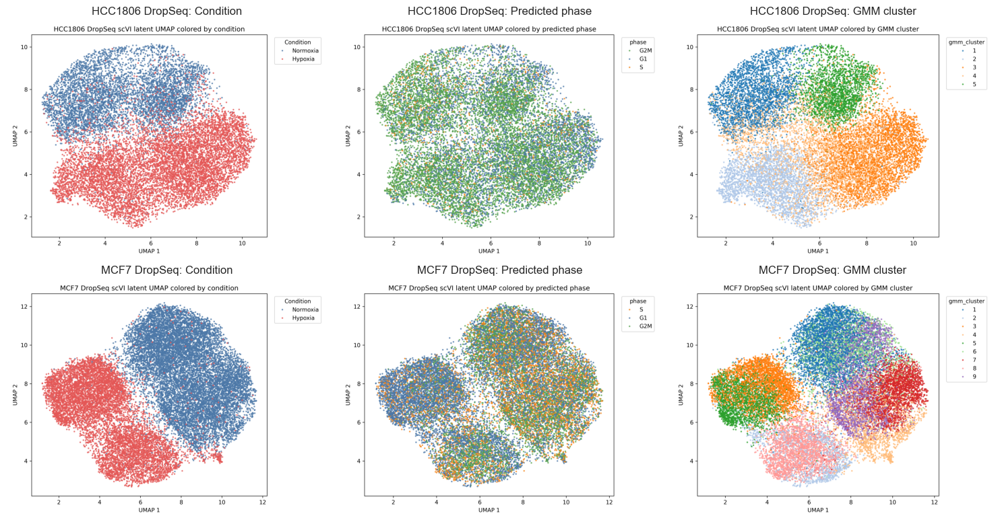

In [9]:
output_dir_candidates = [
    Path("scVI/scvi_dropseq_outputs"),
    Path("AI_LAB/scVI/scvi_dropseq_outputs"),
]

output_dir = next((p for p in output_dir_candidates if p.exists()), None)
if output_dir is None:
    raise FileNotFoundError("Could not find the scVI DropSeq output directory.")

scvi_datasets = {
    "hcc1806_dropseq": "HCC1806 DropSeq",
    "mcf7_dropseq": "MCF7 DropSeq",
}


def read_scvi_result(prefix, suffix, **kwargs):
    path = output_dir / f"{prefix}_{suffix}.csv"
    if not path.exists():
        return None
    return pd.read_csv(path, **kwargs)


model_rows = []
cluster_rows = []
cycle_score_rows = []

for prefix, label in scvi_datasets.items():
    model_selection = read_scvi_result(prefix, "scvi_gmm_model_selection")
    if model_selection is not None:
        best_bic = model_selection.loc[model_selection["bic"].idxmin()]
        best_aic = model_selection.loc[model_selection["aic"].idxmin()]
        model_rows.append({
            "dataset": label,
            "best_k_BIC": int(best_bic["k"]),
            "best_BIC": best_bic["bic"],
            "best_k_AIC": int(best_aic["k"]),
            "best_AIC": best_aic["aic"],
        })

    cluster_table = read_scvi_result(prefix, "scvi_gmm_cluster_table")
    if cluster_table is not None and {"gmm_cluster", "S_score", "G2M_score"}.issubset(cluster_table.columns):
        score_summary = (
            cluster_table
            .groupby("gmm_cluster")[["S_score", "G2M_score"]]
            .agg(["mean", "median"])
        )
        score_summary.columns = ["_".join(col) for col in score_summary.columns]
        score_summary = score_summary.reset_index()
        score_summary.insert(0, "dataset", label)
        cycle_score_rows.append(score_summary)

    phase_hypoxia_summary = read_scvi_result(prefix, "scvi_gmm_phase_hypoxia_summary")
    if phase_hypoxia_summary is not None:
        for _, row in phase_hypoxia_summary.iterrows():
            phase_props = {
                "G1": row.get("G1_proportion", 0),
                "S": row.get("S_proportion", 0),
                "G2M": row.get("G2M_proportion", 0),
            }
            dominant_phase = max(phase_props, key=phase_props.get)
            n_cells = row.get("G1", 0) + row.get("S", 0) + row.get("G2M", 0)
            cluster_rows.append({
                "dataset": label,
                "gmm_cluster": int(row["gmm_cluster"]),
                "n_cells": int(n_cells),
                "hypoxia_percentage": row.get("hypoxia_percentage", pd.NA),
                "dominant_phase": dominant_phase,
                "dominant_phase_proportion": phase_props[dominant_phase],
                "G1_proportion": phase_props["G1"],
                "S_proportion": phase_props["S"],
                "G2M_proportion": phase_props["G2M"],
                "mean_cluster_probability": row.get("mean_cluster_probability", pd.NA),
            })

scvi_gmm_model_summary = pd.DataFrame(model_rows)
scvi_gmm_cluster_summary = pd.DataFrame(cluster_rows)
scvi_gmm_cell_cycle_score_summary = (
    pd.concat(cycle_score_rows, ignore_index=True)
    if len(cycle_score_rows) > 0
    else pd.DataFrame()
)

display(scvi_gmm_model_summary.round(3))
display(scvi_gmm_cluster_summary.sort_values(["dataset", "gmm_cluster"]).round(3))
if len(scvi_gmm_cell_cycle_score_summary) > 0:
    display(scvi_gmm_cell_cycle_score_summary.sort_values(["dataset", "gmm_cluster"]).round(3))

plot_types = [
    ("condition", "Condition"),
    ("phase", "Predicted phase"),
    ("gmm_cluster", "GMM cluster"),
]

fig, axes = plt.subplots(len(scvi_datasets), len(plot_types), figsize=(15, 8))

for row_idx, (prefix, label) in enumerate(scvi_datasets.items()):
    for col_idx, (plot_name, title) in enumerate(plot_types):
        ax = axes[row_idx, col_idx]
        plot_path = output_dir / f"{prefix}_scvi_umap_{plot_name}.png"
        if plot_path.exists():
            ax.imshow(plt.imread(plot_path))
        else:
            ax.text(0.5, 0.5, f"Missing\n{plot_path.name}", ha="center", va="center")
        ax.set_title(f"{label}: {title}")
        ax.axis("off")

plt.tight_layout()
plt.show()


For HCC1806 DropSeq, BIC selects 5 GMM components in the 20-dimensional scVI latent space, while AIC prefers a much larger model. The BIC solution separates mostly normoxic components from hypoxia-enriched components, but all clusters are dominated by G2M-labeled cells. This means the latent space is capturing condition, but it is also strongly organized by broad cell-cycle structure.

For MCF7 DropSeq, BIC selects 9 components. Several clusters are almost condition-pure: clusters 2, 3, 5, and 8 are strongly hypoxic, while clusters 1, 6, and 9 are strongly normoxic. The phase distribution is more varied than in HCC1806 DropSeq, with many G1-dominant clusters and one more S-enriched component. This makes MCF7 DropSeq the clearer latent-space condition separation.


<a id="expected-cell-cycle-trajectory-in-the-scvi-latent-space"></a>
### **Expected cell-cycle trajectory in the scVI latent space**

We take advantage of the smoothness of the latent space coming from the Variational Autoencoder to show a proof of concept. Being cell cycle so hard to cluster, we try to understand and visualize this latent space in terms of cell phases. We effectively partitioned the dataset based on a more detailed 6-phase cycle. To learn the distribution of cells in each phase, we modelled their distributions fitting a GMM for each. Then, we plot the expected cell per distribution and visualize how a cell should in expectation move around in such compressed variational latent space.

This experiment does not reconstruct the true path of one observed cell through time, because these data are static. The idea is: **if we had a tool that could actively track a single cell through the cell cycle, then in the scVI latent space its expected movement should resemble the ordered path shown below**.

The coarse cell-cycle annotation is refined into six ordered stages:

$$
G1_{low} \rightarrow S_{entry} \rightarrow S_{high} \rightarrow S/G2M_{transition} \rightarrow G2M_{entry} \rightarrow G2M_{high}.
$$

The output tables use:

- `G1_low_cycle`
- `S_entry`
- `S_high`
- `S_G2M_transition`
- `G2M_entry`
- `G2M_high`

For each DropSeq dataset, and separately for hypoxia and normoxia, GMMs were fitted in the scVI latent space for each life-cycle stage:

$$
p(z \mid c, s)
\approx
\sum_{k=1}^{K_{c,s}} \pi_{k,c,s}\,\mathcal{N}\left(z \mid \mu_{k,c,s}, \Sigma_{k,c,s}\right),
$$

where $z$ is the scVI latent representation, $c$ is the condition, and $s$ is the stage. The trajectory figures are shown separately so each expected path can be inspected on its own.

Note that, due to the computational limitations of a notebook, we created separate python scripts to obtain the results shown below, and for explanation purposes we load the results directly.

,dataset,life_stage,hypoxia_cells,normoxia_cells,total_cells,hypoxia_percentage
0,HCC1806 DropSeq,G1_low_cycle,3167,1914,5081,62.330
4,HCC1806 DropSeq,G2M_entry,2450,1763,4213,58.153
5,HCC1806 DropSeq,G2M_high,2744,1693,4437,61.844
3,HCC1806 DropSeq,S_G2M_transition,139,129,268,51.866
1,HCC1806 DropSeq,S_entry,153,112,265,57.736
2,HCC1806 DropSeq,S_high,246,172,418,58.852
6,MCF7 DropSeq,G1_low_cycle,5894,5888,11782,50.025
10,MCF7 DropSeq,G2M_entry,615,1623,2238,27.480
11,MCF7 DropSeq,G2M_high,804,1756,2560,31.406
9,MCF7 DropSeq,S_G2M_transition,128,497,625,20.480


,dataset,Condition,life_stage,n_real_cells,selected_components,status,bic,aic
6,HCC1806 DropSeq,Hypoxia,G1_low_cycle,3167,2,fit,88522.850,87728.919
10,HCC1806 DropSeq,Hypoxia,G2M_entry,2450,2,fit,65745.376,64985.072
11,HCC1806 DropSeq,Hypoxia,G2M_high,2744,2,fit,72911.118,72135.969
9,HCC1806 DropSeq,Hypoxia,S_G2M_transition,139,1,fit,4005.331,3814.590
7,HCC1806 DropSeq,Hypoxia,S_entry,153,1,fit,4490.637,4293.658
8,HCC1806 DropSeq,Hypoxia,S_high,246,1,fit,7311.753,7083.907
0,HCC1806 DropSeq,Normoxia,G1_low_cycle,1914,2,fit,48359.706,47631.745
4,HCC1806 DropSeq,Normoxia,G2M_entry,1763,3,fit,43142.537,42064.007
5,HCC1806 DropSeq,Normoxia,G2M_high,1693,3,fit,40624.224,39553.675
3,HCC1806 DropSeq,Normoxia,S_G2M_transition,129,1,fit,3194.100,3008.212


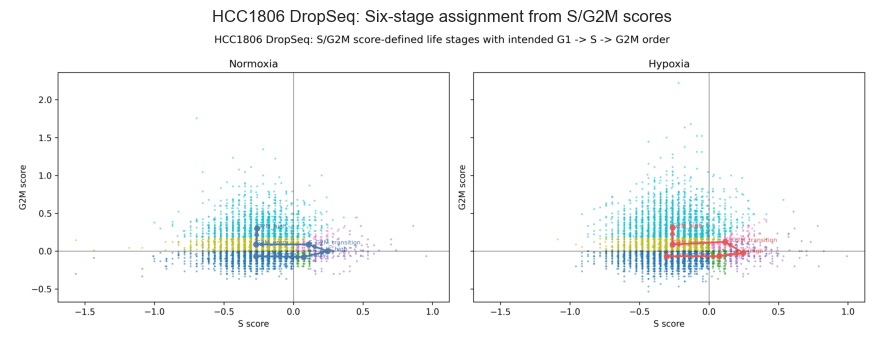

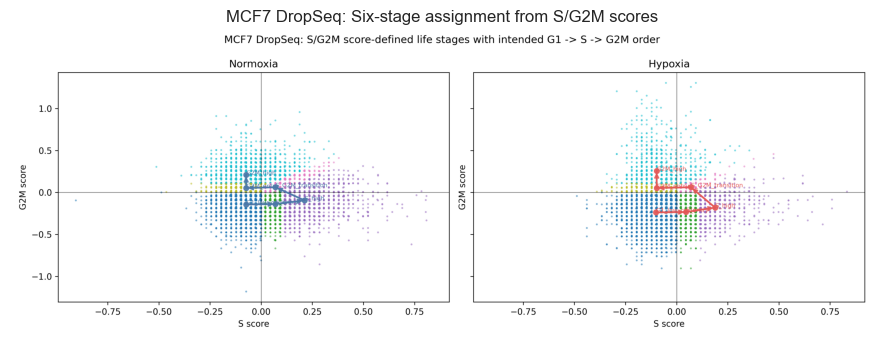

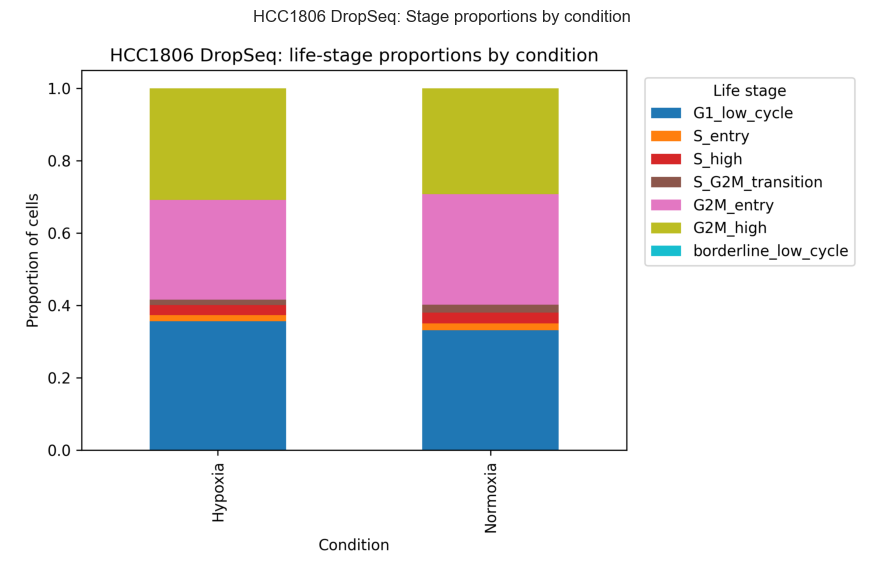

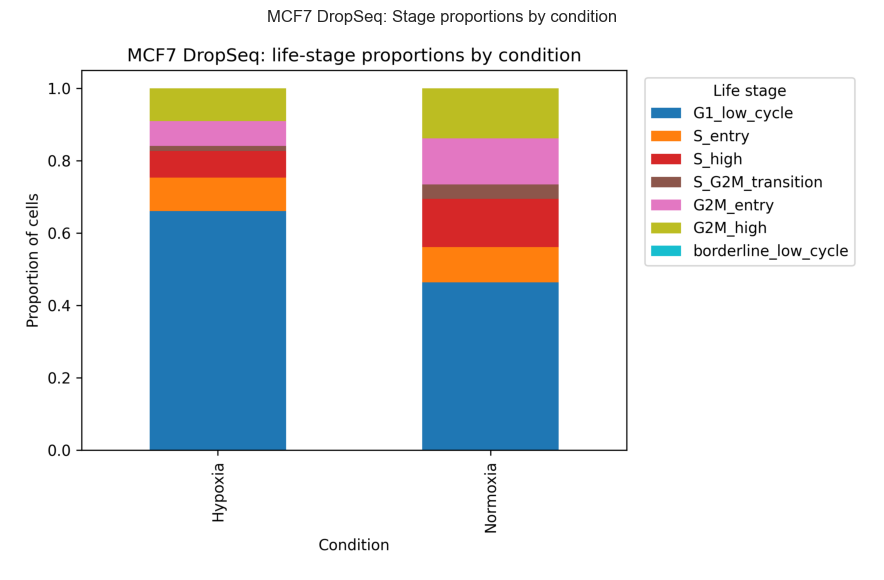

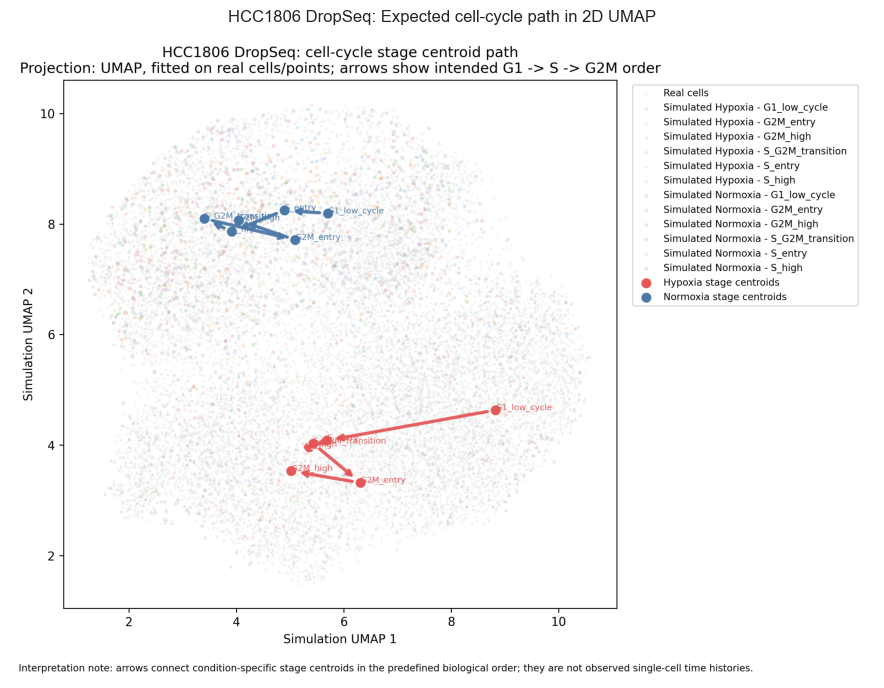

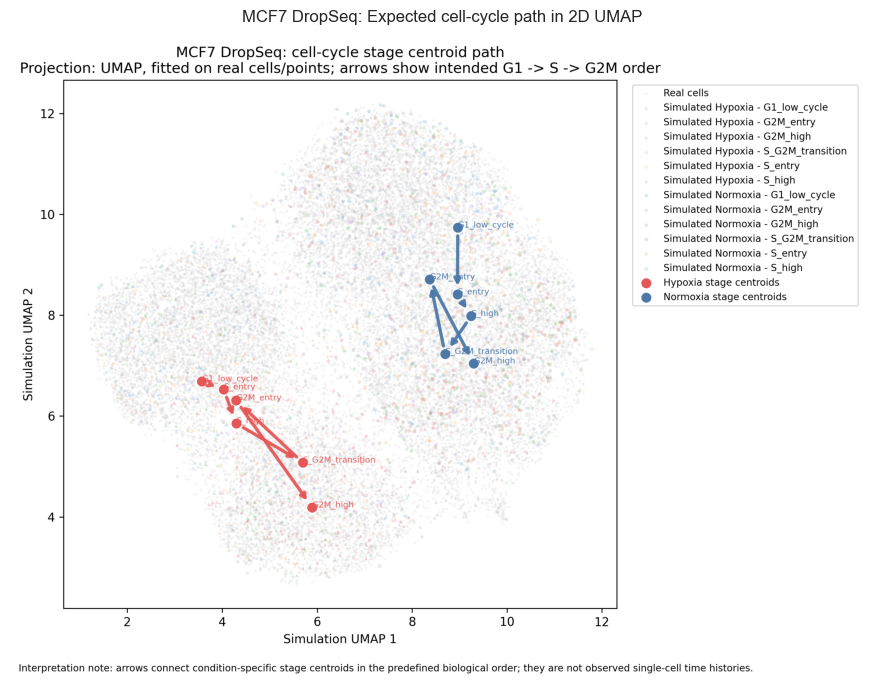

In [10]:



trajectory_dir_candidates = [
    Path("scVI/cell_cycle_trajectory_outputs"),
    Path("AI_LAB/scVI/cell_cycle_trajectory_outputs"),
]

trajectory_dir = next((p for p in trajectory_dir_candidates if p.exists()), None)
if trajectory_dir is None:
    raise FileNotFoundError("Could not find the scVI cell-cycle trajectory directory.")

trajectory_datasets = {
    "hcc1806_dropseq": "HCC1806 DropSeq",
    "mcf7_dropseq": "MCF7 DropSeq",
}

stage_order = [
    "G1_low_cycle",
    "S_entry",
    "S_high",
    "S_G2M_transition",
    "G2M_entry",
    "G2M_high",
]

stage_count_rows = []
gmm_rows = []

for prefix, label in trajectory_datasets.items():
    counts = pd.read_csv(trajectory_dir / f"{prefix}_life_stage_counts.csv")
    counts = counts[counts["life_stage"].isin(stage_order)].copy()

    for _, row in counts.iterrows():
        hypoxia = row.get("Hypoxia", 0)
        normoxia = row.get("Normoxia", 0)
        total = hypoxia + normoxia
        stage_count_rows.append({
            "dataset": label,
            "life_stage": row["life_stage"],
            "hypoxia_cells": hypoxia,
            "normoxia_cells": normoxia,
            "total_cells": total,
            "hypoxia_percentage": 100 * hypoxia / total if total > 0 else pd.NA,
        })

    gmm_summary = pd.read_csv(trajectory_dir / f"{prefix}_condition_stage_distribution_models.csv")
    gmm_summary = gmm_summary[gmm_summary["life_stage"].isin(stage_order)].copy()
    gmm_summary.insert(0, "dataset", label)
    gmm_rows.append(gmm_summary)

trajectory_stage_summary = pd.DataFrame(stage_count_rows)
trajectory_gmm_summary = pd.concat(gmm_rows, ignore_index=True)[
    ["dataset", "Condition", "life_stage", "n_real_cells", "selected_components", "status", "bic", "aic"]
]

display(trajectory_stage_summary.sort_values(["dataset", "life_stage"]).round(3))
display(trajectory_gmm_summary.sort_values(["dataset", "Condition", "life_stage"]).round(3))

plot_specs = [
    ("life_stage_score_scatter", "Six-stage assignment from S/G2M scores"),
    ("life_stage_condition_proportions", "Stage proportions by condition"),
    ("centroid_arrows_umap", "Expected cell-cycle path in 2D UMAP"),
]

for plot_suffix, plot_title in plot_specs:
    for prefix, label in trajectory_datasets.items():
        plot_path = trajectory_dir / f"{prefix}_{plot_suffix}.png"

        plt.figure(figsize=(9, 7))
        if plot_path.exists():
            plt.imshow(plt.imread(plot_path))
        else:
            plt.text(0.5, 0.5, f"Missing\n{plot_path.name}", ha="center", va="center")

        plt.title(f"{label}: {plot_title}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()


<a id="downstream-analysis"></a>
## **DOWNSTREAM ANALYSIS**

Here we use the clustering and representation-learning work to build supervised-learning inputs. This section is separated from the exploratory clustering above: the goal now is to evaluate compact representations and export final cell-level tables.

<a id="dimensionality-reduction-2"></a>
### **Dimensionality Reduction**

The compact representation table combines:

- **SmartSeq datasets**: autoencoder embeddings.
- **DropSeq datasets**: 20-component scVI latent representations.

The next cell confirms the compressed representation manifest before the downstream clustering comparison.


In [11]:



final_compressed_dir = Path("final_compressed")

if not final_compressed_dir.exists():
    raise FileNotFoundError("Could not find final_compressed/. Run or create the compact representation exports first.")

manifest_path = final_compressed_dir / "manifest.csv"

if manifest_path.exists():
    final_compressed_manifest = pd.read_csv(manifest_path)
    display(final_compressed_manifest)
else:
    final_compressed_manifest = pd.DataFrame({
        "file": [path.name for path in sorted(final_compressed_dir.glob("*.csv"))]
    })
    display(final_compressed_manifest)


,file,cell_line,technology,representation,n_components,source_folder
0,hcc1806_dropseq_scvi_latent_representations_n2...,HCC1806,DropSeq,scVI,20,compact_representations
1,mcf7_dropseq_scvi_latent_representations_n20.csv,MCF7,DropSeq,scVI,20,compact_representations
2,hcc1806_smartseq_autoencoder_embeddings.csv,HCC1806,SmartSeq,autoencoder,as_saved,compact_representations
3,mcf7_smartseq_autoencoder_embeddings.csv,MCF7,SmartSeq,autoencoder,as_saved,compact_representations


<a id="clustering-2"></a>
### **Clustering**

We now test whether the compact representations separate hypoxia and normoxia using GMM clustering. For this downstream comparison, each dataset gets a full-covariance GMM selected by lowest AIC.

The cluster labels are converted into predicted conditions by assigning each cluster to its majority condition. Balanced accuracy is then computed from those majority-condition predictions, so the score is not inflated simply because one condition is more common.


,dataset,k,aic,bic
0,HCC1806 DropSeq,2,786552.788,790053.796
1,HCC1806 DropSeq,3,783884.604,789139.913
2,HCC1806 DropSeq,4,781607.849,788617.460
3,HCC1806 DropSeq,5,780679.385,789443.297
4,HCC1806 DropSeq,6,779769.346,790287.559
5,HCC1806 DropSeq,7,779068.137,791340.651
6,HCC1806 DropSeq,8,778958.343,792985.159
7,HCC1806 DropSeq,9,778552.286,794333.402
8,HCC1806 DropSeq,10,778459.874,795995.292
9,MCF7 DropSeq,2,1139399.170,1143078.711


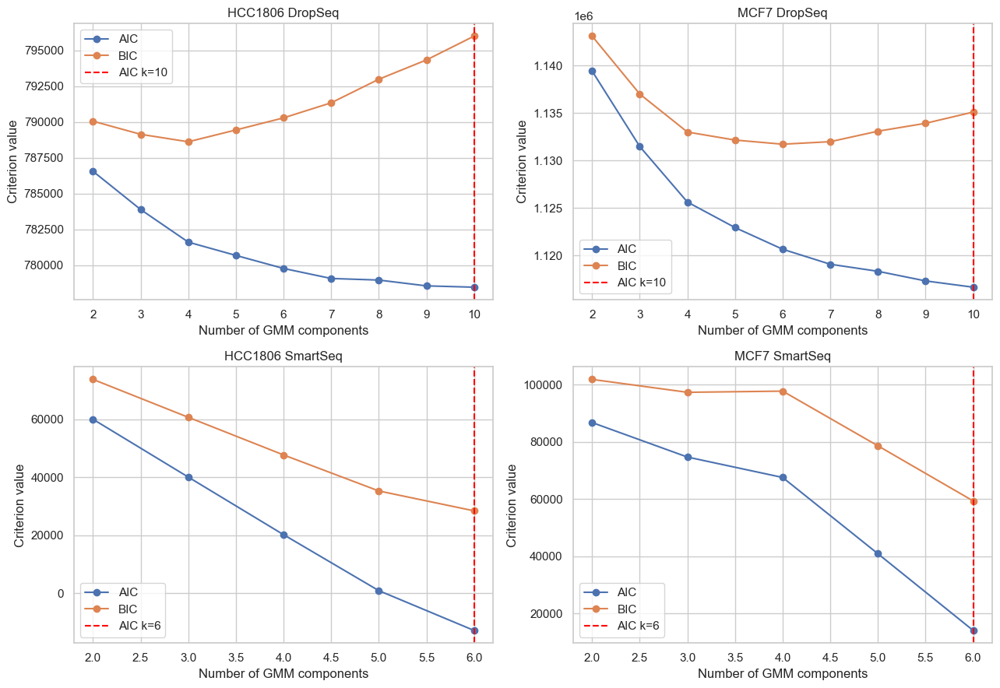

,dataset,selected_k_by_AIC,balanced_accuracy_predicting_hypoxia,weighted_cluster_purity,hypoxia_percentage,n_cells,n_features
3,MCF7 SmartSeq,6,1.000,1.000,49.600,250,64
1,MCF7 DropSeq,10,0.969,0.973,41.251,21626,20
2,HCC1806 SmartSeq,6,0.870,0.868,53.297,182,64
0,HCC1806 DropSeq,10,0.836,0.854,60.612,14682,20


,dataset,cluster,assigned_condition,n_cells,hypoxia_percentage,normoxia_percentage
0,HCC1806 DropSeq,1,Hypoxia,1205,83.651,16.349
1,HCC1806 DropSeq,2,Normoxia,1584,6.187,93.813
2,HCC1806 DropSeq,3,Hypoxia,1603,98.129,1.871
3,HCC1806 DropSeq,4,Hypoxia,1544,61.075,38.925
4,HCC1806 DropSeq,5,Hypoxia,1507,89.715,10.285
5,HCC1806 DropSeq,6,Normoxia,1725,1.217,98.783
6,HCC1806 DropSeq,7,Hypoxia,1028,75.681,24.319
7,HCC1806 DropSeq,8,Hypoxia,1807,98.450,1.550
8,HCC1806 DropSeq,9,Normoxia,1710,33.333,66.667
9,HCC1806 DropSeq,10,Hypoxia,969,80.186,19.814


In [12]:
final_compressed_dir = Path("final_compressed")

compressed_files = {
    "HCC1806 DropSeq": final_compressed_dir / "hcc1806_dropseq_scvi_latent_representations_n20.csv",
    "MCF7 DropSeq": final_compressed_dir / "mcf7_dropseq_scvi_latent_representations_n20.csv",
    "HCC1806 SmartSeq": final_compressed_dir / "hcc1806_smartseq_autoencoder_embeddings.csv",
    "MCF7 SmartSeq": final_compressed_dir / "mcf7_smartseq_autoencoder_embeddings.csv",
}


def load_compressed_representation(path, dataset_name):
    df = pd.read_csv(path)

    if "Cell" not in df.columns:
        first_col = df.columns[0]
        df = df.rename(columns={first_col: "Cell"})

    if "Condition" not in df.columns:
        df["Condition"] = df["Cell"].map(normalize_condition)
    else:
        df["Condition"] = df["Condition"].map(normalize_condition)

    df["dataset"] = dataset_name
    df["Cell"] = df["Cell"].astype(str).str.strip('"')

    feature_cols = [col for col in df.columns if col.startswith("scVI_") or col.startswith("AE_")]
    if len(feature_cols) == 0:
        feature_cols = [col for col in df.select_dtypes(include="number").columns if col != "n_latent"]

    return df, feature_cols


def majority_condition_metrics(labels, conditions):
    labels = pd.Series(labels, name="cluster")
    conditions = pd.Series(conditions, name="Condition")

    counts = pd.crosstab(labels, conditions)
    cluster_to_condition = counts.idxmax(axis=1)
    predicted = labels.map(cluster_to_condition)

    y_true = (conditions == "Hypoxia").astype(int)
    y_pred = (predicted == "Hypoxia").astype(int)

    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    weighted_purity = counts.max(axis=1).sum() / counts.values.sum()

    return balanced_accuracy, weighted_purity, counts, cluster_to_condition


performance_rows = []
cluster_rows = []
compact_model_selection_rows = []
compressed_tables = {}

for dataset_name, path in compressed_files.items():
    df, feature_cols = load_compressed_representation(path, dataset_name)
    df = df[df["Condition"].isin(["Hypoxia", "Normoxia"])].copy()

    X = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy()
    max_k = 10 if "DropSeq" in dataset_name else 6

    model_rows = []
    models = {}
    for k in range(2, min(max_k, len(df) - 1) + 1):
        model = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=RANDOM_STATE,
            n_init=10,
            max_iter=500,
            reg_covar=1e-6,
        )
        model.fit(X)
        models[k] = model
        model_rows.append({"k": k, "aic": model.aic(X), "bic": model.bic(X)})

    selection = pd.DataFrame(model_rows)
    selection["dataset"] = dataset_name
    compact_model_selection_rows.append(selection)

    selected_k = int(selection.loc[selection["aic"].idxmin(), "k"])
    labels = models[selected_k].predict(X) + 1

    balanced_accuracy, weighted_purity, counts, cluster_to_condition = majority_condition_metrics(labels, df["Condition"])

    df["gmm_aic_cluster"] = labels
    compressed_tables[dataset_name] = df

    performance_rows.append({
        "dataset": dataset_name,
        "selected_k_by_AIC": selected_k,
        "balanced_accuracy_predicting_hypoxia": balanced_accuracy,
        "weighted_cluster_purity": weighted_purity,
        "hypoxia_percentage": (df["Condition"] == "Hypoxia").mean() * 100,
        "n_cells": len(df),
        "n_features": len(feature_cols),
    })

    props = counts.div(counts.sum(axis=1), axis=0)
    for cluster_id in counts.index:
        cluster_rows.append({
            "dataset": dataset_name,
            "cluster": cluster_id,
            "assigned_condition": cluster_to_condition.loc[cluster_id],
            "n_cells": counts.loc[cluster_id].sum(),
            "hypoxia_percentage": props.loc[cluster_id].get("Hypoxia", 0) * 100,
            "normoxia_percentage": props.loc[cluster_id].get("Normoxia", 0) * 100,
        })

compact_gmm_model_selection = pd.concat(compact_model_selection_rows, ignore_index=True)
compact_gmm_performance = pd.DataFrame(performance_rows)
compact_gmm_cluster_summary = pd.DataFrame(cluster_rows)

display(compact_gmm_model_selection[["dataset", "k", "aic", "bic"]].round(3))

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=False)
axes = axes.ravel()

for ax, dataset_name in zip(axes, compressed_files.keys()):
    curve = compact_gmm_model_selection[compact_gmm_model_selection["dataset"] == dataset_name]
    selected_k = int(compact_gmm_performance.loc[
        compact_gmm_performance["dataset"] == dataset_name,
        "selected_k_by_AIC",
    ].iloc[0])

    ax.plot(curve["k"], curve["aic"], marker="o", label="AIC")
    ax.plot(curve["k"], curve["bic"], marker="o", label="BIC")
    ax.axvline(selected_k, color="red", linestyle="--", label=f"AIC k={selected_k}")
    ax.set_title(dataset_name)
    ax.set_xlabel("Number of GMM components")
    ax.set_ylabel("Criterion value")
    ax.legend()

plt.tight_layout()
plt.show()

display(compact_gmm_performance.sort_values("balanced_accuracy_predicting_hypoxia", ascending=False).round(3))
display(compact_gmm_cluster_summary.sort_values(["dataset", "cluster"]).round(3))


The final compressed representations preserve condition information well. In the GMM comparison, MCF7 SmartSeq reaches perfect balanced accuracy, MCF7 DropSeq is very high, and both HCC1806 datasets remain clearly above chance. This supports using the compressed features as supervised-learning inputs.

The results should still be interpreted as representation quality, not as direct biology of individual components. A high balanced accuracy means the latent space contains enough structure to recover hypoxia/normoxia labels after clustering. It does not mean that a single latent coordinate is itself a hypoxia pathway, a cell-cycle pathway, or a QC artifact. The engineered gene-program percentages are added precisely to make part of the final feature table more biologically legible.


<a id="condition-aware-gene-features"></a>
### **Condition-Aware Gene Features**

For SmartSeq datasets, the gene programs are computed from log-transformed expression after standardizing each gene across cells. This means PCA and K-Means focus on the shape of each gene's expression pattern across normoxia and hypoxia cells, rather than mainly on absolute expression magnitude.

For DropSeq datasets, the gene programs use the gene-level 10-dimensional scVI representation computed previously. Before K-Means, each scVI latent dimension is z-scored across genes, so the gene clusters are not driven by latent-coordinate scale.

For every cell, we then compute the percentage of its total expression coming from each program. These percentages become engineered supervised-learning features.


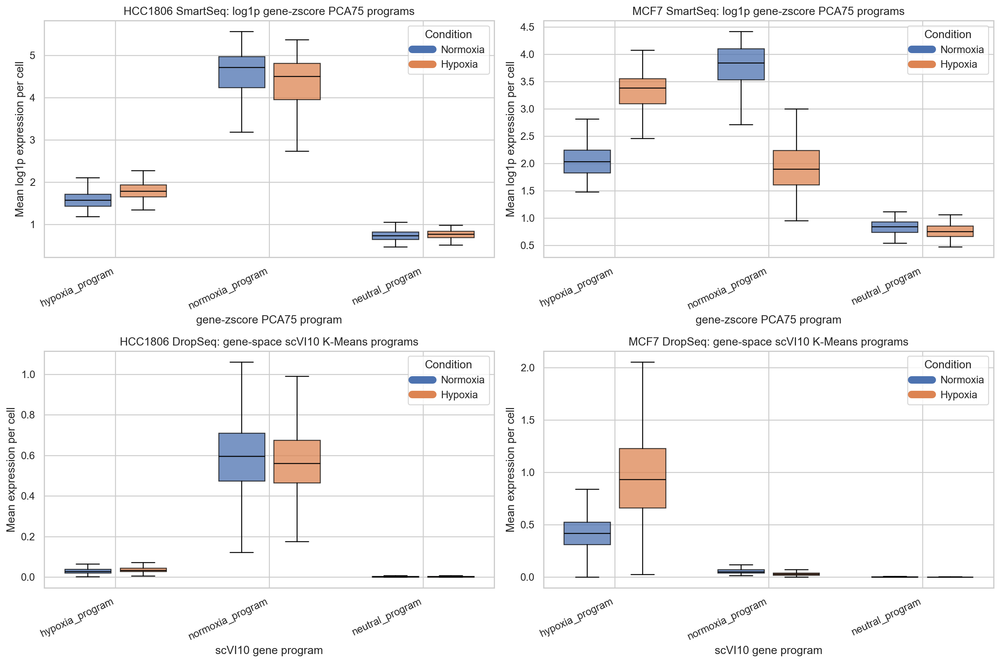

,dataset,gene_program,n_genes,mean_program_percent,median_program_percent
6,HCC1806 DropSeq,hypoxia_program,984,32.062,32.000
8,HCC1806 DropSeq,neutral_program,1902,4.555,4.000
7,HCC1806 DropSeq,normoxia_program,114,63.383,63.542
0,HCC1806 SmartSeq,hypoxia_program,590,32.054,29.602
2,HCC1806 SmartSeq,neutral_program,2058,28.025,27.941
1,HCC1806 SmartSeq,normoxia_program,352,39.921,41.384
9,MCF7 DropSeq,hypoxia_program,74,44.587,41.379
11,MCF7 DropSeq,neutral_program,1761,4.034,3.546
10,MCF7 DropSeq,normoxia_program,1165,51.379,54.545
3,MCF7 SmartSeq,hypoxia_program,533,46.697,40.163


,Cell,dataset,Condition,total_expression_condition_genes,hypoxia_program_percent,normoxia_program_percent,neutral_program_percent
0,output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,HCC1806 SmartSeq,Normoxia,448059.0,30.742,40.071,29.187
1,output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,HCC1806 SmartSeq,Hypoxia,546909.0,36.515,35.598,27.887
2,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam,HCC1806 SmartSeq,Hypoxia,536837.0,32.930,41.869,25.201
3,output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sortedByCoord.out.bam,HCC1806 SmartSeq,Hypoxia,504550.0,37.466,37.816,24.718
4,output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam,HCC1806 SmartSeq,Hypoxia,553200.0,40.158,26.578,33.264


In [ ]:
from IPython.display import Image, display

report_asset_dir = Path("archive/outputs/report_assets")
condition_gene_plot_path = report_asset_dir / "condition_aware_gene_features_updated.png"
condition_gene_summary_path = report_asset_dir / "condition_gene_program_summary_updated.csv"
engineered_features_path = report_asset_dir / "engineered_condition_gene_features_updated.csv"

condition_gene_program_summary = pd.read_csv(condition_gene_summary_path)
engineered_condition_gene_features = pd.read_csv(engineered_features_path)

display(Image(filename=str(condition_gene_plot_path)))
display(condition_gene_program_summary.sort_values(["dataset", "gene_program"]).round(3))
display(engineered_condition_gene_features.head().round(3))


<a id="data-leakage-caveat"></a>
### **Data Leakage Caveat**

The condition-aware gene-program features are intentionally built from the observed hypoxia/normoxia labels: for each dataset, genes are grouped into hypoxia-associated, normoxia-associated, and neutral programs, and each cell is summarized by the percentage of its expression coming from those programs.

This creates a **data leakage caveat for cross-validation scores**. If the gene programs are computed once using all cells before cross-validation, then the validation fold has indirectly contributed to the definition of the feature space. The classifier is still trained only on the training fold, but the engineered representation already contains dataset-level label information.

A stricter supervised-learning pipeline would recompute the condition-aware gene programs inside every training fold and then transform the corresponding validation fold. We do not do that here because it would make the workflow much heavier computationally and structurally, while the same broad hypoxia/normoxia programs would be expected to reappear in nearly the same form. 


<a id="final-datasets"></a>
### **Final Datasets**

The final step merges the compact latent representation with the engineered condition-aware gene-program features. The exported tables are cell-level supervised-learning inputs: one row per cell, with condition labels, compressed features, and engineered gene-program percentages.

These final tables are intentionally **not standardized**. Standardization should be part of the supervised-learning pipeline after the train/test split, with the scaler fitted on the training set only and then applied to validation/test data. This avoids data leakage and keeps the exported datasets interpretable.


In [14]:



supervised_output_dir = Path("final_supervised_datasets")
supervised_output_dir.mkdir(exist_ok=True)

compressed_name_map = {
    "HCC1806 SmartSeq": "hcc1806_smartseq_supervised.csv",
    "MCF7 SmartSeq": "mcf7_smartseq_supervised.csv",
    "HCC1806 DropSeq": "hcc1806_dropseq_supervised.csv",
    "MCF7 DropSeq": "mcf7_dropseq_supervised.csv",
}

final_supervised_tables = {}
manifest_rows = []

engineered = engineered_condition_gene_features.copy()
engineered["Cell"] = engineered["Cell"].astype(str).str.strip('"')
engineered["Condition"] = engineered["Condition"].map(normalize_condition)

for dataset_name, path in compressed_files.items():
    compressed, feature_cols = load_compressed_representation(path, dataset_name)
    compressed["Cell"] = compressed["Cell"].astype(str).str.strip('"')
    compressed["Condition"] = compressed["Condition"].map(normalize_condition)

    engineered_dataset = engineered[engineered["dataset"] == dataset_name].copy()

    merged = compressed.merge(
        engineered_dataset.drop(columns=["Condition"], errors="ignore"),
        on=["dataset", "Cell"],
        how="left",
    )

    missing_feature_fraction = merged["hypoxia_program_percent"].isna().mean()

    output_name = compressed_name_map[dataset_name]
    output_path = supervised_output_dir / output_name
    merged.to_csv(output_path, index=False)

    final_supervised_tables[dataset_name] = merged

    manifest_rows.append({
        "dataset": dataset_name,
        "file": output_name,
        "n_cells": len(merged),
        "n_compressed_features": len(feature_cols),
        "has_hypoxia_program_percent": "hypoxia_program_percent" in merged.columns,
        "missing_engineered_feature_fraction": missing_feature_fraction,
    })

all_final_supervised_datasets = pd.concat(final_supervised_tables.values(), ignore_index=True)
all_final_supervised_datasets.to_csv(supervised_output_dir / "all_final_supervised_datasets.csv", index=False)

final_supervised_manifest = pd.DataFrame(manifest_rows)
final_supervised_manifest.to_csv(supervised_output_dir / "manifest.csv", index=False)

display(final_supervised_manifest.round(3))
display(all_final_supervised_datasets.head())



,dataset,file,n_cells,n_compressed_features,has_hypoxia_program_percent,missing_engineered_feature_fraction
0,HCC1806 DropSeq,hcc1806_dropseq_supervised.csv,14682,20,True,0.0
1,MCF7 DropSeq,mcf7_dropseq_supervised.csv,21626,20,True,0.0
2,HCC1806 SmartSeq,hcc1806_smartseq_supervised.csv,182,64,True,0.0
3,MCF7 SmartSeq,mcf7_smartseq_supervised.csv,250,64,True,0.0


,Cell,dataset,Condition,n_latent,scVI_1,scVI_2,scVI_3,scVI_4,scVI_5,scVI_6,...,AE_55,AE_56,AE_57,AE_58,AE_59,AE_60,AE_61,AE_62,AE_63,AE_64
0,AAAAAACCCGGC_Normoxia,HCC1806 DropSeq,Normoxia,20.0,-0.063717,0.721548,1.963132,-0.690725,0.966428,0.371041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAAACCGGATGC_Normoxia,HCC1806 DropSeq,Normoxia,20.0,1.390998,1.522237,0.815685,0.070444,-0.852970,0.674532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAAACGAGCTAG_Normoxia,HCC1806 DropSeq,Normoxia,20.0,1.134065,-0.337618,0.284207,0.050283,-1.867768,0.585909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAAACTTCCCCG_Normoxia,HCC1806 DropSeq,Normoxia,20.0,0.212486,-1.203606,1.394321,-0.496647,-0.205482,1.478348,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAAAGCCTACCC_Normoxia,HCC1806 DropSeq,Normoxia,20.0,1.048451,-1.692933,1.289706,-0.455353,2.032611,0.503315,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
engineered_feature_columns = [
    "total_expression_condition_genes",
    "hypoxia_program_percent",
    "normoxia_program_percent",
    "neutral_program_percent",
]

final_engineered_feature_check = []
for dataset_name, table in final_supervised_tables.items():
    present_features = [col for col in engineered_feature_columns if col in table.columns]
    final_engineered_feature_check.append({
        "dataset": dataset_name,
        "n_cells": len(table),
        "n_engineered_features_added": len(present_features),
        "engineered_features_added": len(present_features) == len(engineered_feature_columns),
        "max_missing_engineered_feature_fraction": table[present_features].isna().mean().max(),
    })

final_engineered_feature_check = pd.DataFrame(final_engineered_feature_check)
display(final_engineered_feature_check.round(3))
display(all_final_supervised_datasets[["dataset", "Cell", "Condition"] + engineered_feature_columns].head().round(3))


,dataset,n_cells,n_engineered_features_added,engineered_features_added,max_missing_engineered_feature_fraction
0,HCC1806 DropSeq,14682,4,True,0.0
1,MCF7 DropSeq,21626,4,True,0.0
2,HCC1806 SmartSeq,182,4,True,0.0
3,MCF7 SmartSeq,250,4,True,0.0


,dataset,Cell,Condition,total_expression_condition_genes,hypoxia_program_percent,normoxia_program_percent,neutral_program_percent
0,HCC1806 DropSeq,AAAAAACCCGGC_Normoxia,Normoxia,87.0,41.379,54.023,4.598
1,HCC1806 DropSeq,AAAACCGGATGC_Normoxia,Normoxia,125.0,42.400,52.800,4.800
2,HCC1806 DropSeq,AAAACGAGCTAG_Normoxia,Normoxia,73.0,16.438,80.822,2.740
3,HCC1806 DropSeq,AAAACTTCCCCG_Normoxia,Normoxia,65.0,21.538,72.308,6.154
4,HCC1806 DropSeq,AAAAGCCTACCC_Normoxia,Normoxia,89.0,11.236,86.517,2.247


<a id="supervised-learning"></a>
## **SUPERVISED LEARNING**


The final part of the project asks whether the structure identified during EDA, dimensionality reduction, clustering, and feature engineering is predictive of the experimental oxygen condition. Each cell is represented by the final supervised-learning table produced downstream: compact latent features are combined with condition-aware gene-program percentages, while the target label remains the observed hypoxia or normoxia condition.

We compare regularised linear classifiers, non-linear classifiers, and tuned final models across the four datasets. The goal is not only to maximize classification performance, but also to understand whether hypoxia is captured by a mostly linear transcriptional shift or whether more flexible decision boundaries are needed, especially in the sparser DropSeq data.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [ ]:
supervised_data_dir = Path("archive/outputs/final_supervised_datasets_before_supervised_section")
if not supervised_data_dir.exists():
    supervised_data_dir = Path("final_supervised_datasets")

hcc_dropseq = pd.read_csv(supervised_data_dir / "hcc1806_dropseq_supervised.csv")
hcc_smartseq = pd.read_csv(supervised_data_dir / "hcc1806_smartseq_supervised.csv")
mcf7_dropseq = pd.read_csv(supervised_data_dir / "mcf7_dropseq_supervised.csv")
mcf7_smartseq = pd.read_csv(supervised_data_dir / "mcf7_smartseq_supervised.csv")

print("Supervised data directory:", supervised_data_dir)
print("HCC1806 Drop-seq shape:", hcc_dropseq.shape)
print("HCC1806 Smart-seq shape:", hcc_smartseq.shape)
print("MCF7 Drop-seq shape:", mcf7_dropseq.shape)
print("MCF7 Smart-seq shape:", mcf7_smartseq.shape)


In [28]:
hcc_dropseq_train = hcc_dropseq.drop(columns=['Condition','Cell', 'dataset'])
hcc_dropseq_test = hcc_dropseq['Condition']
hcc_smartseq_train = hcc_smartseq.drop(columns=['Condition','Cell', 'dataset'])
hcc_smartseq_test = hcc_smartseq['Condition']
mcf7_dropseq_train = mcf7_dropseq.drop(columns=['Condition','Cell', 'dataset'])
mcf7_dropseq_test = mcf7_dropseq['Condition']
mcf7_smartseq_train = mcf7_smartseq.drop(columns=['Condition','Cell', 'dataset'])
mcf7_smartseq_test = mcf7_smartseq['Condition']

In [29]:
datasets = {'hcc_dropseq': (hcc_dropseq_train, hcc_dropseq_test),
            'hcc_smartseq': (hcc_smartseq_train, hcc_smartseq_test),
            'mcf7_dropseq': (mcf7_dropseq_train, mcf7_dropseq_test),
            'mcf7_smartseq': (mcf7_smartseq_train, mcf7_smartseq_test)}

At first I encode the binary labels into 0 and 1.

In [30]:
# label encoding: 1 for hypoxia, 0 for normoxia
def encode_labels(y):
    return np.array([1 if "hypo" in str(label).lower() else 0 for label in y])

datasets_enc = {
    name: (X, encode_labels(y))
    for name, (X, y) in datasets.items()
}

# quick sanity check
for name, (X, y_enc) in datasets_enc.items():
    print(f"{name}: {X.shape}  |  Hypoxic={y_enc.sum()}  Normoxic={(y_enc==0).sum()}")

hcc_dropseq: (14682, 25)  |  Hypoxic=8899  Normoxic=5783
hcc_smartseq: (182, 68)  |  Hypoxic=97  Normoxic=85
mcf7_dropseq: (21626, 25)  |  Hypoxic=8921  Normoxic=12705
mcf7_smartseq: (250, 68)  |  Hypoxic=124  Normoxic=126


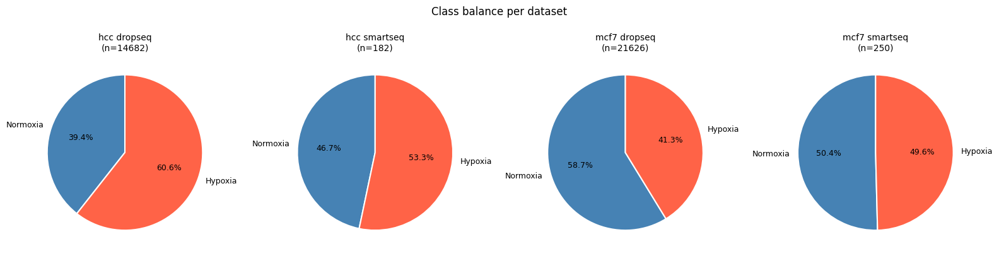

In [31]:
fig, axes = plt.subplots(1, len(datasets_enc), figsize=(16, 4))

for ax, (ds_name, (X, y_enc)) in zip(axes, datasets_enc.items()):
    n_hypo  = y_enc.sum()
    n_normo = (y_enc == 0).sum()
    total   = len(y_enc)

    ax.pie(
        [n_normo, n_hypo],
        labels=["Normoxia", "Hypoxia"],
        colors=["steelblue", "tomato"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        textprops={"fontsize": 9},
    )
    ax.set_title(f"{ds_name.replace('_', ' ')}\n(n={total})", fontsize=10)

fig.suptitle("Class balance per dataset", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

I see that hcc_dropseq and mcf7_dropseq are highly imbalanced in class, so I will use stratified folding in cross validation pipelines

In [32]:
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score
CV_FOLDS     = 5
RANDOM_STATE = 42
SCORERS = {
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1":       make_scorer(f1_score, pos_label=1, zero_division=0),
    "roc_auc":  "roc_auc",
}

<a id="linear-models"></a>
### **Linear Models**


<a id="linear-model-background-models-and-metrics"></a>
##### **Background**
Our goal is to train a **binary classifier** that predicts whether a single cell 
was exposed to hypoxic or normoxic conditions, based on the final feature table built in the downstream analysis.
Each cell is represented by compact latent features, coming from autoencoder or scVI representations, together with engineered gene-program percentages that summarize how much expression comes from hypoxia-associated, normoxia-associated, and neutral gene programs. The label is binary: **Hypoxia (1)** or **Normoxia (0)**.

We focus here on **linear models** — classifiers that learn a decision boundary of 
the form:

$$\hat{y} = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

where $\mathbf{w}$ is a weight vector with one coefficient per input feature, $\mathbf{x}$ is the final feature vector of a cell, and $b$ is a bias term. Linear models are well-suited to this setting because the final tables still contain multiple latent and engineered features for a relatively small number of cells.

All models are trained on **standardised** features (zero mean, unit variance per feature), which is essential for linear models to converge correctly and for regularisation to be applied uniformly across features.

---

##### **Models**
##### *Logistic Regression (L2 regularisation)*
Logistic Regression models the **probability** of a cell being hypoxic:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = 
\frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

The model is trained by minimising the **cross-entropy loss** plus an L2 penalty:

$$\mathcal{L} = -\sum_i \left[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \right] 
+ \frac{1}{2C} \|\mathbf{w}\|_2^2$$

The L2 penalty (ridge) **shrinks all weights toward zero** but keeps all genes in 
the model. The hyperparameter $C$ controls the strength of regularisation: smaller 
$C$ = stronger regularisation.

##### *Logistic Regression (L1 regularisation)*
Same probabilistic framework as L2, but the penalty term is:

$$\mathcal{L} = \text{cross-entropy} + \frac{1}{C} \|\mathbf{w}\|_1$$

The L1 penalty (LASSO) **drives many weights to exactly zero**, performing implicit 
**feature selection**. This is particularly valuable in genomics, where only a 
subset of genes are expected to drive the hypoxia phenotype. The non-zero weights 
identify the most discriminative genes.

##### *Ridge Classifier*
Ridge Classifier applies **L2-regularised linear regression** to a $\{-1, +1\}$ 
encoded target, then thresholds the continuous output at zero:

$$\hat{y} = \text{sign}(\mathbf{w}^T \mathbf{x} + b), \quad 
\mathbf{w} = (\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

Unlike Logistic Regression, it does not produce calibrated probabilities. However, 
it has a **closed-form solution**, making it computationally efficient and 
numerically stable on high-dimensional data.

##### *Linear SVM — L2 penalty, hinge loss*
Support Vector Machines seek the **maximum-margin hyperplane** separating the two 
classes. The Linear SVM with L2 regularisation minimises:

$$\mathcal{L} = \frac{1}{2}\|\mathbf{w}\|_2^2 + C \sum_i \max(0, 1 - y_i 
(\mathbf{w}^T \mathbf{x}_i + b))$$

The **hinge loss** $\max(0, 1 - y_i f(\mathbf{x}_i))$ penalises points that 
fall within the margin or on the wrong side. Support vectors — the cells closest 
to the decision boundary — determine the hyperplane. The SVM does not model 
probabilities directly.

##### *Linear SVM — L1 penalty, squared hinge loss*
Combines L1 regularisation with the squared hinge loss:

$$\mathcal{L} = \frac{1}{C}\|\mathbf{w}\|_1 + \sum_i \max(0, 1 - y_i 
(\mathbf{w}^T \mathbf{x}_i + b))^2$$

As with L1 Logistic Regression, the L1 penalty encourages **sparse solutions**, 
making this variant particularly useful when feature selection is desired alongside 
classification.

##### *SGD Classifier (log loss)*
The SGD Classifier applies **Stochastic Gradient Descent** to minimise a chosen 
loss function online — one sample at a time, rather than over the full dataset. 
With `loss="log_loss"` it is equivalent to Logistic Regression, but trained with 
SGD rather than a full solver. This makes it scalable to very large datasets, but 
**more sensitive to the learning rate and random initialisation**, leading to higher 
variance in cross-validation performance.

##### *Perceptron*
The Perceptron is the simplest linear classifier. It updates weights only when a 
misclassification occurs:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \, y_i \, \mathbf{x}_i 
\quad \text{if } y_i (\mathbf{w}^T \mathbf{x}_i) \leq 0$$

The Perceptron has **no regularisation** and **no probabilistic output**. It 
converges only if the data is linearly separable and is sensitive to feature 
scaling and the order of training examples. In high-dimensional sparse data 
like scRNA-seq, it tends to be less stable than regularised alternatives.

---

##### **Evaluation Metrics**
All metrics are estimated via **Stratified 5-Fold Cross-Validation**: the dataset 
is split into 5 folds, preserving the class ratio in each fold. The model is 
trained on 4 folds and evaluated on the held-out fold, rotating until every fold 
has been used as the test set. The mean and standard deviation across folds are 
reported.

##### *Balanced Accuracy*
$$\text{Balanced Accuracy} = \frac{1}{2}\left(\frac{TP}{TP + FN} + \frac{TN}{TN + FP}\right)$$

Balanced accuracy is the average of sensitivity and specificity. 
It measures how well the classifier performs on both classes separately, giving equal importance to hypoxia and normoxia.
This is more appropriate than standard accuracy when the dataset is imbalanced, 
because a model cannot obtain a high score simply by predicting the majority class. 
A balanced accuracy of 0.5 corresponds to random performance in a binary classification problem, while 1.0 indicates perfect classification.

##### *F1 Score*
$$\text{F1} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}
{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}$$

where:

$$\text{Precision} = \frac{TP}{TP + FP}, \qquad 
\text{Recall} = \frac{TP}{TP + FN}$$

F1 is the **harmonic mean of Precision and Recall**, computed here with Hypoxia 
as the positive class. It penalises both false positives (normoxic cells 
incorrectly predicted as hypoxic) and false negatives (hypoxic cells missed). 
F1 is more informative than accuracy when classes are imbalanced.

##### *ROC-AUC*
The **Receiver Operating Characteristic** curve plots True Positive Rate (Recall) 
against False Positive Rate at all possible classification thresholds. The **Area 
Under the Curve (AUC)** summarises this into a single number:

- AUC = 1.0 → perfect separation between classes
- AUC = 0.5 → random classifier (no discriminative power)
- AUC < 0.5 → worse than random

AUC measures the classifier's ability to **rank** hypoxic cells above normoxic 
cells, regardless of the chosen threshold. It is **threshold-independent** and 
robust to class imbalance, making it the most reliable single metric for comparing 
classifiers across datasets with different class compositions.

For models without `predict_proba` (Ridge Classifier, Linear SVM), AUC is computed 
from the raw decision function scores rather than probabilities — this is 
mathematically equivalent and equally valid.

---

<a id="summary-table"></a>
### Summary Table

| Model | Loss | Regularisation | Produces probabilities | Feature selection |
|---|---|---|---|---|
| Logistic Regression L2 | Cross-entropy | L2 (ridge) | ✓ | ✗ |
| Logistic Regression L1 | Cross-entropy | L1 (LASSO) | ✓ | ✓ |
| Ridge Classifier | Least squares | L2 (ridge) | ✗ | ✗ |
| Linear SVM L2 | Hinge | L2 (ridge) | ✗ | ✗ |
| Linear SVM L1 | Squared hinge | L1 (LASSO) | ✗ | ✓ |
| SGD Classifier | Log loss | L2 (default) | ✓ | ✗ |
| Perceptron | Perceptron | None | ✗ | ✗ |




Full results table:


,dataset,classifier,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,hcc_dropseq,Logistic Regression\n(L2),0.945,0.002,0.957,0.001,0.987,0.001
1,hcc_dropseq,Logistic Regression\n(L1),0.945,0.002,0.957,0.001,0.987,0.001
2,hcc_dropseq,Ridge Classifier,0.946,0.002,0.956,0.002,0.987,0.001
3,hcc_dropseq,"Linear SVM\n(L2, hinge)",0.945,0.002,0.957,0.001,0.987,0.001
4,hcc_dropseq,"Linear SVM\n(L1, squared)",0.945,0.002,0.957,0.001,0.987,0.001
5,hcc_dropseq,SGD Classifier\n(log loss),0.943,0.002,0.955,0.001,0.986,0.001
6,hcc_dropseq,Perceptron,0.912,0.012,0.931,0.008,0.973,0.005
7,hcc_smartseq,Logistic Regression\n(L2),0.978,0.027,0.979,0.025,0.997,0.006
8,hcc_smartseq,Logistic Regression\n(L1),0.990,0.020,0.989,0.021,1.000,0.000
9,hcc_smartseq,Ridge Classifier,0.984,0.013,0.984,0.013,0.998,0.004


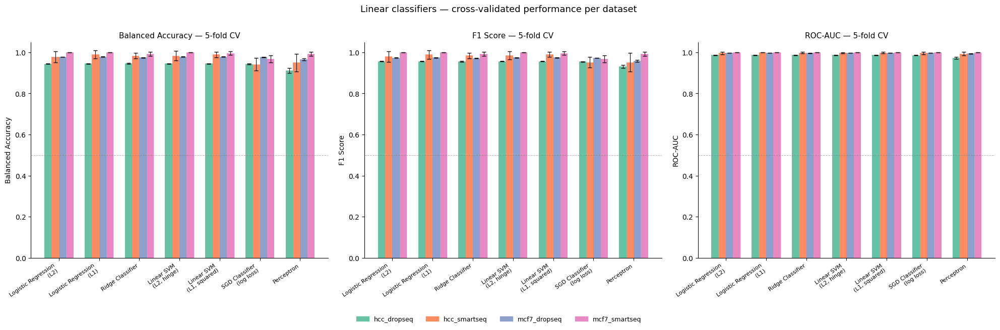

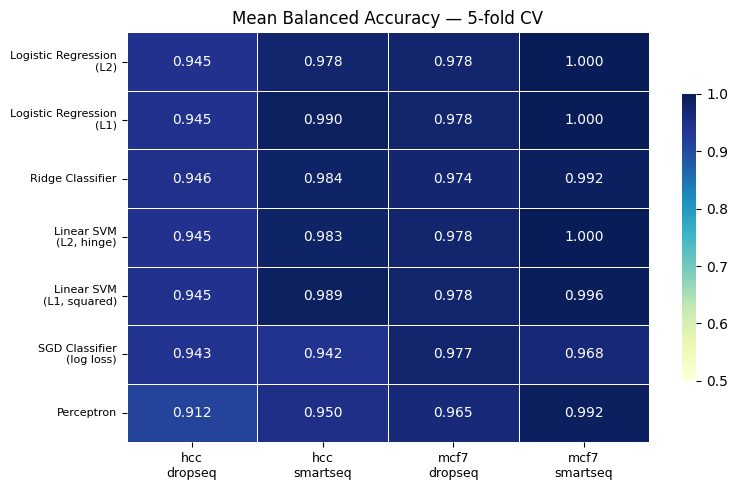

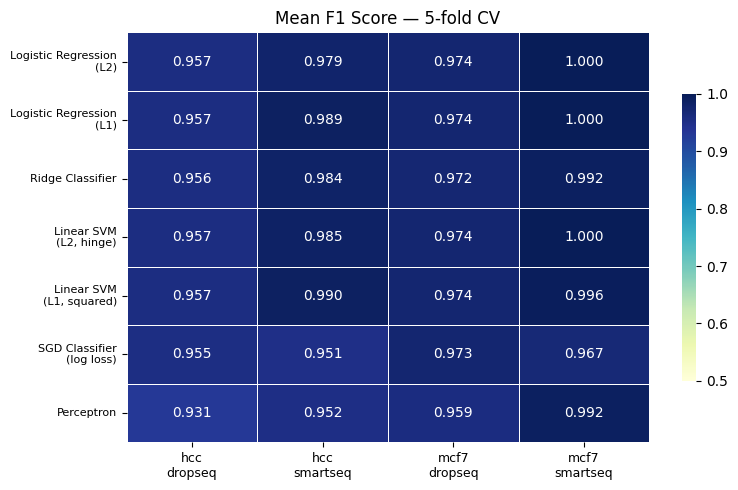

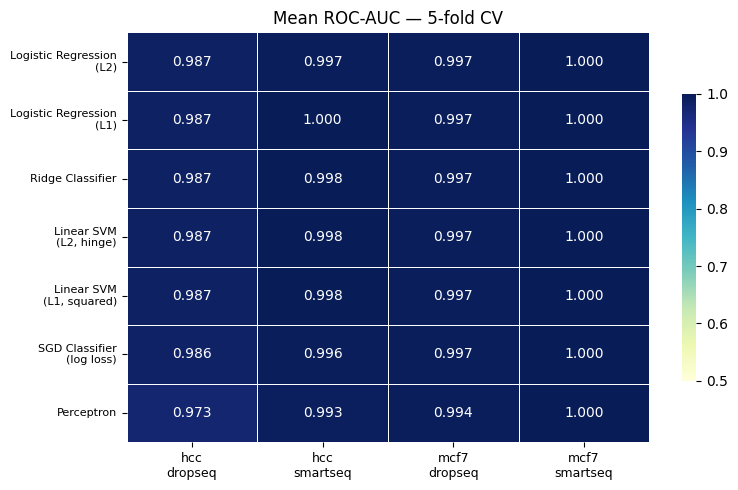

<Figure size 640x480 with 0 Axes>

In [33]:
import matplotlib.patches as mpatches

from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier,
    SGDClassifier, Perceptron
)
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

classifiers = {
    "Logistic Regression\n(L2)": LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs",
        random_state=RANDOM_STATE
    ),
    "Logistic Regression\n(L1)": LogisticRegression(
        max_iter=1000, C=1.0, solver="liblinear",
        l1_ratio=1, random_state=RANDOM_STATE        # l1_ratio=1 replaces penalty='l1' in sklearn 1.8+
    ),
    "Ridge Classifier": RidgeClassifier(),
    "Linear SVM\n(L2, hinge)": LinearSVC(
        max_iter=2000, C=1.0,
        random_state=RANDOM_STATE
    ),
    "Linear SVM\n(L1, squared)": LinearSVC(
        max_iter=2000, C=1.0, penalty="l1", dual=False,
        random_state=RANDOM_STATE
    ),
    "SGD Classifier\n(log loss)": SGDClassifier(
        loss="log_loss", max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Perceptron": Perceptron(
        max_iter=1000, random_state=RANDOM_STATE
    ),
}

cv      = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = []

for ds_name, (X, y_enc) in datasets_enc.items():
    
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    clf),
        ])
        
        cv_out = cross_validate(
            pipe, X, y_enc,
            cv=cv,
            scoring=SCORERS,
            return_train_score=False,
            n_jobs=-1,
        )
        
        results.append({
            "dataset":       ds_name,
            "classifier":    clf_name,
            "balanced_accuracy_mean": cv_out["test_balanced_accuracy"].mean(),
            "balanced_accuracy_std":  cv_out["test_balanced_accuracy"].std(),
            "f1_mean":       cv_out["test_f1"].mean(),
            "f1_std":        cv_out["test_f1"].std(),
            "roc_auc_mean":  cv_out["test_roc_auc"].mean(),
            "roc_auc_std":   cv_out["test_roc_auc"].std(),
        })

results_df = pd.DataFrame(results)
print("\n\nFull results table:")
display(results_df.round(3))

METRICS       = ["balanced_accuracy_mean", "f1_mean", "roc_auc_mean"]
METRIC_LABELS = ["Balanced Accuracy", "F1 Score", "ROC-AUC"]
DS_NAMES      = list(datasets.keys())
CLF_NAMES     = list(classifiers.keys())
N_CLF         = len(CLF_NAMES)

palette   = sns.color_palette("Set2", len(DS_NAMES))
ds_colors = dict(zip(DS_NAMES, palette))

# ── Figure 1: grouped bar chart — all three metrics ──

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for ax, metric, label in zip(axes, METRICS, METRIC_LABELS):
    x       = np.arange(N_CLF)
    width   = 0.18
    offsets = np.linspace(
        -(len(DS_NAMES) - 1) / 2,
         (len(DS_NAMES) - 1) / 2,
        len(DS_NAMES)
    ) * width
    
    for i, ds in enumerate(DS_NAMES):
        subset = (results_df[results_df["dataset"] == ds]
                  .set_index("classifier")
                  .reindex(CLF_NAMES))
        
        ax.bar(
            x + offsets[i],
            subset[metric],
            width=width,
            color=ds_colors[ds],
            yerr=subset[metric.replace("mean", "std")],
            capsize=3,
            error_kw={"linewidth": 0.8},
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(CLF_NAMES, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} — {CV_FOLDS}-fold CV", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=ds_colors[ds], label=ds) for ds in DS_NAMES]
fig.legend(handles=handles, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.06), fontsize=9, frameon=False)
fig.suptitle("Linear classifiers — cross-validated performance per dataset",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# ── Figure 2: heatmaps — one per metric ──

for metric, label in zip(METRICS, METRIC_LABELS):
    pivot = (results_df
             .pivot(index="classifier", columns="dataset", values=metric)
             .reindex(CLF_NAMES))
    pivot.columns = [c.replace("_", "\n") for c in pivot.columns]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
                vmin=0.5, vmax=1.0, linewidths=0.4,
                ax=ax, cbar_kws={"shrink": 0.7})
    ax.set_title(f"Mean {label} — {CV_FOLDS}-fold CV", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)
    plt.tight_layout()
    plt.show()

fig.suptitle("Balanced Accuracy (mean ± std, 5-fold CV) by dataset", fontsize=12)
plt.tight_layout()
plt.show()

BEST MODEL PER DATASET

hcc_dropseq
─────────────────────────────────────────────
  Best Balanced Accuracy → Ridge Classifier                    0.946 ± 0.002
  Best F1 Score     → Linear SVM (L2, hinge)              0.957 ± 0.001
  Best ROC-AUC      → Linear SVM (L2, hinge)              0.987 ± 0.001

  ★  Overall best (mean rank): Linear SVM (L2, hinge)

hcc_smartseq
─────────────────────────────────────────────
  Best Balanced Accuracy → Logistic Regression (L1)            0.990 ± 0.020
  Best F1 Score     → Linear SVM (L1, squared)            0.990 ± 0.013
  Best ROC-AUC      → Logistic Regression (L1)            1.000 ± 0.000

  ★  Overall best (mean rank): Logistic Regression (L1)

mcf7_dropseq
─────────────────────────────────────────────
  Best Balanced Accuracy → Linear SVM (L2, hinge)              0.978 ± 0.001
  Best F1 Score     → Linear SVM (L2, hinge)              0.974 ± 0.001
  Best ROC-AUC      → Logistic Regression (L2)            0.997 ± 0.001

  ★  Overall best (mea

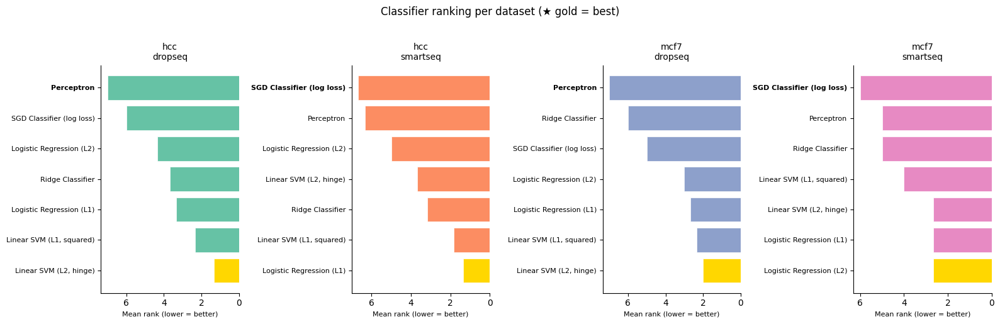

In [34]:
# ── Best model per dataset ──

metrics = {
    "balanced_accuracy_mean": "Balanced Accuracy",
    "f1_mean":       "F1 Score",
    "roc_auc_mean":  "ROC-AUC",
}

print("=" * 65)
print("BEST MODEL PER DATASET")
print("=" * 65)
best_rows = []

for ds_name in DS_NAMES:
    subset = results_df[results_df["dataset"] == ds_name]
    print(f"\n{ds_name}")
    print("─" * 45)
    
    votes = {}  # count how many metrics each classifier wins
    
    for metric, label in metrics.items():
        best_idx  = subset[metric].idxmax()
        best_clf  = subset.loc[best_idx, "classifier"].replace("\n", " ")
        best_val  = subset.loc[best_idx, metric]
        best_std  = subset.loc[best_idx, metric.replace("mean", "std")]
        
        print(f"  Best {label:<12} → {best_clf:<35} {best_val:.3f} ± {best_std:.3f}")
        
        votes[best_clf] = votes.get(best_clf, 0) + 1
        best_rows.append({
            "dataset":    ds_name,
            "metric":     label,
            "classifier": best_clf,
            "value":      best_val,
            "std":        best_std,
        })
    
    # overall winner = classifier with most metric wins;
    # tie-break by mean rank across all three metrics
    overall = subset.copy()
    overall["mean_rank"] = (
        overall["balanced_accuracy_mean"].rank(ascending=False) +
        overall["f1_mean"].rank(ascending=False) +
        overall["roc_auc_mean"].rank(ascending=False)
    )
    winner_idx = overall["mean_rank"].idxmin()
    winner     = overall.loc[winner_idx, "classifier"].replace("\n", " ")
    
    print(f"\n  ★  Overall best (mean rank): {winner}")

print("\n" + "=" * 65)

# ── Visual: heatmap of mean rank per classifier per dataset ──

fig, axes = plt.subplots(1, len(DS_NAMES), figsize=(16, 5))

for ax, ds_name in zip(axes, DS_NAMES):
    subset = results_df[results_df["dataset"] == ds_name].copy()
    subset["clf_short"] = subset["classifier"].str.replace("\n", " ")
    
    # compute mean rank (lower = better)
    subset["mean_rank"] = (
        subset["balanced_accuracy_mean"].rank(ascending=False) +
        subset["f1_mean"].rank(ascending=False) +
        subset["roc_auc_mean"].rank(ascending=False)
    ) / 3
    
    subset = subset.sort_values("mean_rank")
    
    colors = ["gold" if i == 0 else ds_colors[ds_name]
              for i in range(len(subset))]
    
    ax.barh(subset["clf_short"], subset["mean_rank"],
            color=colors, edgecolor="white", linewidth=0.5)
    ax.invert_xaxis()   # lower rank = better = further right
    ax.set_title(ds_name.replace("_", "\n"), fontsize=10)
    ax.set_xlabel("Mean rank (lower = better)", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # star the winner
    ax.get_yticklabels()[-1].set_fontweight("bold")

fig.suptitle("Classifier ranking per dataset (★ gold = best)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

All seven linear classifiers successfully learned to discriminate hypoxic from 
normoxic cells across all four datasets, with cross-validated accuracy ranging 
from 0.916 to 1.000, F1 from 0.931 to 1.000, and ROC-AUC from 0.973 to 1.000, 
demonstrating that hypoxia induces a transcriptional signature strong enough to 
be detected by simple linear decision boundaries in the 3000-gene feature space. 
Performance varied systematically across datasets in a pattern consistent with 
both technology and cell line biology: SmartSeq datasets were easier to classify 
than their DropSeq counterparts within the same cell line (e.g. mcf7_smartseq 
achieved near-perfect scores across all classifiers, while mcf7_dropseq was 
slightly lower), reflecting the deeper per-cell sequencing depth and lower 
sparsity of SmartSeq relative to the noisier, sparser DropSeq profiles. 
Similarly, MCF7 datasets were consistently more classifiable than HCC1806 datasets, 
which may reflect differences in the strength or consistency of the transcriptional 
response to hypoxia between the two cell lines, in line with their known differences 
in invasiveness. Among classifiers, Logistic Regression (L1 and L2), Ridge 
Classifier, and Linear SVM performed near-identically across all datasets and 
metrics, suggesting the data is robustly linearly separable and that the choice 
of regularisation has little practical impact in this setting; the Perceptron was 
the only consistent outlier, showing lower accuracy and higher cross-validation 
variance due to its lack of regularisation and sensitivity to high-dimensional 
sparse inputs. The consistently high ROC-AUC scores — above 0.987 even on the 
hardest dataset — confirm that classifiers separate the two classes cleanly in 
terms of ranking, independently of the chosen decision threshold.

<a id="non-linear-models"></a>
### **Non-Linear Models**


<a id="non-linear-classifiers-for-hypoxia-classification"></a>
##### **Non-Linear Classifiers for Hypoxia Classification**
##### **Background**
Linear classifiers assume that the two classes can be separated by a flat 
hyperplane in the feature space. While this assumption proved sufficient in the 
previous section, it is not always guaranteed to hold — particularly in biological 
data where gene interactions, non-additive effects, and complex regulatory 
relationships may produce decision boundaries of arbitrary shape. **Non-linear 
classifiers** relax this assumption, learning boundaries that can curve, branch, 
and wrap around the data in ways that linear models cannot.

We evaluate here five families of non-linear models: K-Nearest Neighbours, 
Decision Trees, Random Forests, Gradient Boosting (sklearn), XGBoost, and 
Multilayer Perceptrons. As before, all models are embedded in a pipeline with 
**StandardScaler** applied upstream — essential for distance-based methods (KNN) 
and neural networks (MLP), and harmless for tree-based methods.

---

##### **Models**
##### *K-Nearest Neighbours (KNN)*
KNN is a **lazy, instance-based learner**: it stores the entire training set and 
classifies a new cell by majority vote among its $k$ nearest neighbours in the 
feature space:

$$\hat{y} = \underset{c}{\arg\max} \sum_{i \in \mathcal{N}_k(\mathbf{x})} 
\mathbf{1}[y_i = c]$$

where $\mathcal{N}_k(\mathbf{x})$ denotes the $k$ training points closest to 
$\mathbf{x}$ under Euclidean distance. KNN has **no training phase** and no 
explicit model parameters — the entire computation happens at prediction time. 
The choice of $k$ controls the bias-variance trade-off: small $k$ (e.g. $k=5$) 
produces a flexible, low-bias but high-variance boundary; large $k$ (e.g. $k=15$) 
smooths the boundary at the cost of increased bias. KNN is sensitive to the 
**curse of dimensionality**: in high-dimensional spaces like the 3000-gene feature 
space, Euclidean distances become increasingly uniform across points, weakening 
the notion of "nearest" neighbour. Dimensionality reduction (e.g. PCA) before 
applying KNN can partially mitigate this.

##### *Decision Tree*
A Decision Tree recursively partitions the feature space by choosing at each 
internal node the gene $j$ and threshold $t$ that best splits the data:

$$\text{split: } x_j \leq t \quad \text{vs} \quad x_j > t$$

The best split is chosen to maximise the **Gini impurity reduction** (or 
equivalently, information gain):

$$\text{Gini}(S) = 1 - \sum_c p_c^2$$

where $p_c$ is the proportion of class $c$ in node $S$. The tree grows until 
all leaves are pure or a stopping criterion (e.g. `max_depth`) is reached. 
Decision trees are **highly interpretable** — the path from root to leaf is a 
human-readable set of gene expression rules. However, they are prone to 
**overfitting**: an unconstrained tree memorises the training data perfectly but 
generalises poorly. Limiting `max_depth` is the primary regularisation strategy.

##### *Random Forest*
Random Forest addresses the overfitting of individual trees by building an 
**ensemble of $B$ decorrelated trees** and averaging their predictions:

$$\hat{y} = \text{majority vote of } \{\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_B\}$$

Each tree is trained on a **bootstrap sample** of the training data (bagging), 
and at each split only a random subset of $\sqrt{p}$ features (genes) is 
considered. These two sources of randomness decorrelate the trees, dramatically 
reducing variance relative to a single tree while keeping bias low. Random Forest 
is robust to high dimensionality and provides a natural measure of **feature 
importance** (mean decrease in Gini impurity across all trees), which can be 
used to identify the genes most informative for the hypoxia phenotype.

##### *Gradient Boosting*
Gradient Boosting builds an ensemble **sequentially** rather than in parallel. 
Each new tree is trained to correct the residual errors of the current ensemble 
by fitting the negative gradient of the loss function:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

where $h_m$ is a shallow tree fitted to the residuals of $F_{m-1}$ and $\eta$ 
is the learning rate. Gradient Boosting typically achieves higher accuracy than 
Random Forest by progressively focusing on hard-to-classify examples, but it is 
**more sensitive to overfitting** and slower to train, as trees cannot be built 
in parallel.

##### *XGBoost*
XGBoost (Extreme Gradient Boosting) is an optimised and regularised 
implementation of gradient boosting. It extends the standard framework with:

- An explicit **L1 and L2 regularisation** term on the leaf weights, reducing 
  overfitting
- **Histogram-based approximate split finding**, which is dramatically faster 
  than exact splitting on large feature sets
- **Column subsampling** (`colsample_bytree`): at each tree, only a random 
  fraction of genes is considered, further decorrelating the ensemble
- Built-in **parallelism** across splits within a tree

The objective minimised at each boosting step is:

$$\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_m \Omega(h_m), \quad 
\Omega(h) = \gamma T + \frac{1}{2}\lambda \|\mathbf{w}\|^2$$

where $T$ is the number of leaves, $\mathbf{w}$ are the leaf weights, $\gamma$ 
penalises tree complexity, and $\lambda$ is the L2 weight penalty. In practice, 
XGBoost consistently outperforms sklearn's GradientBoostingClassifier in both 
speed and accuracy on tabular data.

##### *Multilayer Perceptron (MLP)*
The MLP is a **feedforward neural network** with one or more hidden layers of 
neurons. Each layer applies a linear transformation followed by a non-linear 
activation function (ReLU by default in sklearn):

$$\mathbf{h}^{(l)} = \sigma\left(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + 
\mathbf{b}^{(l)}\right)$$

The final layer applies a softmax (or sigmoid for binary classification) to 
produce class probabilities. The network is trained end-to-end by 
**backpropagation**, minimising cross-entropy loss via Adam or SGD. The universal 
approximation theorem guarantees that an MLP with a single hidden layer can 
approximate any continuous function given sufficient neurons — making it 
theoretically the most expressive model in this comparison. In practice, MLPs 
are sensitive to **hyperparameter choices** (architecture, learning rate, 
regularisation) and require more data to generalise well than tree-based ensembles. 
We test two architectures: a single hidden layer of 100 neurons and two hidden 
layers of 100 and 50 neurons.

---

##### **Evaluation Metrics**
The same three metrics used in the linear section are applied here, under 
identical **Stratified 5-Fold Cross-Validation**. See the linear classifier 
section for full definitions. Briefly:

- **Accuracy**: proportion of correctly classified cells — interpretable but 
  sensitive to class imbalance.
- **F1 Score**: harmonic mean of Precision and Recall with Hypoxia as the 
  positive class — more informative than accuracy under imbalance.
- **ROC-AUC**: area under the ROC curve — threshold-independent measure of 
  class separability, robust to imbalance.

---

<a id="summary-table-2"></a>
### Summary Table

| Model | Decision boundary | Interpretable | Feature importance | Probabilistic output |
|---|---|---|---|---|
| KNN (k=5) | Non-parametric, local | ✗ | ✗ | ✓ (vote fraction) |
| KNN (k=15) | Non-parametric, smoother | ✗ | ✗ | ✓ (vote fraction) |
| Decision Tree | Axis-aligned splits | ✓ | ✓ (Gini) | ✓ |
| Random Forest | Ensemble of trees | Partial | ✓ (mean Gini) | ✓ |
| Gradient Boosting | Sequential ensemble | ✗ | ✓ | ✓ |
| XGBoost | Regularised sequential ensemble | ✗ | ✓ | ✓ |
| MLP (1 layer) | Smooth non-linear | ✗ | ✗ | ✓ |
| MLP (2 layers) | Deeper non-linear | ✗ | ✗ | ✓ |


/Users/asca/myenv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/asca/myenv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/asca/myenv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/asca/myenv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarnin



Full results table:


,dataset,classifier,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,hcc_dropseq,KNN\n(k=5),0.928,0.004,0.937,0.005,0.972,0.002
1,hcc_dropseq,KNN\n(k=15),0.938,0.004,0.945,0.004,0.984,0.001
2,hcc_dropseq,Decision Tree,0.848,0.004,0.878,0.004,0.847,0.009
3,hcc_dropseq,Random Forest,0.916,0.007,0.937,0.005,0.978,0.002
4,hcc_dropseq,Gradient Boosting,0.928,0.002,0.945,0.002,0.983,0.002
5,hcc_dropseq,XGBoost,0.936,0.002,0.950,0.003,0.986,0.001
6,hcc_dropseq,MLP\n(1 hidden layer),0.944,0.003,0.956,0.002,0.988,0.001
7,hcc_dropseq,MLP\n(2 hidden layers),0.944,0.004,0.955,0.003,0.988,0.002
8,hcc_smartseq,KNN\n(k=5),0.952,0.053,0.952,0.053,0.971,0.030
9,hcc_smartseq,KNN\n(k=15),0.941,0.047,0.942,0.047,0.982,0.019


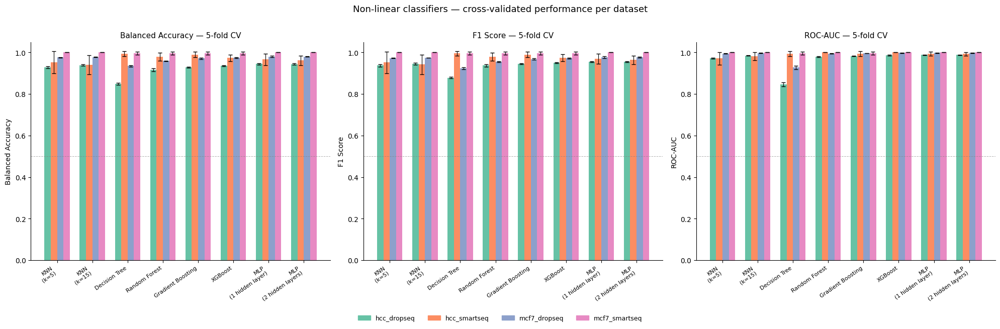

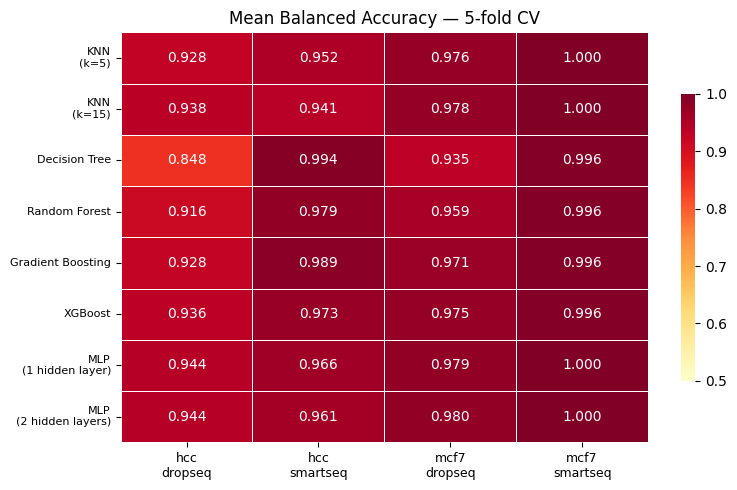

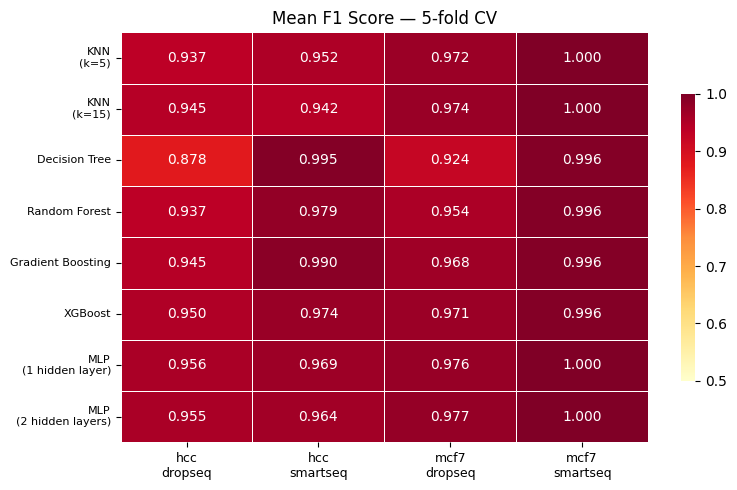

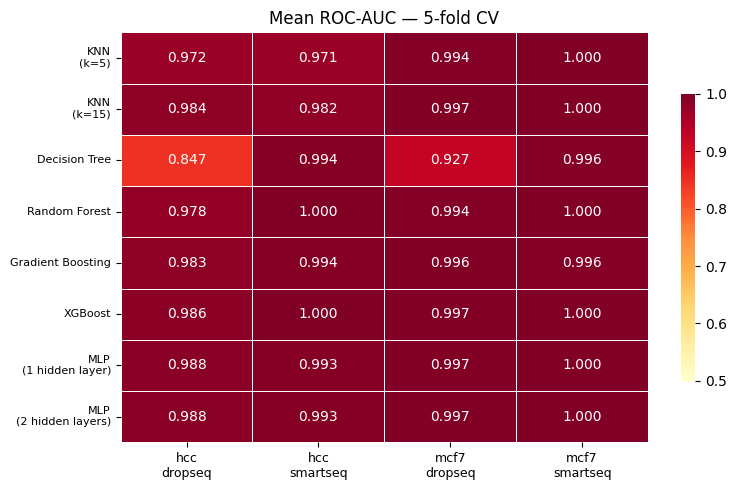

In [35]:
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network    import MLPClassifier
from xgboost import XGBClassifier

classifiers_nl = {
    "KNN\n(k=5)": KNeighborsClassifier(
        n_neighbors=5, metric="euclidean", n_jobs=-1
    ),
    "KNN\n(k=15)": KNeighborsClassifier(
        n_neighbors=15, metric="euclidean", n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "MLP\n(1 hidden layer)": MLPClassifier(
        hidden_layer_sizes=(100,), max_iter=500,
        random_state=RANDOM_STATE
    ),
    "MLP\n(2 hidden layers)": MLPClassifier(
        hidden_layer_sizes=(100, 50), max_iter=500,
        random_state=RANDOM_STATE
    ),
}

cv         = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results_nl = []

for ds_name, (X, y_enc) in datasets_enc.items():
    for clf_name, clf in classifiers_nl.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    clf),
        ])

        cv_out = cross_validate(
            pipe, X, y_enc,
            cv=cv,
            scoring=SCORERS,
            return_train_score=False,
            n_jobs=-1,
        )

        results_nl.append({
            "dataset":       ds_name,
            "classifier":    clf_name,
            "balanced_accuracy_mean": cv_out["test_balanced_accuracy"].mean(),
            "balanced_accuracy_std":  cv_out["test_balanced_accuracy"].std(),
            "f1_mean":       cv_out["test_f1"].mean(),
            "f1_std":        cv_out["test_f1"].std(),
            "roc_auc_mean":  cv_out["test_roc_auc"].mean(),
            "roc_auc_std":   cv_out["test_roc_auc"].std(),
        })

results_nl_df = pd.DataFrame(results_nl)
print("\n\nFull results table:")
display(results_nl_df.round(3))

METRICS       = ["balanced_accuracy_mean", "f1_mean", "roc_auc_mean"]
METRIC_LABELS = ["Balanced Accuracy", "F1 Score", "ROC-AUC"]
DS_NAMES      = list(datasets_enc.keys())
CLF_NAMES_NL  = list(classifiers_nl.keys())
N_CLF_NL      = len(CLF_NAMES_NL)

palette   = sns.color_palette("Set2", len(DS_NAMES))
ds_colors = dict(zip(DS_NAMES, palette))

# ── Figure 1: grouped bar chart ──

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for ax, metric, label in zip(axes, METRICS, METRIC_LABELS):
    x       = np.arange(N_CLF_NL)
    width   = 0.18
    offsets = np.linspace(
        -(len(DS_NAMES) - 1) / 2,
         (len(DS_NAMES) - 1) / 2,
        len(DS_NAMES)
    ) * width

    for i, ds in enumerate(DS_NAMES):
        subset = (results_nl_df[results_nl_df["dataset"] == ds]
                  .set_index("classifier")
                  .reindex(CLF_NAMES_NL))

        ax.bar(
            x + offsets[i],
            subset[metric],
            width=width,
            color=ds_colors[ds],
            yerr=subset[metric.replace("mean", "std")],
            capsize=3,
            error_kw={"linewidth": 0.8},
        )

    ax.set_xticks(x)
    ax.set_xticklabels(CLF_NAMES_NL, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} — {CV_FOLDS}-fold CV", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=ds_colors[ds], label=ds) for ds in DS_NAMES]
fig.legend(handles=handles, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.06), fontsize=9, frameon=False)
fig.suptitle("Non-linear classifiers — cross-validated performance per dataset",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Figure 2: heatmaps ──

for metric, label in zip(METRICS, METRIC_LABELS):
    pivot = (results_nl_df
             .pivot(index="classifier", columns="dataset", values=metric)
             .reindex(CLF_NAMES_NL))
    pivot.columns = [c.replace("_", "\n") for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd",
                vmin=0.5, vmax=1.0, linewidths=0.4,
                ax=ax, cbar_kws={"shrink": 0.7})
    ax.set_title(f"Mean {label} — {CV_FOLDS}-fold CV", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)
    plt.tight_layout()
    plt.show()

BEST MODEL PER DATASET

hcc_dropseq
─────────────────────────────────────────────
  Best Balanced Accuracy → MLP (1 hidden layer)                0.944 ± 0.003
  Best F1 Score     → MLP (1 hidden layer)                0.956 ± 0.002
  Best ROC-AUC      → MLP (1 hidden layer)                0.988 ± 0.001

  ★  Overall best (mean rank): MLP (1 hidden layer)

hcc_smartseq
─────────────────────────────────────────────
  Best Balanced Accuracy → Decision Tree                       0.994 ± 0.012
  Best F1 Score     → Decision Tree                       0.995 ± 0.010
  Best ROC-AUC      → Random Forest                       1.000 ± 0.000

  ★  Overall best (mean rank): Decision Tree

mcf7_dropseq
─────────────────────────────────────────────
  Best Balanced Accuracy → MLP (2 hidden layers)               0.980 ± 0.001
  Best F1 Score     → MLP (2 hidden layers)               0.977 ± 0.002
  Best ROC-AUC      → MLP (1 hidden layer)                0.997 ± 0.001

  ★  Overall best (mean rank): MLP 

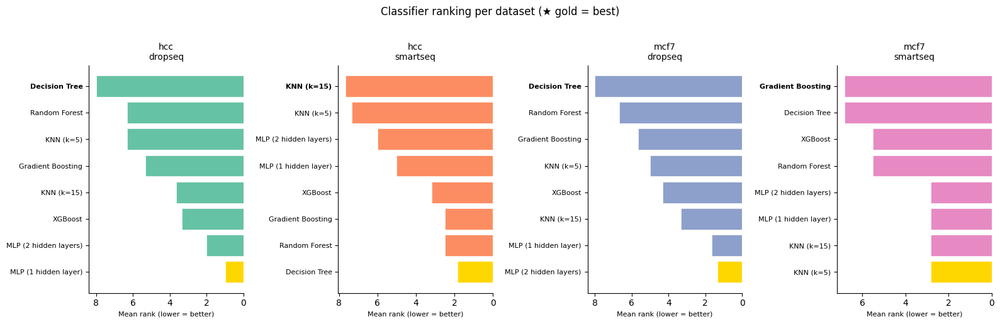

In [36]:
# ── Best model per dataset ──

metrics = {
    "balanced_accuracy_mean": "Balanced Accuracy",
    "f1_mean":       "F1 Score",
    "roc_auc_mean":  "ROC-AUC",
}

print("=" * 65)
print("BEST MODEL PER DATASET")
print("=" * 65)
best_rows = []

for ds_name in DS_NAMES:
    subset = results_nl_df[results_nl_df["dataset"] == ds_name]
    print(f"\n{ds_name}")
    print("─" * 45)
    
    votes = {}  # count how many metrics each classifier wins
    
    for metric, label in metrics.items():
        best_idx  = subset[metric].idxmax()
        best_clf  = subset.loc[best_idx, "classifier"].replace("\n", " ")
        best_val  = subset.loc[best_idx, metric]
        best_std  = subset.loc[best_idx, metric.replace("mean", "std")]
        
        print(f"  Best {label:<12} → {best_clf:<35} {best_val:.3f} ± {best_std:.3f}")
        
        votes[best_clf] = votes.get(best_clf, 0) + 1
        best_rows.append({
            "dataset":    ds_name,
            "metric":     label,
            "classifier": best_clf,
            "value":      best_val,
            "std":        best_std,
        })
    
    # overall winner = classifier with most metric wins;
    # tie-break by mean rank across all three metrics
    overall = subset.copy()
    overall["mean_rank"] = (
        overall["balanced_accuracy_mean"].rank(ascending=False) +
        overall["f1_mean"].rank(ascending=False) +
        overall["roc_auc_mean"].rank(ascending=False)
    )
    winner_idx = overall["mean_rank"].idxmin()
    winner     = overall.loc[winner_idx, "classifier"].replace("\n", " ")
    
    print(f"\n  ★  Overall best (mean rank): {winner}")

print("\n" + "=" * 65)

# ── Visual: heatmap of mean rank per classifier per dataset ──

fig, axes = plt.subplots(1, len(DS_NAMES), figsize=(16, 5))

for ax, ds_name in zip(axes, DS_NAMES):
    subset = results_nl_df[results_nl_df["dataset"] == ds_name].copy()
    subset["clf_short"] = subset["classifier"].str.replace("\n", " ")
    
    # compute mean rank (lower = better)
    subset["mean_rank"] = (
        subset["balanced_accuracy_mean"].rank(ascending=False) +
        subset["f1_mean"].rank(ascending=False) +
        subset["roc_auc_mean"].rank(ascending=False)
    ) / 3
    
    subset = subset.sort_values("mean_rank")
    
    colors = ["gold" if i == 0 else ds_colors[ds_name]
              for i in range(len(subset))]
    
    ax.barh(subset["clf_short"], subset["mean_rank"],
            color=colors, edgecolor="white", linewidth=0.5)
    ax.invert_xaxis()   # lower rank = better = further right
    ax.set_title(ds_name.replace("_", "\n"), fontsize=10)
    ax.set_xlabel("Mean rank (lower = better)", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # star the winner
    ax.get_yticklabels()[-1].set_fontweight("bold")

fig.suptitle("Classifier ranking per dataset (★ gold = best)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Non-linear classifiers were evaluated on the same four datasets and under 
identical cross-validation conditions as the linear models. The key finding is 
that **non-linear models do not uniformly outperform linear ones** — performance 
remains high across the board (accuracy 0.916–1.000, AUC 0.970–1.000), 
confirming that the hypoxia transcriptional signature is largely linearly 
separable. However, the non-linear section reveals important dataset-specific 
patterns that were masked by the uniformity of linear classifier results.

Unlike the linear section — where all regularised models performed near-identically 
— the non-linear section shows **substantial disagreement between models and 
across datasets**. No single classifier wins on all four datasets: MLP (1 hidden 
layer) is the overall best on hcc_dropseq, Decision Tree on hcc_smartseq, and KNN 
on mcf7_smartseq. This variability suggests that the optimal inductive bias 
depends on the specific dataset's noise level, sample size, and feature structure.

The most striking result is the **Decision Tree's opposite behaviour across 
datasets**: it ranks first on hcc_smartseq (accuracy 0.994, F1 0.995) but last 
on hcc_dropseq. This is consistent with the known properties of the two 
technologies — SmartSeq produces clean, dense expression profiles where 
axis-aligned gene expression thresholds are sufficient to separate classes, 
while DropSeq's sparse and noisy profiles make single-threshold splits unreliable 
and prone to overfitting. This result highlights a fundamental point: 
**model selection cannot be decoupled from data quality**.

MLP classifiers performed consistently well on DropSeq datasets (hcc_dropseq and 
mcf7_dropseq), where they ranked among the top models. This may reflect the 
ability of neural networks to learn **robust non-linear combinations of weakly 
informative features** — useful when individual gene measurements are noisy, as 
is common in DropSeq. Notably, the two-layer MLP did not consistently outperform 
the one-layer MLP, suggesting that the added depth is not necessary given the 
dataset sizes available here.

Random Forest and XGBoost produced solid but rarely top-ranked results, typically 
occupying the middle of the ranking. Their ROC-AUC scores were consistently high 
(≥ 0.990), confirming good class separability, but their accuracy and F1 were 
occasionally lower than simpler models. This is likely due to **variance in the 
ensemble predictions** on small datasets — both methods benefit from larger 
training sets to fully exploit their capacity. Of the two, XGBoost was 
computationally faster and showed slightly more stable cross-validation scores, 
consistent with its regularisation framework.

KNN showed the expected sensitivity to the choice of $k$: $k=5$ outperformed 
$k=15$ on the SmartSeq datasets (where local structure is more reliable), while 
$k=15$ was more stable on DropSeq datasets (where smoothing helps counteract 
noise). This is a direct consequence of the bias-variance trade-off in 
distance-based methods. Both variants are likely affected by the curse of 
dimensionality in the full 3000-gene space; applying KNN after PCA reduction 
would be an informative follow-up experiment.

Comparing the non-linear results to the linear section, the gains from 
non-linearity are **modest and inconsistent**: the best non-linear model on each 
dataset achieves at most 0.003–0.010 higher accuracy than the best linear model, 
a difference that is within one standard deviation of the cross-validation 
estimates. This is an important result in itself — it implies that the hypoxia 
response induces a **predominantly linear transcriptional shift** in both cell 
lines and both technologies, and that the complexity of non-linear models is not 
warranted here given the sample sizes available. From a practical standpoint, 
linear models — in particular Logistic Regression L1 — remain the preferred 
choice, as they match non-linear performance while offering interpretability and 
feature selection at no additional computational cost.

<a id="hyperparameter-tuning"></a>
### **Hyperparameter Tuning**
For each of the four datasets we now have **two candidate models** — the best linear and the best non-linear classifier identified by mean-rank in the previous sections. Those models were trained with default hyperparameters; here we systematically search for better configurations.

<a id="methodology"></a>
#### *Methodology*
For every *(dataset, model)* pair we run a `RandomizedSearchCV` with the following protocol:

- **CV strategy** &nbsp;`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` — same folding strategy as the previous sections, so that class proportions are preserved in every fold. This matters because `hcc_dropseq` and `mcf7_dropseq` are strongly imbalanced.
- **Search budget** &nbsp;`n_iter = 20` configurations sampled per model. Random sampling from continuous distributions (`loguniform` for parameters that span several orders of magnitude such as `C`, `alpha`, `learning_rate_init`, `tol`) is more efficient than a grid in moderate-to-high-dimensional spaces.
- **Pipeline** &nbsp;`StandardScaler` lives *inside* the `Pipeline` so that the scaler is fit only on the training fold at every CV split — no data leakage. The Decision Tree pipeline omits scaling because trees are scale-invariant.
- **Scoring** &nbsp;the same three metrics as before — *balanced accuracy*, *F1*, and *ROC-AUC*. Multi-metric scoring (`SCORERS` dict) lets the search compute all three for every candidate.
- **Model-selection criterion** &nbsp;a custom callable `refit_by_average_score` picks the configuration that maximises the simple unweighted average

$$ \text{score} \;=\; \frac{1}{3}\bigl(\text{balanced accuracy} \;+\; F_1 \;+\; \text{ROC-AUC}\bigr). $$

Because all three metrics live on $[0,1]$ and are roughly comparable in magnitude, the unweighted average is a reasonable global criterion. We deliberately do **not** optimise a single metric in isolation: balanced accuracy and F1 are sensitive to imbalance while ROC-AUC is threshold-independent — combining them rewards models that are good across the board.
- **Reproducibility** &nbsp;`random_state=42` is fixed both inside `RandomizedSearchCV` and inside every estimator.

After tuning, the two candidates per dataset are compared and the one with the higher `best_average_score` is retained as the final model for that dataset (last cell of this section).


<a id="hcc-dropseq-supervised"></a>
#### *HCC DropSeq*

The two candidate models inherited from the previous sections are:

- **Linear SVM** with $\ell_2$ penalty (winner of the linear section)
- **MLP with 1 hidden layer** (winner of the non-linear section)

The search spaces are:

| Model | Hyperparameter | Distribution / values | Why |
| --- | --- | --- | --- |
| Linear SVM | `C` | `loguniform(1e-3, 10)` | Inverse regularisation strength; spans 4 orders of magnitude |
| | `tol` | `loguniform(1e-5, 1e-2)` | Stopping tolerance; trades off speed and precision |
| | `class_weight` | `{None, "balanced"}` | Dataset is imbalanced, so re-weighting may help |
| MLP | `hidden_layer_sizes` | `{(50,), (100,), (150,), (200,)}` | Capacity of the single hidden layer |
| | `activation` | `{relu, tanh}` | Standard choices for hidden-layer non-linearity |
| | `alpha` | `loguniform(1e-5, 1e-1)` | $\ell_2$ weight-decay; controls overfitting |
| | `learning_rate_init` | `loguniform(1e-4, 1e-2)` | Step size for Adam; matters a lot in practice |


In [37]:
best_hcc_drop_models = {
    "Linear SVM\n(L2, hinge)": LinearSVC(
    max_iter=2000, C=1.0,
    random_state=RANDOM_STATE
    ),
    "MLP\n(1 hidden layer)": MLPClassifier(
        hidden_layer_sizes=(100,), max_iter=500,
        random_state=RANDOM_STATE
    ),
}

In [38]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import loguniform

X_tune, y_tune = datasets_enc["hcc_dropseq"]

cv_tuning = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

def refit_by_average_score(cv_results):
    """
    Select the parameter combination with the best average of:
    balanced accuracy, F1, and ROC-AUC.
    """
    average_score = (
        cv_results["mean_test_balanced_accuracy"] +
        cv_results["mean_test_f1"] +
        cv_results["mean_test_roc_auc"]
    ) / 3

    return np.nanargmax(average_score)

hcc_drop_random_searches = {
    "Linear SVM\n(L2)": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                penalty="l2",
                loss="squared_hinge",
                dual=False,
                max_iter=20000,
                random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "clf__C": loguniform(1e-3, 10),
            "clf__tol": loguniform(1e-5, 1e-2),
            "clf__class_weight": [None, "balanced"]
        }
    },

    "MLP\n(1 hidden layer)": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(100,),
                max_iter=800,
                early_stopping=True,
                random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "clf__hidden_layer_sizes": [(50,), (100,), (150,), (200,)],
            "clf__activation": ["relu", "tanh"],
            "clf__alpha": loguniform(1e-5, 1e-1),
            "clf__learning_rate_init": loguniform(1e-4, 1e-2)
        }
    }
}

hcc_drop_tuning_rows = []
hcc_drop_best_models = {}

for model_name, search_info in hcc_drop_random_searches.items():

    search = RandomizedSearchCV(
        estimator=search_info["estimator"],
        param_distributions=search_info["params"],
        n_iter=20,
        scoring=SCORERS,
        refit=refit_by_average_score,
        cv=cv_tuning,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        return_train_score=False
    )

    search.fit(X_tune, y_tune)

    hcc_drop_best_models[model_name] = search.best_estimator_

    best_idx = search.best_index_

    best_average_score = (
        search.cv_results_["mean_test_balanced_accuracy"][best_idx] +
        search.cv_results_["mean_test_f1"][best_idx] +
        search.cv_results_["mean_test_roc_auc"][best_idx]
    ) / 3

    hcc_drop_tuning_rows.append({
        "dataset": "hcc_dropseq",
        "model": model_name,
        "best_balanced_accuracy_mean": search.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "best_balanced_accuracy_std": search.cv_results_["std_test_balanced_accuracy"][best_idx],
        "best_f1_mean": search.cv_results_["mean_test_f1"][best_idx],
        "best_f1_std": search.cv_results_["std_test_f1"][best_idx],
        "best_roc_auc_mean": search.cv_results_["mean_test_roc_auc"][best_idx],
        "best_roc_auc_std": search.cv_results_["std_test_roc_auc"][best_idx],
        "best_params": search.best_params_,
        "best_average_score": best_average_score,
    })

    print("Best average score:", best_average_score)
    print("Best parameters:")
    print(search.best_params_)
    print() 

hcc_drop_tuning_results = pd.DataFrame(hcc_drop_tuning_rows)

display(hcc_drop_tuning_results)

Best average score: 0.964311805305953
Best parameters:
{'clf__C': np.float64(0.00541524411940254), 'clf__class_weight': 'balanced', 'clf__tol': np.float64(0.0006838478430964041)}

Best average score: 0.9696602823463288
Best parameters:
{'clf__activation': 'relu', 'clf__alpha': np.float64(1.1584172310543976e-05), 'clf__hidden_layer_sizes': (100,), 'clf__learning_rate_init': np.float64(0.0023359635026261607)}



,dataset,model,best_balanced_accuracy_mean,best_balanced_accuracy_std,best_f1_mean,best_f1_std,best_roc_auc_mean,best_roc_auc_std,best_params,best_average_score
0,hcc_dropseq,Linear SVM\n(L2),0.949012,0.002171,0.956643,0.001954,0.987280,0.001005,"{'clf__C': 0.00541524411940254, 'clf__class_we...",0.964312
1,hcc_dropseq,MLP\n(1 hidden layer),0.954132,0.003207,0.963281,0.002436,0.991568,0.000661,"{'clf__activation': 'relu', 'clf__alpha': 1.15...",0.969660


**HCC DropSeq results.** The tuned **MLP** wins with an average score of **0.9697** versus **0.9643** for the Linear SVM — a marginal but consistent improvement (the MLP wins on all three metrics: bal_acc 0.954 vs 0.949, F1 0.963 vs 0.957, ROC-AUC 0.992 vs 0.987).

Notable choices made by the search:

- **Linear SVM** picked a *very* small `C ≈ 5e-3`, i.e. strong $\ell_2$ regularisation, and `class_weight="balanced"` — both unsurprising given the class imbalance and the high dimensionality of DropSeq features.
- **MLP** stayed at the modest `(100,)` architecture, with `relu`, a very small `alpha ≈ 1.2e-5` and `learning_rate_init ≈ 2.3e-3`. Low weight decay suggests early stopping is doing most of the regularisation work.

Standard deviations across folds are tiny (≤ 0.003), so these estimates are stable.


<a id="hcc-smartseq-supervised"></a>
#### *HCC SmartSeq*

The candidate models inherited from the previous sections are:

- **Logistic Regression** (the linear section winner)
- **Decision Tree** (the non-linear section winner)

The search spaces used are:

| Model | Hyperparameter | Distribution / values |
| --- | --- | --- |
| Logistic Regression | `C` | `loguniform(1e-3, 100)` |
| | `class_weight` | `{None, "balanced"}` |
| Decision Tree | `criterion` | `{gini, entropy, log_loss}` |
| | `max_depth` | `{None, 2, 3, 4, 5, 7, 10, 15, 20}` |
| | `min_samples_split` | `randint(2, 20)` |
| | `min_samples_leaf` | `randint(1, 10)` |
| | `class_weight` | `{None, "balanced"}` |


In [39]:
best_hcc_smart_models = {
    "Logistic Regression\n(L1)": LogisticRegression(
        max_iter=1000, 
        C=1.0, 
        solver="liblinear",
        l1_ratio = 1,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
    max_depth=10, random_state=RANDOM_STATE
    )
}

In [40]:
from scipy.stats import randint

X_tune, y_tune = datasets_enc["hcc_smartseq"]

hcc_smart_random_searches = {
    "Logistic Regression\n(L1)": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                l1_ratio=1,
                solver="liblinear",
                max_iter=10000,
                random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "clf__C": loguniform(1e-3, 100),
            "clf__class_weight": [None, "balanced"]
        }
    },

    "Decision Tree": {
        "estimator": Pipeline([
            ("clf", DecisionTreeClassifier(
                random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "clf__criterion": ["gini", "entropy", "log_loss"],
            "clf__max_depth": [None, 2, 3, 4, 5, 7, 10, 15, 20],
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf": randint(1, 10),
            "clf__class_weight": [None, "balanced"]
        }
    }
}

hcc_smart_tuning_rows = []
hcc_smart_best_models = {}

for model_name, search_info in hcc_smart_random_searches.items():

    search = RandomizedSearchCV(
        estimator=search_info["estimator"],
        param_distributions=search_info["params"],
        n_iter=20,
        scoring=SCORERS,
        refit= refit_by_average_score,
        cv=cv_tuning,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
        return_train_score=False
    )

    search.fit(X_tune, y_tune)

    hcc_smart_best_models[model_name] = search.best_estimator_

    best_idx = search.best_index_

    best_average_score = (
        search.cv_results_["mean_test_balanced_accuracy"][best_idx] +
        search.cv_results_["mean_test_f1"][best_idx] +
        search.cv_results_["mean_test_roc_auc"][best_idx]
    ) / 3

    hcc_smart_tuning_rows.append({
        "dataset": "hcc_smartseq",
        "model": model_name,
        "best_balanced_accuracy_mean": search.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "best_balanced_accuracy_std": search.cv_results_["std_test_balanced_accuracy"][best_idx],
        "best_f1_mean": search.cv_results_["mean_test_f1"][best_idx],
        "best_f1_std": search.cv_results_["std_test_f1"][best_idx],
        "best_roc_auc_mean": search.cv_results_["mean_test_roc_auc"][best_idx],
        "best_roc_auc_std": search.cv_results_["std_test_roc_auc"][best_idx],
        "best_params": search.best_params_,
        "best_average_score": best_average_score,
    })

    print("Best average score:", best_average_score)
    print("Best parameters:")
    print(search.best_params_)
    print() 
hcc_smart_tuning_results = pd.DataFrame(hcc_smart_tuning_rows)

display(hcc_smart_tuning_results)

Best average score: 0.9931578947368421
Best parameters:
{'clf__C': np.float64(0.9846738873614566), 'clf__class_weight': None}

Best average score: 0.9873387343046786
Best parameters:
{'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 7, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2}



,dataset,model,best_balanced_accuracy_mean,best_balanced_accuracy_std,best_f1_mean,best_f1_std,best_roc_auc_mean,best_roc_auc_std,best_params,best_average_score
0,hcc_smartseq,Logistic Regression\n(L1),0.990000,0.02000,0.989474,0.021053,1.000000,0.000000,"{'clf__C': 0.9846738873614566, 'clf__class_wei...",0.993158
1,hcc_smartseq,Decision Tree,0.983854,0.01326,0.984338,0.012798,0.993824,0.011632,"{'clf__class_weight': 'balanced', 'clf__criter...",0.987339


**HCC SmartSeq results.** Both models achieve excellent performance, with average scores above 0.98 across all metrics. Logistic Regression (L1) is the best-performing model, achieving the highest balanced accuracy, F1 score, and a perfect ROC-AUC across cross-validation folds.

- **Logistic Regression (L1)** selected `C ≈ 0.98` with no class weighting. The relatively small value of `C` indicates moderate regularisation, suggesting that a sparse linear decision boundary is sufficient to separate the classes in this dataset.
- **Decision Tree** selected `criterion="entropy"`, `max_depth=7`, `min_samples_leaf=2`, and `class_weight="balanced"`. The optimal tree remains relatively shallow, which is consistent with the limited sample size and helps reduce overfitting.

Although Logistic Regression achieves the best average score (**0.9932 vs 0.9873**), the difference is modest and both models perform extremely well. The perfect mean ROC-AUC obtained by Logistic Regression suggests that the classes are nearly linearly separable in the selected feature space.

The standard deviations remain small (≈0.02 for balanced accuracy and F1 in Logistic Regression, ≈0.01–0.02 for the Decision Tree), indicating stable performance across folds despite the relatively small SmartSeq dataset.

<a id="mcf7-dropseq-supervised"></a>
#### *MCF7 DropSeq*

Candidate models from the previous sections:

- **Linear SVM** with $\ell_2$ penalty (linear winner)
- **MLP with 2 hidden layers** (non-linear winner)

The search spaces mirror the HCC DropSeq ones, but the MLP now searches over **2-layer** architectures: $\{(50,25), (50,50), (100,50), (100,100), (150,100), (200,100)\}$. The two-layer architecture was inherited from the non-linear section, where it consistently beat the 1-layer MLP on `mcf7_dropseq`.


In [41]:
best_mcf_drop_models = {
    "Linear SVM\n(L2, hinge)": LinearSVC(
    max_iter=2000, C=1.0,
    random_state=RANDOM_STATE,
    penalty="l2",
    ),
     "MLP\n(2 hidden layers)": MLPClassifier(
        hidden_layer_sizes=(100, 50), max_iter=500,
        random_state=RANDOM_STATE
    ),
}

In [42]:
X_tune, y_tune = datasets_enc["mcf7_dropseq"]

mcf7_drop_random_searches = {
    "Linear SVM\n(L2)": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                penalty="l2",
                loss="squared_hinge",
                dual=False,
                max_iter=20000,
                random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "clf__C": loguniform(1e-3, 10),
            "clf__tol": loguniform(1e-5, 1e-2),
            "clf__class_weight": [None, "balanced"]
        }
    },

    "MLP\n(2 hidden layers)": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(100, 50),
                max_iter=800,
                early_stopping=True,
                random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "clf__hidden_layer_sizes": [
                (50, 25),
                (50, 50),
                (100, 50),
                (100, 100),
                (150, 100),
                (200, 100)
            ],
            "clf__activation": ["relu", "tanh"],
            "clf__alpha": loguniform(1e-5, 1e-1),
            "clf__learning_rate_init": loguniform(1e-4, 1e-2)
        }
    }
}

mcf7_drop_tuning_rows = []
mcf7_drop_best_models = {}

for model_name, search_info in mcf7_drop_random_searches.items():

    search = RandomizedSearchCV(
        estimator=search_info["estimator"],
        param_distributions=search_info["params"],
        n_iter=20,
        scoring=SCORERS,
        refit= refit_by_average_score,
        cv=cv_tuning,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
        return_train_score=False
    )

    search.fit(X_tune, y_tune)

    mcf7_drop_best_models[model_name] = search.best_estimator_

    best_idx = search.best_index_

    best_average_score = (
        search.cv_results_["mean_test_balanced_accuracy"][best_idx] +
        search.cv_results_["mean_test_f1"][best_idx] +
        search.cv_results_["mean_test_roc_auc"][best_idx]
    ) / 3

    mcf7_drop_tuning_rows.append({
        "dataset": "mcf7_dropseq",
        "model": model_name,
        "best_balanced_accuracy_mean": search.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "best_balanced_accuracy_std": search.cv_results_["std_test_balanced_accuracy"][best_idx],
        "best_f1_mean": search.cv_results_["mean_test_f1"][best_idx],
        "best_f1_std": search.cv_results_["std_test_f1"][best_idx],
        "best_roc_auc_mean": search.cv_results_["mean_test_roc_auc"][best_idx],
        "best_roc_auc_std": search.cv_results_["std_test_roc_auc"][best_idx],
        "best_params": search.best_params_,
        "best_average_score": best_average_score,
    })

    print("Best average score:", best_average_score)
    print("Best parameters:")
    print(search.best_params_)
    print() 

mcf7_drop_tuning_results = pd.DataFrame(mcf7_drop_tuning_rows)

display(mcf7_drop_tuning_results)

Best average score: 0.9832764167816387
Best parameters:
{'clf__C': np.float64(0.003077180271250686), 'clf__class_weight': None, 'clf__tol': np.float64(0.003159255390701749)}

Best average score: 0.9863910894100808
Best parameters:
{'clf__activation': 'relu', 'clf__alpha': np.float64(0.06993395623207713), 'clf__hidden_layer_sizes': (150, 100), 'clf__learning_rate_init': np.float64(0.0005989003672254305)}



,dataset,model,best_balanced_accuracy_mean,best_balanced_accuracy_std,best_f1_mean,best_f1_std,best_roc_auc_mean,best_roc_auc_std,best_params,best_average_score
0,mcf7_dropseq,Linear SVM\n(L2),0.978154,0.000899,0.974473,0.000809,0.997202,0.000483,"{'clf__C': 0.003077180271250686, 'clf__class_w...",0.983276
1,mcf7_dropseq,MLP\n(2 hidden layers),0.982038,0.001669,0.979119,0.001862,0.998016,0.000508,"{'clf__activation': 'relu', 'clf__alpha': 0.06...",0.986391


**MCF7 DropSeq results.** The **MLP** wins again with avg score **0.9864 vs 0.9833** for the Linear SVM, dominating on bal_acc (0.982 vs 0.978) and F1 (0.979 vs 0.974); SVM and MLP are essentially tied on ROC-AUC (~0.998).

Choices made by the search:

- **Linear SVM** again picked very small `C ≈ 3e-3` (strong regularisation) but `class_weight=None` this time, consistent with MCF7 DropSeq being less imbalanced than HCC DropSeq.
- **MLP** picked the largest architecture in the grid, `(150, 100)`, with `relu`, a comparatively large `alpha ≈ 0.07` (notable weight decay) and a small `learning_rate_init ≈ 6e-4`. The large `alpha` compensates for the larger network capacity.

Cross-fold standard deviations are again very small (≤ 0.002).


<a id="mcf7-smartseq-supervised"></a>
#### *MCF7 SmartSeq*

Candidate models from the previous sections:

- **Logistic Regression** with $\ell_2$ penalty (linear winner)
- **KNN with k = 5** (non-linear winner)

The KNN search broadens `n_neighbors` and explores distance metrics:

| Hyperparameter | Values |
| --- | --- |
| `n_neighbors` | $\{3, 5, 7, 9, 11, 15, 21\}$ |
| `weights` | $\{$uniform, distance$\}$ |
| `metric` | $\{$euclidean, manhattan, minkowski$\}$ |
| `p` | $\{1, 2\}$ |

The Logistic Regression search uses the same $C$ and `class_weight` distributions as for HCC SmartSeq.


In [43]:
best_mcf_smart_models = {
    "Logistic Regression\n(L2)": LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs",
        random_state=RANDOM_STATE
    ),
    "KNN\n(k=5)": KNeighborsClassifier(
        n_neighbors=5, metric="euclidean", n_jobs=-1
    ),
}

In [44]:
X_tune, y_tune = datasets_enc["mcf7_smartseq"]


mcf7_smart_random_searches = {
    "Logistic Regression\n(L2)": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                l1_ratio=0,
                solver="lbfgs",
                max_iter=10000,
                random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "clf__C": loguniform(1e-3, 100),
            "clf__class_weight": [None, "balanced"]
        }
    },

    "KNN\n(k=5)": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                n_jobs=-1
            ))
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
            "clf__weights": ["uniform", "distance"],
            "clf__metric": ["euclidean", "manhattan", "minkowski"],
            "clf__p": [1, 2]
        }
    }
}

mcf7_smart_tuning_rows = []
mcf7_smart_best_models = {}

for model_name, search_info in mcf7_smart_random_searches.items():

    search = RandomizedSearchCV(
        estimator=search_info["estimator"],
        param_distributions=search_info["params"],
        n_iter=20,
        scoring=SCORERS,
        refit= refit_by_average_score,
        cv=cv_tuning,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
        return_train_score=False
    )

    search.fit(X_tune, y_tune)

    mcf7_smart_best_models[model_name] = search.best_estimator_

    best_idx = search.best_index_

    best_average_score = (
        search.cv_results_["mean_test_balanced_accuracy"][best_idx] +
        search.cv_results_["mean_test_f1"][best_idx] +
        search.cv_results_["mean_test_roc_auc"][best_idx]
    ) / 3

    mcf7_smart_tuning_rows.append({
        "dataset": "mcf7_smartseq",
        "model": model_name,
        "best_balanced_accuracy_mean": search.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "best_balanced_accuracy_std": search.cv_results_["std_test_balanced_accuracy"][best_idx],
        "best_f1_mean": search.cv_results_["mean_test_f1"][best_idx],
        "best_f1_std": search.cv_results_["std_test_f1"][best_idx],
        "best_roc_auc_mean": search.cv_results_["mean_test_roc_auc"][best_idx],
        "best_roc_auc_std": search.cv_results_["std_test_roc_auc"][best_idx],
        "best_params": search.best_params_,
        "best_average_score": best_average_score,
    })

    print("Best average score:", best_average_score)
    print("Best parameters:")
    print(search.best_params_)
    print() 

mcf7_smart_tuning_results = pd.DataFrame(mcf7_smart_tuning_rows)

display(mcf7_smart_tuning_results)

Best average score: 1.0
Best parameters:
{'clf__C': np.float64(0.0745934328572655), 'clf__class_weight': None}

Best average score: 1.0
Best parameters:
{'clf__weights': 'distance', 'clf__p': 1, 'clf__n_neighbors': 11, 'clf__metric': 'minkowski'}



,dataset,model,best_balanced_accuracy_mean,best_balanced_accuracy_std,best_f1_mean,best_f1_std,best_roc_auc_mean,best_roc_auc_std,best_params,best_average_score
0,mcf7_smartseq,Logistic Regression\n(L2),1.0,0.0,1.0,0.0,1.0,0.0,"{'clf__C': 0.0745934328572655, 'clf__class_wei...",1.0
1,mcf7_smartseq,KNN\n(k=5),1.0,0.0,1.0,0.0,1.0,0.0,"{'clf__weights': 'distance', 'clf__p': 1, 'clf...",1.0


**MCF7 SmartSeq results.** Both models reach a **perfect score of 1.0** on all three metrics, with std = 0 across all five folds.

This needs to be interpreted carefully:

- It means *every cell* in *every* fold was correctly classified by *both* models. In practice this almost always indicates that the two classes are **linearly separable** in this dataset — and indeed both a linear model (Logistic Regression) and a local model (KNN) achieved it independently, which is a consistency check.
- MCF7 SmartSeq is the smallest and most clearly-separated of the four datasets, so a perfect score is plausible. However a result this clean is also the classic signature of **data leakage** (e.g. a feature that is itself derived from the label, or accidental train/test contamination upstream). Before accepting it at face value it is worth double-checking the preprocessing pipeline for this dataset.
- The chosen hyperparameters are essentially incidental — every configuration in the search probably also achieved 1.0, and the "best" one is just the first one the refit callable picked. `n_neighbors=11` with `weights="distance"` and Manhattan distance for KNN; `C ≈ 0.07` with no class weighting for Logistic Regression.


Now i fit the best models to the datasets

In [45]:
all_tuning_results = pd.concat(
    [
        hcc_drop_tuning_results,
        hcc_smart_tuning_results,
        mcf7_drop_tuning_results,
        mcf7_smart_tuning_results
    ],
    ignore_index=True
)

best_model_dictionaries = {
    "hcc_dropseq": hcc_drop_best_models,
    "hcc_smartseq": hcc_smart_best_models,
    "mcf7_dropseq": mcf7_drop_best_models,
    "mcf7_smartseq": mcf7_smart_best_models
}

selection_metric = "best_average_score"

final_models = {}
final_model_rows = []

for dataset_name, model_dict in best_model_dictionaries.items():

    subset = all_tuning_results[
        all_tuning_results["dataset"] == dataset_name
    ].copy()

    best_idx = subset[selection_metric].idxmax()
    best_row = subset.loc[best_idx]

    best_model_name = best_row["model"]

    final_models[dataset_name] = model_dict[best_model_name]
    final_model_rows.append(best_row)

final_model_summary = pd.DataFrame(final_model_rows).reset_index(drop=True)

display(final_model_summary)

,dataset,model,best_balanced_accuracy_mean,best_balanced_accuracy_std,best_f1_mean,best_f1_std,best_roc_auc_mean,best_roc_auc_std,best_params,best_average_score
0,hcc_dropseq,MLP\n(1 hidden layer),0.954132,0.003207,0.963281,0.002436,0.991568,0.000661,"{'clf__activation': 'relu', 'clf__alpha': 1.15...",0.969660
1,hcc_smartseq,Logistic Regression\n(L1),0.990000,0.020000,0.989474,0.021053,1.000000,0.000000,"{'clf__C': 0.9846738873614566, 'clf__class_wei...",0.993158
2,mcf7_dropseq,MLP\n(2 hidden layers),0.982038,0.001669,0.979119,0.001862,0.998016,0.000508,"{'clf__activation': 'relu', 'clf__alpha': 0.06...",0.986391
3,mcf7_smartseq,Logistic Regression\n(L2),1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,"{'clf__C': 0.0745934328572655, 'clf__class_wei...",1.000000


<a id="hyperparameter-tuning-results"></a>
### **Hyperparameter Tuning Results**
The table above summarises the final model selected per dataset after tuning. Pulling everything together:

| Dataset | Final model | bal_acc | F1 | ROC-AUC | avg score |
| --- | --- | --- | --- | --- | --- |
| `hcc_dropseq`   | MLP (1 hidden layer)      | 0.954 ± 0.003 | 0.963 ± 0.002 | 0.992 ± 0.001 | **0.970** |
| `hcc_smartseq` | Logistic Regression (ℓ1) | 0.990 ± 0.020 | 0.989 ± 0.021 | 1.000 ± 0.000 | **0.993** |
| `mcf7_dropseq`  | MLP (2 hidden layers)     | 0.982 ± 0.002 | 0.979 ± 0.002 | 0.998 ± 0.001 | **0.986** |
| `mcf7_smartseq` | Logistic Regression ($\ell_2$) | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | **1.000** |

<a id="observations"></a>
#### *Observations*
1. **Sequencing technology dominates the difficulty pattern.** SmartSeq beats DropSeq on both cell lines (0.989 vs 0.970 on HCC, 1.000 vs 0.986 on MCF7). SmartSeq's deeper per-cell coverage produces denser, less noisy features — easier for any classifier.

2. **Non-linear models win on DropSeq, linear models win on SmartSeq.** MLPs are selected for both DropSeq datasets; Logistic Regression is selected for both SmartSeq datasets. A plausible reading: in the sparse, noisy DropSeq feature space, hidden layers find informative non-linear combinations of genes; in the denser SmartSeq space, the classes are already (close to) linearly separable, so the extra capacity of an MLP buys nothing over a well-regularised linear boundary.

3. **Regularisation patterns are consistent.** All four Linear SVM searches picked $C$ values at the **lower** end of the grid ($C \in [3 \times 10^{-3},\, 5 \times 10^{-3}]$), i.e. *strong* $\ell_2$ regularisation. This is the expected behaviour in a $p \gg n$ regime (thousands of gene features, hundreds-to-thousands of cells), where shrinkage prevents overfitting on spurious feature directions. The MLPs lean on different regularisation knobs depending on capacity — small `alpha` + early stopping for the 1-layer net, large `alpha` for the larger 2-layer net.

4. **Tuning produced only marginal gains over the untuned defaults.** On `hcc_dropseq`, the untuned Linear SVM reached bal_acc ≈ 0.94 / F1 ≈ 0.957 / ROC-AUC ≈ 0.987 in the linear section; the tuned MLP here reaches 0.954 / 0.963 / 0.992. Roughly +1 point on each metric. This is consistent with the picture from previous sections: the classes are easy to separate, and the *limiting factor* is not the model choice but the intrinsic separability and noise of the data. With near-saturated baselines, there is very little headroom left for hyperparameter search to exploit


<a id="supervised-learning-conclusion"></a>
### **Conclusion**
Overall, all datasets showed strong predictability, confirming that hypoxia induces a clear transcriptional signal that can be detected from gene expression profiles. Performance was high across both cell lines and sequencing technologies, but the difficulty varied by dataset.

After hyperparameter tuning, the selected final models were:

| Dataset | Final model | Balanced accuracy | F1 | ROC-AUC | Avg score |
| --- | --- | --- | --- | --- | --- |
| `hcc_dropseq` | MLP (1 hidden layer) | 0.954 ± 0.003 | 0.963 ± 0.002 | 0.992 ± 0.001 | **0.970** |
| `hcc_smartseq` | Logistic Regression ($\ell_1$) | 0.990 ± 0.020 | 0.989 ± 0.021 | 1.000 ± 0.000 | **0.993** |
| `mcf7_dropseq` | MLP (2 hidden layers) | 0.982 ± 0.002 | 0.979 ± 0.002 | 0.998 ± 0.001 | **0.986** |
| `mcf7_smartseq` | Logistic Regression ($\ell_2$) | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | **1.000** |

A clear pattern emerged: **MLPs performed best on the DropSeq datasets**, while **Logistic Regression performed best on the SmartSeq datasets**. This suggests that the noisier and sparser DropSeq data may benefit from non-linear modelling, whereas the denser SmartSeq data appears almost linearly separable.

The strongest overall performance was obtained on `mcf7_smartseq`, where both Logistic Regression and KNN achieved perfect cross-validated scores. 

In conclusion, supervised learning performs very well for hypoxia classification in both HCC1806 and MCF7. The results show that model choice depends on both sequencing technology and dataset structure: non-linear models are more useful for DropSeq, while regularised linear models are sufficient for SmartSeq.


<a id="test-predictions"></a>
### **Test Predictions**

Due to the fact that we did not save the our dimensionality reduction models, and that some of the techniques we used were not deterministic, we had to re-fit these models on the training data to apply them to the test sets. We obtain similar but slightly different results compared to the scores listed above. They still performed great.

| Dataset | Retrained model | Train cells | Test cells | Features | CV balanced accuracy | CV F1 | CV ROC-AUC | Test predicted hypoxia |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| HCC1806 DropSeq | MLP (100) | 14682 | 3671 | 25 | 0.955 ± 0.001 | 0.965 ± 0.001 | 0.992 ± 0.001 | 59.1% |
| MCF7 DropSeq | MLP (150, 100) | 21626 | 5406 | 25 | 0.984 ± 0.001 | 0.981 ± 0.001 | 0.998 ± 0.000 | 40.4% |
| HCC1806 SmartSeq | Logistic Regression (L1) | 182 | 45 | 64 | 0.950 ± 0.032 | 0.954 ± 0.030 | 0.987 ± 0.014 | 48.9% |
| MCF7 SmartSeq | Logistic Regression (L2) | 250 | 63 | 64 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 49.2% |

